# Long-Run Fixed-Nu CCD vs RCD Proxy Comparison

This notebook tests a focused question in the LVG smoothing project:

> If we keep the original LVG knot locations fixed, which sigma-only coordinate descent method most reliably reduces the raw jump objective `J` while preserving bid-ask feasibility?

The comparison is intentionally controlled. Every method starts from the same calibrated LVG theta for each option chain, keeps the same nus fixed, keeps the same bid-ask constraints, and runs for the same iteration count. The only things being changed are:

1. the coordinate update order: deterministic cyclic coordinate descent (CCD) versus random coordinate descent (RCD), and
2. the proxy objective used to guide sigma updates: adjacent-sigma smoothing versus adjacent inverse-variance smoothing.

The final metric is always the raw LVG jump objective `J`, not the proxy objective. This matters because the proxy is only a computational guide; the research question is whether the resulting LVG curve is smoother in the raw second-derivative jump sense.


## Step 0: configuration

This run removes adaptive nu insertion from the main experiment. The purpose is to isolate the fixed-nu sigma optimizer. For each option chain, the notebook tests four methods:

| Method name | Update order | Proxy objective |
|---|---:|---:|
| `CCD_regular` | deterministic cyclic order | adjacent sigma differences |
| `RCD_regular` | random coordinate order | adjacent sigma differences |
| `CCD_inverse_variance` | deterministic cyclic order | adjacent inverse-variance differences |
| `RCD_inverse_variance` | random coordinate order | adjacent inverse-variance differences |

Here `cyclic` means ordinary CCD: cycle through sigma coordinates in a fixed deterministic order. Here `random` means RCD: draw a random coordinate order using a fixed random seed so the experiment is reproducible.

The long run uses 100 SPX option chains, 20,000 coordinate updates per method, and records convergence every 500 iterations. Existing CSV results are reused when `FORCE_RERUN = False`, so the notebook can resume instead of repeating completed chains.


In [47]:
import os
import time
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/lvg_matplotlib_cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

DATA_FILE = "SPX_opt_2011_2012.csv"
QUOTE_DATE = None
MIN_STRIKES = 20

# 100-chain fixed-nu comparison across the full SPX file.
RUN_MODE = "fixed_nu_100_chain_test"

RUN_CONFIGS = {
    "quick_fixed_nu_proxy_test": {
        "MAX_CHAINS": 8,
        "PROXY_KINDS": ["regular", "inverse_variance"],
        "UPDATE_ORDERS": ["cyclic", "random"],
        "CCD_ITERATIONS": 3000,
        "RECORD_EVERY": 250,
        "FORCE_RERUN": True,
    },
    "fixed_nu_100_chain_test": {
        "MAX_CHAINS": 100,
        "PROXY_KINDS": ["regular", "inverse_variance"],
        "UPDATE_ORDERS": ["cyclic", "random"],
        "CCD_ITERATIONS": 20000,
        "RECORD_EVERY": 500,
        "FORCE_RERUN": False,
    },
}

if RUN_MODE not in RUN_CONFIGS:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

for key, value in RUN_CONFIGS[RUN_MODE].items():
    globals()[key] = value

ORDER_LABELS = {
    "cyclic": "CCD",
    "random": "RCD",
}

print(f"RUN_MODE = {RUN_MODE}")
print(f"chains = {MAX_CHAINS}")
print(f"proxy kinds = {PROXY_KINDS}")
print(f"update orders = {UPDATE_ORDERS}")
print(f"CCD/RCD iterations = {CCD_ITERATIONS}")
print(f"record every = {RECORD_EVERY}")
print(f"force rerun = {FORCE_RERUN}")
print(f"method settings per chain = {len(PROXY_KINDS) * len(UPDATE_ORDERS)}")

CCD_STEP_TRIALS = 6
RANDOM_SEED = 123

OUTPUT_DIR = Path("outputs/fixed_nu_proxy_100_chain")
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

EPS = 1e-10
SIGMA_FLOOR = 1e-8


RUN_MODE = fixed_nu_100_chain_test
chains = 100
proxy kinds = ['regular', 'inverse_variance']
update orders = ['cyclic', 'random']
CCD/RCD iterations = 20000
record every = 500
force rerun = False
method settings per chain = 4


In [ ]:
# Silence benign 'overflow encountered in exp' RuntimeWarnings from the LVG
# interpolation bisection. While bracketing each knot's sigma, the root-finder
# probes sigma ~ 1e-8, making exp((w-K)/sigma) overflow to +/-inf. Only the SIGN
# of the objective is used, so the computed sigma/theta are unaffected (verified
# byte-identical with vs without suppression). These warnings are cosmetic.
import warnings
np.seterr(over="ignore", invalid="ignore")
warnings.filterwarnings("ignore", category=RuntimeWarning)


## Step 1: SPX quote processing

The raw SPX file contains option quotes by quote date, expiration, strike, option type, bid, and ask. For each quote date and expiration, the code first estimates the discount factor `D` and forward `F` from put-call parity:

$$
C(K)-P(K)=D(F-K)=DF-DK.
$$

This is a linear relation in strike. The intercept estimates `DF`; the slope estimates `-D`; therefore the forward is `F=(DF)/D`.

The LVG homework/lecture formulas use adjusted strikes and adjusted call prices. The conversion is

$$
\hat K = K\frac{S_0}{F}, \qquad \hat C = \frac{S_0}{DF}C.
$$

The notebook also tightens adjusted bid-ask bounds using both calls and puts. This is useful because put-call parity can imply a stricter bound than the raw call quote alone. After this step, each chain is represented internally as

```text
K, bid, ask, S0, D, F, T
```

where `K`, `bid`, and `ask` are already in the adjusted LVG convention.


In [48]:
def find_data_file(file_name):
    candidates = [
        Path(file_name),
        Path("partner_lvg_private") / file_name,
        Path.cwd() / file_name,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {file_name}")


def parse_yyyymmdd(value):
    return pd.to_datetime(str(int(value)), format="%Y%m%d")


def implied_D_F(chain):
    calls = chain[chain.cp_flag == "C"].groupby("K").agg(
        cb=("best_bid", "first"), ca=("best_offer", "first")
    )
    puts = chain[chain.cp_flag == "P"].groupby("K").agg(
        pb=("best_bid", "first"), pa=("best_offer", "first")
    )
    merged = calls.join(puts, how="outer").reset_index()
    liquid = merged[(merged.cb > 0) & (merged.pb > 0) & (merged.ca > 0) & (merged.pa > 0)]
    if len(liquid) < 3:
        return None

    K = liquid.K.to_numpy(dtype=float)
    lower = (liquid.cb - liquid.pa).to_numpy(dtype=float)
    upper = (liquid.ca - liquid.pb).to_numpy(dtype=float)

    rows = []
    rhs = []
    for k, lo, hi in zip(K, lower, upper):
        # y = A - D*K. We solve for [A, D, t] with max slack t.
        rows.append([-1.0, k, 1.0])
        rhs.append(-lo)
        rows.append([1.0, -k, 1.0])
        rhs.append(hi)

    result = linprog(
        [0.0, 0.0, -1.0],
        A_ub=np.asarray(rows),
        b_ub=np.asarray(rhs),
        bounds=[(None, None), (None, None), (0, None)],
        method="highs",
    )
    if not result.success:
        call_mid = 0.5 * (liquid.cb + liquid.ca)
        put_mid = 0.5 * (liquid.pb + liquid.pa)
        slope, intercept = np.polyfit(K, (call_mid - put_mid).to_numpy(dtype=float), 1)
        D = -float(slope)
        F = float(intercept / D) if D > 0 else np.nan
        t = np.nan
    else:
        A, D, t = result.x
        F = float(A / D) if D > 0 else np.nan
        D = float(D)

    if not (0 < D < 1.2 and F > 0):
        return None
    return D, F, merged, float(t)


def estimate_spot_from_date(raw, quote_date):
    one_day = raw[raw["date"] == quote_date].copy()
    values = []
    for exdate, chain in one_day.groupby("exdate"):
        result = implied_D_F(chain)
        if result is None:
            continue
        D, F, merged, slack = result
        T = np.busday_count(
            np.datetime64(parse_yyyymmdd(quote_date).date()),
            np.datetime64(parse_yyyymmdd(exdate).date()),
        ) / 252.0
        if T > 0:
            values.append((T, D * F))
    if not values:
        raise ValueError(f"Could not infer S0 for date {quote_date}")
    Ts = np.array([v[0] for v in values], dtype=float)
    DFs = np.array([v[1] for v in values], dtype=float)
    if len(values) >= 2:
        slope, intercept = np.polyfit(Ts, np.log(DFs), 1)
        return float(np.exp(intercept))
    return float(DFs[0])


def chain_maturity_years(quote_date, exdate):
    return np.busday_count(
        np.datetime64(parse_yyyymmdd(quote_date).date()),
        np.datetime64(parse_yyyymmdd(exdate).date()),
    ) / 252.0


def maturity_bucket(T):
    if T <= 0.08:
        return "short"
    if T <= 0.25:
        return "medium"
    if T <= 0.75:
        return "long"
    return "very_long"


def eligible_chains(raw, min_strikes=MIN_STRIKES):
    rows = []
    for (date, exdate), chain in raw.groupby(["date", "exdate"]):
        calls = chain[chain.cp_flag == "C"]
        puts = chain[chain.cp_flag == "P"]
        common = np.intersect1d(calls.K.unique(), puts.K.unique())
        if len(common) < min_strikes:
            continue
        T = chain_maturity_years(int(date), int(exdate))
        if T <= 0:
            continue
        rows.append({
            "date": int(date),
            "exdate": int(exdate),
            "T": float(T),
            "maturity_bucket": maturity_bucket(T),
            "common_strikes": int(len(common)),
        })
    return pd.DataFrame(rows)


def select_chains(raw, max_chains=MAX_CHAINS, min_strikes=MIN_STRIKES):
    eligible = eligible_chains(raw, min_strikes=min_strikes)
    if eligible.empty:
        raise ValueError("No eligible chains found")

    eligible = eligible.sort_values(["date", "T", "exdate"]).reset_index(drop=True)
    buckets = ["short", "medium", "long", "very_long"]
    per_bucket = int(np.ceil(max_chains / len(buckets)))
    selected_parts = []

    for bucket in buckets:
        group = eligible[eligible["maturity_bucket"] == bucket].copy()
        if group.empty:
            continue
        # Spread chains across the two-year sample instead of taking adjacent dates.
        take = min(per_bucket, len(group))
        positions = np.linspace(0, len(group) - 1, take).round().astype(int)
        selected_parts.append(group.iloc[positions])

    selected = pd.concat(selected_parts, ignore_index=True).drop_duplicates(["date", "exdate"])

    if len(selected) < max_chains:
        remaining = eligible.merge(selected[["date", "exdate"]], on=["date", "exdate"], how="left", indicator=True)
        remaining = remaining[remaining["_merge"] == "left_only"].drop(columns=["_merge"])
        need = max_chains - len(selected)
        if len(remaining) > 0:
            positions = np.linspace(0, len(remaining) - 1, min(need, len(remaining))).round().astype(int)
            selected = pd.concat([selected, remaining.iloc[positions]], ignore_index=True)

    selected = selected.sort_values(["date", "T", "exdate"]).head(max_chains).reset_index(drop=True)
    return selected


def build_adjusted_chain(raw, quote_date, exdate, min_strikes=MIN_STRIKES):
    raw = raw.copy()
    if "K" not in raw.columns:
        raw["K"] = raw["strike_price"] / 1000.0
    S0 = estimate_spot_from_date(raw, quote_date)
    chain = raw[(raw.date == quote_date) & (raw.exdate == exdate)].copy()
    result = implied_D_F(chain)
    if result is None:
        raise ValueError(f"Could not infer D/F for {quote_date}, {exdate}")
    D, F, merged, parity_slack = result
    T = np.busday_count(
        np.datetime64(parse_yyyymmdd(quote_date).date()),
        np.datetime64(parse_yyyymmdd(exdate).date()),
    ) / 252.0

    mfac = S0 / (D * F)
    Khat = merged.K.to_numpy(dtype=float) * S0 / F

    ca = np.where(pd.notna(merged.ca), merged.ca.to_numpy(dtype=float), F)
    pa = np.where(pd.notna(merged.pa), merged.pa.to_numpy(dtype=float), F)
    cb = np.where(pd.notna(merged.cb), merged.cb.to_numpy(dtype=float), 0.0)
    pb = np.where(pd.notna(merged.pb), merged.pb.to_numpy(dtype=float), 0.0)

    intrinsic = np.maximum(S0 - Khat, 0.0)
    ask = np.minimum(mfac * ca, mfac * pa + (S0 - Khat))
    bid = np.maximum.reduce([mfac * cb, mfac * pb + (S0 - Khat), intrinsic])
    keep = np.isfinite(Khat) & np.isfinite(bid) & np.isfinite(ask) & (ask >= bid)
    Khat, bid, ask = Khat[keep], bid[keep], ask[keep]
    order = np.argsort(Khat)
    Khat, bid, ask = Khat[order], bid[order], ask[order]
    unique = np.concatenate([[True], np.diff(Khat) > 1e-9])
    Khat, bid, ask = Khat[unique], bid[unique], ask[unique]

    if len(Khat) < min_strikes:
        raise ValueError(f"Only {len(Khat)} strikes after cleaning")

    return {
        "date": quote_date,
        "exdate": int(exdate),
        "T": float(T),
        "D": float(D),
        "F": float(F),
        "S0": float(S0),
        "K": Khat,
        "bid": bid,
        "ask": ask,
        "bid_ask": np.column_stack([Khat, bid, ask]),
    }


raw_spx = pd.read_csv(find_data_file(DATA_FILE))
raw_spx["K"] = raw_spx["strike_price"] / 1000.0
chains_to_run = select_chains(raw_spx, MAX_CHAINS, MIN_STRIKES)
print(f"Selected {len(chains_to_run)} chains across {chains_to_run['date'].nunique()} quote dates")
display(chains_to_run.groupby("maturity_bucket").size().rename("chains"))
chains_to_run


Selected 100 chains across 88 quote dates


maturity_bucket
long         25
medium       25
short        25
very_long    25
Name: chains, dtype: int64

,date,exdate,T,maturity_bucket,common_strikes
0,20110103,20110107,0.015873,short,31
1,20110103,20110219,0.138889,medium,156
2,20110103,20110416,0.297619,long,40
3,20110103,20110930,0.769841,very_long,31
4,20110131,20110319,0.138889,medium,160
...,...,...,...,...,...
95,20121213,20121228,0.043651,short,71
96,20121231,20130125,0.075397,short,71
97,20121231,20130328,0.250000,medium,48
98,20121231,20130628,0.511905,long,44


## Step 2: LVG interpolation formulas

The LVG curve is represented through a time-value function

$$
V(K)=C(K)-\max(S_0-K,0).
$$

On each interval between adjacent knots, the LVG construction writes `V(K)` as a linear combination of exponentials. The parameter vector is

$$
\theta = (\nu^{L},\sigma^{L},\nu^{R},\sigma^{R}),
$$

stored in code as

```text
[left nus, left sigmas, right nus, right sigmas]
```

where:

- `nu` values are the interval endpoints/knots in strike space,
- `sigma` values are the piecewise diffusion coefficients attached to the intervals,
- the left wing lies below spot `S0`,
- the right wing lies above spot `S0`.

The functions below reproduce the homework construction. First, an arbitrage-free adjusted call curve is chosen inside the bid-ask region. Then the LVG interpolation recursively constructs the left- and right-wing exponential pieces and the matching constants at spot.


In [49]:

def _analytic_center_newton(M, b, x0, max_iter=100, tol=1e-10):
    x = np.asarray(x0, float).copy()
    n = len(x)
    for _ in range(max_iter):
        slack = b - M @ x
        if np.any(slack <= 0):
            break
        inv = 1.0 / slack
        grad = M.T @ inv
        hess = (M * (inv * inv)[:, None]).T @ M
        hess[np.diag_indices(n)] += 1e-12 * (np.trace(hess) / max(n, 1) + 1.0)
        try:
            step = np.linalg.solve(hess, -grad)
        except np.linalg.LinAlgError:
            step, *_ = np.linalg.lstsq(hess, -grad, rcond=None)
        decrement = float(-grad @ step)
        if decrement <= tol:
            break
        Mstep = M @ step
        positive = Mstep > 0
        max_step = np.min(slack[positive] / Mstep[positive]) if np.any(positive) else 1.0
        alpha = min(1.0, 0.99 * max_step)
        f0 = -np.sum(np.log(slack))
        while alpha > 1e-14:
            new_slack = b - M @ (x + alpha * step)
            if np.all(new_slack > 0) and -np.sum(np.log(new_slack)) <= f0 - 1e-4 * alpha * decrement:
                break
            alpha *= 0.5
        x = x + alpha * step
        if alpha <= 1e-14:
            break
    return x


def analytic_center_call_prices(K, bid, ask, S0):
    K = np.asarray(K, dtype=float)
    bid = np.asarray(bid, dtype=float)
    ask = np.asarray(ask, dtype=float)
    n = len(K)
    L = 0.0
    Kbar = max(2000.0, float(K[-1]) + 100.0)

    lower = np.maximum.reduce([np.zeros(n), S0 - K, bid])
    upper = np.minimum(np.full(n, S0), ask)

    rows = []
    rhs = []

    # Monotonicity: C_{i+1} - C_i <= 0.
    for i in range(n - 1):
        row = np.zeros(n)
        row[i] = -1.0
        row[i + 1] = 1.0
        rows.append(row)
        rhs.append(0.0)

    # Convexity on nonuniform strike grid.
    for i in range(1, n - 1):
        row = np.zeros(n)
        h_prev = K[i] - K[i - 1]
        h_next = K[i + 1] - K[i]
        row[i - 1] = -1.0 / h_prev
        row[i] = 1.0 / h_prev + 1.0 / h_next
        row[i + 1] = -1.0 / h_next
        rows.append(row)
        rhs.append(0.0)

    # Boundary-style rows matching the homework construction.
    row = np.zeros(n)
    row[0] = -1.0
    rows.append(row)
    rhs.append(K[0] - L - S0)

    row = np.zeros(n)
    row[-1] = -1.0
    rows.append(row)
    rhs.append(0.0)

    row = np.zeros(n)
    row[0] = 1.0 / (K[0] - L) + 1.0 / (K[1] - K[0])
    row[1] = -1.0 / (K[1] - K[0])
    rows.append(row)
    rhs.append(S0 / (K[0] - L))

    row = np.zeros(n)
    row[-2] = -1.0 / (K[-1] - K[-2])
    row[-1] = 1.0 / (Kbar - K[-1]) + 1.0 / (K[-1] - K[-2])
    rows.append(row)
    rhs.append(0.0)

    M = np.vstack([np.asarray(rows), np.eye(n), -np.eye(n)])
    b = np.concatenate([np.asarray(rhs), upper, -lower])

    # Chebyshev center LP for strictly feasible starting point.
    row_norms = np.linalg.norm(M, axis=1)
    A_lp = np.hstack([M, row_norms[:, None]])
    c = np.zeros(n + 1)
    c[-1] = -1.0
    res = linprog(c, A_ub=A_lp, b_ub=b, bounds=[(None, None)] * n + [(0, None)], method="highs")

    if res.success and res.x[-1] > 1e-10:
        x0 = res.x[:n]
        return _analytic_center_newton(M, b, x0)

    # Fallback: clipped midpoint if strict interior is unavailable.
    return np.clip(0.5 * (bid + ask), lower, upper)


def load_theta(S, K, C_h, C_l):
    K = np.asarray(K, dtype=float)
    C_h = np.asarray(C_h, dtype=float)
    C_l = np.asarray(C_l, dtype=float)
    N = len(K)
    L = 0.0
    Kbar = max(2000.0, float(K[-1]) + 100.0)

    # First choose the arbitrage-free adjusted call curve, then interpolate it.
    C = analytic_center_call_prices(K, C_l, C_h, S)
    def Atilde(sigma,A,B,w,K):
        return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)

    def Btilde(sigma,A,B,w,K):
        return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)

    def findSigmaHat(A,B,w,K1,K2,V):
        my_eps = 1.0e-8
        def SigmaHat_obj(sigma):
            return Atilde(sigma,A,B,w,K1) + Btilde(sigma,A,B,w,K1)*(K2-w) - V
        low = my_eps
        high = 1.0
        while (SigmaHat_obj(high) > 0):
            high = 2.0*high
        while (high - low > my_eps):
            mid = 0.5 * (low + high)
            if mid == low or mid == high: return mid
            if (SigmaHat_obj(mid) >= 0):
                low = mid
            else:
                high = mid
        return 0.5 * (low + high)

    def SigmaTilde(sigma,A,B,w,K1,K2,V):
        #sigma_h = findSigmaHat(A,B,w,K1,K2,V)
        my_eps = 1.0e-8
        At = Atilde(sigma,A,B,w,K1)
        Bt = Btilde(sigma,A,B,w,K1)
        def SigmaTilde_obj(sigma_t):
            return 0.5*(At+sigma_t*Bt)*np.exp((K2-w)/sigma_t) + 0.5*(At-sigma_t*Bt)*np.exp(-(K2-w)/sigma_t) - V
        low = my_eps
        high = 1
        while (SigmaTilde_obj(high) > 0):
            high = 2.0*high
        while (high - low > my_eps):
            mid = 0.5 * (low + high)
            if mid == low or mid == high: return mid
            if (SigmaTilde_obj(mid) >= 0):
                low = mid
            else:
                high = mid
        return 0.5 * (low + high)

    def FindSigma(A,B,w,K1,K2,V,B1,sigma_h):
        #sigma_h = findSigmaHat(A,B,w,K1,K2,V)
        my_eps = 1.0e-8
        def FindSigma_obj(sigma):
            sigma_t = SigmaTilde(sigma,A,B,w,K1,K2,V)
            At = Atilde(sigma,A,B,w,K1)
            Bt = Btilde(sigma,A,B,w,K1)
            return B1 - (0.5/sigma_t)*(At + sigma_t*Bt)*np.exp((K2-w)/sigma_t) + (0.5/sigma_t)*(At - sigma_t*Bt)*np.exp(-(K2-w)/sigma_t)
        low = sigma_h
        high = sigma_h+1
        while (FindSigma_obj(high) > 0):
            high = 2.0*high
        #print(high)
        while (high - low > my_eps):
            mid = 0.5 * (low + high)
            if mid == low or mid == high: return mid
            if (FindSigma_obj(mid) >= 0):
                low = mid
            else:
                high = mid
        return 0.5 * (low + high)

    i0 = 0
    for i in range(N-1):
        if (K[i]<S) & (S<K[i+1]):
            i0 = i
    
    Lt1 = C[i0] + (S-K[i0])*(C[i0]-C[i0-1])/(K[i0]-K[i0-1])
    Lt2 = C[i0+1] + (S-K[i0+1])*(C[i0+2]-C[i0+1])/(K[i0+2]-K[i0+1])
    Lt = max([Lt1,Lt2])
    
    Ut = C[i0]*(K[i0+1]-S)/(K[i0+1]-K[i0]) + C[i0+1]*(S-K[i0])/(K[i0+1]-K[i0])
    
    delta = 0.5
    Vtemp = delta*Lt + (1-delta)*Ut
    
    K1 = [0]
    V1 = [0]
    for i in range(N):
        if (K[i]<S):
            K1.append(K[i])
            V1.append(C[i]-S+K[i])
    
    K2 = [0]
    V2 = [0]
    for i in range(N):
        if (K[N-1-i]>S):
            K2.append(Kbar - K[N-1-i])
            V2.append(C[N-1-i])
    
    K1.append(S)
    K2.append(Kbar-S)
    V1.append(Vtemp)
    V2.append(Vtemp)

    def Interpolate(K,V):
        N = len(K)
        nu = []
        kappa = []
        omega = []
        sigmas = []
        A = V[0]
        delta = 0.5
        #B = delta*(V[1]-V[0])/(K[1]-K[0]) + (1-delta)*V[0]/K[0]
        B = delta*(V[1]-V[0])/(K[1]-K[0])
        for i in range(N-2):
            #print(i)
            K1t = K[i]
            K2t = K[i+1]
            V1t = V[i]
            V2t = V[i+1]
            B1 = delta*(V[i+2]-V2t)/(K[i+2]-K2t) + (1.0-delta)*(V2t-V1t)/(K2t-K1t)
            w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
            sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
            #print(sigma_h)
            sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
            #print(sigma)
            sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
            At = Atilde(sigma,A,B,w,K1t)
            Bt = Btilde(sigma,A,B,w,K1t)
            nu.append(K1t)
            nu.append(w)
            omega.append(1.0/sigma)
            omega.append(1.0/sigma_t)
            kappa.append([0.5*(A+sigma*B),0.5*(A-sigma*B)])
            kappa.append([0.5*(At+sigma_t*Bt),0.5*(At-sigma_t*Bt)])
            sigmas.append(sigma);
            sigmas.append(sigma_t);
            A = V2t
            #B = (0.5/sigma_t)*(At+sigma_t*Bt)*np.exp((K2-w)/sigma_t) - (0.5/sigma_t)*(At-sigma_t*Bt)*np.exp(-(K2-w)/sigma_t)
            B=B1
        return nu, sigmas, B
        
    nu1, sigmas1, B1_last = Interpolate(K1,V1)
    nu2, sigmas2, B2_last = Interpolate(K2,V2)

    delta1 = 0.5
    rho = delta1 + delta1*(V2[-2]-V2[-1])/(K2[-1]-K2[-2]) + (1.0-delta1)*(V1[-1]-V1[-2])/(K1[-1]-K1[-2])

    K1t = K1[-2]
    K2t = K1[-1]
    V1t = V1[-2]
    V2t = V1[-1]
    A = V1t
    B = B1_last
    B1 = rho
    w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
    sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
    sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
    sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
    At = Atilde(sigma,A,B,w,K1t)
    Bt = Btilde(sigma,A,B,w,K1t)
    
    nu1.append(K1t)
    nu1.append(w)
    sigmas1.append(sigma)
    sigmas1.append(sigma_t)

    K1t = K2[-2]
    K2t = K2[-1]
    V1t = V2[-2]
    V2t = V2[-1]
    A = V1t
    B = B2_last
    B1 = 1 - rho
    w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
    sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
    sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
    sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
    At = Atilde(sigma,A,B,w,K1t)
    Bt = Btilde(sigma,A,B,w,K1t)
    
    nu2.append(K1t)
    nu2.append(w)
    sigmas2.append(sigma)
    sigmas2.append(sigma_t)

    initial_sigs1 = np.array(sigmas1)
    initial_sigs2 = np.array(sigmas2[::-1])
    initial_nus1 = np.array(nu1)
    initial_nus2 = Kbar - np.array(nu2[::-1])

    return initial_nus1, initial_sigs1, initial_nus2, initial_sigs2


## Step 3: LVG pricing, derivatives, and raw J

Given theta, the notebook can evaluate the LVG time-value curve `V(K)`, the call curve `C(K)`, the second derivative `C''(K)`, and the normalized quantity `C''(K)/V(K)`.

The raw smoothness objective is built from jumps in `C''` at the interior LVG knots. At a knot `nu_j`, there is a second derivative from the interval on the left and another from the interval on the right. The jump is

$$
\Delta C''(\nu_j)=C''_+(\nu_j)-C''_-(\nu_j).
$$

The raw objective is the sum of squared jumps:

$$
J(\theta)=\sum_j \left(\Delta C''(\nu_j)\right)^2.
$$

This is the objective we ultimately care about. It is not exactly the same as any simple sigma proxy because `C''` also depends on the LVG coefficients, exponential interval shape, knot locations, and level of the time-value curve.


In [50]:
def get_theta_parts(R1, R2, theta):
    left_nu = theta[:R1]
    left_sigma = theta[R1:2 * R1]
    right_nu = theta[2 * R1:2 * R1 + R2]
    right_sigma = theta[2 * R1 + R2:]
    return left_nu, left_sigma, right_nu, right_sigma


def theta_from_parts(left_nu, left_sigma, right_nu, right_sigma):
    return np.concatenate([left_nu, left_sigma, right_nu, right_sigma]).astype(float)


def all_sigmas(R1, R2, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    return np.concatenate([left_sigma, right_sigma])


def check_theta_shape(R1, R2, theta):
    return len(theta) == 2 * R1 + 2 * R2


def check_nu_order(R1, R2, S0, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    return bool(np.all(np.diff(left_nu) > 0) and np.all(left_nu < S0) and np.all(np.diff(right_nu) > 0) and np.all(right_nu > S0))


def check_positive_sigmas(R1, R2, theta):
    return bool(np.all(all_sigmas(R1, R2, theta) > SIGMA_FLOOR))


def load_c_values(R1, R2, S0, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    nus1_full = np.concatenate([left_nu, [S0]])
    nus2_full = np.concatenate([[S0], right_nu])

    c_v1_unit = []
    dist0 = nus1_full[1] - nus1_full[0]
    c_v1_unit.append((-np.exp(-dist0 / left_sigma[0]), np.exp(dist0 / left_sigma[0])))
    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        S = (1 / left_sigma[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1_full[j + 2] - nus1_full[j + 1]
        c_v1_unit.append((
            0.5 * (P - left_sigma[j + 1] * S) * np.exp(-dist / left_sigma[j + 1]),
            0.5 * (P + left_sigma[j + 1] * S) * np.exp(dist / left_sigma[j + 1]),
        ))

    c_v2_unit = [None] * R2
    dist_u = nus2_full[-1] - nus2_full[-2]
    c_v2_unit[-1] = (np.exp(dist_u / right_sigma[-1]), -np.exp(-dist_u / right_sigma[-1]))
    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        S = (1 / right_sigma[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2_full[j] - nus2_full[j - 1]
        c_v2_unit[j - 1] = (
            0.5 * (P - right_sigma[j - 1] * S) * np.exp(dist / right_sigma[j - 1]),
            0.5 * (P + right_sigma[j - 1] * S) * np.exp(-dist / right_sigma[j - 1]),
        )

    v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1]
    Dk_v1 = (1 / left_sigma[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])
    v2 = c_v2_unit[0][0] + c_v2_unit[0][1]
    Dk_v2 = (1 / right_sigma[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])
    denom = Dk_v1 * v2 - v1 * Dk_v2
    lam1 = v2 / denom
    lam2 = v1 / denom
    return np.array(c_v1_unit) * lam1, np.array(c_v2_unit) * lam2


def V_K(K, R1, R2, S0, theta, c_v1=None, c_v2=None):
    if c_v1 is None or c_v2 is None:
        c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    if K <= S0:
        nus = np.concatenate([left_nu, [S0]])
        idx = np.searchsorted(nus, K, side="left") - 1
        idx = int(np.clip(idx, 0, R1 - 1))
        dist = nus[idx + 1] - K
        return c_v1[idx, 0] * np.exp(dist / left_sigma[idx]) + c_v1[idx, 1] * np.exp(-dist / left_sigma[idx])
    nus = np.concatenate([[S0], right_nu])
    idx = np.searchsorted(nus, K, side="left") - 1
    idx = int(np.clip(idx, 0, R2 - 1))
    dist = K - nus[idx]
    return c_v2[idx, 0] * np.exp(-dist / right_sigma[idx]) + c_v2[idx, 1] * np.exp(dist / right_sigma[idx])


def C_K(K, R1, R2, S0, theta, c_v1=None, c_v2=None):
    value = V_K(K, R1, R2, S0, theta, c_v1, c_v2)
    if K <= S0:
        value += S0 - K
    return value


def C2_K(K, R1, R2, S0, theta, c_v1=None, c_v2=None):
    if c_v1 is None or c_v2 is None:
        c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    if K <= S0:
        nus = np.concatenate([left_nu, [S0]])
        idx = np.searchsorted(nus, K, side="left") - 1
        idx = int(np.clip(idx, 0, R1 - 1))
        dist = nus[idx + 1] - K
        return (c_v1[idx, 0] * np.exp(dist / left_sigma[idx]) + c_v1[idx, 1] * np.exp(-dist / left_sigma[idx])) / (left_sigma[idx] ** 2)
    nus = np.concatenate([[S0], right_nu])
    idx = np.searchsorted(nus, K, side="left") - 1
    idx = int(np.clip(idx, 0, R2 - 1))
    dist = K - nus[idx]
    return (c_v2[idx, 0] * np.exp(-dist / right_sigma[idx]) + c_v2[idx, 1] * np.exp(dist / right_sigma[idx])) / (right_sigma[idx] ** 2)


def C2_over_V(K, R1, R2, S0, theta, c_v1=None, c_v2=None):
    v = V_K(K, R1, R2, S0, theta, c_v1, c_v2)
    if abs(v) < EPS:
        return np.nan
    return C2_K(K, R1, R2, S0, theta, c_v1, c_v2) / v


def model_prices_at_quotes(R1, R2, S0, theta, bid_ask_arr):
    c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    return np.array([C_K(k, R1, R2, S0, theta, c_v1, c_v2) for k in bid_ask_arr[:, 0]])


def quote_slack_report(R1, R2, S0, theta, bid_ask_arr):
    try:
        prices = model_prices_at_quotes(R1, R2, S0, theta, bid_ask_arr)
    except Exception:
        return {"feasible": False, "min_slack": -np.inf, "min_bid_slack": -np.inf, "min_ask_slack": -np.inf}
    bid_slack = prices - bid_ask_arr[:, 1]
    ask_slack = bid_ask_arr[:, 2] - prices
    return {
        "feasible": bool(np.all(bid_slack >= -1e-7) and np.all(ask_slack >= -1e-7)),
        "min_slack": float(min(np.min(bid_slack), np.min(ask_slack))),
        "min_bid_slack": float(np.min(bid_slack)),
        "min_ask_slack": float(np.min(ask_slack)),
        "num_bid_violations": int(np.sum(bid_slack < -1e-7)),
        "num_ask_violations": int(np.sum(ask_slack < -1e-7)),
    }


def validate_and_check_market(R1, R2, S0, theta, bid_ask_arr):
    if not check_theta_shape(R1, R2, theta):
        return False
    if not check_nu_order(R1, R2, S0, theta):
        return False
    if not check_positive_sigmas(R1, R2, theta):
        return False
    return quote_slack_report(R1, R2, S0, theta, bid_ask_arr)["feasible"]


def jump_contributions_by_knot(R1, R2, S0, theta):
    c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    rows = []
    left_full = np.concatenate([left_nu, [S0]])
    right_full = np.concatenate([[S0], right_nu])

    for j in range(R1 - 1):
        knot = left_full[j + 1]
        left_val = C2_K(knot - 1e-9, R1, R2, S0, theta, c_v1, c_v2)
        right_val = C2_K(knot + 1e-9, R1, R2, S0, theta, c_v1, c_v2)
        jump = right_val - left_val
        rows.append({"knot": knot, "jump": jump, "jump_squared": jump * jump, "wing": "left"})

    for j in range(R2 - 1):
        knot = right_full[j + 1]
        left_val = C2_K(knot - 1e-9, R1, R2, S0, theta, c_v1, c_v2)
        right_val = C2_K(knot + 1e-9, R1, R2, S0, theta, c_v1, c_v2)
        jump = right_val - left_val
        rows.append({"knot": knot, "jump": jump, "jump_squared": jump * jump, "wing": "right"})
    return pd.DataFrame(rows)


def calculate_J(R1, R2, S0, theta, c_v1=None, c_v2=None):
    return float(jump_contributions_by_knot(R1, R2, S0, theta)["jump_squared"].sum())


def J_value(R1, R2, S0, theta):
    return calculate_J(R1, R2, S0, theta)


## Step 4: CCD proxy objectives and update orders

The fixed-nu experiments only change sigmas. The nus remain exactly as they were in the original LVG theta. After each proposed sigma move, the notebook checks bid-ask feasibility and rejects moves that leave the quote region.

The regular proxy is

$$
P_\sigma(\sigma)=\sum_i(\sigma_{i+1}-\sigma_i)^2.
$$

This objective tries to make adjacent diffusion coefficients close to each other. It is simple, stable, and worked well in the one-chain experiments.

The inverse-variance proxy is

$$
P_{\mathrm{inv}}(\sigma)=\sum_i\left(\frac{1}{\sigma_{i+1}^2}-\frac{1}{\sigma_i^2}\right)^2.
$$

This is motivated by the raw jump formula, because second derivatives contain `1/sigma^2` factors. However, it is still only a proxy: raw `J` also depends on the LVG coefficients and the curve level.

For each coordinate update, the code computes the value of the selected sigma that locally minimizes the chosen proxy relative to its neighbors, tries to move toward that value, and accepts only if the proxy decreases and bid-ask feasibility remains true.


In [51]:
def regular_sigma_proxy(sigmas):
    return float(np.sum(np.diff(sigmas) ** 2))


def inverse_variance_proxy(sigmas):
    u = 1.0 / np.maximum(sigmas, SIGMA_FLOOR) ** 2
    return float(np.sum(np.diff(u) ** 2))


def proxy_value(sigmas, proxy_kind):
    if proxy_kind == "regular":
        return regular_sigma_proxy(sigmas)
    if proxy_kind == "inverse_variance":
        return inverse_variance_proxy(sigmas)
    raise ValueError(f"unknown proxy_kind={proxy_kind}")


def coordinate_target(sigmas, index, proxy_kind):
    n = len(sigmas)
    if n == 1:
        return sigmas[index]
    if index == 0:
        return sigmas[1]
    if index == n - 1:
        return sigmas[n - 2]

    left = sigmas[index - 1]
    right = sigmas[index + 1]
    if proxy_kind == "regular":
        return 0.5 * (left + right)

    # Minimize local squared difference in u=1/sigma^2.
    return (np.sqrt(2.0) * left * right) / np.sqrt(left * left + right * right)


def sigma_theta_index(R1, R2, sigma_index):
    if sigma_index < R1:
        return R1 + sigma_index
    return 2 * R1 + R2 + (sigma_index - R1)


def update_order_indices(R1, R2, update_order, rng):
    n = R1 + R2
    if update_order == "cyclic":
        return list(range(n))
    if update_order == "random":
        return list(rng.permutation(n))
    if update_order == "construction":
        left = list(range(R1))
        right = list(range(R1 + R2 - 1, R1 - 1, -1))
        return left + right
    if update_order == "reverse_construction":
        left = list(range(R1 - 1, -1, -1))
        right = list(range(R1, R1 + R2))
        return left + right
    raise ValueError(f"unknown update_order={update_order}")


def coordinate_descent_sigma(
    R1,
    R2,
    S0,
    init_theta,
    bid_ask_arr,
    proxy_kind="regular",
    update_order="cyclic",
    num_iterations=CCD_ITERATIONS,
    random_seed=RANDOM_SEED,
    record_every=None,
):
    theta = init_theta.copy().astype(float)
    rng = np.random.default_rng(random_seed)
    history = []
    accepted = 0

    def record(iteration):
        sigmas = all_sigmas(R1, R2, theta)
        slack = quote_slack_report(R1, R2, S0, theta, bid_ask_arr)
        history.append({
            "iteration": iteration,
            "raw_J": J_value(R1, R2, S0, theta),
            "proxy": proxy_value(sigmas, proxy_kind),
            "min_slack": slack["min_slack"],
            "accepted_moves": accepted,
        })

    if record_every is not None:
        record(0)

    order = update_order_indices(R1, R2, update_order, rng)
    current_proxy = proxy_value(all_sigmas(R1, R2, theta), proxy_kind)

    for iteration in range(1, num_iterations + 1):
        if update_order == "random":
            order = update_order_indices(R1, R2, update_order, rng)
        sigma_index = order[(iteration - 1) % len(order)]
        sigmas = all_sigmas(R1, R2, theta)
        target = coordinate_target(sigmas, sigma_index, proxy_kind)
        direction = target - sigmas[sigma_index]
        if abs(direction) < 1e-14:
            continue

        theta_index = sigma_theta_index(R1, R2, sigma_index)
        improved = False
        step = 1.0
        for _ in range(CCD_STEP_TRIALS):
            candidate = theta.copy()
            candidate[theta_index] += step * direction
            if candidate[theta_index] <= SIGMA_FLOOR:
                step *= 0.5
                continue
            candidate_sigmas = all_sigmas(R1, R2, candidate)
            candidate_proxy = proxy_value(candidate_sigmas, proxy_kind)
            if candidate_proxy < current_proxy and validate_and_check_market(R1, R2, S0, candidate, bid_ask_arr):
                theta = candidate
                current_proxy = candidate_proxy
                accepted += 1
                improved = True
                break
            step *= 0.5

        if record_every is not None and iteration % record_every == 0:
            record(iteration)

    if record_every is not None and (not history or history[-1]["iteration"] != num_iterations):
        record(num_iterations)
    return theta, pd.DataFrame(history), accepted


## Step 5: adaptive nu insertion helpers, kept for later

This notebook's main experiment does **not** add nus or move nus. These helper functions remain here because the next research step is adaptive knot placement.

Conceptually, adding nus increases the number of LVG intervals. This gives the sigma curve more local flexibility, which can reduce raw `J`, but it also increases the parameter dimension. In the present notebook, we deliberately avoid that complication so that the four fixed-nu methods can be compared cleanly.


In [52]:
def insert_one_nu_at_global_sigma_index(R1, R2, S0, theta, sigma_index):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    sigmas = all_sigmas(R1, R2, theta)
    all_nus = np.concatenate([left_nu, [S0], right_nu])

    if sigma_index == R1 - 1:
        # Do not split the interval adjacent to spot across the artificial left/right boundary.
        return None
    if sigma_index < 0 or sigma_index >= len(sigmas) - 1:
        return None

    left_endpoint = all_nus[sigma_index]
    right_endpoint = all_nus[sigma_index + 1]
    if not np.isfinite(left_endpoint + right_endpoint) or right_endpoint <= left_endpoint:
        return None

    new_nu = 0.5 * (left_endpoint + right_endpoint)
    new_sigma = 0.5 * (sigmas[sigma_index] + sigmas[sigma_index + 1])

    if sigma_index < R1:
        new_left_nu = np.insert(left_nu, sigma_index + 1, new_nu)
        new_left_sigma = np.insert(left_sigma, sigma_index + 1, new_sigma)
        return R1 + 1, R2, theta_from_parts(new_left_nu, new_left_sigma, right_nu, right_sigma)

    right_local = sigma_index - R1
    new_right_nu = np.insert(right_nu, right_local + 1, new_nu)
    new_right_sigma = np.insert(right_sigma, right_local + 1, new_sigma)
    return R1, R2 + 1, theta_from_parts(left_nu, left_sigma, new_right_nu, new_right_sigma)


def insertion_priority_indices(R1, R2, S0, theta, mode="raw_J"):
    if mode == "raw_J":
        jumps = jump_contributions_by_knot(R1, R2, S0, theta).sort_values("jump_squared", ascending=False)
        indices = []
        for _, row in jumps.iterrows():
            if row["wing"] == "left":
                left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
                local = int(np.argmin(np.abs(left_nu - row["knot"])))
                indices.append(max(local - 1, 0))
            else:
                left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
                local = int(np.argmin(np.abs(right_nu - row["knot"])))
                indices.append(R1 + max(local - 1, 0))
        return indices

    if mode == "sigma_jump":
        sigmas = all_sigmas(R1, R2, theta)
        diffs = np.abs(np.diff(sigmas))
        return list(np.argsort(diffs)[::-1])

    if mode == "inverse_variance_jump":
        sigmas = all_sigmas(R1, R2, theta)
        u = 1.0 / np.maximum(sigmas, SIGMA_FLOOR) ** 2
        diffs = np.abs(np.diff(u))
        return list(np.argsort(diffs)[::-1])

    raise ValueError(f"unknown insertion mode {mode}")


def adaptive_insert_nus(
    R1,
    R2,
    S0,
    init_theta,
    bid_ask_arr,
    added_budget,
    proxy_kind="regular",
    update_order="cyclic",
    insertion_mode="raw_J",
    screen_iterations=INSERT_SCREEN_CCD_ITERATIONS,
    final_iterations=FINAL_ADAPTIVE_CCD_ITERATIONS,
):
    current_R1 = R1
    current_R2 = R2
    theta = init_theta.copy().astype(float)
    log_rows = []

    if added_budget == 0:
        theta, hist, accepted = coordinate_descent_sigma(
            current_R1, current_R2, S0, theta, bid_ask_arr,
            proxy_kind=proxy_kind, update_order=update_order,
            num_iterations=screen_iterations,
        )
        return current_R1, current_R2, theta, pd.DataFrame(log_rows)

    for addition in range(1, added_budget + 1):
        before_J = J_value(current_R1, current_R2, S0, theta)
        priorities = insertion_priority_indices(current_R1, current_R2, S0, theta, mode=insertion_mode)
        accepted = False

        for sigma_index in priorities:
            proposed = insert_one_nu_at_global_sigma_index(current_R1, current_R2, S0, theta, sigma_index)
            if proposed is None:
                continue
            new_R1, new_R2, candidate = proposed
            if not check_nu_order(new_R1, new_R2, S0, candidate):
                continue
            if not check_positive_sigmas(new_R1, new_R2, candidate):
                continue
            if not validate_and_check_market(new_R1, new_R2, S0, candidate, bid_ask_arr):
                continue

            candidate, _, _ = coordinate_descent_sigma(
                new_R1, new_R2, S0, candidate, bid_ask_arr,
                proxy_kind=proxy_kind, update_order=update_order,
                num_iterations=screen_iterations,
            )
            after_J = J_value(new_R1, new_R2, S0, candidate)
            if validate_and_check_market(new_R1, new_R2, S0, candidate, bid_ask_arr) and after_J < before_J:
                current_R1, current_R2, theta = new_R1, new_R2, candidate
                log_rows.append({
                    "addition": addition,
                    "sigma_index_split": sigma_index,
                    "raw_J_before": before_J,
                    "raw_J_after": after_J,
                    "improvement": before_J - after_J,
                    "R1": current_R1,
                    "R2": current_R2,
                })
                accepted = True
                break

        if not accepted:
            log_rows.append({
                "addition": addition,
                "sigma_index_split": np.nan,
                "raw_J_before": before_J,
                "raw_J_after": before_J,
                "improvement": 0.0,
                "R1": current_R1,
                "R2": current_R2,
            })
            break

    # After the cheap insertion screen, do one longer sigma-only cleanup with the final fixed nus.
    if final_iterations and final_iterations > 0:
        theta, _, _ = coordinate_descent_sigma(
            current_R1, current_R2, S0, theta, bid_ask_arr,
            proxy_kind=proxy_kind, update_order=update_order,
            num_iterations=final_iterations,
        )
    return current_R1, current_R2, theta, pd.DataFrame(log_rows)


## Step 6: fixed-nu experiment runner

For each option chain, this section performs the same sequence:

1. Build the original LVG theta from adjusted bid-ask quotes.
2. Compute the original raw `J`.
3. Run the four fixed-nu sigma-only descent methods.
4. Record raw `J`, proxy values, runtime, accepted moves, feasibility, and quote slack.

The two feasibility quantities to remember are:

- bid slack: `model price - bid`,
- ask slack: `ask - model price`.

A candidate is bid-ask feasible when both are nonnegative up to numerical tolerance. The minimum quote slack tells us how close the final curve is to touching a quote boundary.


In [53]:
def build_initial_theta_for_chain(chain):
    K = chain["K"]
    bid = chain["bid"]
    ask = chain["ask"]
    S0 = chain["S0"]
    left_nu, left_sigma, right_nu, right_sigma = load_theta(S0, K, ask, bid)
    R1 = len(left_sigma)
    R2 = len(right_sigma)
    theta = theta_from_parts(left_nu, left_sigma, right_nu, right_sigma)
    return R1, R2, theta


def result_row(method, chain, R1, R2, theta, baseline_J, runtime=np.nan, extra=None):
    S0 = chain["S0"]
    bid_ask = chain["bid_ask"]
    slack = quote_slack_report(R1, R2, S0, theta, bid_ask)
    raw_J = J_value(R1, R2, S0, theta)
    sigmas = all_sigmas(R1, R2, theta)
    row = {
        "date": chain["date"],
        "exdate": chain["exdate"],
        "T": chain["T"],
        "method": method,
        "R1": R1,
        "R2": R2,
        "R_total": R1 + R2,
        "raw_J": raw_J,
        "reduction_vs_original_pct": 100.0 * (baseline_J - raw_J) / baseline_J if baseline_J > 0 else np.nan,
        "regular_proxy": regular_sigma_proxy(sigmas),
        "inverse_variance_proxy": inverse_variance_proxy(sigmas),
        "bid_ask_feasible": slack["feasible"],
        "min_quote_slack": slack["min_slack"],
        "min_bid_slack": slack["min_bid_slack"],
        "min_ask_slack": slack["min_ask_slack"],
        "positive_sigmas": check_positive_sigmas(R1, R2, theta),
        "valid_nu_order": check_nu_order(R1, R2, S0, theta),
        "runtime_seconds": runtime,
    }
    if extra:
        row.update(extra)
    return row


def run_one_chain_fixed_nu_comparison(chain):
    rows = []
    traces = []
    stored_thetas = {}

    R1, R2, init_theta = build_initial_theta_for_chain(chain)
    baseline_J = J_value(R1, R2, chain["S0"], init_theta)
    rows.append(result_row(
        "original_LVG", chain, R1, R2, init_theta, baseline_J,
        extra={
            "method_family": "original",
            "proxy_kind": "none",
            "update_order": "none",
            "descent_method": "none",
            "accepted_moves": np.nan,
            "iterations": 0,
        },
    ))
    stored_thetas["original_LVG"] = (R1, R2, init_theta)

    for proxy_kind in PROXY_KINDS:
        for update_order in UPDATE_ORDERS:
            descent_method = ORDER_LABELS.get(update_order, update_order)
            method = f"{descent_method}_{proxy_kind}"
            start = time.time()
            theta_final, trace, accepted_moves = coordinate_descent_sigma(
                R1, R2, chain["S0"], init_theta, chain["bid_ask"],
                proxy_kind=proxy_kind,
                update_order=update_order,
                num_iterations=CCD_ITERATIONS,
                record_every=RECORD_EVERY,
            )
            runtime = time.time() - start
            rows.append(result_row(
                method, chain, R1, R2, theta_final, baseline_J, runtime,
                extra={
                    "method_family": "fixed_nu_descent",
                    "proxy_kind": proxy_kind,
                    "update_order": update_order,
                    "descent_method": descent_method,
                    "accepted_moves": accepted_moves,
                    "iterations": CCD_ITERATIONS,
                },
            ))
            trace = trace.copy()
            trace["method"] = method
            trace["proxy_kind"] = proxy_kind
            trace["update_order"] = update_order
            trace["descent_method"] = descent_method
            trace["date"] = chain["date"]
            trace["exdate"] = chain["exdate"]
            traces.append(trace)
            stored_thetas[method] = (R1, R2, theta_final)

    return pd.DataFrame(rows), pd.concat(traces, ignore_index=True) if traces else pd.DataFrame(), stored_thetas


## Step 7: run the 100-chain fixed-nu benchmark

This is the main benchmark. The notebook selects 100 SPX chains across the 2011-2012 file, spread across short, medium, long, and very-long maturity buckets.

For every chain, it runs:

```text
2 proxy objectives x 2 update orders = 4 methods
```

with 20,000 sigma-coordinate updates per method. Results are appended to CSV files after each chain, so the run is checkpointed. If the notebook stops, rerunning with `FORCE_RERUN = False` skips completed chains.

The primary comparison columns are:

- final raw `J`,
- percent reduction versus original LVG,
- runtime,
- accepted coordinate moves,
- bid-ask feasibility,
- minimum quote slack.


In [54]:
RESULTS_FILE = OUTPUT_DIR / "fixed_nu_100_chain_results.csv"
TRACES_FILE = OUTPUT_DIR / "fixed_nu_100_chain_convergence.csv"
SUMMARY_FILE = OUTPUT_DIR / "fixed_nu_100_chain_summary.csv"
BEST_FILE = OUTPUT_DIR / "best_method_by_chain.csv"
REPRESENTATIVE_DIR = OUTPUT_DIR / "representative_thetas"
REPRESENTATIVE_DIR.mkdir(parents=True, exist_ok=True)


def chain_done(existing_results, date, exdate):
    if existing_results is None or existing_results.empty:
        return False
    done = existing_results[
        (existing_results["date"] == int(date))
        & (existing_results["exdate"] == int(exdate))
        & (existing_results["method_family"] == "fixed_nu_descent")
    ]
    return len(done) >= len(PROXY_KINDS) * len(UPDATE_ORDERS)


def append_csv(path, df):
    header = not path.exists()
    df.to_csv(path, mode="a", header=header, index=False)


existing_results = None
if RESULTS_FILE.exists() and not FORCE_RERUN:
    existing_results = pd.read_csv(RESULTS_FILE)
    print(f"Found existing results with {len(existing_results)} rows. Completed chains will be skipped.")
elif FORCE_RERUN:
    for path in [RESULTS_FILE, TRACES_FILE, SUMMARY_FILE, BEST_FILE]:
        if path.exists():
            path.unlink()

all_new_rows = []
all_new_traces = []
representative_thetas = {}

for _, chain_info in chains_to_run.iterrows():
    date = int(chain_info.date)
    exdate = int(chain_info.exdate)

    if chain_done(existing_results, date, exdate):
        print(f"Skipping completed chain date={date} exdate={exdate}")
        continue

    print(f"Running chain date={date} exdate={exdate} T={chain_info['T']:.4f} bucket={chain_info['maturity_bucket']}")
    try:
        chain = build_adjusted_chain(raw_spx, date, exdate, MIN_STRIKES)
        rows, traces, theta_store = run_one_chain_fixed_nu_comparison(chain)
        rows["maturity_bucket"] = chain_info["maturity_bucket"]
        traces["maturity_bucket"] = chain_info["maturity_bucket"]
        append_csv(RESULTS_FILE, rows)
        if not traces.empty:
            append_csv(TRACES_FILE, traces)
        all_new_rows.append(rows)
        all_new_traces.append(traces)

        # Keep only a few theta objects in memory for representative plots.
        if len(representative_thetas) < 8:
            for method, value in theta_store.items():
                representative_thetas[(date, exdate, method)] = value
    except Exception as exc:
        fail_row = pd.DataFrame([{
            "date": date,
            "exdate": exdate,
            "T": chain_info["T"],
            "maturity_bucket": chain_info["maturity_bucket"],
            "method": "chain_failed",
            "method_family": "failed",
            "proxy_kind": "none",
            "update_order": "none",
            "descent_method": "none",
            "raw_J": np.nan,
            "reduction_vs_original_pct": np.nan,
            "runtime_seconds": np.nan,
            "accepted_moves": np.nan,
            "bid_ask_feasible": False,
            "min_quote_slack": np.nan,
            "error": repr(exc),
        }])
        append_csv(RESULTS_FILE, fail_row)
        all_new_rows.append(fail_row)
        print(f"Failed chain date={date} exdate={exdate}: {exc}")

fixed_nu_results = pd.read_csv(RESULTS_FILE)
fixed_nu_traces = pd.read_csv(TRACES_FILE) if TRACES_FILE.exists() else pd.DataFrame()
method_results = fixed_nu_results[fixed_nu_results["method_family"] == "fixed_nu_descent"].copy()

fixed_nu_summary = (
    method_results.groupby(["descent_method", "proxy_kind"], as_index=False)
    .agg(
        chains=("raw_J", "count"),
        feasible_rate=("bid_ask_feasible", "mean"),
        median_raw_J=("raw_J", "median"),
        mean_raw_J=("raw_J", "mean"),
        median_reduction_vs_original_pct=("reduction_vs_original_pct", "median"),
        mean_reduction_vs_original_pct=("reduction_vs_original_pct", "mean"),
        median_runtime_seconds=("runtime_seconds", "median"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        median_accepted_moves=("accepted_moves", "median"),
        median_regular_proxy=("regular_proxy", "median"),
        median_inverse_variance_proxy=("inverse_variance_proxy", "median"),
        min_quote_slack=("min_quote_slack", "min"),
    )
    .sort_values(["median_raw_J", "median_runtime_seconds"])
)
fixed_nu_summary.to_csv(SUMMARY_FILE, index=False)

best_methods_by_chain = (
    method_results[method_results["bid_ask_feasible"]]
    .sort_values(["date", "exdate", "raw_J"])
    .groupby(["date", "exdate"], as_index=False)
    .head(1)
)
best_methods_by_chain.to_csv(BEST_FILE, index=False)

comparison_columns = [
    "date", "exdate", "T", "maturity_bucket", "descent_method", "proxy_kind", "raw_J",
    "reduction_vs_original_pct", "runtime_seconds", "accepted_moves",
    "bid_ask_feasible", "min_quote_slack", "regular_proxy", "inverse_variance_proxy",
]

print("Best feasible fixed-nu method by chain:")
display(best_methods_by_chain[comparison_columns].sort_values(["date", "exdate"]).head(25))

print("100-chain fixed-nu method summary:")
display(fixed_nu_summary)


Running chain date=20110103 exdate=20110107 T=0.0159 bucket=short


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running chain date=20110103 exdate=20110219 T=0.1389 bucket=medium
Running chain date=20110103 exdate=20110416 T=0.2976 bucket=long
Running chain date=20110103 exdate=20110930 T=0.7698 bucket=very_long
Running chain date=20110131 exdate=20110319 T=0.1389 bucket=medium
Running chain date=20110202 exdate=20110521 T=0.3095 bucket=long
Running chain date=20110202 exdate=20111217 T=0.9048 bucket=very_long
Running chain date=20110214 exdate=20110219 T=0.0198 bucket=short
Running chain date=20110301 exdate=20110416 T=0.1349 bucket=medium
Running chain date=20110303 exdate=20110930 T=0.5992 bucket=long
Running chain date=20110308 exdate=20111230 T=0.8452 bucket=very_long
Running chain date=20110321 exdate=20110416 T=0.0794 bucket=short
Running chain date=20110405 exdate=20111217 T=0.7302 bucket=long
Running chain date=20110406 exdate=20111230 T=0.7619 bucket=very_long
Running chain date=20110408 exdate=20110618 T=0.2024 bucket=medium
Running chain date=20110428 exdate=20110521 T=0.0675 bucket=

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running chain date=20110718 exdate=20110917 T=0.1786 bucket=medium
Running chain date=20110804 exdate=20120629 T=0.9365 bucket=very_long
Running chain date=20110808 exdate=20111217 T=0.3770 bucket=long
Running chain date=20110816 exdate=20110917 T=0.0952 bucket=medium
Running chain date=20110823 exdate=20110917 T=0.0754 bucket=short
Running chain date=20110908 exdate=20120616 T=0.8016 bucket=very_long
Running chain date=20110914 exdate=20120330 T=0.5635 bucket=long
Running chain date=20110920 exdate=20111119 T=0.1746 bucket=medium
Running chain date=20110927 exdate=20111022 T=0.0754 bucket=short
Running chain date=20111005 exdate=20120922 T=1.0040 bucket=very_long
Running chain date=20111014 exdate=20120317 T=0.4405 bucket=long
Running chain date=20111020 exdate=20111230 T=0.2024 bucket=medium
Running chain date=20111104 exdate=20111119 T=0.0437 bucket=short
Running chain date=20111104 exdate=20120928 T=0.9325 bucket=very_long
Running chain date=20111110 exdate=20120317 T=0.3651 bucket

...

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running chain date=20121231 exdate=20130328 T=0.2500 bucket=medium
Running chain date=20121231 exdate=20130628 T=0.5119 bucket=long
Running chain date=20121231 exdate=20140118 T=1.0913 bucket=very_long
Best feasible fixed-nu method by chain:


,date,exdate,T,maturity_bucket,descent_method,proxy_kind,raw_J,reduction_vs_original_pct,runtime_seconds,accepted_moves,bid_ask_feasible,min_quote_slack,regular_proxy,inverse_variance_proxy
1,20110103,20110107,0.015873,short,CCD,regular,7.052355e-05,99.082072,16.071984,7265.0,True,-9.998813e-08,176.868928,1.515871e-04
6,20110103,20110219,0.138889,medium,CCD,regular,2.373264e-06,99.524885,42.612035,15603.0,True,1.076994e-07,1642.943985,1.479583e-07
11,20110103,20110416,0.297619,long,CCD,regular,2.671352e-06,97.659071,22.703464,6088.0,True,-9.999728e-08,344.739914,2.001385e-08
16,20110103,20110930,0.769841,very_long,CCD,regular,7.387616e-07,97.964362,15.237948,7062.0,True,-9.996234e-08,1214.778157,1.891737e-09
21,20110131,20110319,0.138889,medium,CCD,regular,4.311925e-06,98.419839,26.497228,18902.0,True,8.054515e-05,1635.473380,4.496520e-07
26,20110202,20110521,0.309524,long,CCD,regular,3.400222e-06,98.765484,15.284628,13244.0,True,-8.474854e-08,347.803678,2.887412e-08
31,20110202,20111217,0.904762,very_long,CCD,regular,5.624169e-07,99.057818,17.500294,16991.0,True,4.038747e-06,1211.123563,3.740078e-09
37,20110214,20110219,0.019841,short,RCD,regular,1.524563e-04,98.059121,18.258148,13295.0,True,2.835222e-08,515.099389,8.737991e-05
41,20110301,20110416,0.134921,medium,CCD,regular,4.746068e-06,98.899294,32.406161,17409.0,True,-7.951859e-08,323.728570,2.093179e-07
47,20110303,20110930,0.599206,long,RCD,regular,1.155667e-06,97.120579,18.272845,4750.0,True,-9.999914e-08,754.704423,5.235002e-09


100-chain fixed-nu method summary:


,descent_method,proxy_kind,chains,feasible_rate,median_raw_J,mean_raw_J,median_reduction_vs_original_pct,mean_reduction_vs_original_pct,median_runtime_seconds,mean_runtime_seconds,median_accepted_moves,median_regular_proxy,median_inverse_variance_proxy,min_quote_slack
1,CCD,regular,100,1.0,0.000002,0.000025,98.622075,98.190346,25.398740,26.042996,11517.5,1108.516473,4.405384e-08,-9.999999e-08
0,CCD,inverse_variance,100,1.0,0.000002,0.000022,98.396762,97.907016,27.112794,28.294508,9555.5,858.906275,1.997675e-08,-1.000000e-07
2,RCD,inverse_variance,100,1.0,0.000003,0.001000,98.034255,96.529772,20.534971,20.665235,10265.0,1265.110770,2.428370e-08,-1.000000e-07
3,RCD,regular,100,1.0,0.000003,0.000782,98.092053,95.513775,19.730524,20.201340,11222.0,1527.063403,6.366576e-08,-9.999999e-08


## Step 8: average plots across chains

These plots summarize the 100-chain benchmark. The main questions are:

1. Which method gives the lowest feasible raw `J` most often?
2. Does inverse variance improve the actual raw `J`, or only its own proxy?
3. Does random coordinate descent converge faster, and if so, does that speed come at the cost of worse final `J`?
4. Are the conclusions stable across many dates and maturities?

The win-count plot is especially important because mean raw `J` can be distorted by a few difficult chains. The paired chain-by-chain comparison showed that `CCD_regular` is the most reliable fixed-nu method on this sample.


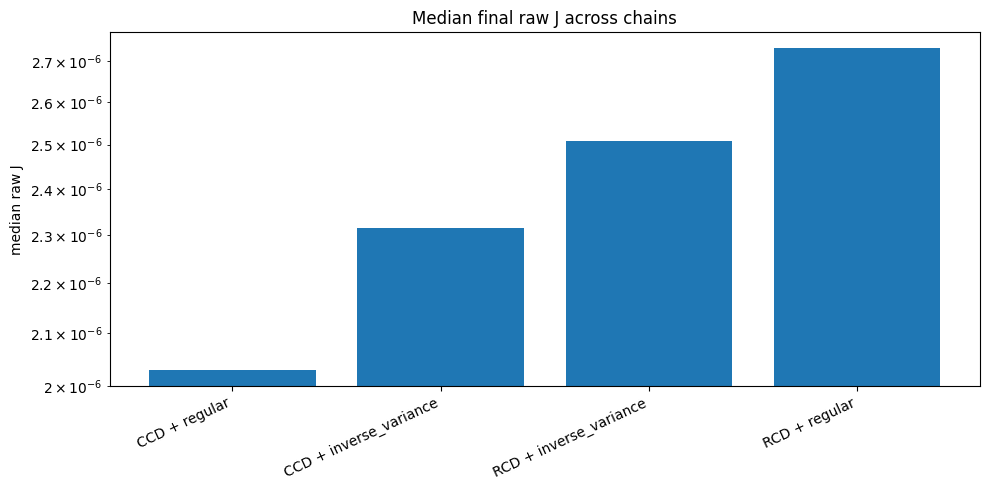

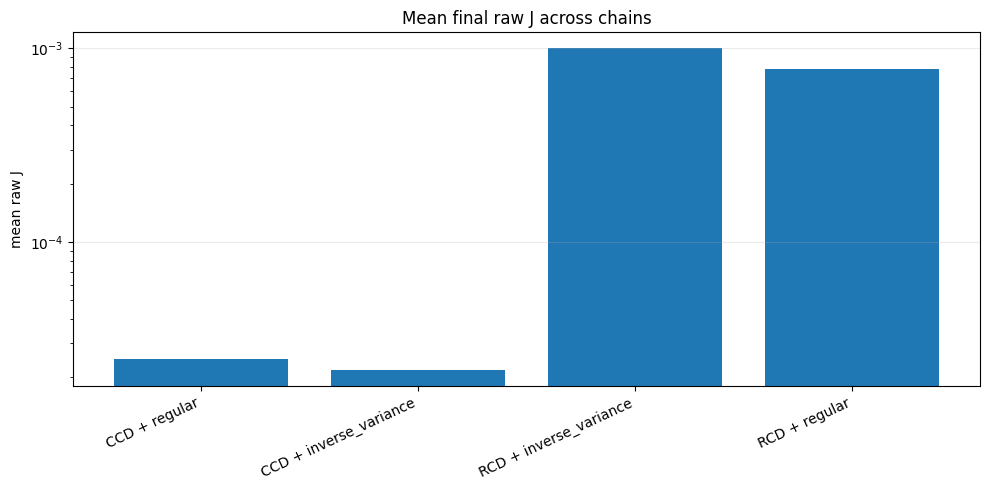

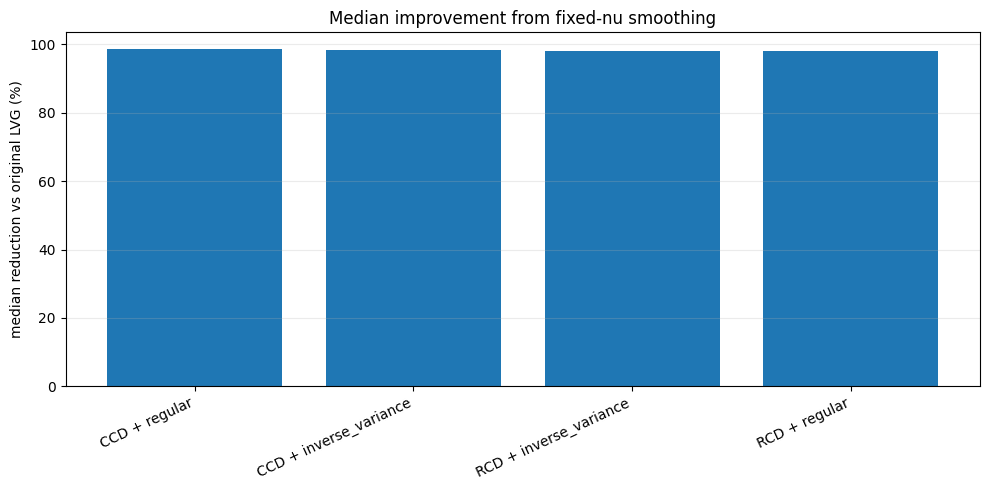

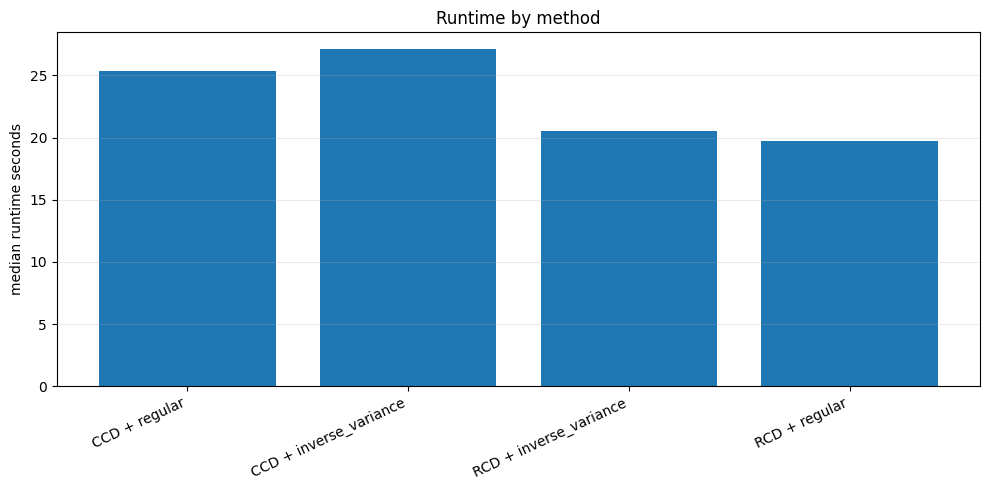

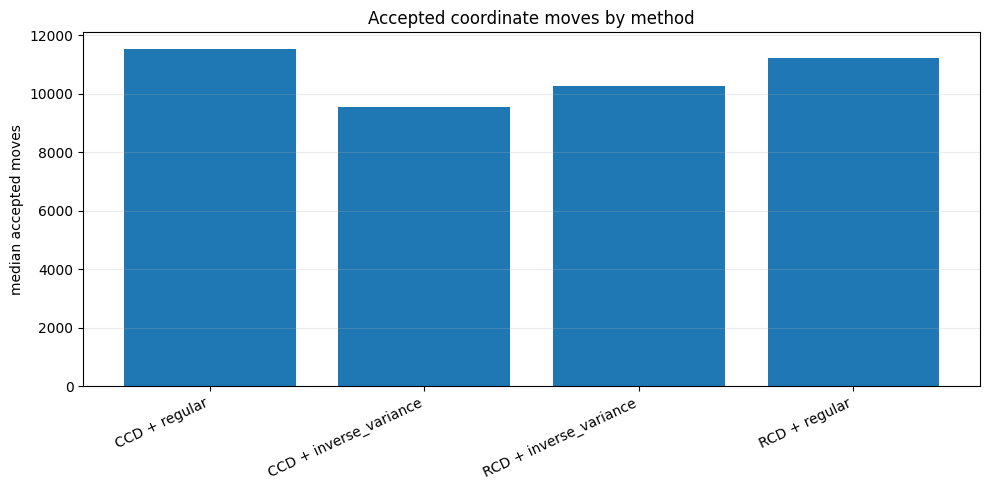

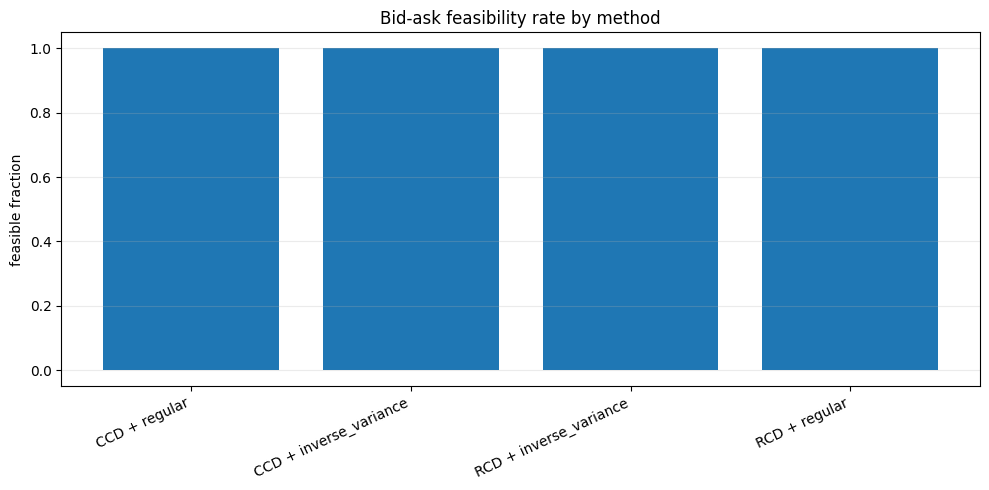

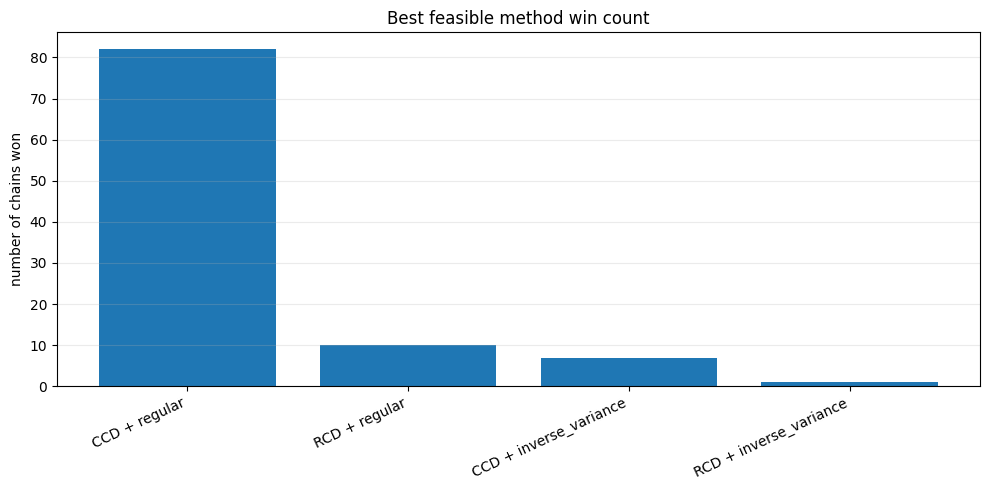

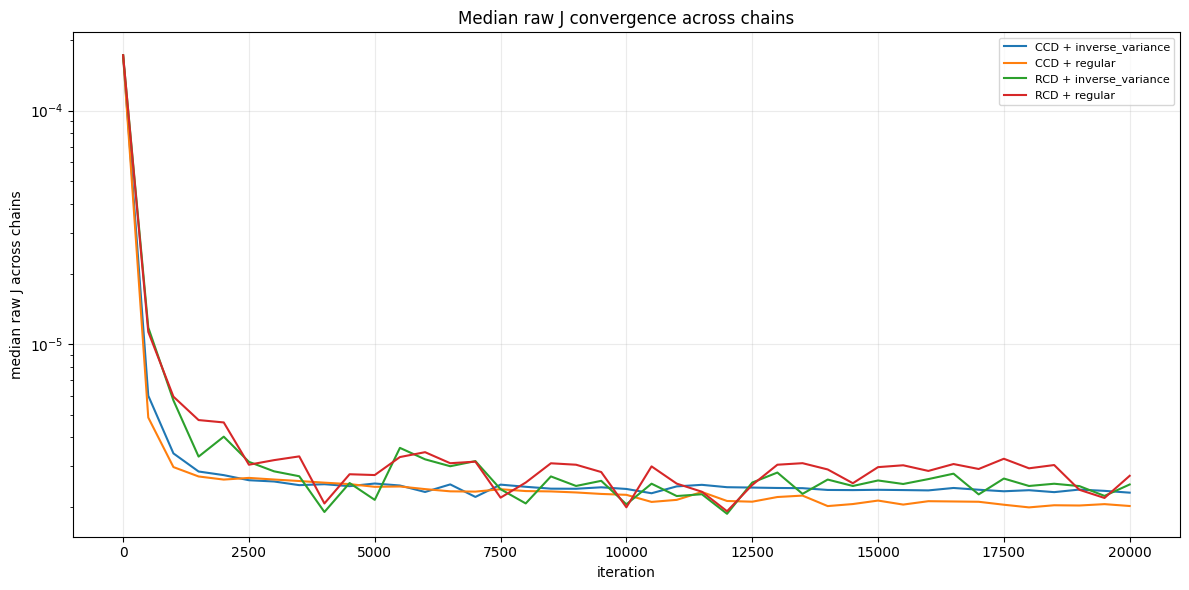

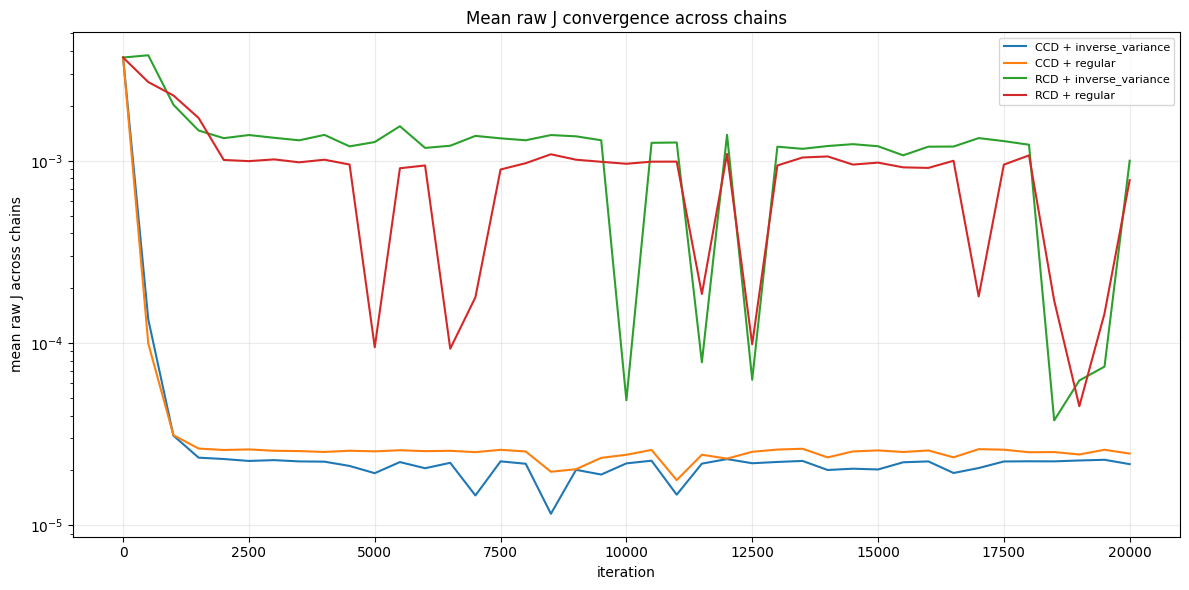

In [55]:
def method_label(descent_method, proxy_kind):
    return f"{descent_method} + {proxy_kind}"


def add_method_label(df):
    out = df.copy()
    out["method_label"] = out.apply(lambda r: method_label(r["descent_method"], r["proxy_kind"]), axis=1)
    return out


def plot_fixed_nu_summary(summary_df, best_by_chain, traces):
    plot_data = add_method_label(summary_df)

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["median_raw_J"])
    plt.yscale("log")
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("median raw J")
    plt.title("Median final raw J across chains")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_median_raw_J_by_method.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["mean_raw_J"])
    plt.yscale("log")
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("mean raw J")
    plt.title("Mean final raw J across chains")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_mean_raw_J_by_method.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["median_reduction_vs_original_pct"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("median reduction vs original LVG (%)")
    plt.title("Median improvement from fixed-nu smoothing")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_reduction_vs_original.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["median_runtime_seconds"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("median runtime seconds")
    plt.title("Runtime by method")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_runtime_by_method.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["median_accepted_moves"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("median accepted moves")
    plt.title("Accepted coordinate moves by method")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_accepted_moves_by_method.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["feasible_rate"])
    plt.ylim(-0.05, 1.05)
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("feasible fraction")
    plt.title("Bid-ask feasibility rate by method")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_feasibility_by_method.png", dpi=150)
    plt.show()

    if not best_by_chain.empty:
        wins = add_method_label(best_by_chain).groupby("method_label").size().sort_values(ascending=False)
        plt.figure(figsize=(10, 5))
        plt.bar(wins.index, wins.values)
        plt.xticks(rotation=25, ha="right")
        plt.ylabel("number of chains won")
        plt.title("Best feasible method win count")
        plt.grid(True, axis="y", alpha=0.25)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "fixed_nu_100_win_counts.png", dpi=150)
        plt.show()

    if traces.empty:
        print("No convergence traces available.")
        return
    trace_data = add_method_label(traces)
    plt.figure(figsize=(12, 6))
    for label, group in trace_data.groupby("method_label"):
        grouped = group.groupby("iteration", as_index=False)["raw_J"].median().sort_values("iteration")
        plt.plot(grouped["iteration"], grouped["raw_J"], label=label)
    plt.yscale("log")
    plt.xlabel("iteration")
    plt.ylabel("median raw J across chains")
    plt.title("Median raw J convergence across chains")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_convergence_raw_J.png", dpi=150)
    plt.show()

    plt.figure(figsize=(12, 6))
    for label, group in trace_data.groupby("method_label"):
        grouped = group.groupby("iteration", as_index=False)["raw_J"].mean().sort_values("iteration")
        plt.plot(grouped["iteration"], grouped["raw_J"], label=label)
    plt.yscale("log")
    plt.xlabel("iteration")
    plt.ylabel("mean raw J across chains")
    plt.title("Mean raw J convergence across chains")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_convergence_raw_J_mean.png", dpi=150)
    plt.show()

plot_fixed_nu_summary(fixed_nu_summary, best_methods_by_chain, fixed_nu_traces)


Recomputing representative theta curves for date=20111005, exdate=20120922


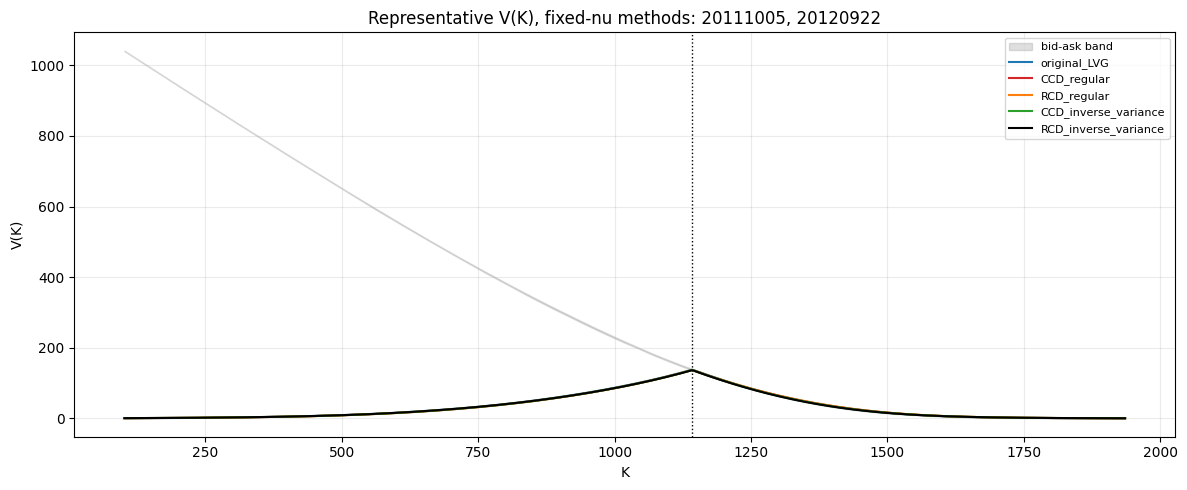

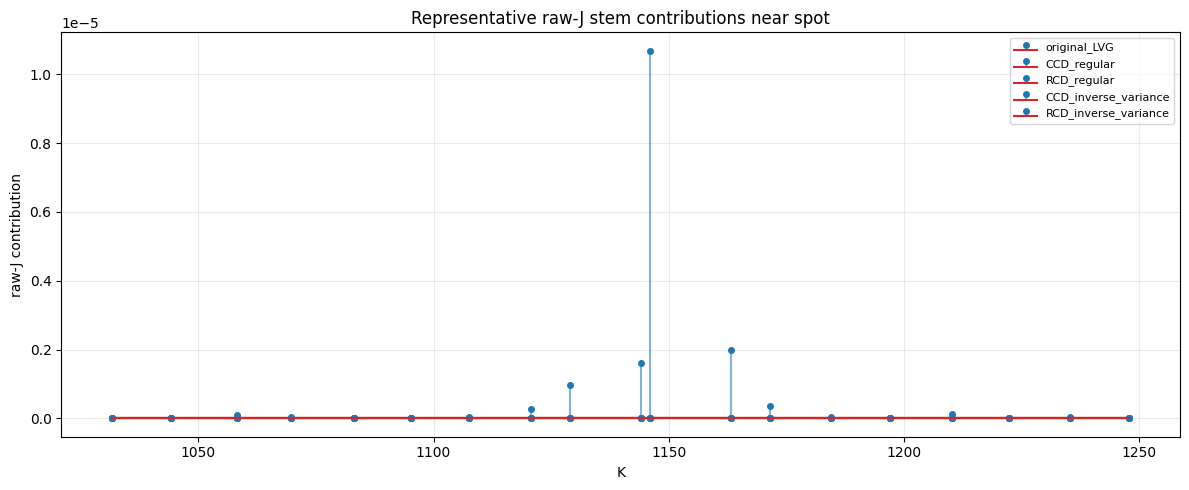

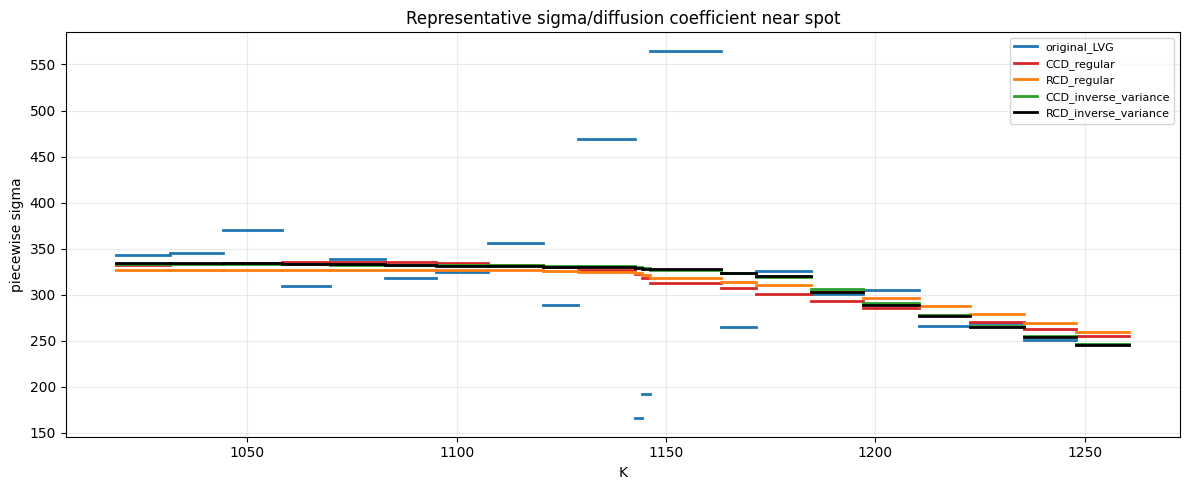

In [56]:
def unique_methods(methods):
    seen = set()
    output = []
    for method in methods:
        if method not in seen:
            seen.add(method)
            output.append(method)
    return output


def plot_sigma_piecewise(R1, R2, S0, theta, label, color=None, k_low=None, k_high=None):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    endpoints = np.concatenate([left_nu, [S0], right_nu])
    sigmas = np.concatenate([left_sigma, right_sigma])
    first = True
    for i, sigma in enumerate(sigmas):
        x0 = endpoints[i]
        x1 = endpoints[i + 1]
        if k_low is not None and x1 < k_low:
            continue
        if k_high is not None and x0 > k_high:
            continue
        plt.plot([x0, x1], [sigma, sigma], color=color, linewidth=2, label=label if first else None)
        first = False


def compute_representative_thetas(date, exdate):
    chain = build_adjusted_chain(raw_spx, int(date), int(exdate), MIN_STRIKES)
    rows, traces, theta_store = run_one_chain_fixed_nu_comparison(chain)
    return chain, theta_store


def plot_representative_fixed_nu_chain(results):
    feasible = results[results["bid_ask_feasible"]].sort_values("raw_J")
    if feasible.empty:
        print("No feasible representative result.")
        return

    best = feasible.iloc[0]
    date = int(best.date)
    exdate = int(best.exdate)
    print(f"Recomputing representative theta curves for date={date}, exdate={exdate}")
    chain, theta_store = compute_representative_thetas(date, exdate)

    methods = unique_methods(["original_LVG", "CCD_regular", "RCD_regular", "CCD_inverse_variance", "RCD_inverse_variance", best.method])
    K_grid = np.linspace(chain["K"].min(), chain["K"].max(), 500)
    colors = {
        "original_LVG": "tab:blue",
        "CCD_regular": "tab:red",
        "RCD_regular": "tab:orange",
        "CCD_inverse_variance": "tab:green",
        "RCD_inverse_variance": "black",
    }

    plt.figure(figsize=(12, 5))
    plt.fill_between(chain["K"], chain["bid"], chain["ask"], color="gray", alpha=0.25, label="bid-ask band")
    for method in methods:
        if method not in theta_store:
            continue
        R1, R2, theta = theta_store[method]
        c_v1, c_v2 = load_c_values(R1, R2, chain["S0"], theta)
        V = np.array([V_K(k, R1, R2, chain["S0"], theta, c_v1, c_v2) for k in K_grid])
        plt.plot(K_grid, V, label=method, color=colors.get(method))
    plt.axvline(chain["S0"], color="black", linestyle=":", linewidth=1)
    plt.xlabel("K")
    plt.ylabel("V(K)")
    plt.title(f"Representative V(K), fixed-nu methods: {date}, {exdate}")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_representative_V_curves.png", dpi=150)
    plt.show()

    plt.figure(figsize=(12, 5))
    for method in methods:
        if method not in theta_store:
            continue
        R1, R2, theta = theta_store[method]
        jumps = jump_contributions_by_knot(R1, R2, chain["S0"], theta)
        keep = (jumps["knot"] >= chain["S0"] * 0.9) & (jumps["knot"] <= chain["S0"] * 1.1)
        markerline, stemlines, baseline = plt.stem(jumps.loc[keep, "knot"], jumps.loc[keep, "jump_squared"], label=method)
        plt.setp(stemlines, alpha=0.55)
        plt.setp(markerline, markersize=4)
    plt.xlabel("K")
    plt.ylabel("raw-J contribution")
    plt.title("Representative raw-J stem contributions near spot")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_representative_raw_J_stems.png", dpi=150)
    plt.show()

    plt.figure(figsize=(12, 5))
    k_low = chain["S0"] * 0.9
    k_high = chain["S0"] * 1.1
    for method in methods:
        if method not in theta_store:
            continue
        R1, R2, theta = theta_store[method]
        plot_sigma_piecewise(R1, R2, chain["S0"], theta, method, colors.get(method), k_low, k_high)
    plt.xlabel("K")
    plt.ylabel("piecewise sigma")
    plt.title("Representative sigma/diffusion coefficient near spot")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_representative_sigma_curves.png", dpi=150)
    plt.show()

plot_representative_fixed_nu_chain(fixed_nu_results)


## Step 9: maturity-bucket diagnostic for regular CCD vs inverse-variance CCD

The mean and median conclusions point in different directions for `CCD_regular` versus `CCD_inverse_variance`. The mean raw `J` is slightly lower for inverse variance, while the median raw `J` and win count favor regular CCD.

That means the comparison should be treated as a **paired chain-level problem**. For each chain, compare

$$
\Delta_i = J_i^{\mathrm{inv}} - J_i^{\mathrm{regular}}.
$$

If `Delta_i < 0`, inverse variance won on that chain. If `Delta_i > 0`, regular CCD won. We also look at the ratio

$$
\rho_i = \frac{J_i^{\mathrm{inv}}}{J_i^{\mathrm{regular}}}.
$$

Ratios are useful because raw `J` can vary by orders of magnitude across chains. A ratio below 1 means inverse variance improved on that chain; a ratio above 1 means regular CCD was better.

This section answers three questions:

1. Which maturity buckets produced the inverse-variance wins?
2. How large were those wins?
3. Are the inverse-variance wins broad and systematic, or concentrated in a small subset of chains?


In [ ]:
PAIRWISE_DIAGNOSTIC_DIR = OUTPUT_DIR / "paired_regular_vs_inverse_diagnostics"
PAIRWISE_DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)


def paired_regular_inverse_table(results):
    fixed = results[results["method_family"] == "fixed_nu_descent"].copy()
    original = results[results["method"] == "original_LVG"][[
        "date", "exdate", "T", "maturity_bucket", "raw_J", "R1", "R2", "R_total"
    ]].rename(columns={"raw_J": "original_J"})

    pivot = fixed.pivot_table(
        index=["date", "exdate"],
        columns="method",
        values="raw_J",
        aggfunc="first",
    ).reset_index()

    paired = original.drop_duplicates(["date", "exdate"]).merge(pivot, on=["date", "exdate"])
    paired["inv_minus_reg"] = paired["CCD_inverse_variance"] - paired["CCD_regular"]
    paired["inv_over_reg"] = paired["CCD_inverse_variance"] / paired["CCD_regular"]
    paired["inv_improvement_vs_reg_pct"] = 100.0 * (
        paired["CCD_regular"] - paired["CCD_inverse_variance"]
    ) / paired["CCD_regular"]
    paired["winner"] = np.where(paired["inv_minus_reg"] < 0, "inverse_variance", "regular")
    return paired


paired_regular_inverse = paired_regular_inverse_table(fixed_nu_results)
paired_regular_inverse.to_csv(PAIRWISE_DIAGNOSTIC_DIR / "paired_CCD_regular_vs_inverse.csv", index=False)

bucket_summary = (
    paired_regular_inverse.groupby("maturity_bucket", as_index=False)
    .agg(
        chains=("date", "count"),
        inverse_wins=("winner", lambda s: int((s == "inverse_variance").sum())),
        regular_wins=("winner", lambda s: int((s == "regular").sum())),
        median_inverse_over_regular=("inv_over_reg", "median"),
        mean_inverse_over_regular=("inv_over_reg", "mean"),
        median_inverse_improvement_pct=("inv_improvement_vs_reg_pct", "median"),
        mean_inverse_improvement_pct=("inv_improvement_vs_reg_pct", "mean"),
    )
)
bucket_summary.to_csv(PAIRWISE_DIAGNOSTIC_DIR / "maturity_bucket_CCD_regular_vs_inverse_summary.csv", index=False)

inverse_winners = paired_regular_inverse[paired_regular_inverse["winner"] == "inverse_variance"].copy()
inverse_winners = inverse_winners.sort_values("inv_improvement_vs_reg_pct", ascending=False)
inverse_winners.to_csv(PAIRWISE_DIAGNOSTIC_DIR / "inverse_variance_winning_chains.csv", index=False)

print("Maturity-bucket summary: CCD inverse-variance versus CCD regular")
display(bucket_summary)

print("Chains where CCD inverse-variance beat CCD regular")
show_cols = [
    "date", "exdate", "T", "maturity_bucket", "R1", "R2", "original_J",
    "CCD_regular", "CCD_inverse_variance", "inv_over_reg", "inv_improvement_vs_reg_pct",
]
display(inverse_winners[show_cols])

# Pull all four method rows for the inverse-winning chains so we can diagnose whether
# inverse variance won only relative to CCD regular or whether another method was better.
inverse_keys = inverse_winners[["date", "exdate"]]
inverse_winner_method_rows = (
    fixed_nu_results[fixed_nu_results["method_family"] == "fixed_nu_descent"]
    .merge(inverse_keys, on=["date", "exdate"])
    .sort_values(["date", "exdate", "raw_J"])
)
inverse_winner_method_rows.to_csv(PAIRWISE_DIAGNOSTIC_DIR / "method_rows_for_inverse_winning_chains.csv", index=False)
print("All method rows on the inverse-winning chains")
display(inverse_winner_method_rows[[
    "date", "exdate", "maturity_bucket", "method", "raw_J", "reduction_vs_original_pct",
    "runtime_seconds", "accepted_moves", "min_quote_slack", "regular_proxy", "inverse_variance_proxy",
]])

# Plot inverse-win counts by maturity bucket.
plt.figure(figsize=(9, 5))
plt.bar(bucket_summary["maturity_bucket"], bucket_summary["inverse_wins"], label="inverse wins")
plt.bar(bucket_summary["maturity_bucket"], bucket_summary["regular_wins"], bottom=bucket_summary["inverse_wins"], alpha=0.35, label="regular wins")
plt.ylabel("number of chains")
plt.title("CCD regular vs CCD inverse-variance wins by maturity bucket")
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(PAIRWISE_DIAGNOSTIC_DIR / "wins_by_maturity_bucket.png", dpi=150)
plt.show()

# Plot ratios by maturity bucket. Values below 1 favor inverse variance.
plt.figure(figsize=(10, 5))
ordered_buckets = ["short", "medium", "long", "very_long"]
data = [paired_regular_inverse.loc[paired_regular_inverse["maturity_bucket"] == b, "inv_over_reg"] for b in ordered_buckets]
plt.boxplot(data, labels=ordered_buckets, showfliers=True)
plt.axhline(1.0, color="black", linestyle=":", linewidth=1)
plt.ylabel("CCD inverse raw J / CCD regular raw J")
plt.title("Paired method ratio by maturity bucket")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(PAIRWISE_DIAGNOSTIC_DIR / "inverse_over_regular_ratio_by_bucket.png", dpi=150)
plt.show()

# Plot how large the inverse wins were.
if len(inverse_winners) > 0:
    labels = inverse_winners["date"].astype(str) + "\n" + inverse_winners["exdate"].astype(str)
    plt.figure(figsize=(11, 5))
    plt.bar(labels, inverse_winners["inv_improvement_vs_reg_pct"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("inverse improvement vs regular CCD (%)")
    plt.title("How much better inverse variance was on its winning chains")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PAIRWISE_DIAGNOSTIC_DIR / "inverse_win_magnitudes.png", dpi=150)
    plt.show()

print("Diagnostic files saved to", PAIRWISE_DIAGNOSTIC_DIR)


## Step 10: original `Quotes.csv` four-method comparison

The 100-chain benchmark uses many SPX chains from the WRDS-style file. This local section repeats the same four-method fixed-nu comparison on the original single-chain dataset used earlier in the project: `Quotes.csv`.

This is useful because it connects the large-sample benchmark back to the chain where we developed the initial diagnostics. The experiment is intentionally localized:

- it does not overwrite the 100-chain results,
- it writes separate `original_quotes_*` output files,
- it uses the same four methods as the benchmark,
- it keeps the original nus fixed and only changes sigmas.

The four methods are again:

1. `CCD_regular`,
2. `RCD_regular`,
3. `CCD_inverse_variance`,
4. `RCD_inverse_variance`.

As before, the proxy guides the coordinate updates, but raw `J` is the final comparison metric.


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Original Quotes.csv fixed-nu four-method comparison:


,method,raw_J,reduction_vs_original_pct,runtime_seconds,accepted_moves,bid_ask_feasible,min_quote_slack,regular_proxy,inverse_variance_proxy
3,CCD_inverse_variance,2.761455e-07,99.980656,21.382704,11161.0,True,-9.901429e-08,39.253759,1.869045e-08
4,RCD_inverse_variance,4.027766e-07,99.971786,14.289345,10109.0,True,-9.876109e-08,61.212668,2.342196e-08
1,CCD_regular,1.037782e-06,99.927304,21.731218,13638.0,True,-9.536815e-08,29.975942,3.780639e-08
2,RCD_regular,1.591070e-06,99.888546,12.426026,12549.0,True,-3.169407e-08,54.151962,4.817714e-08
0,original_LVG,1.427559e-03,0.000000,NaN,NaN,True,1.577017e-02,257058.884176,1.862739e-05


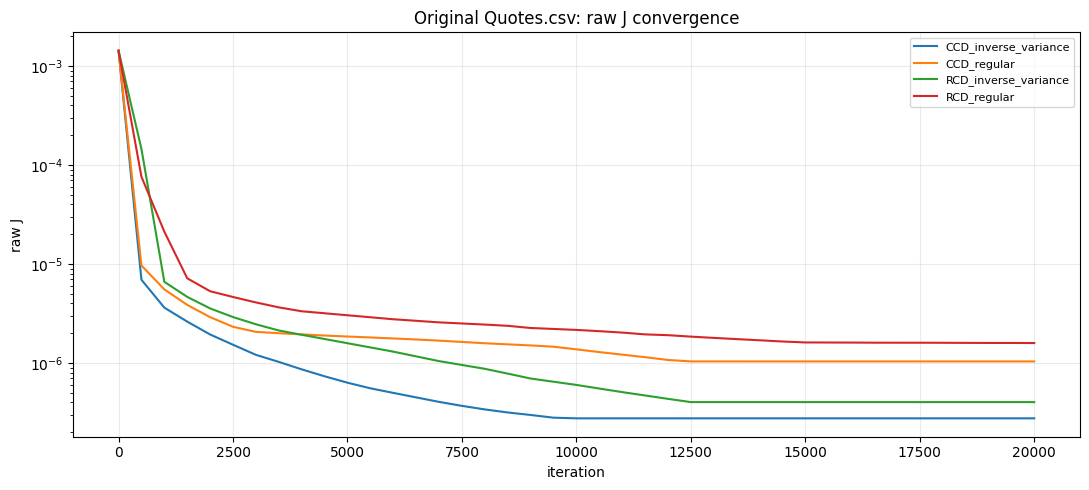

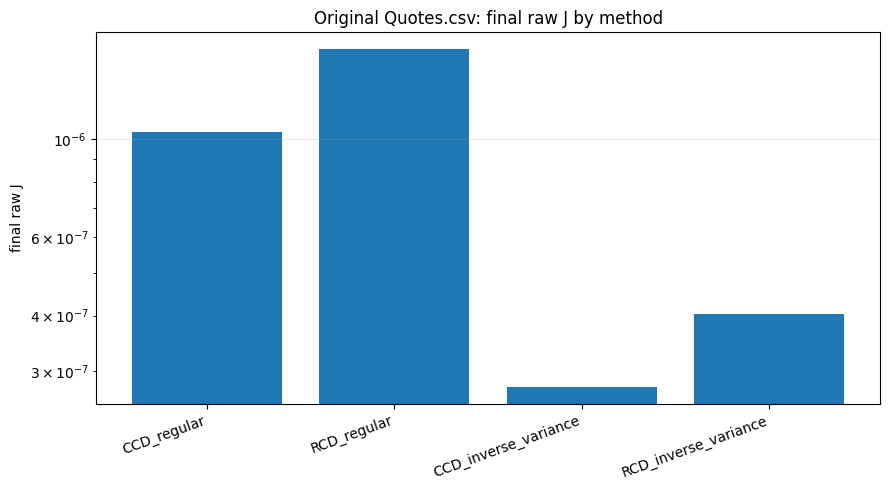

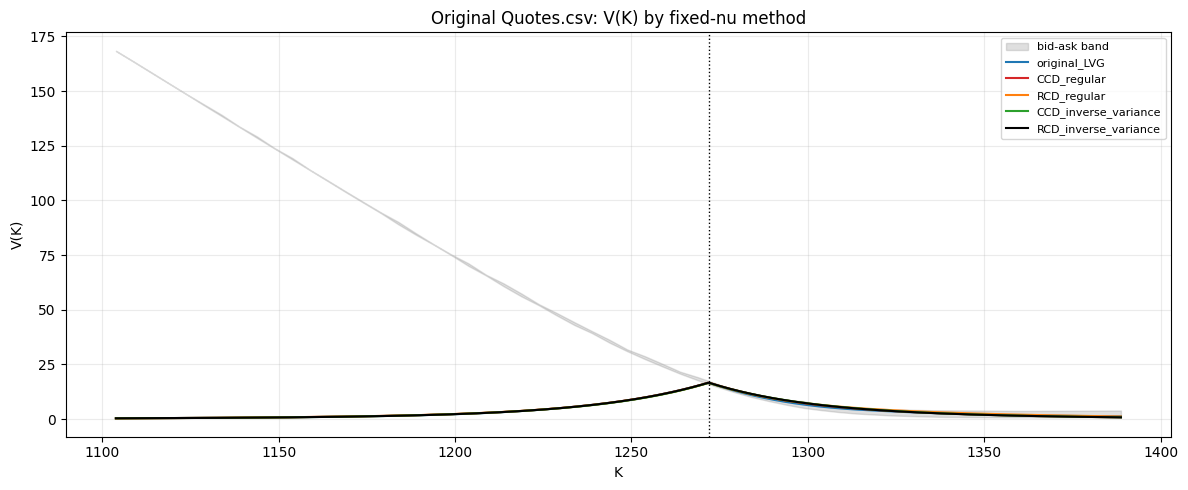

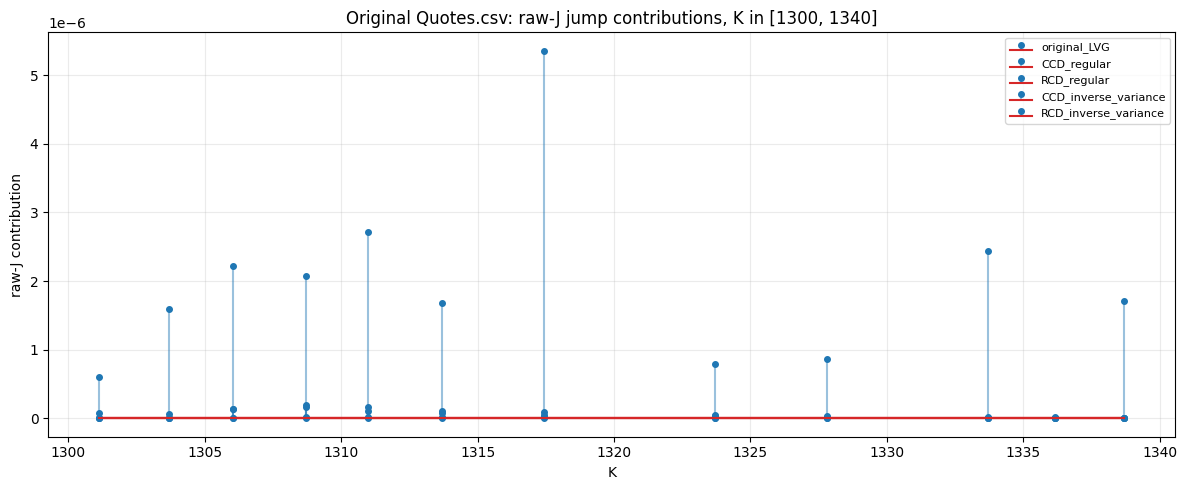

In [57]:
ORIGINAL_QUOTES_OUTPUT_DIR = OUTPUT_DIR / "original_quotes_single_chain"
ORIGINAL_QUOTES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ORIGINAL_QUOTES_ITERATIONS = 20000
ORIGINAL_QUOTES_RECORD_EVERY = 500
ORIGINAL_QUOTES_S0 = 1271.87


def load_original_quotes_chain(file_name="Quotes.csv", S0=ORIGINAL_QUOTES_S0):
    path = find_data_file(file_name)
    quotes = pd.read_csv(path, header=None, names=["K", "ask", "bid"])
    quotes = quotes.sort_values("K").reset_index(drop=True)

    K = quotes["K"].to_numpy(dtype=float)
    ask = quotes["ask"].to_numpy(dtype=float)
    bid = quotes["bid"].to_numpy(dtype=float)
    keep = np.isfinite(K) & np.isfinite(bid) & np.isfinite(ask) & (ask >= bid)

    K = K[keep]
    bid = bid[keep]
    ask = ask[keep]

    return {
        "date": "original_quotes",
        "exdate": "single_chain",
        "T": np.nan,
        "D": 1.0,
        "F": float(S0),
        "S0": float(S0),
        "K": K,
        "bid": bid,
        "ask": ask,
        "bid_ask": np.column_stack([K, bid, ask]),
    }


def run_original_quotes_fixed_nu_comparison():
    chain = load_original_quotes_chain()
    R1, R2, init_theta = build_initial_theta_for_chain(chain)
    baseline_J = J_value(R1, R2, chain["S0"], init_theta)

    rows = []
    traces = []
    theta_store = {"original_LVG": (R1, R2, init_theta)}

    rows.append(result_row(
        "original_LVG", chain, R1, R2, init_theta, baseline_J,
        extra={
            "method_family": "original_quotes",
            "proxy_kind": "none",
            "update_order": "none",
            "descent_method": "none",
            "accepted_moves": np.nan,
            "iterations": 0,
        },
    ))

    for proxy_kind in ["regular", "inverse_variance"]:
        for update_order in ["cyclic", "random"]:
            descent_method = ORDER_LABELS[update_order]
            method = f"{descent_method}_{proxy_kind}"
            start = time.time()
            theta_final, trace, accepted_moves = coordinate_descent_sigma(
                R1,
                R2,
                chain["S0"],
                init_theta,
                chain["bid_ask"],
                proxy_kind=proxy_kind,
                update_order=update_order,
                num_iterations=ORIGINAL_QUOTES_ITERATIONS,
                random_seed=RANDOM_SEED,
                record_every=ORIGINAL_QUOTES_RECORD_EVERY,
            )
            runtime = time.time() - start
            rows.append(result_row(
                method, chain, R1, R2, theta_final, baseline_J, runtime,
                extra={
                    "method_family": "original_quotes_fixed_nu_descent",
                    "proxy_kind": proxy_kind,
                    "update_order": update_order,
                    "descent_method": descent_method,
                    "accepted_moves": accepted_moves,
                    "iterations": ORIGINAL_QUOTES_ITERATIONS,
                },
            ))
            trace = trace.copy()
            trace["method"] = method
            trace["proxy_kind"] = proxy_kind
            trace["update_order"] = update_order
            trace["descent_method"] = descent_method
            traces.append(trace)
            theta_store[method] = (R1, R2, theta_final)

    results = pd.DataFrame(rows)
    convergence = pd.concat(traces, ignore_index=True)
    return chain, results, convergence, theta_store


original_quotes_chain, original_quotes_results, original_quotes_convergence, original_quotes_thetas = run_original_quotes_fixed_nu_comparison()

original_quotes_results.to_csv(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_four_method_results.csv", index=False)
original_quotes_convergence.to_csv(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_four_method_convergence.csv", index=False)

comparison_cols = [
    "method", "raw_J", "reduction_vs_original_pct", "runtime_seconds",
    "accepted_moves", "bid_ask_feasible", "min_quote_slack",
    "regular_proxy", "inverse_variance_proxy",
]
print("Original Quotes.csv fixed-nu four-method comparison:")
display(original_quotes_results[comparison_cols].sort_values("raw_J"))

# Convergence plot.
plt.figure(figsize=(11, 5))
for method, group in original_quotes_convergence.groupby("method"):
    group = group.sort_values("iteration")
    plt.plot(group["iteration"], group["raw_J"], label=method)
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("raw J")
plt.title("Original Quotes.csv: raw J convergence")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_raw_J_convergence.png", dpi=150)
plt.show()

# Final raw-J bar chart.
plot_data = original_quotes_results[original_quotes_results["method"] != "original_LVG"].copy()
plt.figure(figsize=(9, 5))
plt.bar(plot_data["method"], plot_data["raw_J"])
plt.yscale("log")
plt.xticks(rotation=20, ha="right")
plt.ylabel("final raw J")
plt.title("Original Quotes.csv: final raw J by method")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_final_raw_J_by_method.png", dpi=150)
plt.show()

# V(K) comparison.
K_grid = np.linspace(original_quotes_chain["K"].min(), original_quotes_chain["K"].max(), 500)
colors = {
    "original_LVG": "tab:blue",
    "CCD_regular": "tab:red",
    "RCD_regular": "tab:orange",
    "CCD_inverse_variance": "tab:green",
    "RCD_inverse_variance": "black",
}
plt.figure(figsize=(12, 5))
plt.fill_between(
    original_quotes_chain["K"],
    original_quotes_chain["bid"],
    original_quotes_chain["ask"],
    color="gray",
    alpha=0.25,
    label="bid-ask band",
)
for method, (R1, R2, theta) in original_quotes_thetas.items():
    c_v1, c_v2 = load_c_values(R1, R2, original_quotes_chain["S0"], theta)
    V = np.array([V_K(k, R1, R2, original_quotes_chain["S0"], theta, c_v1, c_v2) for k in K_grid])
    plt.plot(K_grid, V, label=method, color=colors.get(method))
plt.axvline(original_quotes_chain["S0"], color="black", linestyle=":", linewidth=1)
plt.xlabel("K")
plt.ylabel("V(K)")
plt.title("Original Quotes.csv: V(K) by fixed-nu method")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_V_curves.png", dpi=150)
plt.show()

# Raw-J stem comparison near the right wing problem area from the original experiment.
plt.figure(figsize=(12, 5))
for method, (R1, R2, theta) in original_quotes_thetas.items():
    jumps = jump_contributions_by_knot(R1, R2, original_quotes_chain["S0"], theta)
    keep = (jumps["knot"] >= 1300.0) & (jumps["knot"] <= 1340.0)
    markerline, stemlines, baseline = plt.stem(
        jumps.loc[keep, "knot"],
        jumps.loc[keep, "jump_squared"],
        label=method,
    )
    plt.setp(stemlines, alpha=0.45)
    plt.setp(markerline, markersize=4)
plt.xlabel("K")
plt.ylabel("raw-J contribution")
plt.title("Original Quotes.csv: raw-J jump contributions, K in [1300, 1340]")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_raw_J_stems_1300_1340.png", dpi=150)
plt.show()


## Step 11: conclusion checklist

The 100-chain test supports the following conclusions.

**Main empirical conclusion:** deterministic CCD with the regular adjacent-sigma proxy is the strongest fixed-nu method in this experiment. It won the largest number of chains and had the best median reduction in raw `J`.

**Why this matters:** the inverse-variance proxy is mathematically motivated by one part of the raw jump formula, but it did not generally produce lower raw `J`. This tells us that optimizing only

$$
\frac{1}{\sigma_{i+1}^2}-\frac{1}{\sigma_i^2}
$$

misses important parts of the full LVG jump expression, including the exponential coefficients and local level of the time-value curve.

**RCD conclusion:** random coordinate descent was usually faster, but it was less reliable and usually finished with larger raw `J`. For this fixed-nu problem, the deterministic cyclic structure appears useful rather than arbitrary.

**Feasibility conclusion:** all four methods preserved bid-ask feasibility in the 100-chain run, so the comparison is fair: the lower raw `J` values are not coming from violating market constraints.

**Next research step:** fixed-nu smoothing is now well understood. Further improvement should come from adaptive nu placement or added-nu models, not from switching the fixed-nu proxy alone.


## Step 12: full-theta augmented-Lagrangian polish after CCD

The previous sections compare fixed-nu CCD/RCD methods. This section asks a different question:

> After running the strongest fixed-nu method, can an augmented-Lagrangian optimizer improve the full LVG parameter vector \(\theta\)?

The starting point is always the feasible output of **20,000 iterations of CCD with the regular adjacent-sigma proxy**. From there, the augmented-Lagrangian polish is allowed to move both the knot locations \(\nu\) and the diffusion coefficients \(\sigma\).

This is different from the earlier CCD tests:

- CCD moves only sigmas and rejects any step that leaves the bid-ask band.
- Augmented Lagrangian optimizes a larger parameter vector and allows the inner optimizer to explore points that may temporarily violate bid-ask.
- The multiplier and penalty terms push the final answer back toward feasibility.
- A result only counts as an improvement if the final theta is bid-ask feasible and has lower raw \(J\) than the CCD start.

For each quote strike \(K_i\), define the bid and ask violations:

$$
v_i^{bid}(\theta)=\max(bid_i-C_\theta(K_i),0),
$$

$$
v_i^{ask}(\theta)=\max(C_\theta(K_i)-ask_i,0).
$$

The augmented objective is

$$
L(\theta)=J(\theta)+\lambda_{bid}\cdot v^{bid}(\theta)
+\lambda_{ask}\cdot v^{ask}(\theta)
+\frac{\rho}{2}\left(\|v^{bid}(\theta)\|^2+\|v^{ask}(\theta)\|^2\right).
$$

After each outer iteration, the multipliers are updated by

$$
\lambda_{bid}\leftarrow \max(0,\lambda_{bid}+\rho v^{bid}),
$$

$$
\lambda_{ask}\leftarrow \max(0,\lambda_{ask}+\rho v^{ask}).
$$

Because this version moves nus, the optimizer works in a raw variable space. Positive gaps reconstruct ordered nus below and above spot, and positive sigma variables reconstruct sigmas. This means the structural LVG constraints are always satisfied by construction; bid-ask feasibility is checked separately at the end.


In [59]:
from scipy.optimize import minimize

AL_FULL_OUTPUT_DIR = OUTPUT_DIR / "augmented_lagrangian_full_theta_polish"
AL_FULL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Change to "one_chain" for a fast smoke test, or "twelve_chains" for the planned run.
AL_FULL_RUN_MODE = "twelve_chains"
AL_CHAINS_PER_BUCKET = 3
AL_CCD_START_ITERATIONS = 20000
AL_J_SCALE = 1e8
AL_RHO_INIT = 1e4
AL_RHO_SCALE = 5.0
AL_RHO_MAX = 1e12
AL_OUTER_ITERATIONS = 6
AL_INNER_MAXITER = 35
AL_RAW_BOUND = 20.0
AL_FEAS_TOL = 1e-7
AL_POSITIVE_FLOOR = 1e-8


def positive_from_raw(raw):
    """Map raw values to positive values without using softplus."""
    return np.exp(np.clip(raw, -AL_RAW_BOUND, AL_RAW_BOUND)) + AL_POSITIVE_FLOOR


def raw_from_positive(values):
    """Inverse of positive_from_raw, up to the small positive floor."""
    values = np.asarray(values, dtype=float)
    return np.log(np.maximum(values - AL_POSITIVE_FLOOR, AL_POSITIVE_FLOOR))


def full_theta_to_raw(R1, R2, S0, theta):
    """Convert feasible theta into raw gaps and raw sigmas."""
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)

    left_gaps = np.concatenate([left_nu[1:] - left_nu[:-1], [S0 - left_nu[-1]]])
    right_gaps = np.concatenate([[right_nu[0] - S0], right_nu[1:] - right_nu[:-1]])

    if np.any(left_gaps <= 0) or np.any(right_gaps <= 0):
        raise ValueError("Cannot build raw variables from unordered nus")
    if np.any(left_sigma <= 0) or np.any(right_sigma <= 0):
        raise ValueError("Cannot build raw variables from nonpositive sigmas")

    return np.concatenate([
        raw_from_positive(left_gaps),
        raw_from_positive(left_sigma),
        raw_from_positive(right_gaps),
        raw_from_positive(right_sigma),
    ])


def full_theta_from_raw(R1, R2, S0, raw):
    """Reconstruct theta from raw gaps and sigmas. Nus are ordered by construction."""
    raw = np.asarray(raw, dtype=float)
    i = 0
    left_gaps = positive_from_raw(raw[i:i + R1]); i += R1
    left_sigma = positive_from_raw(raw[i:i + R1]); i += R1
    right_gaps = positive_from_raw(raw[i:i + R2]); i += R2
    right_sigma = positive_from_raw(raw[i:i + R2]); i += R2

    left_suffix = np.flip(np.cumsum(np.flip(left_gaps)))
    left_nu = S0 - left_suffix
    right_nu = S0 + np.cumsum(right_gaps)

    return theta_from_parts(left_nu, left_sigma, right_nu, right_sigma)


def max_bid_ask_violation(R1, R2, S0, theta, bid_ask_arr):
    """Positive max violation; zero means inside the bid-ask band."""
    try:
        prices = model_prices_at_quotes(R1, R2, S0, theta, bid_ask_arr)
    except Exception:
        n = bid_ask_arr.shape[0]
        return np.inf, np.full(n, np.inf), np.full(n, np.inf), None

    bid_violation = np.maximum(bid_ask_arr[:, 1] - prices, 0.0)
    ask_violation = np.maximum(prices - bid_ask_arr[:, 2], 0.0)
    max_violation = float(max(np.max(bid_violation), np.max(ask_violation)))
    return max_violation, bid_violation, ask_violation, prices


def select_augmented_lagrangian_chains():
    """Pick 3 chains per maturity bucket from the already-selected 100-chain universe."""
    if 'chains_to_run' in globals():
        source = chains_to_run.copy()
    else:
        source = select_chains(raw_spx, MAX_CHAINS, MIN_STRIKES)

    buckets = ["short", "medium", "long", "very_long"]
    selected = []
    for bucket in buckets:
        group = source[source["maturity_bucket"] == bucket].sort_values(["date", "T", "exdate"]).reset_index(drop=True)
        if group.empty:
            continue
        take = min(AL_CHAINS_PER_BUCKET, len(group))
        indices = np.linspace(0, len(group) - 1, take).round().astype(int)
        selected.append(group.iloc[indices])

    if selected:
        out = pd.concat(selected, ignore_index=True).drop_duplicates(["date", "exdate"])
    else:
        out = source.head(12).copy()

    if AL_FULL_RUN_MODE == "one_chain":
        out = out.head(1).copy()
    return out.reset_index(drop=True)


def run_ccd_regular_start(chain):
    """Build original LVG theta, then run 20k regular cyclic CCD."""
    R1, R2, init_theta = build_initial_theta_for_chain(chain)
    theta_ccd, trace, accepted_moves = coordinate_descent_sigma(
        R1,
        R2,
        chain["S0"],
        init_theta,
        chain["bid_ask"],
        proxy_kind="regular",
        update_order="cyclic",
        num_iterations=AL_CCD_START_ITERATIONS,
        random_seed=RANDOM_SEED,
        record_every=None,
    )
    return R1, R2, init_theta, theta_ccd, accepted_moves


def augmented_lagrangian_full_theta_polish(R1, R2, S0, theta_start, bid_ask_arr):
    """Optimize all nus and sigmas through raw variables with AL bid-ask penalties."""
    raw = full_theta_to_raw(R1, R2, S0, theta_start)
    lam_bid = np.zeros(bid_ask_arr.shape[0])
    lam_ask = np.zeros(bid_ask_arr.shape[0])
    rho = AL_RHO_INIT
    history = []

    def objective(raw_vec):
        theta = full_theta_from_raw(R1, R2, S0, raw_vec)
        try:
            raw_J = J_value(R1, R2, S0, theta)
        except Exception:
            return 1e30
        if not np.isfinite(raw_J):
            return 1e30

        max_violation, bid_v, ask_v, _ = max_bid_ask_violation(R1, R2, S0, theta, bid_ask_arr)
        if not np.isfinite(max_violation):
            return 1e30

        lagrange = np.dot(lam_bid, bid_v) + np.dot(lam_ask, ask_v)
        penalty = 0.5 * rho * (np.sum(bid_v ** 2) + np.sum(ask_v ** 2))
        return AL_J_SCALE * raw_J + lagrange + penalty

    bounds = [(-AL_RAW_BOUND, AL_RAW_BOUND) for _ in range(len(raw))]
    best_feasible_raw = raw.copy()
    best_feasible_J = J_value(R1, R2, S0, theta_start)

    for outer in range(1, AL_OUTER_ITERATIONS + 1):
        result = minimize(
            objective,
            raw,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": AL_INNER_MAXITER, "ftol": 1e-12, "gtol": 1e-10, "maxls": 20},
        )
        raw = result.x.copy()
        theta = full_theta_from_raw(R1, R2, S0, raw)
        raw_J = J_value(R1, R2, S0, theta)
        max_violation, bid_v, ask_v, _ = max_bid_ask_violation(R1, R2, S0, theta, bid_ask_arr)
        slack = quote_slack_report(R1, R2, S0, theta, bid_ask_arr)

        if slack["feasible"] and raw_J < best_feasible_J:
            best_feasible_J = raw_J
            best_feasible_raw = raw.copy()

        history.append({
            "outer_iteration": outer,
            "raw_J": raw_J,
            "best_feasible_raw_J": best_feasible_J,
            "augmented_objective": float(result.fun),
            "max_band_violation": max_violation,
            "min_quote_slack": slack["min_slack"],
            "min_bid_slack": slack["min_bid_slack"],
            "min_ask_slack": slack["min_ask_slack"],
            "rho": rho,
            "inner_success": bool(result.success),
            "inner_message": str(result.message),
            "inner_iterations": int(result.nit),
        })

        lam_bid = np.maximum(0.0, lam_bid + rho * bid_v)
        lam_ask = np.maximum(0.0, lam_ask + rho * ask_v)
        if max_violation > AL_FEAS_TOL:
            rho = min(rho * AL_RHO_SCALE, AL_RHO_MAX)

    theta_final = full_theta_from_raw(R1, R2, S0, best_feasible_raw)
    return theta_final, pd.DataFrame(history)


def al_full_theta_result_row(chain_info, chain, R1, R2, theta_ccd, theta_al, history, runtime, ccd_accepted_moves):
    ccd_J = J_value(R1, R2, chain["S0"], theta_ccd)
    al_J = J_value(R1, R2, chain["S0"], theta_al)
    slack = quote_slack_report(R1, R2, chain["S0"], theta_al, chain["bid_ask"])
    accepted = bool(
        al_J < ccd_J
        and slack["feasible"]
        and check_positive_sigmas(R1, R2, theta_al)
        and check_nu_order(R1, R2, chain["S0"], theta_al)
    )
    return {
        "date": int(chain_info["date"]),
        "exdate": int(chain_info["exdate"]),
        "T": float(chain_info["T"]),
        "maturity_bucket": chain_info["maturity_bucket"],
        "R1": R1,
        "R2": R2,
        "R_total": R1 + R2,
        "ccd_raw_J": ccd_J,
        "al_raw_J": al_J,
        "improvement_vs_CCD_pct": 100.0 * (ccd_J - al_J) / ccd_J if ccd_J > 0 else np.nan,
        "accepted": accepted,
        "bid_ask_feasible": slack["feasible"],
        "min_quote_slack": slack["min_slack"],
        "min_bid_slack": slack["min_bid_slack"],
        "min_ask_slack": slack["min_ask_slack"],
        "positive_sigmas": check_positive_sigmas(R1, R2, theta_al),
        "valid_nu_order": check_nu_order(R1, R2, chain["S0"], theta_al),
        "max_band_violation": float(history["max_band_violation"].iloc[-1]) if len(history) else np.nan,
        "outer_iterations": len(history),
        "ccd_accepted_moves": ccd_accepted_moves,
        "runtime_seconds": runtime,
    }


def run_full_theta_al_experiment():
    selected = select_augmented_lagrangian_chains()
    print(f"Selected {len(selected)} chains for full-theta AL polish")
    display(selected.groupby("maturity_bucket").size().rename("chains"))

    rows = []
    histories = []
    representatives = []

    for _, chain_info in selected.iterrows():
        date = int(chain_info["date"])
        exdate = int(chain_info["exdate"])
        label = f"{date}_{exdate}"
        print(f"\nRunning AL full-theta polish for date={date} exdate={exdate} bucket={chain_info['maturity_bucket']}")
        start_time = time.time()
        try:
            chain = build_adjusted_chain(raw_spx, date, exdate, MIN_STRIKES)
            R1, R2, init_theta, theta_ccd, ccd_accepted_moves = run_ccd_regular_start(chain)
            ccd_J = J_value(R1, R2, chain["S0"], theta_ccd)
            print(f"  CCD_regular start raw J = {ccd_J:.6e}")

            theta_al, history = augmented_lagrangian_full_theta_polish(R1, R2, chain["S0"], theta_ccd, chain["bid_ask"])
            runtime = time.time() - start_time
            row = al_full_theta_result_row(chain_info, chain, R1, R2, theta_ccd, theta_al, history, runtime, ccd_accepted_moves)
            rows.append(row)

            history = history.copy()
            history["date"] = date
            history["exdate"] = exdate
            history["maturity_bucket"] = chain_info["maturity_bucket"]
            histories.append(history)

            if len(representatives) < 4:
                representatives.append((label, chain, R1, R2, theta_ccd, theta_al, row))

            status = "ACCEPTED" if row["accepted"] else "rejected"
            print(f"  AL final raw J = {row['al_raw_J']:.6e}; improvement = {row['improvement_vs_CCD_pct']:.3f}% ({status})")
        except Exception as exc:
            runtime = time.time() - start_time
            rows.append({
                "date": date,
                "exdate": exdate,
                "T": float(chain_info["T"]),
                "maturity_bucket": chain_info["maturity_bucket"],
                "accepted": False,
                "bid_ask_feasible": False,
                "runtime_seconds": runtime,
                "error": repr(exc),
            })
            print(f"  Failed: {exc}")

    results = pd.DataFrame(rows)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    results.to_csv(AL_FULL_OUTPUT_DIR / "al_full_theta_results.csv", index=False)
    history.to_csv(AL_FULL_OUTPUT_DIR / "al_full_theta_history.csv", index=False)
    return selected, results, history, representatives


al_selected_chains, al_full_results, al_full_history, al_representatives = run_full_theta_al_experiment()

print("\nFull-theta augmented-Lagrangian polish results:")
show_cols = [
    "date", "exdate", "maturity_bucket", "ccd_raw_J", "al_raw_J", "improvement_vs_CCD_pct",
    "accepted", "bid_ask_feasible", "min_quote_slack", "max_band_violation", "runtime_seconds",
]
display(al_full_results[[c for c in show_cols if c in al_full_results.columns]].sort_values(["maturity_bucket", "date", "exdate"]))


Selected 12 chains for full-theta AL polish


maturity_bucket
long         3
medium       3
short        3
very_long    3
Name: chains, dtype: int64


Running AL full-theta polish for date=20110103 exdate=20110107 bucket=short


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


  CCD_regular start raw J = 7.052355e-05


...

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:45: RuntimeWarning: overflow encountered in exp
  0.5 * (P + left_sigma[j + 1] * S) * np.exp(dist / left_sigma[j + 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:44: RuntimeWarning: invalid value encountered in scalar subtract
  0.5 * (P - left_sigma[j + 1] * S) * np.exp(-dist / left_sigma[j + 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:56: RuntimeWarning: overflow encountered in exp
  0.5 * (P - right_sigma[j - 1] * S) * np.exp(dist / right_sigma[j - 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:57: RuntimeWarning: invalid value encountered in scalar add
  0.5 * (P + right_sigma[j - 1] * S) * np.exp(-dist / right_sigma[j - 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:103: RuntimeWarning: overflow encountered in exp
  return (c_v1[idx, 0] * np.exp(dist / le

  AL final raw J = 8.897853e-07; improvement = 0.000% (ACCEPTED)

Running AL full-theta polish for date=20121231 exdate=20140118 bucket=very_long
  CCD_regular start raw J = 5.290419e-07


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:45: RuntimeWarning: overflow encountered in exp
  0.5 * (P + left_sigma[j + 1] * S) * np.exp(dist / left_sigma[j + 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:44: RuntimeWarning: invalid value encountered in scalar subtract
  0.5 * (P - left_sigma[j + 1] * S) * np.exp(-dist / left_sigma[j + 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:56: RuntimeWarning: overflow encountered in exp
  0.5 * (P - right_sigma[j - 1] * S) * np.exp(dist / right_sigma[j - 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:57: RuntimeWarning: invalid value encountered in scalar add
  0.5 * (P + right_sigma[j - 1] * S) * np.exp(-dist / right_sigma[j - 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:103: RuntimeWarning: overflow encountered in exp
  return (c_v1[idx, 0] * np.exp(dist / le

  AL final raw J = 5.290419e-07; improvement = 0.000% (ACCEPTED)

Full-theta augmented-Lagrangian polish results:


,date,exdate,maturity_bucket,ccd_raw_J,al_raw_J,improvement_vs_CCD_pct,accepted,bid_ask_feasible,min_quote_slack,max_band_violation,runtime_seconds
6,20110103,20110416,long,2.671352e-06,2.671352e-06,6.341606e-14,True,True,-9.999725e-08,9.999725e-08,27.194984
7,20120117,20120922,long,8.861292e-07,8.861292e-07,-9.558798e-14,False,True,-8.851543e-08,8.851543e-08,33.342600
8,20121231,20130628,long,1.813025e-06,1.813025e-06,-1.401580e-13,False,True,-9.727625e-08,9.727625e-08,19.523152
3,20110103,20110219,medium,2.373264e-06,2.373264e-06,0.000000e+00,False,True,1.076994e-07,0.000000e+00,90.874614
4,20120130,20120330,medium,2.127731e-06,2.127731e-06,0.000000e+00,False,True,1.161511e-05,0.000000e+00,33.768436
5,20121231,20130328,medium,3.701056e-06,3.701056e-06,-5.721563e-14,False,True,-9.998422e-08,9.998422e-08,30.418251
0,20110103,20110107,short,7.052355e-05,7.052355e-05,-1.921702e-14,False,True,-9.998813e-08,9.998813e-08,19.621327
1,20120412,20120413,short,7.786081e-04,7.786081e-04,-6.962438e-14,False,True,-9.970232e-08,9.970232e-08,28.905028
2,20121231,20130125,short,6.138464e-06,6.138464e-06,9.659144e-14,True,True,-9.997356e-08,9.997356e-08,40.619076
9,20110103,20110930,very_long,7.387616e-07,7.387616e-07,-7.165987e-14,False,True,-9.996234e-08,9.996234e-08,17.781784


In [ ]:
def plot_full_theta_al_results(results, history, representatives):
    if results.empty:
        print("No AL results to plot")
        return

    valid = results.dropna(subset=["ccd_raw_J", "al_raw_J"]).copy()
    if not valid.empty:
        labels = valid["date"].astype(str) + "_" + valid["exdate"].astype(str)
        x = np.arange(len(valid))
        plt.figure(figsize=(12, 5))
        plt.bar(x - 0.18, valid["ccd_raw_J"], width=0.36, label="CCD_regular start")
        plt.bar(x + 0.18, valid["al_raw_J"], width=0.36, label="AL full-theta final")
        plt.yscale("log")
        plt.xticks(x, labels, rotation=45, ha="right")
        plt.ylabel("raw J")
        plt.title("CCD start vs full-theta augmented-Lagrangian polish")
        plt.grid(True, axis="y", alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / "al_full_theta_ccd_vs_al_raw_J.png", dpi=150)
        plt.show()

        plt.figure(figsize=(9, 5))
        plot_data = valid.copy()
        plot_data["accepted_color"] = np.where(plot_data["accepted"], "tab:green", "tab:red")
        plt.bar(plot_data["maturity_bucket"].astype(str) + "\n" + labels, plot_data["improvement_vs_CCD_pct"], color=plot_data["accepted_color"])
        plt.axhline(0, color="black", linewidth=1)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("improvement vs CCD (%)")
        plt.title("Full-theta AL improvement by chain")
        plt.grid(True, axis="y", alpha=0.25)
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / "al_full_theta_improvement_by_chain.png", dpi=150)
        plt.show()

    if not history.empty:
        plt.figure(figsize=(11, 5))
        for (date, exdate), group in history.groupby(["date", "exdate"]):
            group = group.sort_values("outer_iteration")
            plt.plot(group["outer_iteration"], group["raw_J"], marker="o", label=f"{int(date)}_{int(exdate)}")
        plt.yscale("log")
        plt.xlabel("AL outer iteration")
        plt.ylabel("raw J")
        plt.title("Full-theta AL raw J by outer iteration")
        plt.grid(True, alpha=0.25)
        plt.legend(fontsize=7)
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / "al_full_theta_raw_J_history.png", dpi=150)
        plt.show()

        plt.figure(figsize=(11, 5))
        for (date, exdate), group in history.groupby(["date", "exdate"]):
            group = group.sort_values("outer_iteration")
            plt.plot(group["outer_iteration"], group["max_band_violation"], marker="o", label=f"{int(date)}_{int(exdate)}")
        plt.yscale("symlog", linthresh=1e-10)
        plt.xlabel("AL outer iteration")
        plt.ylabel("max bid-ask violation")
        plt.title("Full-theta AL bid-ask violation by outer iteration")
        plt.grid(True, alpha=0.25)
        plt.legend(fontsize=7)
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / "al_full_theta_violation_history.png", dpi=150)
        plt.show()

    for label, chain, R1, R2, theta_ccd, theta_al, row in representatives:
        S0 = chain["S0"]
        K = chain["K"]
        K_grid = np.linspace(np.min(K), np.max(K), 500)
        plt.figure(figsize=(12, 5))
        plt.fill_between(K, chain["bid"], chain["ask"], color="gray", alpha=0.25, label="bid-ask band")
        plt.plot(K_grid, [V_K(k, R1, R2, S0, theta_ccd) for k in K_grid], color="black", linewidth=2, label=f"CCD start J={row['ccd_raw_J']:.2e}")
        plt.plot(K_grid, [V_K(k, R1, R2, S0, theta_al) for k in K_grid], color="tab:orange", linewidth=2, label=f"AL final J={row['al_raw_J']:.2e}")
        plt.axvline(S0, color="black", linestyle=":", linewidth=1)
        plt.xlabel("K")
        plt.ylabel("V(K)")
        plt.title(f"{label}: V(K), CCD vs full-theta AL")
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / f"{label}_V_curve.png", dpi=150)
        plt.show()

        plt.figure(figsize=(12, 5))
        for plot_label, theta, color in [("CCD start", theta_ccd, "black"), ("AL final", theta_al, "tab:orange")]:
            jumps = jump_contributions_by_knot(R1, R2, S0, theta)
            markerline, stemlines, baseline = plt.stem(
                jumps["knot"], jumps["jump_squared"], basefmt=" ", label=plot_label
            )
            plt.setp(markerline, color=color, markersize=3)
            plt.setp(stemlines, color=color, linewidth=1.2, alpha=0.75)
        plt.yscale("log")
        plt.xlabel("K")
        plt.ylabel("raw-J jump contribution")
        plt.title(f"{label}: raw-J jump contributions, CCD vs full-theta AL")
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / f"{label}_raw_J_stems.png", dpi=150)
        plt.show()


plot_full_theta_al_results(al_full_results, al_full_history, al_representatives)


### Step 12 interpretation

This section is a direct test of whether augmented Lagrangian can polish the CCD solution when the whole LVG theta vector is allowed to move.

The key column is `accepted`:

- `accepted=True` means full-theta AL found a lower raw \(J\) and the final theta remained bid-ask feasible.
- `accepted=False` means the AL candidate either failed bid-ask, failed structural checks, or did not beat the CCD start in raw \(J\).

If most rows are rejected or show negligible improvement, that is evidence that the 20,000-step `CCD_regular` output is already difficult to improve under the same market constraints, even when all nus and sigmas are allowed to move.


## Step 13: long adaptive-nu insertion benchmark

The fixed-nu experiments tell us that `CCD_regular` is the strongest local sigma smoother. The natural next question is whether we should **increase the number of knots** instead of continuing to polish the same fixed-dimensional theta.

This section compares several rules for adding new `nu`s. Each run starts from the same feasible `CCD_regular` theta for a chain. Then it repeatedly inserts new knots, reruns a short sigma-only CCD cleanup, and finishes with one longer CCD cleanup. The final metric is still feasible raw `J`.

The insertion rules are:

- `widest_interval`: split the largest gap between adjacent `nu`s. This is the “make the grid more equally spaced” baseline.
- `gaussian_weighted_spacing`: split large gaps, but weight intervals closer to spot more heavily.
- `raw_J`: split intervals near the largest raw-J jump contributors.
- `inverse_variance_jump`: split intervals where adjacent values of `1 / sigma^2` differ most.
- `hybrid_jump_spacing`: combine raw-J contribution with local interval width, so a knot is attractive only if it is both rough and under-resolved.

The purpose is to answer a more useful research question than another local optimizer: **which adaptive-nu rule gives the most raw-J reduction per added parameter across many chains?**


In [60]:
ADAPTIVE_LONG_OUTPUT_DIR = OUTPUT_DIR / "adaptive_nu_addition_long_benchmark"
ADAPTIVE_LONG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ADAPTIVE_LONG_RESULTS_FILE = ADAPTIVE_LONG_OUTPUT_DIR / "adaptive_nu_long_results.csv"
ADAPTIVE_LONG_INSERTION_LOG_FILE = ADAPTIVE_LONG_OUTPUT_DIR / "adaptive_nu_long_insertion_log.csv"
ADAPTIVE_LONG_SUMMARY_FILE = ADAPTIVE_LONG_OUTPUT_DIR / "adaptive_nu_long_summary.csv"

# This is intentionally a long-running experiment. It checkpoints after each method/budget.
RUN_ADAPTIVE_NU_LONG_BENCHMARK = True
ADAPTIVE_LONG_FORCE_RERUN = False
ADAPTIVE_LONG_MAX_CHAINS = 24
ADAPTIVE_LONG_BUDGETS = [0, 10, 25, 50, 100, 200]
ADAPTIVE_LONG_MODES = [
    "widest_interval",
    "gaussian_weighted_spacing",
    "raw_J",
    "inverse_variance_jump",
    "hybrid_jump_spacing",
]
ADAPTIVE_LONG_CCD_START_ITERATIONS = 20000
ADAPTIVE_LONG_SCREEN_ITERATIONS = 100
ADAPTIVE_LONG_FINAL_ITERATIONS = 3000
ADAPTIVE_LONG_PROXY = "regular"
ADAPTIVE_LONG_ORDER = "cyclic"
ADAPTIVE_LONG_GAUSSIAN_SCALE_FRAC = 0.12


def valid_insertion_indices(R1, R2):
    n = R1 + R2
    indices = []
    for i in range(n - 1):
        if i == R1 - 1:
            # This is the artificial boundary between left wing and spot/right wing.
            continue
        indices.append(i)
    return indices


def all_nu_grid(R1, R2, S0, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    return np.concatenate([left_nu, [S0], right_nu])


def jump_to_interval_scores(R1, R2, S0, theta):
    """Assign each raw-J knot contribution to the interval immediately before that knot."""
    scores = np.zeros(R1 + R2)
    jumps = jump_contributions_by_knot(R1, R2, S0, theta)
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)

    for _, row in jumps.iterrows():
        if row["wing"] == "left":
            local = int(np.argmin(np.abs(left_nu - row["knot"])))
            sigma_index = max(local - 1, 0)
        else:
            local = int(np.argmin(np.abs(right_nu - row["knot"])))
            sigma_index = R1 + max(local - 1, 0)
        if 0 <= sigma_index < len(scores):
            scores[sigma_index] += float(row["jump_squared"])
    return scores


def adaptive_insertion_priority_indices_v2(R1, R2, S0, theta, mode):
    """Return candidate interval indices in the order we want to try splitting them."""
    valid = valid_insertion_indices(R1, R2)
    if len(valid) == 0:
        return []

    sigmas = all_sigmas(R1, R2, theta)
    nus = all_nu_grid(R1, R2, S0, theta)
    widths = np.diff(nus)
    mids = 0.5 * (nus[:-1] + nus[1:])

    scores = np.zeros(R1 + R2)

    if mode == "widest_interval":
        scores = widths.copy()

    elif mode == "gaussian_weighted_spacing":
        scale = max(ADAPTIVE_LONG_GAUSSIAN_SCALE_FRAC * S0, np.median(np.abs(nus - S0)) + EPS)
        weights = np.exp(-0.5 * ((mids - S0) / scale) ** 2)
        scores = widths * weights

    elif mode == "raw_J":
        scores = jump_to_interval_scores(R1, R2, S0, theta)

    elif mode == "inverse_variance_jump":
        u = 1.0 / np.maximum(sigmas, SIGMA_FLOOR) ** 2
        diffs = np.abs(np.diff(u))
        scores[:-1] = diffs

    elif mode == "hybrid_jump_spacing":
        jump_scores = jump_to_interval_scores(R1, R2, S0, theta)
        width_scale = np.median(widths[valid]) + EPS
        scores = jump_scores * (widths / width_scale)

    else:
        raise ValueError(f"unknown adaptive insertion mode: {mode}")

    valid_scores = [(i, scores[i]) for i in valid if np.isfinite(scores[i])]
    valid_scores.sort(key=lambda x: x[1], reverse=True)
    return [i for i, score in valid_scores if score > 0]


def adaptive_insert_nus_long(
    R1,
    R2,
    S0,
    init_theta,
    bid_ask_arr,
    added_budget,
    insertion_mode,
    proxy_kind=ADAPTIVE_LONG_PROXY,
    update_order=ADAPTIVE_LONG_ORDER,
    screen_iterations=ADAPTIVE_LONG_SCREEN_ITERATIONS,
    final_iterations=ADAPTIVE_LONG_FINAL_ITERATIONS,
):
    """Add nus by a chosen rule, then polish sigmas with CCD.

    Unlike the earlier helper, an insertion is allowed if it remains feasible after
    the short cleanup. We do not require every single insertion to immediately lower
    raw J, because the final question is whether the enlarged grid helps after the
    full cleanup.
    """
    current_R1 = R1
    current_R2 = R2
    theta = init_theta.copy().astype(float)
    log_rows = []

    for addition in range(1, added_budget + 1):
        before_J = J_value(current_R1, current_R2, S0, theta)
        priorities = adaptive_insertion_priority_indices_v2(current_R1, current_R2, S0, theta, insertion_mode)
        accepted = False

        for sigma_index in priorities:
            proposed = insert_one_nu_at_global_sigma_index(current_R1, current_R2, S0, theta, sigma_index)
            if proposed is None:
                continue
            new_R1, new_R2, candidate = proposed
            if not check_theta_shape(new_R1, new_R2, candidate):
                continue
            if not check_nu_order(new_R1, new_R2, S0, candidate):
                continue
            if not check_positive_sigmas(new_R1, new_R2, candidate):
                continue
            if not validate_and_check_market(new_R1, new_R2, S0, candidate, bid_ask_arr):
                continue

            candidate, _, accepted_moves = coordinate_descent_sigma(
                new_R1,
                new_R2,
                S0,
                candidate,
                bid_ask_arr,
                proxy_kind=proxy_kind,
                update_order=update_order,
                num_iterations=screen_iterations,
            )
            if not validate_and_check_market(new_R1, new_R2, S0, candidate, bid_ask_arr):
                continue

            after_J = J_value(new_R1, new_R2, S0, candidate)
            slack = quote_slack_report(new_R1, new_R2, S0, candidate, bid_ask_arr)
            log_rows.append({
                "addition": addition,
                "insertion_mode": insertion_mode,
                "sigma_index_split": sigma_index,
                "raw_J_before": before_J,
                "raw_J_after_short_cleanup": after_J,
                "short_cleanup_accepted_moves": accepted_moves,
                "R1": new_R1,
                "R2": new_R2,
                "min_quote_slack": slack["min_slack"],
            })
            current_R1, current_R2, theta = new_R1, new_R2, candidate
            accepted = True
            break

        if not accepted:
            log_rows.append({
                "addition": addition,
                "insertion_mode": insertion_mode,
                "sigma_index_split": np.nan,
                "raw_J_before": before_J,
                "raw_J_after_short_cleanup": before_J,
                "short_cleanup_accepted_moves": 0,
                "R1": current_R1,
                "R2": current_R2,
                "min_quote_slack": quote_slack_report(current_R1, current_R2, S0, theta, bid_ask_arr)["min_slack"],
            })
            break

    final_accepted_moves = 0
    if final_iterations and final_iterations > 0:
        theta, _, final_accepted_moves = coordinate_descent_sigma(
            current_R1,
            current_R2,
            S0,
            theta,
            bid_ask_arr,
            proxy_kind=proxy_kind,
            update_order=update_order,
            num_iterations=final_iterations,
        )

    return current_R1, current_R2, theta, pd.DataFrame(log_rows), final_accepted_moves


def adaptive_long_key_exists(existing, date, exdate, insertion_mode, added_budget):
    if existing is None or existing.empty:
        return False
    mask = (
        (existing["date"].astype(int) == int(date))
        & (existing["exdate"].astype(int) == int(exdate))
        & (existing["insertion_mode"] == insertion_mode)
        & (existing["requested_added_nus"].astype(int) == int(added_budget))
    )
    return bool(mask.any())


def select_adaptive_long_chains():
    return select_chains(raw_spx, ADAPTIVE_LONG_MAX_CHAINS, MIN_STRIKES)


def run_adaptive_nu_long_benchmark():
    if ADAPTIVE_LONG_FORCE_RERUN:
        for path in [ADAPTIVE_LONG_RESULTS_FILE, ADAPTIVE_LONG_INSERTION_LOG_FILE, ADAPTIVE_LONG_SUMMARY_FILE]:
            if path.exists():
                path.unlink()

    existing = pd.read_csv(ADAPTIVE_LONG_RESULTS_FILE) if ADAPTIVE_LONG_RESULTS_FILE.exists() else None
    selected = select_adaptive_long_chains()
    all_rows = []
    all_logs = []

    print(f"Adaptive-nu long benchmark: {len(selected)} chains")
    print("modes:", ADAPTIVE_LONG_MODES)
    print("budgets:", ADAPTIVE_LONG_BUDGETS)

    for _, chain_info in selected.iterrows():
        date = int(chain_info["date"])
        exdate = int(chain_info["exdate"])
        print(f"\nChain date={date} exdate={exdate} bucket={chain_info['maturity_bucket']} T={chain_info['T']:.4f}")

        try:
            chain = build_adjusted_chain(raw_spx, date, exdate, MIN_STRIKES)
            R1, R2, init_theta = build_initial_theta_for_chain(chain)
            original_J = J_value(R1, R2, chain["S0"], init_theta)

            start_time = time.time()
            ccd_theta, _, ccd_accepted = coordinate_descent_sigma(
                R1,
                R2,
                chain["S0"],
                init_theta,
                chain["bid_ask"],
                proxy_kind="regular",
                update_order="cyclic",
                num_iterations=ADAPTIVE_LONG_CCD_START_ITERATIONS,
            )
            ccd_runtime = time.time() - start_time
            ccd_J = J_value(R1, R2, chain["S0"], ccd_theta)

            ccd_row = result_row(
                "adaptive_start_CCD_regular",
                chain,
                R1,
                R2,
                ccd_theta,
                original_J,
                ccd_runtime,
                extra={
                    "insertion_mode": "none",
                    "requested_added_nus": 0,
                    "actual_added_nus": 0,
                    "raw_J_before_adaptive": ccd_J,
                    "improvement_vs_fixed_CCD_pct": 0.0,
                    "improvement_per_added_nu": 0.0,
                    "final_cleanup_accepted_moves": ccd_accepted,
                },
            )
            all_rows.append(ccd_row)

            for insertion_mode in ADAPTIVE_LONG_MODES:
                for added_budget in ADAPTIVE_LONG_BUDGETS:
                    if adaptive_long_key_exists(existing, date, exdate, insertion_mode, added_budget):
                        print(f"  skip completed mode={insertion_mode} budget={added_budget}")
                        continue

                    print(f"  running mode={insertion_mode} budget={added_budget}")
                    run_start = time.time()

                    if added_budget == 0:
                        final_R1, final_R2, final_theta = R1, R2, ccd_theta.copy()
                        insertion_log = pd.DataFrame()
                        final_cleanup_moves = 0
                    else:
                        final_R1, final_R2, final_theta, insertion_log, final_cleanup_moves = adaptive_insert_nus_long(
                            R1,
                            R2,
                            chain["S0"],
                            ccd_theta,
                            chain["bid_ask"],
                            added_budget,
                            insertion_mode,
                        )

                    runtime = time.time() - run_start
                    final_J = J_value(final_R1, final_R2, chain["S0"], final_theta)
                    actual_added = (final_R1 + final_R2) - (R1 + R2)
                    improvement_vs_ccd = 100.0 * (ccd_J - final_J) / max(abs(ccd_J), EPS)
                    improvement_per_added = improvement_vs_ccd / actual_added if actual_added > 0 else 0.0

                    row = result_row(
                        f"adaptive_{insertion_mode}_{added_budget}",
                        chain,
                        final_R1,
                        final_R2,
                        final_theta,
                        original_J,
                        runtime,
                        extra={
                            "insertion_mode": insertion_mode,
                            "requested_added_nus": added_budget,
                            "actual_added_nus": actual_added,
                            "raw_J_before_adaptive": ccd_J,
                            "improvement_vs_fixed_CCD_pct": improvement_vs_ccd,
                            "improvement_per_added_nu": improvement_per_added,
                            "final_cleanup_accepted_moves": final_cleanup_moves,
                        },
                    )
                    all_rows.append(row)
                    append_csv(ADAPTIVE_LONG_RESULTS_FILE, pd.DataFrame([row]))

                    if not insertion_log.empty:
                        insertion_log = insertion_log.copy()
                        insertion_log["date"] = date
                        insertion_log["exdate"] = exdate
                        insertion_log["requested_added_nus"] = added_budget
                        all_logs.append(insertion_log)
                        append_csv(ADAPTIVE_LONG_INSERTION_LOG_FILE, insertion_log)

        except Exception as exc:
            print(f"  FAILED chain date={date} exdate={exdate}: {type(exc).__name__}: {exc}")

    results = pd.DataFrame(all_rows)
    if ADAPTIVE_LONG_RESULTS_FILE.exists():
        results = pd.read_csv(ADAPTIVE_LONG_RESULTS_FILE)

    if not results.empty:
        adaptive_only = results[results["insertion_mode"] != "none"].copy()
        if not adaptive_only.empty:
            summary = (
                adaptive_only.groupby(["insertion_mode", "requested_added_nus"])
                .agg(
                    chains=("raw_J", "count"),
                    feasible_rate=("bid_ask_feasible", "mean"),
                    median_raw_J=("raw_J", "median"),
                    mean_raw_J=("raw_J", "mean"),
                    median_improvement_vs_fixed_CCD_pct=("improvement_vs_fixed_CCD_pct", "median"),
                    mean_improvement_vs_fixed_CCD_pct=("improvement_vs_fixed_CCD_pct", "mean"),
                    median_actual_added_nus=("actual_added_nus", "median"),
                    median_improvement_per_added_nu=("improvement_per_added_nu", "median"),
                    median_runtime_seconds=("runtime_seconds", "median"),
                )
                .reset_index()
                .sort_values(["median_improvement_vs_fixed_CCD_pct", "requested_added_nus"], ascending=[False, True])
            )
            summary.to_csv(ADAPTIVE_LONG_SUMMARY_FILE, index=False)
            display(summary.head(25))

    return selected, results


if RUN_ADAPTIVE_NU_LONG_BENCHMARK:
    adaptive_long_chains, adaptive_long_results = run_adaptive_nu_long_benchmark()
else:
    adaptive_long_chains = select_adaptive_long_chains()
    adaptive_long_results = pd.read_csv(ADAPTIVE_LONG_RESULTS_FILE) if ADAPTIVE_LONG_RESULTS_FILE.exists() else pd.DataFrame()
    print("RUN_ADAPTIVE_NU_LONG_BENCHMARK is False; loaded existing results only.")


Adaptive-nu long benchmark: 24 chains
modes: ['widest_interval', 'gaussian_weighted_spacing', 'raw_J', 'inverse_variance_jump', 'hybrid_jump_spacing']
budgets: [0, 10, 25, 50, 100, 200]

Chain date=20110103 exdate=20110107 bucket=short T=0.0159


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


  running mode=widest_interval budget=0
  running mode=widest_interval budget=10
  running mode=widest_interval budget=25
  running mode=widest_interval budget=50
  running mode=widest_interval budget=100
  running mode=widest_interval budget=200
  running mode=gaussian_weighted_spacing budget=0
  running mode=gaussian_weighted_spacing budget=10
  running mode=gaussian_weighted_spacing budget=25
  running mode=gaussian_weighted_spacing budget=50
  running mode=gaussian_weighted_spacing budget=100
  running mode=gaussian_weighted_spacing budget=200
  running mode=raw_J budget=0
  running mode=raw_J budget=10
  running mode=raw_J budget=25
  running mode=raw_J budget=50
  running mode=raw_J budget=100
  running mode=raw_J budget=200
  running mode=inverse_variance_jump budget=0
  running mode=inverse_variance_jump budget=10
  running mode=inverse_variance_jump budget=25
  running mode=inverse_variance_jump budget=50
  running mode=inverse_variance_jump budget=100
  running mode=inverse_v

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


  running mode=widest_interval budget=0
  running mode=widest_interval budget=10
  running mode=widest_interval budget=25
  running mode=widest_interval budget=50
  running mode=widest_interval budget=100
  running mode=widest_interval budget=200
  running mode=gaussian_weighted_spacing budget=0
  running mode=gaussian_weighted_spacing budget=10
  running mode=gaussian_weighted_spacing budget=25
  running mode=gaussian_weighted_spacing budget=50
  running mode=gaussian_weighted_spacing budget=100
  running mode=gaussian_weighted_spacing budget=200
  running mode=raw_J budget=0
  running mode=raw_J budget=10
  running mode=raw_J budget=25
  running mode=raw_J budget=50
  running mode=raw_J budget=100
  running mode=raw_J budget=200
  running mode=inverse_variance_jump budget=0
  running mode=inverse_variance_jump budget=10
  running mode=inverse_variance_jump budget=25
  running mode=inverse_variance_jump budget=50
  running mode=inverse_variance_jump budget=100
  running mode=inverse_v

...

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


  running mode=widest_interval budget=0
  running mode=widest_interval budget=10
  running mode=widest_interval budget=25
  running mode=widest_interval budget=50
  running mode=widest_interval budget=100
  running mode=widest_interval budget=200
  running mode=gaussian_weighted_spacing budget=0
  running mode=gaussian_weighted_spacing budget=10
  running mode=gaussian_weighted_spacing budget=25
  running mode=gaussian_weighted_spacing budget=50
  running mode=gaussian_weighted_spacing budget=100
  running mode=gaussian_weighted_spacing budget=200
  running mode=raw_J budget=0
  running mode=raw_J budget=10
  running mode=raw_J budget=25
  running mode=raw_J budget=50
  running mode=raw_J budget=100
  running mode=raw_J budget=200
  running mode=inverse_variance_jump budget=0
  running mode=inverse_variance_jump budget=10
  running mode=inverse_variance_jump budget=25
  running mode=inverse_variance_jump budget=50
  running mode=inverse_variance_jump budget=100
  running mode=inverse_v

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


  running mode=widest_interval budget=0
  running mode=widest_interval budget=10
  running mode=widest_interval budget=25
  running mode=widest_interval budget=50
  running mode=widest_interval budget=100
  running mode=widest_interval budget=200
  running mode=gaussian_weighted_spacing budget=0
  running mode=gaussian_weighted_spacing budget=10
  running mode=gaussian_weighted_spacing budget=25
  running mode=gaussian_weighted_spacing budget=50
  running mode=gaussian_weighted_spacing budget=100
  running mode=gaussian_weighted_spacing budget=200
  running mode=raw_J budget=0
  running mode=raw_J budget=10
  running mode=raw_J budget=25
  running mode=raw_J budget=50
  running mode=raw_J budget=100
  running mode=raw_J budget=200
  running mode=inverse_variance_jump budget=0
  running mode=inverse_variance_jump budget=10
  running mode=inverse_variance_jump budget=25
  running mode=inverse_variance_jump budget=50
  running mode=inverse_variance_jump budget=100
  running mode=inverse_v

,insertion_mode,requested_added_nus,chains,feasible_rate,median_raw_J,mean_raw_J,median_improvement_vs_fixed_CCD_pct,mean_improvement_vs_fixed_CCD_pct,median_actual_added_nus,median_improvement_per_added_nu,median_runtime_seconds
23,raw_J,200,24,1.0,0.000003,0.00002,6.346308e-07,0.493813,200.0,3.173154e-09,17.381892
22,raw_J,100,24,1.0,0.000003,0.00002,6.309191e-07,0.506328,100.0,6.309191e-09,12.637886
11,hybrid_jump_spacing,200,24,1.0,0.000003,0.00002,5.488344e-07,0.476006,200.0,1.064228e-08,17.227292
10,hybrid_jump_spacing,100,24,1.0,0.000003,0.00002,5.487467e-07,0.469129,100.0,1.292590e-08,12.055445
26,widest_interval,25,24,1.0,0.000003,0.00002,1.945391e-07,0.112561,25.0,7.781562e-09,6.357999
20,raw_J,25,24,1.0,0.000003,0.00002,1.712363e-07,0.374398,25.0,6.849453e-09,6.884037
1,gaussian_weighted_spacing,10,24,1.0,0.000003,0.00002,1.650319e-07,0.180367,10.0,1.650319e-08,5.218527
2,gaussian_weighted_spacing,25,24,1.0,0.000003,0.00002,1.441302e-07,0.224586,25.0,5.765208e-09,5.931425
25,widest_interval,10,24,1.0,0.000003,0.00002,1.359666e-07,0.113665,10.0,1.359666e-08,5.209623
28,widest_interval,100,24,1.0,0.000003,0.00002,1.306098e-07,0.078594,92.0,1.306098e-09,13.203702


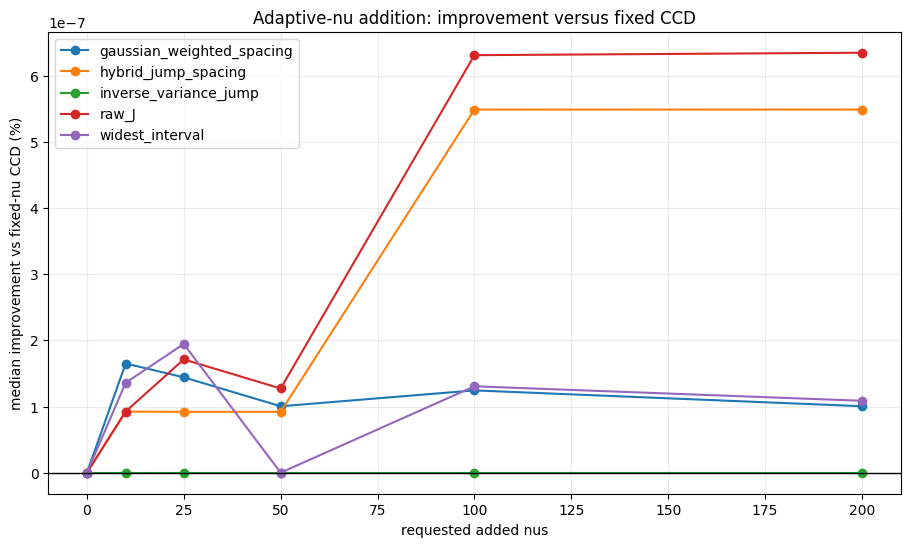

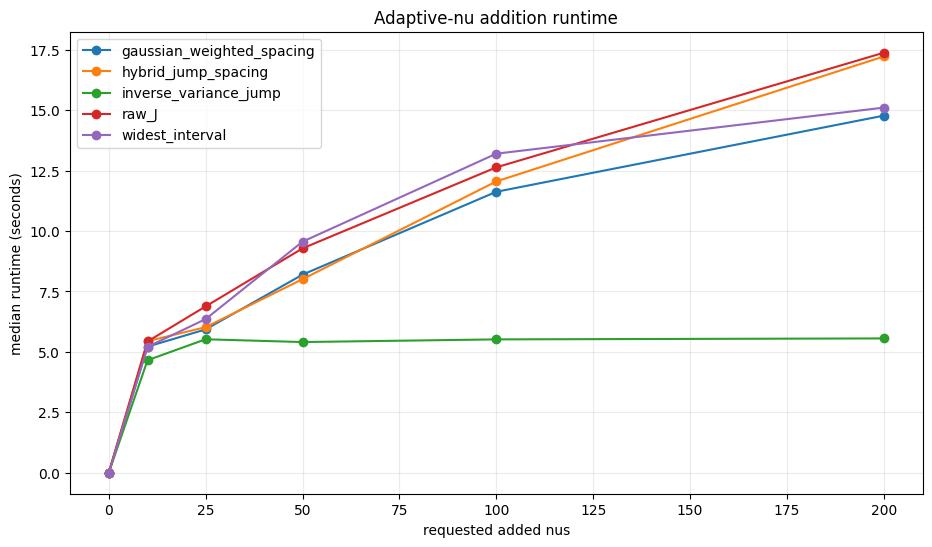

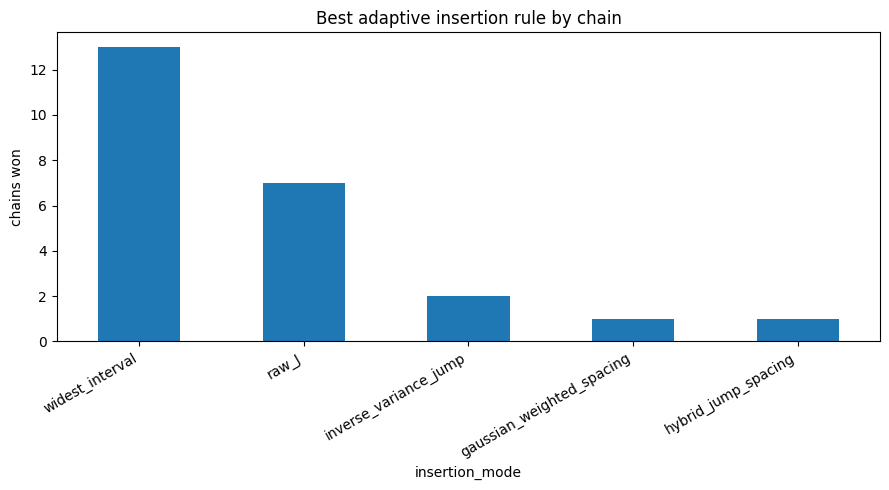

,insertion_mode,requested_added_nus,median_improvement,mean_improvement,median_runtime,median_actual_added,chains
23,raw_J,200,6.346308e-07,0.493813,17.381892,200.0,24
22,raw_J,100,6.309191e-07,0.506328,12.637886,100.0,24
11,hybrid_jump_spacing,200,5.488344e-07,0.476006,17.227292,200.0,24
10,hybrid_jump_spacing,100,5.487467e-07,0.469129,12.055445,100.0,24
26,widest_interval,25,1.945391e-07,0.112561,6.357999,25.0,24
20,raw_J,25,1.712363e-07,0.374398,6.884037,25.0,24
1,gaussian_weighted_spacing,10,1.650319e-07,0.180367,5.218527,10.0,24
2,gaussian_weighted_spacing,25,1.441302e-07,0.224586,5.931425,25.0,24
25,widest_interval,10,1.359666e-07,0.113665,5.209623,10.0,24
28,widest_interval,100,1.306098e-07,0.078594,13.203702,92.0,24


In [61]:
def plot_adaptive_long_results(results):
    if results is None or results.empty:
        print("No adaptive-nu long benchmark results to plot yet.")
        return

    df = results[results["insertion_mode"] != "none"].copy()
    df = df[df["bid_ask_feasible"] == True]
    if df.empty:
        print("No feasible adaptive results to plot yet.")
        return

    summary = (
        df.groupby(["insertion_mode", "requested_added_nus"])
        .agg(
            median_improvement=("improvement_vs_fixed_CCD_pct", "median"),
            mean_improvement=("improvement_vs_fixed_CCD_pct", "mean"),
            median_runtime=("runtime_seconds", "median"),
            median_actual_added=("actual_added_nus", "median"),
            chains=("raw_J", "count"),
        )
        .reset_index()
    )

    plt.figure(figsize=(11, 6))
    for mode, group in summary.groupby("insertion_mode"):
        group = group.sort_values("requested_added_nus")
        plt.plot(group["requested_added_nus"], group["median_improvement"], marker="o", label=mode)
    plt.axhline(0.0, color="black", linewidth=1)
    plt.xlabel("requested added nus")
    plt.ylabel("median improvement vs fixed-nu CCD (%)")
    plt.title("Adaptive-nu addition: improvement versus fixed CCD")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

    plt.figure(figsize=(11, 6))
    for mode, group in summary.groupby("insertion_mode"):
        group = group.sort_values("requested_added_nus")
        plt.plot(group["requested_added_nus"], group["median_runtime"], marker="o", label=mode)
    plt.xlabel("requested added nus")
    plt.ylabel("median runtime (seconds)")
    plt.title("Adaptive-nu addition runtime")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

    best_by_chain = (
        df.sort_values(["date", "exdate", "raw_J"])
        .groupby(["date", "exdate"], as_index=False)
        .first()
    )
    win_counts = best_by_chain["insertion_mode"].value_counts()
    plt.figure(figsize=(9, 5))
    win_counts.plot(kind="bar")
    plt.ylabel("chains won")
    plt.title("Best adaptive insertion rule by chain")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    display(
        summary.sort_values("median_improvement", ascending=False)
        .head(20)
    )


plot_adaptive_long_results(adaptive_long_results)


## Final conclusion and next direction

The fixed-nu benchmark and the augmented-Lagrangian follow-up point to the same conclusion. For the current LVG parameterization, **20,000-step CCD with the regular adjacent-sigma proxy is already very difficult to improve locally**. Across the 100-chain fixed-nu benchmark, the regular CCD method was the most reliable baseline by median raw `J` and by chain-level win count, while the inverse-variance proxy was close but not consistently better. The full-theta augmented-Lagrangian polish was then run after the feasible `CCD_regular` output on a maturity-bucketed 12-chain subset. It was allowed to move both `nu`s and sigmas, and it could temporarily leave the bid-ask band through the augmented penalty formulation, but final acceptance still required bid-ask feasibility, positive sigmas, ordered `nu`s, and lower raw `J`. The result was essentially no additional improvement beyond CCD, which suggests that the remaining roughness is not mainly a failure of the local optimizer.

The most important next research direction is therefore **adaptive `nu` placement / adaptive `nu` addition**, not more polishing of a fixed-dimensional theta. The existing notebooks use three related ideas. First, they identify large raw-`J` jump locations or large sigma/inverse-variance jumps. Second, they insert a new `nu` inside the corresponding interval, usually at a midpoint or shifted interior location, and initialize the new sigma from neighboring sigmas. Third, they rerun sigma-only coordinate descent so the enlarged theta can settle back inside the bid-ask constraints. This is different from reallocation: adding `nu`s increases `R1` or `R2`, gives the LVG curve more local degrees of freedom, and appears more promising than trying to move the same fixed number of knots. The main open question is no longer whether CCD can smooth a fixed set of knots; it is how to choose **where and how many `nu`s to add** across many SPX chains, while tracking the cost of the extra dimensions.

Recommended next steps:

1. Treat `CCD_regular` as the default fixed-nu baseline.
2. Build a clean adaptive-nu benchmark across many chains: run fixed-nu CCD, locate the largest raw-`J` contributors, add `nu`s by a small set of rules, rerun CCD, and report improvement per added `nu`.
3. Compare addition budgets such as `5`, `10`, `25`, `50`, and `100` so we can see where diminishing returns begin.
4. Keep the inverse-variance proxy as a diagnostic comparison, but do not replace the regular proxy unless it wins consistently on feasible raw `J`.
5. Add downstream diagnostics: implied-volatility curves, `C''`, `C''/V`, and eventually multi-maturity behavior, since the research motivation is not only smaller raw `J` but smoother and more stable LVG/local-vol output.

In short: local optimization after CCD appears saturated. The next contribution should be an algorithmic, data-driven rule for adding `nu`s where the LVG curve needs more flexibility, then testing whether that rule generalizes across many option chains.

Step 13 operationalizes this next direction by running a long checkpointed comparison of several adaptive-nu insertion rules.



## Step 14: widest-interval nu insertion after fixed-nu CCD

This final diagnostic tests the exact partner-style widest-interval pipeline on a larger SPX sample.

The pipeline is deliberately kept consistent with the original LVG construction used throughout this notebook:

1. Build adjusted WRDS call bounds with `build_adjusted_chain`.
2. Build the original LVG theta with `build_initial_theta_for_chain`, which calls `load_theta` and therefore runs the analytical-center call construction followed by the LVG interpolation algorithm.
3. Run fixed-nu CCD using the regular adjacent-sigma proxy
   \[
   P_\sigma = \sum_i (\sigma_{i+1}-\sigma_i)^2.
   \]
4. Starting from that post-CCD theta, add nus by repeatedly splitting the current widest interval. The new sigma values are initialized by copying the sigma on the interval being split, so insertion alone does not intentionally create a new sigma jump.
5. Stop before the next split would create child intervals smaller than the original shortest post-CCD interval.
6. Run one final fixed-nu CCD pass on the enlarged theta.

The comparison is always against fixed-nu CCD, not against the original unsmoothed LVG theta. The purpose is to measure whether the added dimensionality improves raw `J` after the sigma curve is re-optimized.


In [62]:

WIDEST_DIAG_OUTPUT_DIR = Path("partner_lvg_private/outputs/multi_chain_widest_interval_diagnostic")
WIDEST_DIAG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WIDEST_DIAG_RESULTS_FILE = WIDEST_DIAG_OUTPUT_DIR / "widest_interval_100_chain_results.csv"
WIDEST_DIAG_SUMMARY_FILE = WIDEST_DIAG_OUTPUT_DIR / "widest_interval_100_chain_summary.csv"

# Smoke mode is useful before launching the long run.
RUN_WIDEST_INTERVAL_DIAGNOSTIC = True
WIDEST_DIAG_FORCE_RERUN = True
WIDEST_DIAG_SMOKE = False
WIDEST_DIAG_MAX_CHAINS = 100
WIDEST_DIAG_SMOKE_CHAINS = 2
WIDEST_DIAG_CCD_ITERATIONS = 20000
WIDEST_DIAG_SMOKE_ITERATIONS = 500
WIDEST_DIAG_MAX_INSERTIONS = 10000



def widest_full_nu_grid(R1, R2, S0, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    return np.concatenate([left_nu, [S0], right_nu])

def insert_widest_once(R1, R2, S0, theta):
    """Split the current widest interval and duplicate its sigma.

    The full grid is [left_nus, S0, right_nus]. There is one sigma per
    interval. Splitting an interval adds one nu and turns one sigma into two
    equal adjacent sigmas, so the insertion itself does not add a sigma jump.
    """
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    full_grid = np.concatenate([left_nu, [S0], right_nu])
    widths = np.diff(full_grid)

    if len(widths) == 0 or not np.all(np.isfinite(widths)):
        return None
    if np.any(widths <= 0):
        return None

    interval_index = int(np.argmax(widths))
    new_nu = 0.5 * (full_grid[interval_index] + full_grid[interval_index + 1])

    if interval_index < R1:
        # Left interval. Insert the new nu into the left wing.
        new_left_nu = np.insert(left_nu, interval_index + 1, new_nu)
        new_left_sigma = np.insert(left_sigma, interval_index + 1, left_sigma[interval_index])
        new_right_nu = right_nu.copy()
        new_right_sigma = right_sigma.copy()
        new_R1 = R1 + 1
        new_R2 = R2
    else:
        # Right interval. interval_index == R1 corresponds to [S0, first right nu].
        local = interval_index - R1
        new_left_nu = left_nu.copy()
        new_left_sigma = left_sigma.copy()
        new_right_nu = np.insert(right_nu, local, new_nu)
        new_right_sigma = np.insert(right_sigma, local + 1, right_sigma[local])
        new_R1 = R1
        new_R2 = R2 + 1

    new_theta = theta_from_parts(new_left_nu, new_left_sigma, new_right_nu, new_right_sigma)
    return new_R1, new_R2, new_theta, interval_index, new_nu, float(widths[interval_index])


def add_widest_until_original_min_width(R1, R2, S0, theta, max_insertions=WIDEST_DIAG_MAX_INSERTIONS):
    """Add nus until splitting the widest interval would go below the original min width."""
    current_R1 = R1
    current_R2 = R2
    current_theta = theta.copy().astype(float)

    original_grid = widest_full_nu_grid(current_R1, current_R2, S0, current_theta)
    original_widths = np.diff(original_grid)
    if len(original_widths) == 0 or np.any(original_widths <= 0):
        raise ValueError("Invalid starting nu grid for widest insertion")

    original_min_width = float(np.min(original_widths))
    insertion_rows = []

    for addition in range(1, max_insertions + 1):
        current_grid = widest_full_nu_grid(current_R1, current_R2, S0, current_theta)
        current_widths = np.diff(current_grid)
        widest_width = float(np.max(current_widths))

        # Stop before the next midpoint split would create child intervals below
        # the original shortest post-CCD interval.
        if 0.5 * widest_width < original_min_width:
            break

        result = insert_widest_once(current_R1, current_R2, S0, current_theta)
        if result is None:
            break

        current_R1, current_R2, current_theta, interval_index, new_nu, split_width = result
        insertion_rows.append({
            "addition": addition,
            "interval_index": interval_index,
            "new_nu": new_nu,
            "split_width": split_width,
            "original_min_width": original_min_width,
            "R1_after": current_R1,
            "R2_after": current_R2,
        })

    insertion_log = pd.DataFrame(insertion_rows)
    return current_R1, current_R2, current_theta, insertion_log


def sigma_squared_curve_for_plot(R1, R2, S0, theta, grid):
    """Compute V(K)/C''(K)=sigma(K)^2 on a plotting grid."""
    c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    values = []
    for k in grid:
        c2 = C2_K(k, R1, R2, S0, theta, c_v1, c_v2)
        if abs(c2) < EPS:
            values.append(np.nan)
        else:
            values.append(V_K(k, R1, R2, S0, theta, c_v1, c_v2) / c2)
    return np.asarray(values, dtype=float)


def run_one_widest_interval_diagnostic_chain(chain, ccd_iterations):
    """Run original LVG -> fixed-nu CCD -> widest insertion -> final CCD for one chain."""
    total_start = time.time()
    S0 = chain["S0"]
    bid_ask_arr = chain["bid_ask"]

    R1_original, R2_original, theta_original = build_initial_theta_for_chain(chain)
    original_J = J_value(R1_original, R2_original, S0, theta_original)

    baseline_start = time.time()
    theta_fixed_ccd, fixed_history, fixed_accepted = coordinate_descent_sigma(
        R1_original,
        R2_original,
        S0,
        theta_original,
        bid_ask_arr,
        proxy_kind="regular",
        update_order="cyclic",
        num_iterations=ccd_iterations,
        record_every=None,
    )
    baseline_runtime = time.time() - baseline_start
    fixed_J = J_value(R1_original, R2_original, S0, theta_fixed_ccd)

    insertion_start = time.time()
    R1_added, R2_added, theta_inserted, insertion_log = add_widest_until_original_min_width(
        R1_original,
        R2_original,
        S0,
        theta_fixed_ccd,
    )
    insertion_runtime = time.time() - insertion_start

    final_start = time.time()
    theta_added_ccd, added_history, added_accepted = coordinate_descent_sigma(
        R1_added,
        R2_added,
        S0,
        theta_inserted,
        bid_ask_arr,
        proxy_kind="regular",
        update_order="cyclic",
        num_iterations=ccd_iterations,
        record_every=None,
    )
    final_runtime = time.time() - final_start

    added_J = J_value(R1_added, R2_added, S0, theta_added_ccd)
    slack = quote_slack_report(R1_added, R2_added, S0, theta_added_ccd, bid_ask_arr)

    row = {
        "date": chain["date"],
        "exdate": chain["exdate"],
        "T": chain["T"],
        "maturity_bucket": maturity_bucket(chain["T"]),
        "original_R1": R1_original,
        "original_R2": R2_original,
        "final_R1": R1_added,
        "final_R2": R2_added,
        "nus_added": int((R1_added + R2_added) - (R1_original + R2_original)),
        "original_raw_J": original_J,
        "fixed_nu_ccd_raw_J": fixed_J,
        "added_nu_ccd_raw_J": added_J,
        "improvement_vs_fixed_ccd_pct": 100.0 * (fixed_J - added_J) / fixed_J if fixed_J > 0 else np.nan,
        "improvement_per_added_nu_pct": 100.0 * (fixed_J - added_J) / fixed_J / max(1, int((R1_added + R2_added) - (R1_original + R2_original))) if fixed_J > 0 else np.nan,
        "baseline_ccd_runtime": baseline_runtime,
        "insertion_runtime": insertion_runtime,
        "final_ccd_runtime": final_runtime,
        "total_runtime": time.time() - total_start,
        "fixed_ccd_accepted_moves": fixed_accepted,
        "added_ccd_accepted_moves": added_accepted,
        "bid_ask_feasible": slack["feasible"],
        "min_quote_slack": slack["min_slack"],
        "min_bid_slack": slack["min_bid_slack"],
        "min_ask_slack": slack["min_ask_slack"],
        "valid_nu_order": check_nu_order(R1_added, R2_added, S0, theta_added_ccd),
        "positive_sigmas": check_positive_sigmas(R1_added, R2_added, theta_added_ccd),
    }

    representatives = {
        "chain": chain,
        "original": (R1_original, R2_original, theta_original),
        "fixed_ccd": (R1_original, R2_original, theta_fixed_ccd),
        "added_ccd": (R1_added, R2_added, theta_added_ccd),
        "insertion_log": insertion_log,
    }
    return row, representatives


def run_widest_interval_100_chain_diagnostic():
    if not RUN_WIDEST_INTERVAL_DIAGNOSTIC:
        print("RUN_WIDEST_INTERVAL_DIAGNOSTIC is False; skipping Step 14.")
        return pd.DataFrame(), {}

    max_chains = WIDEST_DIAG_SMOKE_CHAINS if WIDEST_DIAG_SMOKE else WIDEST_DIAG_MAX_CHAINS
    ccd_iterations = WIDEST_DIAG_SMOKE_ITERATIONS if WIDEST_DIAG_SMOKE else WIDEST_DIAG_CCD_ITERATIONS

    raw = pd.read_csv(find_data_file(DATA_FILE))
    raw["K"] = raw["strike_price"] / 1000.0
    selected = select_chains(raw, max_chains=max_chains, min_strikes=MIN_STRIKES)

    existing = pd.DataFrame()
    if WIDEST_DIAG_RESULTS_FILE.exists() and not WIDEST_DIAG_FORCE_RERUN:
        existing = pd.read_csv(WIDEST_DIAG_RESULTS_FILE)

    rows = []
    representatives = {}
    for _, info in selected.iterrows():
        date = int(info["date"])
        exdate = int(info["exdate"])

        if not existing.empty:
            done = existing[(existing["date"] == date) & (existing["exdate"] == exdate)]
            if len(done) > 0:
                print(f"Skipping completed widest diagnostic chain date={date} exdate={exdate}")
                continue

        print(f"Running widest diagnostic date={date} exdate={exdate} T={float(info['T']):.4f}")
        try:
            chain = build_adjusted_chain(raw, date, exdate, MIN_STRIKES)
            row, rep = run_one_widest_interval_diagnostic_chain(chain, ccd_iterations)
            rows.append(row)
            if len(representatives) < 3:
                representatives[f"{date}_{exdate}"] = rep

            combined = pd.concat([existing, pd.DataFrame(rows)], ignore_index=True)
            combined.to_csv(WIDEST_DIAG_RESULTS_FILE, index=False)
        except Exception as exc:
            print(f"Step 14 failed for date={date}, exdate={exdate}: {exc}")

    results = pd.read_csv(WIDEST_DIAG_RESULTS_FILE) if WIDEST_DIAG_RESULTS_FILE.exists() else pd.DataFrame(rows)
    if results.empty:
        print("No Step 14 widest-interval results were produced.")
        return results, representatives

    summary = results.groupby("maturity_bucket").agg(
        chains=("date", "count"),
        median_improvement_pct=("improvement_vs_fixed_ccd_pct", "median"),
        mean_improvement_pct=("improvement_vs_fixed_ccd_pct", "mean"),
        median_added_nus=("nus_added", "median"),
        median_runtime=("total_runtime", "median"),
        feasibility_rate=("bid_ask_feasible", "mean"),
    ).reset_index()
    summary.to_csv(WIDEST_DIAG_SUMMARY_FILE, index=False)

    print("Step 14 widest-interval diagnostic summary")
    display(summary)
    return results, representatives


widest_diag_results, widest_diag_representatives = run_widest_interval_100_chain_diagnostic()


Running widest diagnostic date=20110103 exdate=20110107 T=0.0159


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running widest diagnostic date=20110103 exdate=20110219 T=0.1389
Running widest diagnostic date=20110103 exdate=20110416 T=0.2976
Running widest diagnostic date=20110103 exdate=20110930 T=0.7698
Running widest diagnostic date=20110131 exdate=20110319 T=0.1389
Running widest diagnostic date=20110202 exdate=20110521 T=0.3095
Running widest diagnostic date=20110202 exdate=20111217 T=0.9048
Running widest diagnostic date=20110214 exdate=20110219 T=0.0198
Running widest diagnostic date=20110301 exdate=20110416 T=0.1349
Running widest diagnostic date=20110303 exdate=20110930 T=0.5992
Running widest diagnostic date=20110308 exdate=20111230 T=0.8452
Running widest diagnostic date=20110321 exdate=20110416 T=0.0794
Running widest diagnostic date=20110405 exdate=20111217 T=0.7302
Running widest diagnostic date=20110406 exdate=20111230 T=0.7619
Running widest diagnostic date=20110408 exdate=20110618 T=0.2024
Running widest diagnostic date=20110428 exdate=20110521 T=0.0675
Running widest diagnostic

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running widest diagnostic date=20110718 exdate=20110917 T=0.1786
Running widest diagnostic date=20110804 exdate=20120629 T=0.9365
Running widest diagnostic date=20110808 exdate=20111217 T=0.3770
Running widest diagnostic date=20110816 exdate=20110917 T=0.0952
Running widest diagnostic date=20110823 exdate=20110917 T=0.0754
Running widest diagnostic date=20110908 exdate=20120616 T=0.8016
Running widest diagnostic date=20110914 exdate=20120330 T=0.5635
Running widest diagnostic date=20110920 exdate=20111119 T=0.1746
Running widest diagnostic date=20110927 exdate=20111022 T=0.0754
Running widest diagnostic date=20111005 exdate=20120922 T=1.0040
Running widest diagnostic date=20111014 exdate=20120317 T=0.4405
Running widest diagnostic date=20111020 exdate=20111230 T=0.2024
Running widest diagnostic date=20111104 exdate=20111119 T=0.0437
Running widest diagnostic date=20111104 exdate=20120928 T=0.9325
Running widest diagnostic date=20111110 exdate=20120317 T=0.3651
Running widest diagnostic

...

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running widest diagnostic date=20121231 exdate=20130125 T=0.0754


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running widest diagnostic date=20121231 exdate=20130328 T=0.2500
Running widest diagnostic date=20121231 exdate=20130628 T=0.5119
Running widest diagnostic date=20121231 exdate=20140118 T=1.0913
Step 14 widest-interval diagnostic summary


,maturity_bucket,chains,median_improvement_pct,mean_improvement_pct,median_added_nus,median_runtime,feasibility_rate
0,long,25,0.323553,16.402774,504.0,51.809176,1.0
1,medium,25,51.367310,48.576570,1586.0,67.990101,1.0
2,short,25,0.444562,19.667742,2534.0,65.739205,1.0
3,very_long,25,0.129859,21.785412,658.0,59.225272,1.0


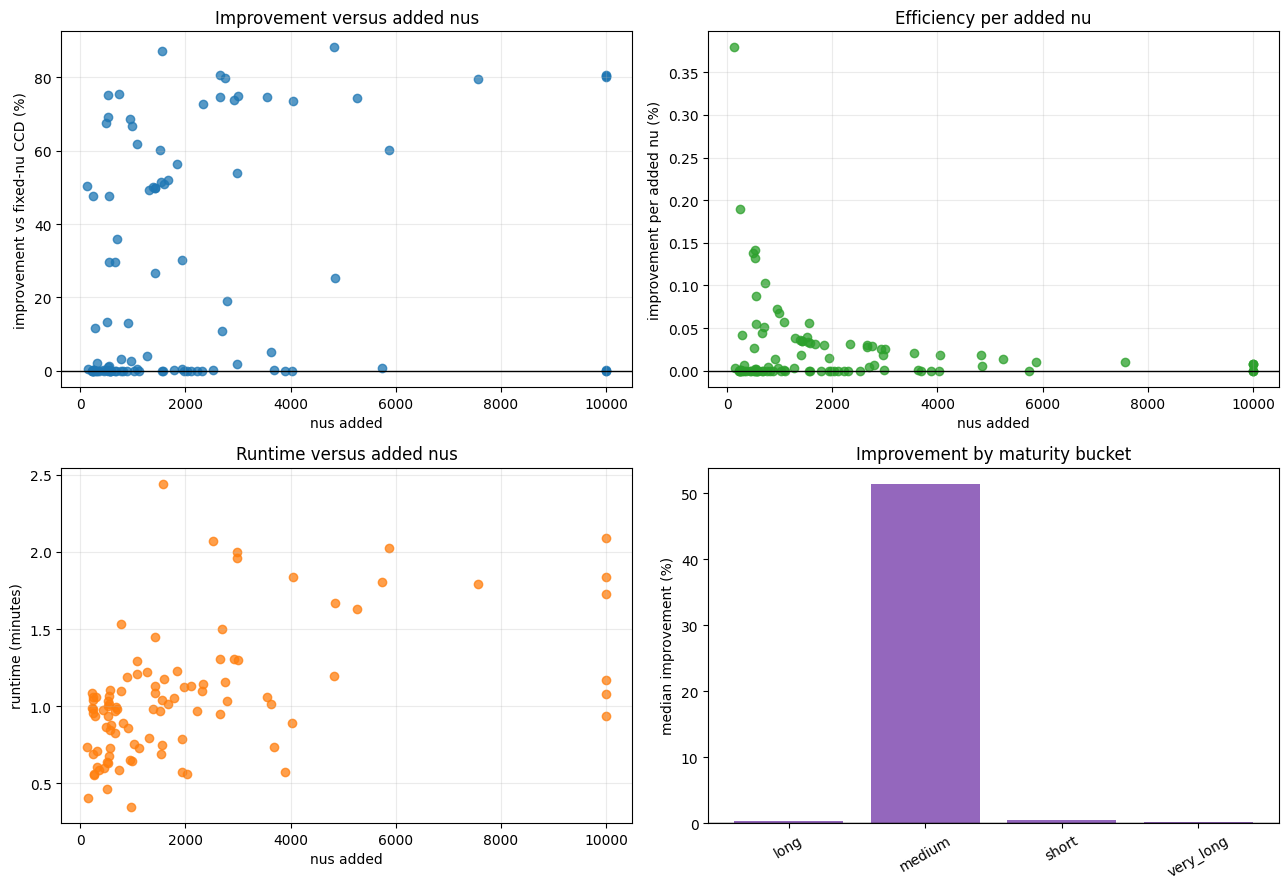

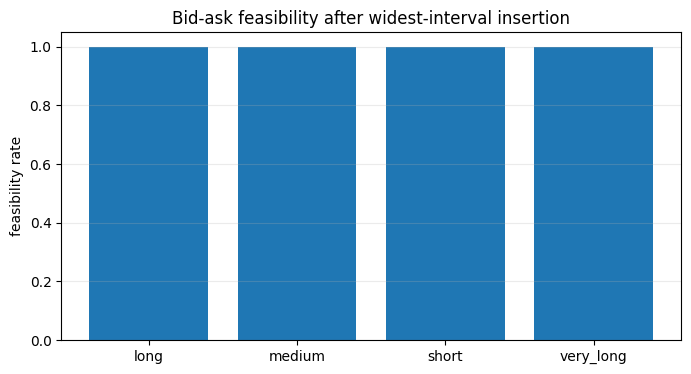

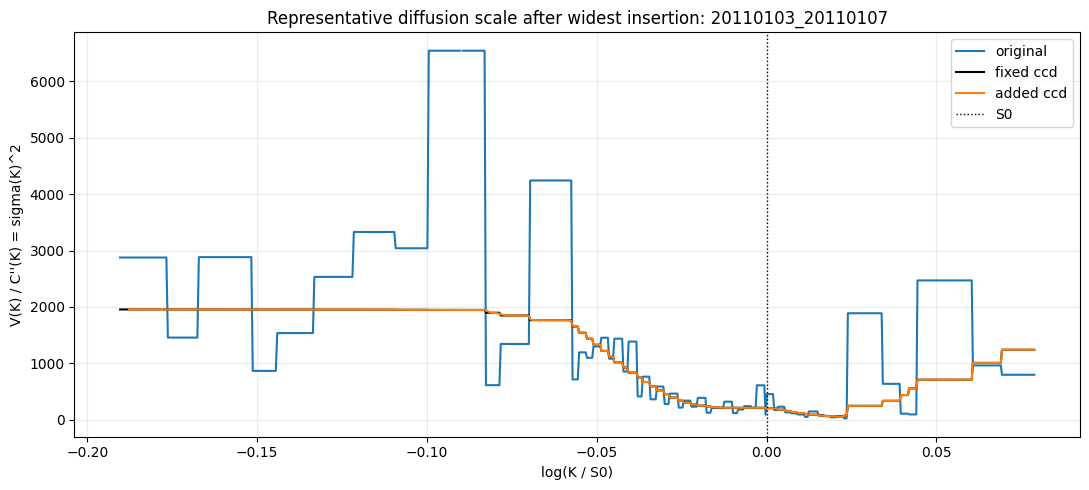

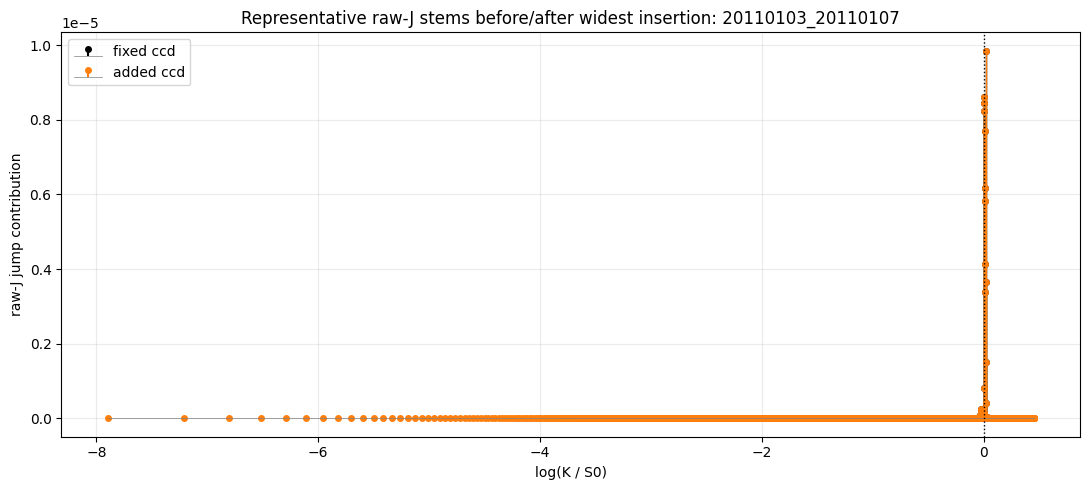

In [63]:

def plot_widest_interval_diagnostic_results(results, representatives):
    if results is None or results.empty:
        print("No widest-interval diagnostic results to plot.")
        return

    feasible = results[results["bid_ask_feasible"] == True].copy()
    plot_data = feasible if not feasible.empty else results.copy()

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    axes[0, 0].scatter(plot_data["nus_added"], plot_data["improvement_vs_fixed_ccd_pct"], alpha=0.75)
    axes[0, 0].axhline(0.0, color="black", linewidth=1)
    axes[0, 0].set_xlabel("nus added")
    axes[0, 0].set_ylabel("improvement vs fixed-nu CCD (%)")
    axes[0, 0].set_title("Improvement versus added nus")
    axes[0, 0].grid(alpha=0.25)

    axes[0, 1].scatter(plot_data["nus_added"], plot_data["improvement_per_added_nu_pct"], alpha=0.75, color="tab:green")
    axes[0, 1].axhline(0.0, color="black", linewidth=1)
    axes[0, 1].set_xlabel("nus added")
    axes[0, 1].set_ylabel("improvement per added nu (%)")
    axes[0, 1].set_title("Efficiency per added nu")
    axes[0, 1].grid(alpha=0.25)

    axes[1, 0].scatter(plot_data["nus_added"], plot_data["total_runtime"] / 60.0, alpha=0.75, color="tab:orange")
    axes[1, 0].set_xlabel("nus added")
    axes[1, 0].set_ylabel("runtime (minutes)")
    axes[1, 0].set_title("Runtime versus added nus")
    axes[1, 0].grid(alpha=0.25)

    bucket_summary = results.groupby("maturity_bucket")["improvement_vs_fixed_ccd_pct"].median().sort_index()
    axes[1, 1].bar(bucket_summary.index.astype(str), bucket_summary.values, color="tab:purple")
    axes[1, 1].axhline(0.0, color="black", linewidth=1)
    axes[1, 1].set_ylabel("median improvement (%)")
    axes[1, 1].set_title("Improvement by maturity bucket")
    axes[1, 1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

    feasibility = results.groupby("maturity_bucket")["bid_ask_feasible"].mean().sort_index()
    plt.figure(figsize=(8, 4))
    plt.bar(feasibility.index.astype(str), feasibility.values)
    plt.ylim(0, 1.05)
    plt.ylabel("feasibility rate")
    plt.title("Bid-ask feasibility after widest-interval insertion")
    plt.grid(axis="y", alpha=0.25)
    plt.show()

    if representatives:
        key = next(iter(representatives))
        rep = representatives[key]
        chain = rep["chain"]
        S0 = chain["S0"]
        K_grid = np.linspace(np.min(chain["K"]), np.max(chain["K"]), 700)
        x_grid = np.log(K_grid / S0)

        plt.figure(figsize=(11, 5))
        for label, color in [
            ("original", "tab:blue"),
            ("fixed_ccd", "black"),
            ("added_ccd", "tab:orange"),
        ]:
            R1_i, R2_i, theta_i = rep[label]
            y = sigma_squared_curve_for_plot(R1_i, R2_i, S0, theta_i, K_grid)
            # Clip extreme finite outliers for readability only.
            finite = np.isfinite(y)
            if finite.any():
                cap = np.nanpercentile(y[finite], 99)
                y = np.where(y > cap, np.nan, y)
            plt.plot(x_grid, y, label=label.replace("_", " "), color=color)
        plt.axvline(0.0, color="black", linestyle=":", linewidth=1, label="S0")
        plt.xlabel("log(K / S0)")
        plt.ylabel("V(K) / C''(K) = sigma(K)^2")
        plt.title(f"Representative diffusion scale after widest insertion: {key}")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(11, 5))
        for label, color in [("fixed_ccd", "black"), ("added_ccd", "tab:orange")]:
            R1_i, R2_i, theta_i = rep[label]
            jumps = jump_contributions_by_knot(R1_i, R2_i, S0, theta_i)
            markerline, stemlines, baseline = plt.stem(
                np.log(jumps["knot"] / S0),
                jumps["jump_squared"],
                label=label.replace("_", " "),
            )
            plt.setp(markerline, color=color, markersize=4)
            plt.setp(stemlines, color=color, linewidth=1)
            plt.setp(baseline, color="gray", linewidth=0.5)
        plt.axvline(0.0, color="black", linestyle=":", linewidth=1)
        plt.xlabel("log(K / S0)")
        plt.ylabel("raw-J jump contribution")
        plt.title(f"Representative raw-J stems before/after widest insertion: {key}")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


plot_widest_interval_diagnostic_results(widest_diag_results, widest_diag_representatives)



## Step 15: inspect representative widest-interval chains

After the 100-chain widest-interval diagnostic has run, this section selects individual chains so we can see *where* the method helped and where it did not. The ranking is based on the final feasible improvement relative to fixed-nu CCD:

\[
\text{improvement} = \frac{J_{\text{fixed CCD}} - J_{\text{widest + CCD}}}{J_{\text{fixed CCD}}}\times 100.
\]

The section selects up to ten chains:

- five chains with the largest feasible improvement,
- five feasible chains whose improvement is closest to zero.

For each selected chain, we reconstruct the same pipeline used in Step 14 so the plots are apples-to-apples: original LVG, fixed-nu CCD, widest-interval insertion, and final CCD on the enlarged grid.


Selected widest-interval case-study chains


,case_type,date,exdate,T,maturity_bucket,nus_added,fixed_nu_ccd_raw_J,added_nu_ccd_raw_J,improvement_vs_fixed_ccd_pct,total_runtime,min_quote_slack
0,largest improvement,20111227,20120922,0.769841,very_long,4820,6.755233e-07,8.018531e-08,8.812990e+01,71.537083,2.198083e-06
1,largest improvement,20121231,20140118,1.091270,very_long,1548,5.290419e-07,6.738507e-08,8.726281e+01,62.263224,1.858258e-04
2,largest improvement,20111110,20120317,0.365079,long,2664,1.033076e-06,1.993288e-07,8.070531e+01,57.127865,6.021579e-06
3,largest improvement,20110816,20110917,0.095238,medium,10000,2.316855e-06,4.512247e-07,8.052426e+01,110.380461,3.507324e-06
4,largest improvement,20120727,20120922,0.162698,medium,10000,2.542982e-06,5.013229e-07,8.028602e+01,125.220146,6.029100e-06
5,small/no improvement,20120816,20120824,0.023810,short,10000,3.969963e-05,3.969963e-05,2.024534e-10,70.006566,-9.999999e-08
6,small/no improvement,20110706,20120317,0.726190,long,1552,8.954706e-07,8.954706e-07,8.199605e-10,45.028023,-9.999997e-08
7,small/no improvement,20110214,20110219,0.019841,short,1568,2.095908e-04,2.095908e-04,-3.214960e-09,146.535949,-9.999954e-08
8,small/no improvement,20121123,20130622,0.599206,long,557,1.056405e-06,1.056405e-06,4.446600e-09,66.467606,-9.999997e-08
9,small/no improvement,20120525,20120601,0.019841,short,2215,4.533992e-05,4.533992e-05,8.175934e-09,58.247985,-1.000000e-07


Rebuilding 10 selected chains with 20000 CCD iterations per CCD pass.


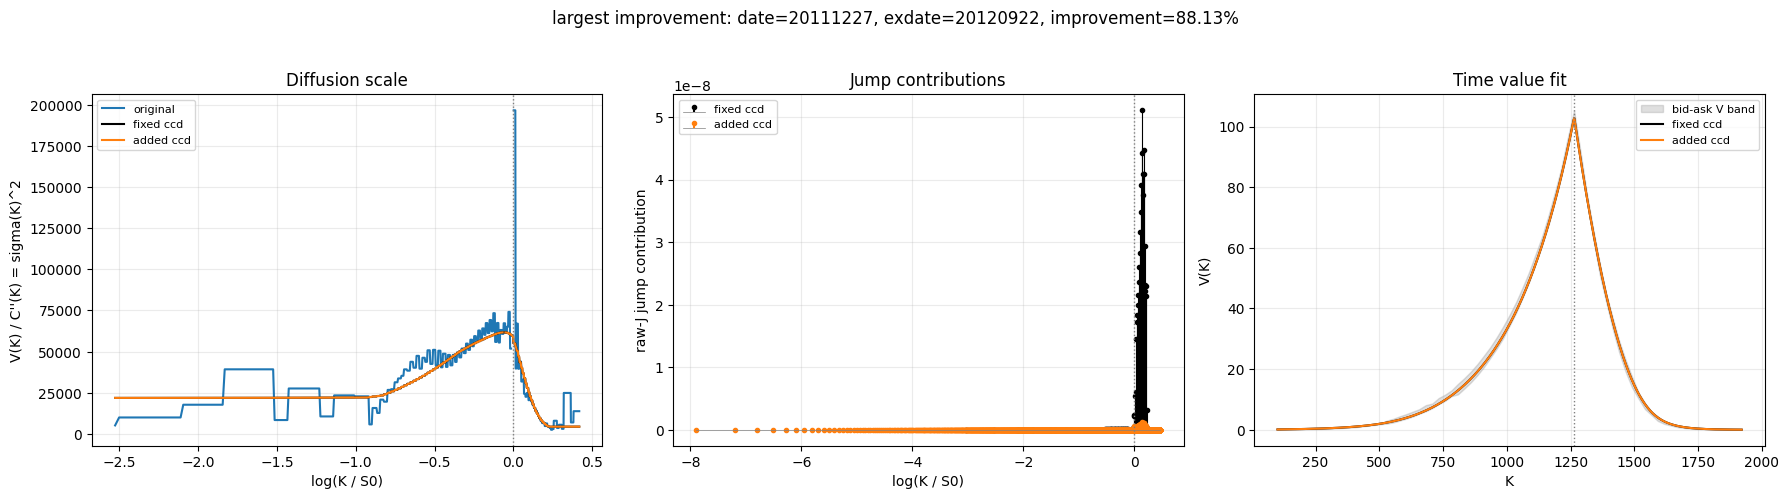

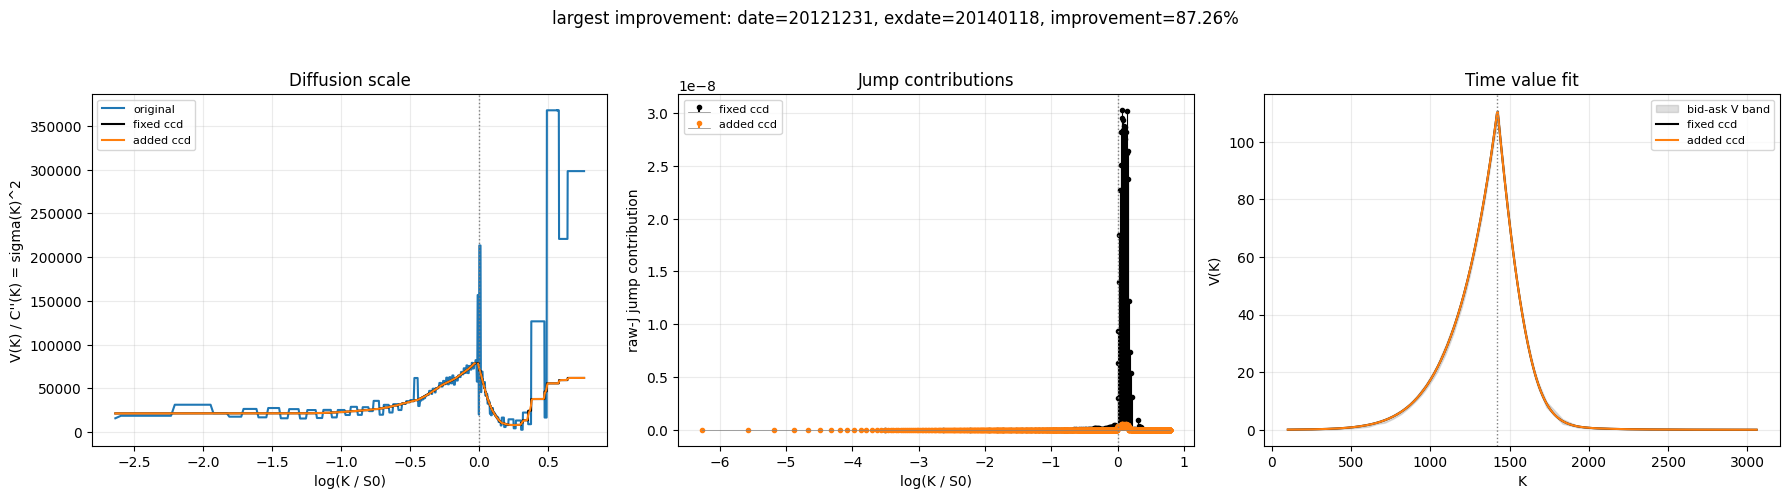

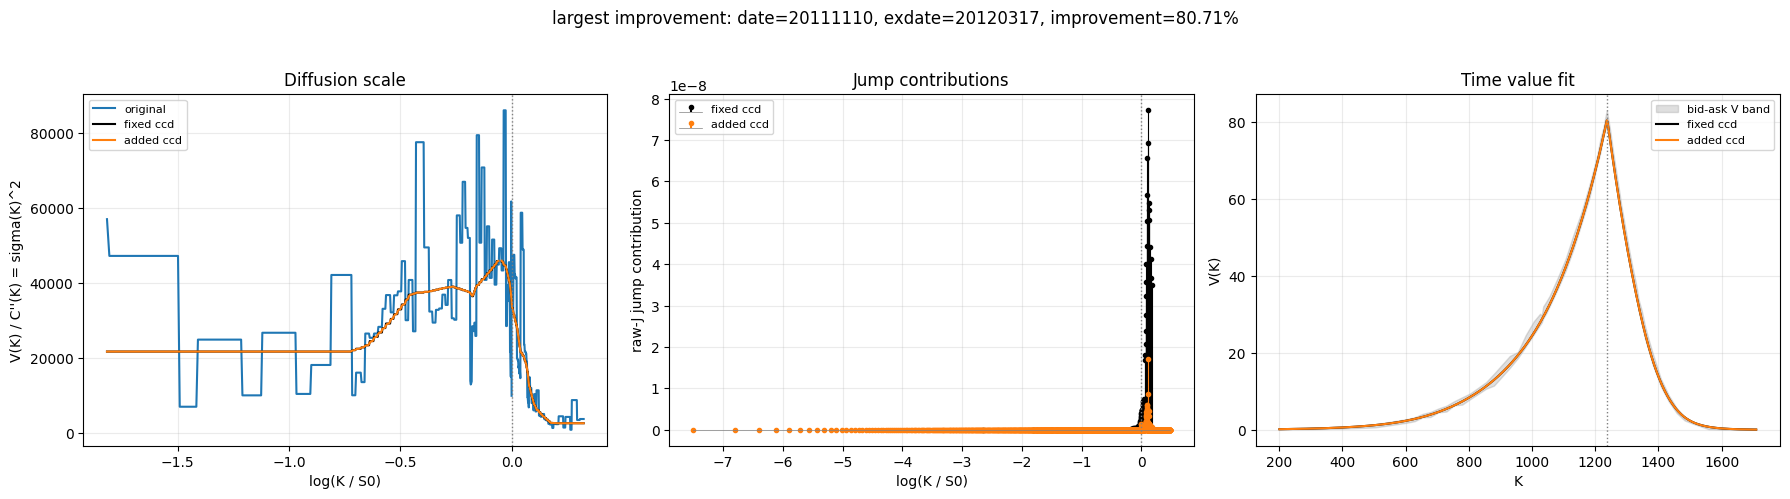

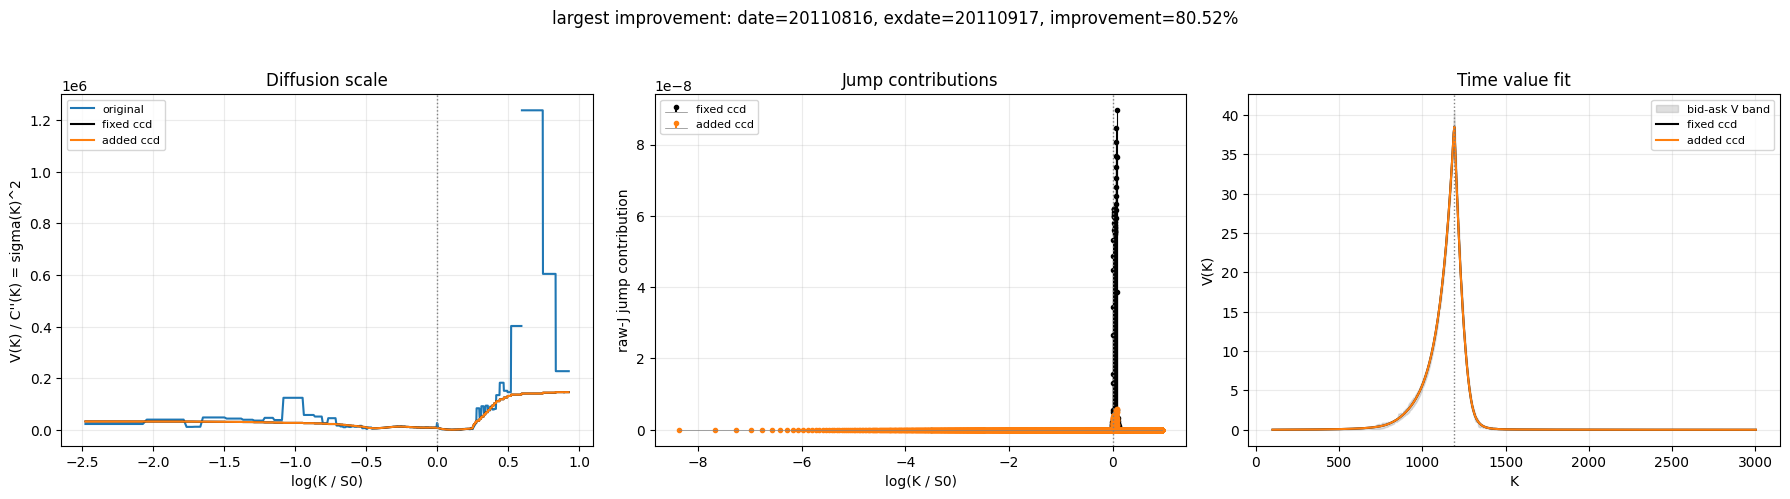

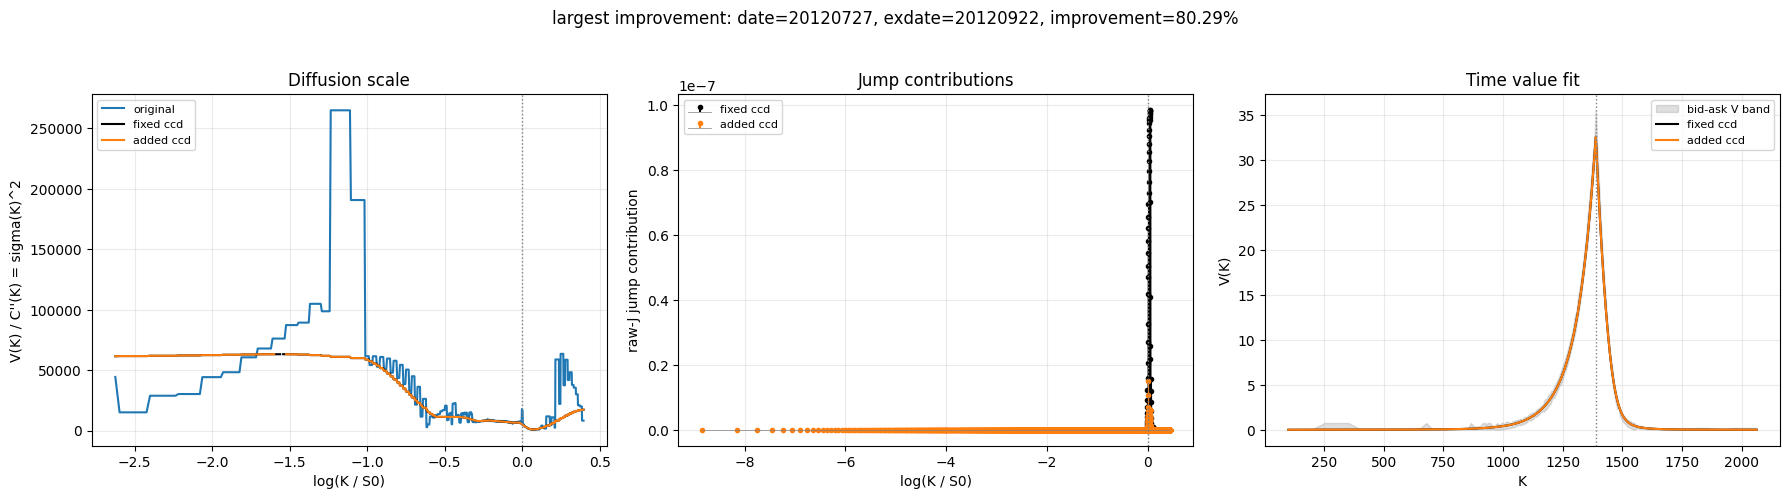

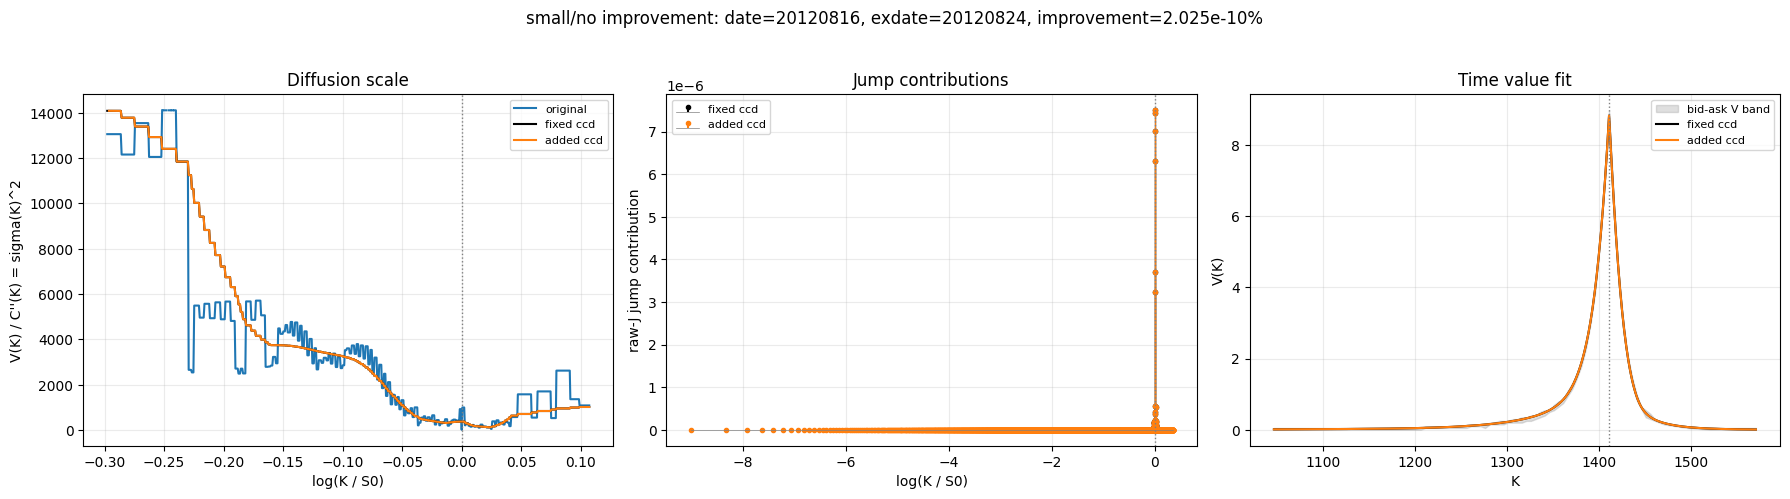

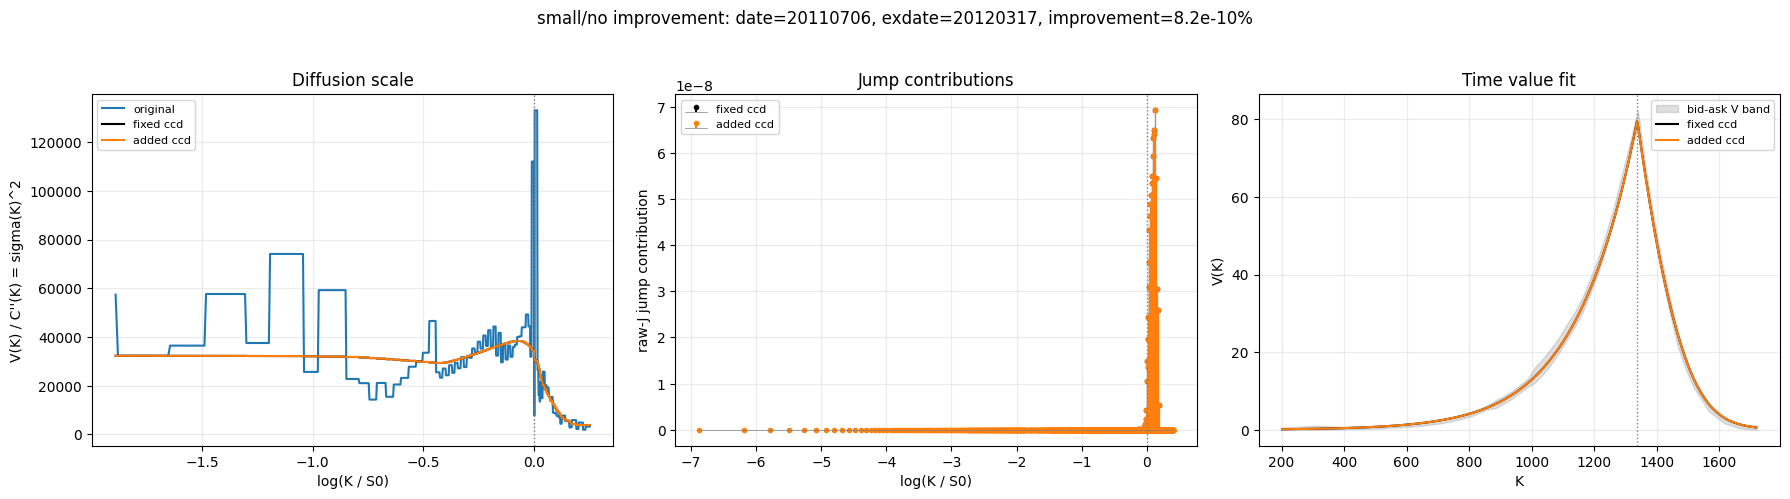

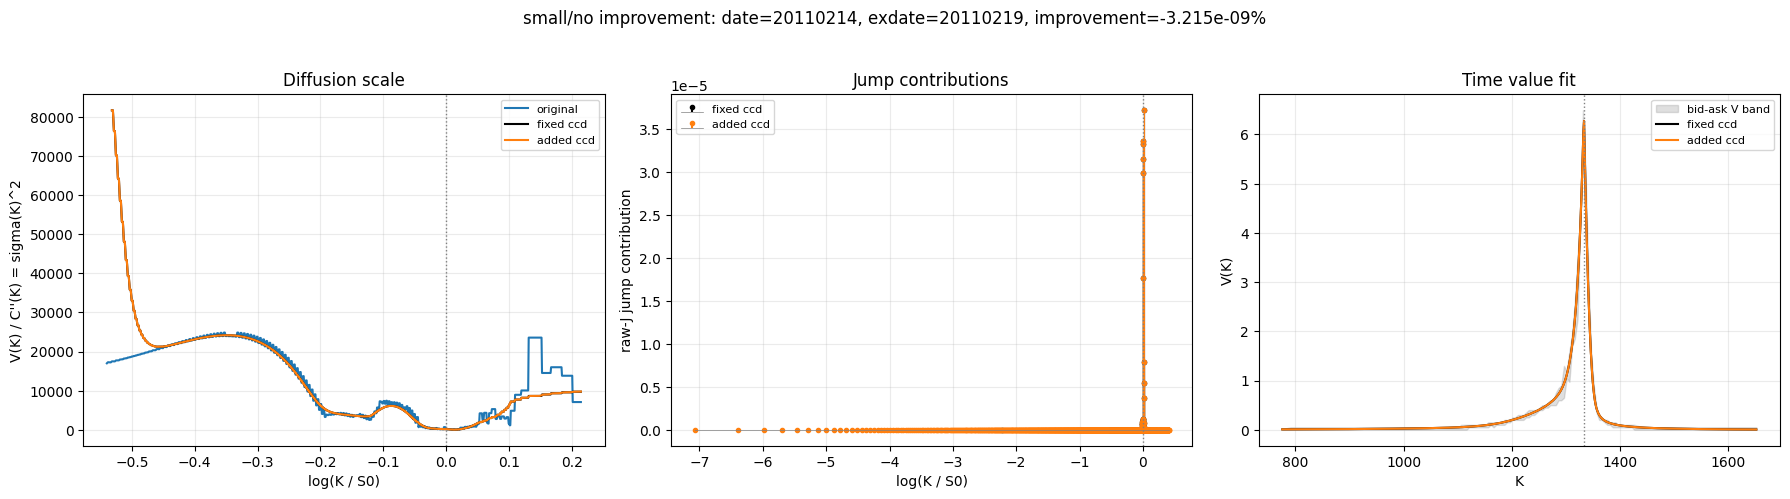

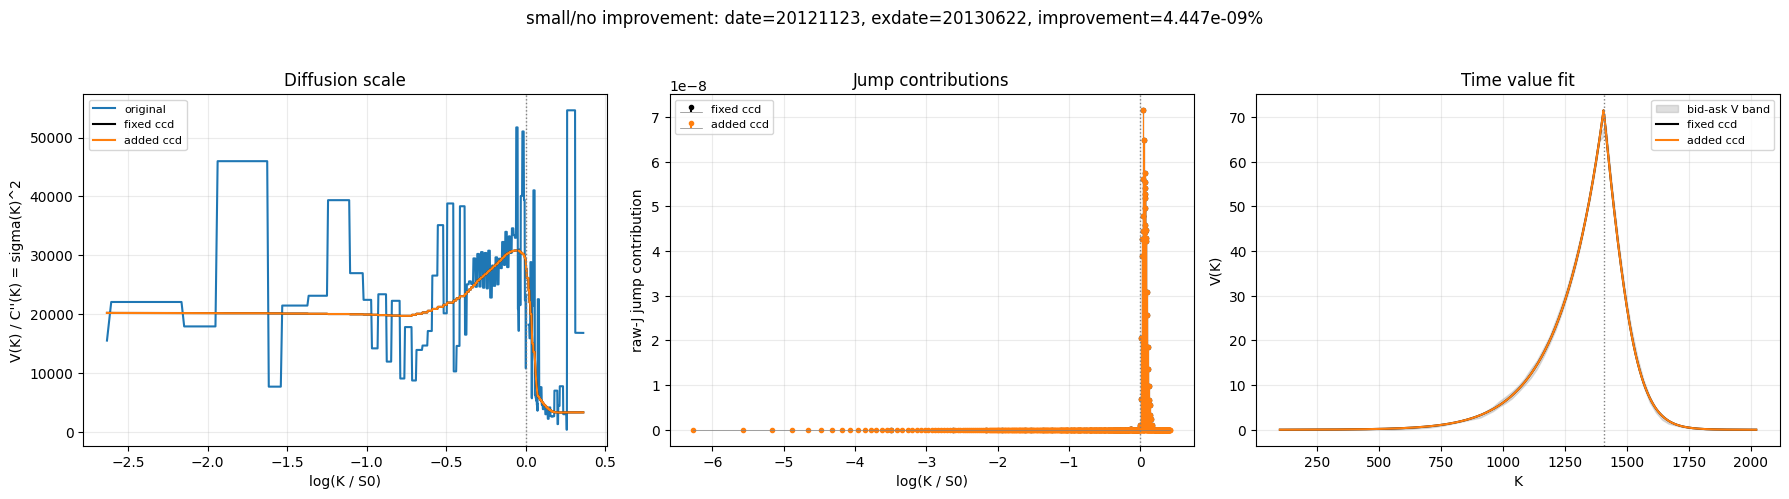

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


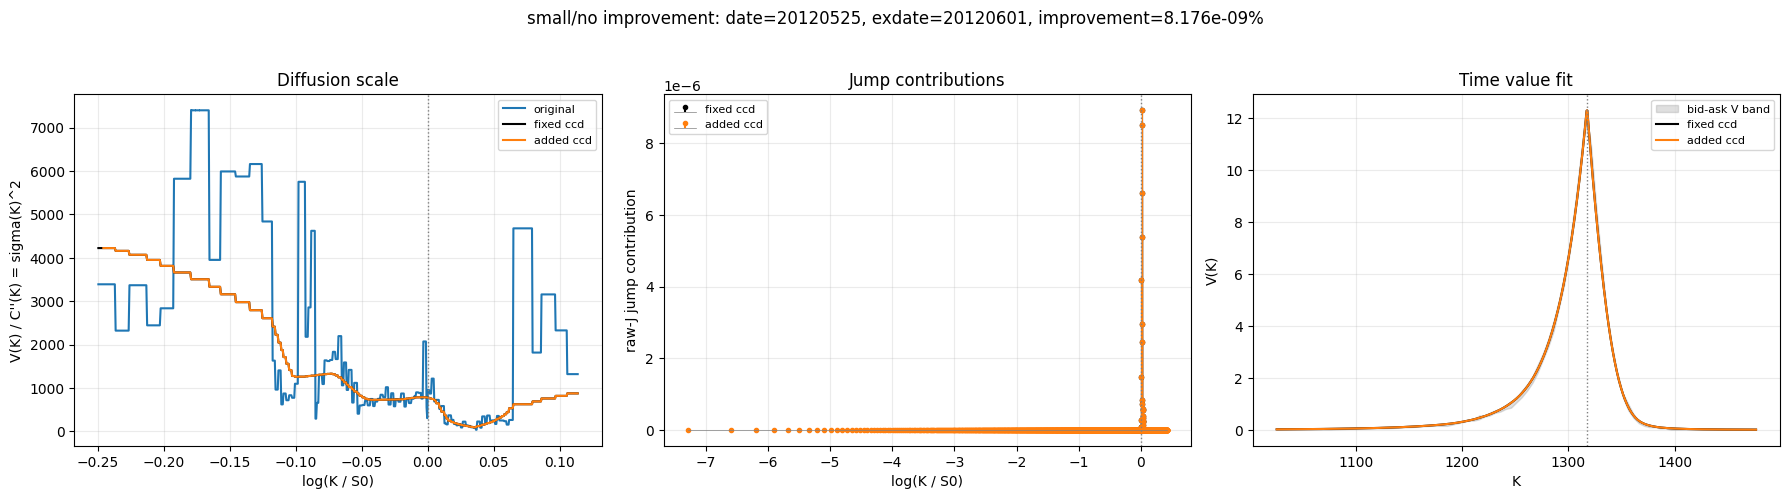

In [64]:

WIDEST_CASE_STUDY_COUNT_PER_GROUP = 5
WIDEST_CASE_STUDY_ITERATIONS = WIDEST_DIAG_CCD_ITERATIONS
WIDEST_CASE_STUDY_SMOKE_ITERATIONS = 500
WIDEST_CASE_STUDY_USE_SMOKE_ITERATIONS = False


def select_widest_case_study_chains(results, per_group=WIDEST_CASE_STUDY_COUNT_PER_GROUP):
    if results is None or results.empty:
        print("No Step 14 results are available yet. Run Step 14 first.")
        return pd.DataFrame()

    feasible = results[results["bid_ask_feasible"] == True].copy()
    if feasible.empty:
        print("No feasible Step 14 results are available to inspect.")
        return pd.DataFrame()

    feasible = feasible.sort_values("improvement_vs_fixed_ccd_pct", ascending=False).reset_index(drop=True)
    high = feasible.head(per_group).copy()
    high["case_type"] = "largest improvement"

    low = feasible.iloc[per_group:].copy() if len(feasible) > per_group else feasible.iloc[0:0].copy()
    if low.empty:
        low = feasible.tail(max(0, min(per_group, len(feasible) - len(high)))).copy()
    else:
        low = low.assign(abs_improvement=low["improvement_vs_fixed_ccd_pct"].abs())
        low = low.sort_values("abs_improvement", ascending=True).head(per_group).drop(columns=["abs_improvement"])
    low["case_type"] = "small/no improvement"

    selected = pd.concat([high, low], ignore_index=True)
    selected = selected.drop_duplicates(["date", "exdate"], keep="first").reset_index(drop=True)

    display_cols = [
        "case_type", "date", "exdate", "T", "maturity_bucket", "nus_added",
        "fixed_nu_ccd_raw_J", "added_nu_ccd_raw_J", "improvement_vs_fixed_ccd_pct",
        "total_runtime", "min_quote_slack",
    ]
    print("Selected widest-interval case-study chains")
    display(selected[display_cols])
    return selected


def rebuild_widest_case_study_chain(date, exdate, iterations):
    raw = pd.read_csv(find_data_file(DATA_FILE))
    raw["K"] = raw["strike_price"] / 1000.0
    chain = build_adjusted_chain(raw, int(date), int(exdate), MIN_STRIKES)
    S0 = chain["S0"]
    bid_ask_arr = chain["bid_ask"]

    R1_original, R2_original, theta_original = build_initial_theta_for_chain(chain)
    theta_fixed_ccd, _, fixed_accepted = coordinate_descent_sigma(
        R1_original,
        R2_original,
        S0,
        theta_original,
        bid_ask_arr,
        proxy_kind="regular",
        update_order="cyclic",
        num_iterations=iterations,
        record_every=None,
    )

    R1_added, R2_added, theta_inserted, insertion_log = add_widest_until_original_min_width(
        R1_original,
        R2_original,
        S0,
        theta_fixed_ccd,
    )
    theta_added_ccd, _, added_accepted = coordinate_descent_sigma(
        R1_added,
        R2_added,
        S0,
        theta_inserted,
        bid_ask_arr,
        proxy_kind="regular",
        update_order="cyclic",
        num_iterations=iterations,
        record_every=None,
    )

    return {
        "chain": chain,
        "original": (R1_original, R2_original, theta_original),
        "fixed_ccd": (R1_original, R2_original, theta_fixed_ccd),
        "added_ccd": (R1_added, R2_added, theta_added_ccd),
        "insertion_log": insertion_log,
        "fixed_accepted": fixed_accepted,
        "added_accepted": added_accepted,
    }


def plot_one_widest_case_study(case_row, rebuilt):
    chain = rebuilt["chain"]
    S0 = chain["S0"]
    K_grid = np.linspace(np.min(chain["K"]), np.max(chain["K"]), 700)
    x_grid = np.log(K_grid / S0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    title = (
        f"{case_row['case_type']}: date={int(case_row['date'])}, exdate={int(case_row['exdate'])}, "
        f"improvement={case_row['improvement_vs_fixed_ccd_pct']:.4g}%"
    )
    fig.suptitle(title, y=1.03)

    # Diffusion scale V/C'' = sigma^2.
    for label, color in [
        ("original", "tab:blue"),
        ("fixed_ccd", "black"),
        ("added_ccd", "tab:orange"),
    ]:
        R1_i, R2_i, theta_i = rebuilt[label]
        y = sigma_squared_curve_for_plot(R1_i, R2_i, S0, theta_i, K_grid)
        finite = np.isfinite(y)
        if finite.any():
            cap = np.nanpercentile(y[finite], 99)
            y = np.where(y > cap, np.nan, y)
        axes[0].plot(x_grid, y, label=label.replace("_", " "), color=color)
    axes[0].axvline(0.0, color="gray", linestyle=":", linewidth=1)
    axes[0].set_xlabel("log(K / S0)")
    axes[0].set_ylabel("V(K) / C''(K) = sigma(K)^2")
    axes[0].set_title("Diffusion scale")
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    # Raw-J stems before and after insertion.
    for label, color in [("fixed_ccd", "black"), ("added_ccd", "tab:orange")]:
        R1_i, R2_i, theta_i = rebuilt[label]
        jumps = jump_contributions_by_knot(R1_i, R2_i, S0, theta_i)
        markerline, stemlines, baseline = axes[1].stem(
            np.log(jumps["knot"] / S0),
            jumps["jump_squared"],
            label=label.replace("_", " "),
        )
        plt.setp(markerline, color=color, markersize=3)
        plt.setp(stemlines, color=color, linewidth=0.8)
        plt.setp(baseline, color="gray", linewidth=0.5)
    axes[1].axvline(0.0, color="gray", linestyle=":", linewidth=1)
    axes[1].set_xlabel("log(K / S0)")
    axes[1].set_ylabel("raw-J jump contribution")
    axes[1].set_title("Jump contributions")
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=8)

    # Time value with bid-ask band in V-space.
    K_q = chain["bid_ask"][:, 0]
    V_bid = chain["bid_ask"][:, 1] - np.maximum(S0 - K_q, 0.0)
    V_ask = chain["bid_ask"][:, 2] - np.maximum(S0 - K_q, 0.0)
    axes[2].fill_between(K_q, V_bid, V_ask, color="gray", alpha=0.25, label="bid-ask V band")
    for label, color in [("fixed_ccd", "black"), ("added_ccd", "tab:orange")]:
        R1_i, R2_i, theta_i = rebuilt[label]
        c_v1, c_v2 = load_c_values(R1_i, R2_i, S0, theta_i)
        V_curve = np.array([V_K(k, R1_i, R2_i, S0, theta_i, c_v1, c_v2) for k in K_grid])
        axes[2].plot(K_grid, V_curve, color=color, label=label.replace("_", " "))
    axes[2].axvline(S0, color="gray", linestyle=":", linewidth=1)
    axes[2].set_xlabel("K")
    axes[2].set_ylabel("V(K)")
    axes[2].set_title("Time value fit")
    axes[2].grid(alpha=0.25)
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_selected_widest_case_studies(results):
    selected = select_widest_case_study_chains(results)
    if selected.empty:
        return selected

    iterations = WIDEST_CASE_STUDY_SMOKE_ITERATIONS if WIDEST_CASE_STUDY_USE_SMOKE_ITERATIONS else WIDEST_CASE_STUDY_ITERATIONS
    print(f"Rebuilding {len(selected)} selected chains with {iterations} CCD iterations per CCD pass.")
    for _, row in selected.iterrows():
        try:
            rebuilt = rebuild_widest_case_study_chain(row["date"], row["exdate"], iterations)
            plot_one_widest_case_study(row, rebuilt)
        except Exception as exc:
            print(f"Could not rebuild/plot date={row['date']} exdate={row['exdate']}: {exc}")
    return selected


widest_case_study_selection = plot_selected_widest_case_studies(widest_diag_results)



## Step 16: raw-J contribution adaptive nu insertion with monotone acceptance

This overnight diagnostic tests a concrete raw-J based nu-addition rule. The method starts from the canonical LVG theta and fixed-nu `CCD_regular` result, then adds nus only when the new enlarged grid can be locally smoothed without increasing raw `J` or violating bid-ask constraints.

The interval score is

\[
\text{score}_i = J_i (\Delta \nu_i)^\beta,
\]

where `J_i` is the raw-J contribution assigned to interval `i`, and `Delta nu_i` is the interval width. The parameter `beta` controls the balance:

- `beta = 0`: pure raw-J targeting,
- `beta = 0.5`: raw-J targeting with mild width control,
- `beta = 1`: balanced raw-J and width,
- `beta = 2`: stronger penalty against splitting already tight intervals.

For each proposed insertion, the new sigma is initialized by copying the split interval's sigma. Then a short CCD cleanup is run. The insertion is accepted only if all of the following are true:

1. nu ordering remains valid,
2. all sigmas remain positive,
3. bid-ask feasibility remains true,
4. raw `J` decreases relative to the current accepted theta.

This makes the accepted path monotone in feasible raw `J`. A final 20,000-step CCD cleanup is attempted after the accepted insertions. If that final cleanup worsens raw `J` or breaks feasibility, the algorithm keeps the pre-final accepted theta instead.


In [65]:

RAWJ_ADAPT_OUTPUT_DIR = Path("partner_lvg_private/outputs/rawJ_monotone_adaptive_nu")
RAWJ_ADAPT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RAWJ_ADAPT_RESULTS_FILE = RAWJ_ADAPT_OUTPUT_DIR / "rawJ_monotone_adaptive_results.csv"
RAWJ_ADAPT_LOG_FILE = RAWJ_ADAPT_OUTPUT_DIR / "rawJ_monotone_adaptive_insertion_log.csv"
RAWJ_ADAPT_SUMMARY_FILE = RAWJ_ADAPT_OUTPUT_DIR / "rawJ_monotone_adaptive_summary.csv"

RUN_RAWJ_MONOTONE_ADAPTIVE = True
RAWJ_ADAPT_FORCE_RERUN = False
RAWJ_ADAPT_SMOKE = False
RAWJ_ADAPT_MAX_CHAINS = 100
RAWJ_ADAPT_SMOKE_CHAINS = 2
RAWJ_ADAPT_BETAS = [0.0, 0.5, 1.0, 2.0]
RAWJ_ADAPT_MAX_ADDED_NUS = 100
RAWJ_ADAPT_SMOKE_MAX_ADDED_NUS = 5
RAWJ_ADAPT_BASE_CCD_ITERATIONS = 20000
RAWJ_ADAPT_FINAL_CCD_ITERATIONS = 20000
RAWJ_ADAPT_SHORT_CCD_ITERATIONS = 500
RAWJ_ADAPT_SMOKE_CCD_ITERATIONS = 100
RAWJ_ADAPT_TAU = 1e-4
RAWJ_ADAPT_PATIENCE = 5
RAWJ_ADAPT_MIN_ABS_IMPROVEMENT = 1e-16
RAWJ_ADAPT_MAX_CANDIDATES_PER_INSERTION = 12


def rawj_full_nu_grid(R1, R2, S0, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    return np.concatenate([left_nu, [S0], right_nu])


def rawj_interval_sigmas(R1, R2, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    return np.concatenate([left_sigma, right_sigma])


def insert_one_nu_in_interval(R1, R2, S0, theta, interval_index):
    """Split interval_index in [left_nus, S0, right_nus] and duplicate its sigma."""
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    full_grid = rawj_full_nu_grid(R1, R2, S0, theta)
    if interval_index < 0 or interval_index >= len(full_grid) - 1:
        return None

    new_nu = 0.5 * (full_grid[interval_index] + full_grid[interval_index + 1])
    if not np.isfinite(new_nu):
        return None

    if interval_index < R1:
        new_left_nu = np.insert(left_nu, interval_index + 1, new_nu)
        new_left_sigma = np.insert(left_sigma, interval_index + 1, left_sigma[interval_index])
        new_right_nu = right_nu.copy()
        new_right_sigma = right_sigma.copy()
        new_R1 = R1 + 1
        new_R2 = R2
    else:
        local = interval_index - R1
        new_left_nu = left_nu.copy()
        new_left_sigma = left_sigma.copy()
        new_right_nu = np.insert(right_nu, local, new_nu)
        new_right_sigma = np.insert(right_sigma, local + 1, right_sigma[local])
        new_R1 = R1
        new_R2 = R2 + 1

    new_theta = theta_from_parts(new_left_nu, new_left_sigma, new_right_nu, new_right_sigma)
    return new_R1, new_R2, new_theta, new_nu


def rawj_contribution_scores_by_interval(R1, R2, S0, theta):
    """Assign raw-J knot contributions to neighboring intervals.

    Each jump lives at a knot, which is a boundary between two intervals. We split
    its contribution across the adjacent intervals in proportion to interval width.
    This lets a wide interval beside a large jump receive priority, while still
    avoiding pure over-concentration in already tiny intervals.
    """
    full_grid = rawj_full_nu_grid(R1, R2, S0, theta)
    widths = np.diff(full_grid)
    scores = np.zeros(len(widths), dtype=float)
    jumps = jump_contributions_by_knot(R1, R2, S0, theta)

    for _, row in jumps.iterrows():
        knot = float(row["knot"])
        jump_value = float(row["jump_squared"])
        boundary_index = int(np.argmin(np.abs(full_grid - knot)))
        adjacent = []
        if boundary_index - 1 >= 0:
            adjacent.append(boundary_index - 1)
        if boundary_index < len(widths):
            adjacent.append(boundary_index)
        if not adjacent:
            continue
        width_sum = sum(widths[i] for i in adjacent if widths[i] > 0)
        if width_sum <= 0:
            continue
        for i in adjacent:
            if widths[i] > 0:
                scores[i] += jump_value * widths[i] / width_sum
    return scores


def rawj_width_priority_intervals(R1, R2, S0, theta, beta):
    full_grid = rawj_full_nu_grid(R1, R2, S0, theta)
    widths = np.diff(full_grid)
    rawj_scores = rawj_contribution_scores_by_interval(R1, R2, S0, theta)
    scores = rawj_scores * np.maximum(widths, 0.0) ** beta

    valid = []
    for i, score in enumerate(scores):
        if i == R1 - 1:
            # Avoid directly splitting the interval immediately ending at S0 on the left.
            # The right-side [S0, first right nu] interval remains eligible.
            continue
        if np.isfinite(score) and score > 0 and widths[i] > 0:
            valid.append((i, score, widths[i], rawj_scores[i]))
    valid.sort(key=lambda x: x[1], reverse=True)
    return valid


def try_one_rawj_adaptive_insertion(R1, R2, S0, theta, bid_ask_arr, beta, short_iterations, current_J):
    priorities = rawj_width_priority_intervals(R1, R2, S0, theta, beta)
    attempted = 0

    for interval_index, score, width, rawj_score in priorities[:RAWJ_ADAPT_MAX_CANDIDATES_PER_INSERTION]:
        attempted += 1
        inserted = insert_one_nu_in_interval(R1, R2, S0, theta, interval_index)
        if inserted is None:
            continue
        cand_R1, cand_R2, cand_theta, new_nu = inserted
        if not check_nu_order(cand_R1, cand_R2, S0, cand_theta):
            continue
        if not check_positive_sigmas(cand_R1, cand_R2, cand_theta):
            continue
        if not quote_slack_report(cand_R1, cand_R2, S0, cand_theta, bid_ask_arr)["feasible"]:
            continue

        smoothed_theta, _, accepted_moves = coordinate_descent_sigma(
            cand_R1,
            cand_R2,
            S0,
            cand_theta,
            bid_ask_arr,
            proxy_kind="regular",
            update_order="cyclic",
            num_iterations=short_iterations,
            record_every=None,
        )

        if not check_nu_order(cand_R1, cand_R2, S0, smoothed_theta):
            continue
        if not check_positive_sigmas(cand_R1, cand_R2, smoothed_theta):
            continue
        slack = quote_slack_report(cand_R1, cand_R2, S0, smoothed_theta, bid_ask_arr)
        if not slack["feasible"]:
            continue

        new_J = J_value(cand_R1, cand_R2, S0, smoothed_theta)
        improvement = current_J - new_J
        required = max(RAWJ_ADAPT_MIN_ABS_IMPROVEMENT, abs(current_J) * 1e-12)
        if improvement > required:
            return {
                "accepted": True,
                "R1": cand_R1,
                "R2": cand_R2,
                "theta": smoothed_theta,
                "new_nu": new_nu,
                "interval_index": interval_index,
                "score": score,
                "rawj_interval_score": rawj_score,
                "interval_width": width,
                "old_J": current_J,
                "new_J": new_J,
                "improvement": improvement,
                "relative_improvement": improvement / current_J if current_J > 0 else np.nan,
                "short_ccd_accepted_moves": accepted_moves,
                "attempted_candidates": attempted,
                "min_slack": slack["min_slack"],
            }

    return {"accepted": False, "attempted_candidates": attempted}


def run_rawj_monotone_adaptive_for_chain(chain, beta, max_added, base_iterations, short_iterations, final_iterations):
    total_start = time.time()
    S0 = chain["S0"]
    bid_ask_arr = chain["bid_ask"]

    R1_original, R2_original, theta_original = build_initial_theta_for_chain(chain)
    original_J = J_value(R1_original, R2_original, S0, theta_original)

    base_start = time.time()
    theta_fixed, _, base_accepted = coordinate_descent_sigma(
        R1_original,
        R2_original,
        S0,
        theta_original,
        bid_ask_arr,
        proxy_kind="regular",
        update_order="cyclic",
        num_iterations=base_iterations,
        record_every=None,
    )
    base_runtime = time.time() - base_start

    current_R1 = R1_original
    current_R2 = R2_original
    current_theta = theta_fixed.copy()
    fixed_J = J_value(current_R1, current_R2, S0, current_theta)
    current_J = fixed_J
    insertion_rows = []
    recent_relative_gains = []
    stopped_reason = "max_added_nus"

    insertion_start = time.time()
    for addition in range(1, max_added + 1):
        result = try_one_rawj_adaptive_insertion(
            current_R1,
            current_R2,
            S0,
            current_theta,
            bid_ask_arr,
            beta,
            short_iterations,
            current_J,
        )
        if not result["accepted"]:
            stopped_reason = "no_feasible_rawJ_improving_candidate"
            insertion_rows.append({
                "date": chain["date"],
                "exdate": chain["exdate"],
                "beta": beta,
                "addition": addition,
                "accepted": False,
                "reason": stopped_reason,
                "attempted_candidates": result.get("attempted_candidates", 0),
                "old_J": current_J,
                "new_J": current_J,
                "relative_improvement": 0.0,
            })
            break

        current_R1 = result["R1"]
        current_R2 = result["R2"]
        current_theta = result["theta"]
        current_J = result["new_J"]
        recent_relative_gains.append(result["relative_improvement"])

        insertion_rows.append({
            "date": chain["date"],
            "exdate": chain["exdate"],
            "beta": beta,
            "addition": addition,
            "accepted": True,
            "reason": "accepted",
            "new_nu": result["new_nu"],
            "interval_index": result["interval_index"],
            "interval_width": result["interval_width"],
            "score": result["score"],
            "rawj_interval_score": result["rawj_interval_score"],
            "old_J": result["old_J"],
            "new_J": result["new_J"],
            "improvement": result["improvement"],
            "relative_improvement": result["relative_improvement"],
            "short_ccd_accepted_moves": result["short_ccd_accepted_moves"],
            "attempted_candidates": result["attempted_candidates"],
            "min_slack": result["min_slack"],
        })

        if len(recent_relative_gains) >= RAWJ_ADAPT_PATIENCE:
            recent_average = float(np.mean(recent_relative_gains[-RAWJ_ADAPT_PATIENCE:]))
            if recent_average < RAWJ_ADAPT_TAU:
                stopped_reason = "patience_marginal_gain_below_tau"
                break
    insertion_runtime = time.time() - insertion_start

    pre_final_R1 = current_R1
    pre_final_R2 = current_R2
    pre_final_theta = current_theta.copy()
    pre_final_J = current_J

    final_start = time.time()
    final_theta, _, final_accepted = coordinate_descent_sigma(
        current_R1,
        current_R2,
        S0,
        current_theta,
        bid_ask_arr,
        proxy_kind="regular",
        update_order="cyclic",
        num_iterations=final_iterations,
        record_every=None,
    )
    final_runtime = time.time() - final_start

    final_slack = quote_slack_report(current_R1, current_R2, S0, final_theta, bid_ask_arr)
    final_J = J_value(current_R1, current_R2, S0, final_theta)
    used_final_cleanup = bool(
        final_slack["feasible"]
        and check_nu_order(current_R1, current_R2, S0, final_theta)
        and check_positive_sigmas(current_R1, current_R2, final_theta)
        and final_J <= pre_final_J + max(RAWJ_ADAPT_MIN_ABS_IMPROVEMENT, abs(pre_final_J) * 1e-12)
    )

    if used_final_cleanup:
        accepted_theta = final_theta
        accepted_J = final_J
        accepted_slack = final_slack
    else:
        accepted_theta = pre_final_theta
        accepted_J = pre_final_J
        accepted_slack = quote_slack_report(pre_final_R1, pre_final_R2, S0, pre_final_theta, bid_ask_arr)
        current_R1 = pre_final_R1
        current_R2 = pre_final_R2

    added_nus = int((current_R1 + current_R2) - (R1_original + R2_original))
    row = {
        "date": chain["date"],
        "exdate": chain["exdate"],
        "T": chain["T"],
        "maturity_bucket": maturity_bucket(chain["T"]),
        "beta": beta,
        "original_R1": R1_original,
        "original_R2": R2_original,
        "final_R1": current_R1,
        "final_R2": current_R2,
        "nus_added": added_nus,
        "stopped_reason": stopped_reason,
        "original_raw_J": original_J,
        "fixed_nu_ccd_raw_J": fixed_J,
        "pre_final_raw_J": pre_final_J,
        "final_raw_J": accepted_J,
        "improvement_vs_fixed_ccd_pct": 100.0 * (fixed_J - accepted_J) / fixed_J if fixed_J > 0 else np.nan,
        "improvement_per_added_nu_pct": 100.0 * (fixed_J - accepted_J) / fixed_J / max(1, added_nus) if fixed_J > 0 else np.nan,
        "base_ccd_runtime": base_runtime,
        "insertion_runtime": insertion_runtime,
        "final_ccd_runtime": final_runtime,
        "total_runtime": time.time() - total_start,
        "base_ccd_accepted_moves": base_accepted,
        "final_ccd_accepted_moves": final_accepted,
        "used_final_cleanup": used_final_cleanup,
        "bid_ask_feasible": accepted_slack["feasible"],
        "min_quote_slack": accepted_slack["min_slack"],
        "min_bid_slack": accepted_slack["min_bid_slack"],
        "min_ask_slack": accepted_slack["min_ask_slack"],
        "valid_nu_order": check_nu_order(current_R1, current_R2, S0, accepted_theta),
        "positive_sigmas": check_positive_sigmas(current_R1, current_R2, accepted_theta),
    }
    return row, pd.DataFrame(insertion_rows)


def rawj_adaptive_done(existing, date, exdate, beta):
    if existing.empty:
        return False
    rows = existing[(existing["date"] == date) & (existing["exdate"] == exdate) & (np.isclose(existing["beta"], beta))]
    return len(rows) > 0


def run_rawj_monotone_adaptive_experiment():
    if not RUN_RAWJ_MONOTONE_ADAPTIVE:
        print("RUN_RAWJ_MONOTONE_ADAPTIVE is False; skipping Step 16.")
        return pd.DataFrame(), pd.DataFrame()

    max_chains = RAWJ_ADAPT_SMOKE_CHAINS if RAWJ_ADAPT_SMOKE else RAWJ_ADAPT_MAX_CHAINS
    max_added = RAWJ_ADAPT_SMOKE_MAX_ADDED_NUS if RAWJ_ADAPT_SMOKE else RAWJ_ADAPT_MAX_ADDED_NUS
    base_iterations = RAWJ_ADAPT_SMOKE_CCD_ITERATIONS if RAWJ_ADAPT_SMOKE else RAWJ_ADAPT_BASE_CCD_ITERATIONS
    short_iterations = RAWJ_ADAPT_SMOKE_CCD_ITERATIONS if RAWJ_ADAPT_SMOKE else RAWJ_ADAPT_SHORT_CCD_ITERATIONS
    final_iterations = RAWJ_ADAPT_SMOKE_CCD_ITERATIONS if RAWJ_ADAPT_SMOKE else RAWJ_ADAPT_FINAL_CCD_ITERATIONS

    raw = pd.read_csv(find_data_file(DATA_FILE))
    raw["K"] = raw["strike_price"] / 1000.0
    selected = select_chains(raw, max_chains=max_chains, min_strikes=MIN_STRIKES)

    existing_results = pd.DataFrame()
    existing_log = pd.DataFrame()
    if RAWJ_ADAPT_RESULTS_FILE.exists() and not RAWJ_ADAPT_FORCE_RERUN:
        existing_results = pd.read_csv(RAWJ_ADAPT_RESULTS_FILE)
    if RAWJ_ADAPT_LOG_FILE.exists() and not RAWJ_ADAPT_FORCE_RERUN:
        existing_log = pd.read_csv(RAWJ_ADAPT_LOG_FILE)

    rows = []
    logs = []
    for _, info in selected.iterrows():
        date = int(info["date"])
        exdate = int(info["exdate"])
        for beta in RAWJ_ADAPT_BETAS:
            if rawj_adaptive_done(existing_results, date, exdate, beta):
                print(f"Skipping completed raw-J adaptive date={date} exdate={exdate} beta={beta}")
                continue
            print(f"Running raw-J adaptive date={date} exdate={exdate} beta={beta} T={float(info['T']):.4f}")
            try:
                chain = build_adjusted_chain(raw, date, exdate, MIN_STRIKES)
                row, log = run_rawj_monotone_adaptive_for_chain(
                    chain,
                    beta,
                    max_added=max_added,
                    base_iterations=base_iterations,
                    short_iterations=short_iterations,
                    final_iterations=final_iterations,
                )
                rows.append(row)
                if not log.empty:
                    logs.append(log)

                combined_results = pd.concat([existing_results, pd.DataFrame(rows)], ignore_index=True)
                combined_results.to_csv(RAWJ_ADAPT_RESULTS_FILE, index=False)
                if logs:
                    combined_log = pd.concat([existing_log] + logs, ignore_index=True)
                    combined_log.to_csv(RAWJ_ADAPT_LOG_FILE, index=False)
            except Exception as exc:
                print(f"Step 16 failed for date={date}, exdate={exdate}, beta={beta}: {exc}")

    results = pd.read_csv(RAWJ_ADAPT_RESULTS_FILE) if RAWJ_ADAPT_RESULTS_FILE.exists() else pd.DataFrame(rows)
    log = pd.read_csv(RAWJ_ADAPT_LOG_FILE) if RAWJ_ADAPT_LOG_FILE.exists() else (pd.concat(logs, ignore_index=True) if logs else pd.DataFrame())

    if results.empty:
        print("No Step 16 raw-J adaptive results were produced.")
        return results, log

    summary = results.groupby("beta").agg(
        chains=("date", "count"),
        feasible_rate=("bid_ask_feasible", "mean"),
        median_improvement_pct=("improvement_vs_fixed_ccd_pct", "median"),
        mean_improvement_pct=("improvement_vs_fixed_ccd_pct", "mean"),
        median_added_nus=("nus_added", "median"),
        mean_added_nus=("nus_added", "mean"),
        median_improvement_per_nu=("improvement_per_added_nu_pct", "median"),
        median_runtime_minutes=("total_runtime", lambda x: np.median(x) / 60.0),
    ).reset_index()
    summary.to_csv(RAWJ_ADAPT_SUMMARY_FILE, index=False)

    print("Step 16 raw-J monotone adaptive summary")
    display(summary)
    return results, log


rawj_adaptive_results, rawj_adaptive_insertion_log = run_rawj_monotone_adaptive_experiment()


Running raw-J adaptive date=20110103 exdate=20110107 beta=0.0 T=0.0159


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running raw-J adaptive date=20110103 exdate=20110107 beta=0.5 T=0.0159


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running raw-J adaptive date=20110103 exdate=20110107 beta=1.0 T=0.0159


...

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running raw-J adaptive date=20121231 exdate=20130125 beta=2.0 T=0.0754


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running raw-J adaptive date=20121231 exdate=20130328 beta=0.0 T=0.2500
Running raw-J adaptive date=20121231 exdate=20130328 beta=0.5 T=0.2500
Running raw-J adaptive date=20121231 exdate=20130328 beta=1.0 T=0.2500
Running raw-J adaptive date=20121231 exdate=20130328 beta=2.0 T=0.2500
Running raw-J adaptive date=20121231 exdate=20130628 beta=0.0 T=0.5119
Running raw-J adaptive date=20121231 exdate=20130628 beta=0.5 T=0.5119
Running raw-J adaptive date=20121231 exdate=20130628 beta=1.0 T=0.5119
Running raw-J adaptive date=20121231 exdate=20130628 beta=2.0 T=0.5119
Running raw-J adaptive date=20121231 exdate=20140118 beta=0.0 T=1.0913
Running raw-J adaptive date=20121231 exdate=20140118 beta=0.5 T=1.0913
Running raw-J adaptive date=20121231 exdate=20140118 beta=1.0 T=1.0913
Running raw-J adaptive date=20121231 exdate=20140118 beta=2.0 T=1.0913
Step 16 raw-J monotone adaptive summary


,beta,chains,feasible_rate,median_improvement_pct,mean_improvement_pct,median_added_nus,mean_added_nus,median_improvement_per_nu,median_runtime_minutes
0,0.0,100,1.0,0.000432,18.234564,4.5,22.98,0.000216,1.297280
1,0.5,100,1.0,0.000354,19.039134,4.5,24.55,0.000159,1.272781
2,1.0,100,1.0,0.001048,18.627952,4.5,25.31,0.000298,1.288916
3,2.0,100,1.0,0.000354,18.778007,4.0,25.27,0.000182,1.275558


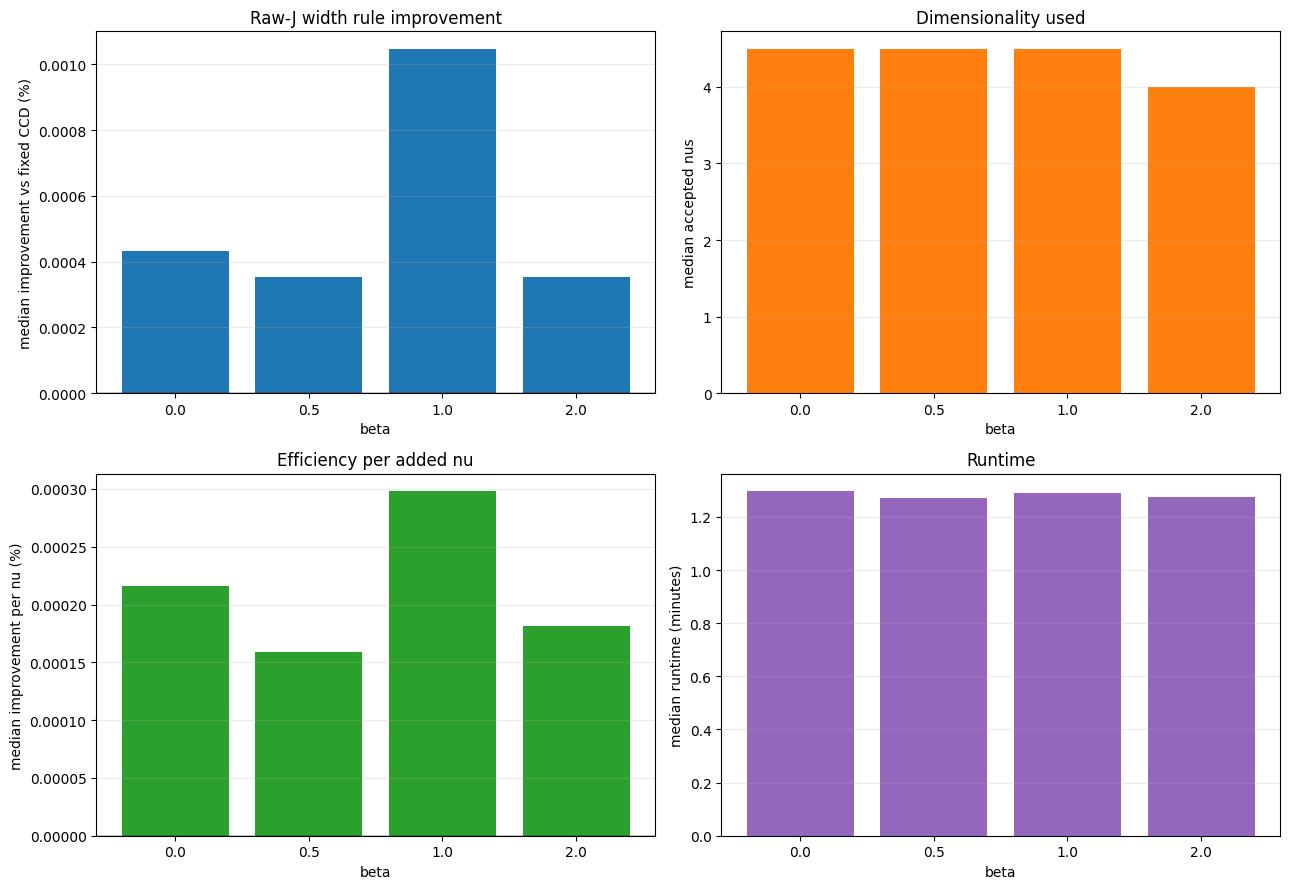

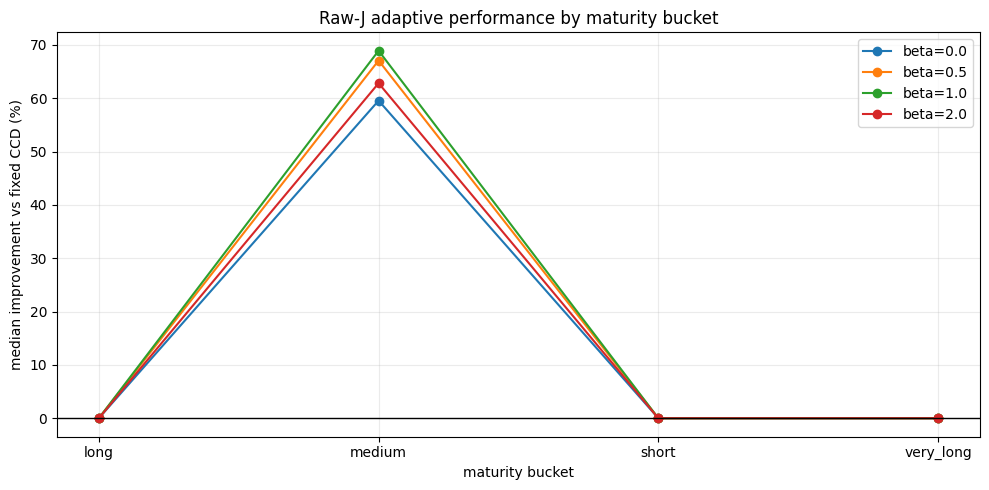

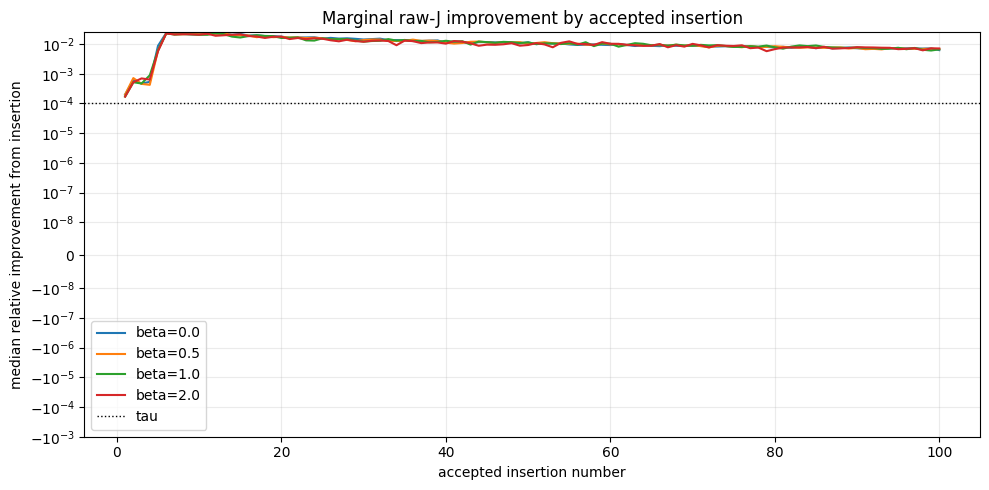

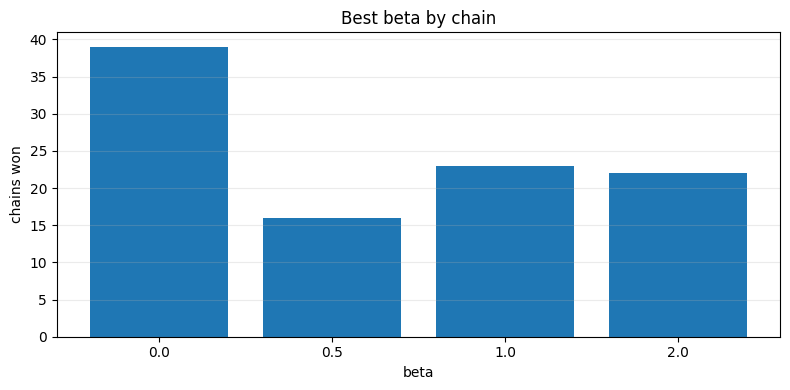

In [66]:

def plot_rawj_monotone_adaptive_results(results, insertion_log):
    if results is None or results.empty:
        print("No raw-J adaptive results to plot.")
        return

    feasible = results[results["bid_ask_feasible"] == True].copy()
    plot_data = feasible if not feasible.empty else results.copy()

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    beta_summary = plot_data.groupby("beta").agg(
        median_improvement=("improvement_vs_fixed_ccd_pct", "median"),
        median_nus=("nus_added", "median"),
        median_efficiency=("improvement_per_added_nu_pct", "median"),
        median_runtime=("total_runtime", lambda x: np.median(x) / 60.0),
    ).reset_index()

    axes[0, 0].bar(beta_summary["beta"].astype(str), beta_summary["median_improvement"])
    axes[0, 0].axhline(0.0, color="black", linewidth=1)
    axes[0, 0].set_xlabel("beta")
    axes[0, 0].set_ylabel("median improvement vs fixed CCD (%)")
    axes[0, 0].set_title("Raw-J width rule improvement")
    axes[0, 0].grid(axis="y", alpha=0.25)

    axes[0, 1].bar(beta_summary["beta"].astype(str), beta_summary["median_nus"], color="tab:orange")
    axes[0, 1].set_xlabel("beta")
    axes[0, 1].set_ylabel("median accepted nus")
    axes[0, 1].set_title("Dimensionality used")
    axes[0, 1].grid(axis="y", alpha=0.25)

    axes[1, 0].bar(beta_summary["beta"].astype(str), beta_summary["median_efficiency"], color="tab:green")
    axes[1, 0].axhline(0.0, color="black", linewidth=1)
    axes[1, 0].set_xlabel("beta")
    axes[1, 0].set_ylabel("median improvement per nu (%)")
    axes[1, 0].set_title("Efficiency per added nu")
    axes[1, 0].grid(axis="y", alpha=0.25)

    axes[1, 1].bar(beta_summary["beta"].astype(str), beta_summary["median_runtime"], color="tab:purple")
    axes[1, 1].set_xlabel("beta")
    axes[1, 1].set_ylabel("median runtime (minutes)")
    axes[1, 1].set_title("Runtime")
    axes[1, 1].grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    bucket = plot_data.groupby(["maturity_bucket", "beta"])["improvement_vs_fixed_ccd_pct"].median().reset_index()
    if not bucket.empty:
        plt.figure(figsize=(10, 5))
        for beta, group in bucket.groupby("beta"):
            plt.plot(group["maturity_bucket"], group["improvement_vs_fixed_ccd_pct"], marker="o", label=f"beta={beta}")
        plt.axhline(0.0, color="black", linewidth=1)
        plt.xlabel("maturity bucket")
        plt.ylabel("median improvement vs fixed CCD (%)")
        plt.title("Raw-J adaptive performance by maturity bucket")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

    if insertion_log is not None and not insertion_log.empty:
        accepted = insertion_log[insertion_log["accepted"] == True].copy()
        if not accepted.empty:
            plt.figure(figsize=(10, 5))
            for beta, group in accepted.groupby("beta"):
                curve = group.groupby("addition")["relative_improvement"].median().reset_index()
                plt.plot(curve["addition"], curve["relative_improvement"], label=f"beta={beta}")
            plt.axhline(RAWJ_ADAPT_TAU, color="black", linestyle=":", linewidth=1, label="tau")
            plt.xlabel("accepted insertion number")
            plt.ylabel("median relative improvement from insertion")
            plt.title("Marginal raw-J improvement by accepted insertion")
            plt.yscale("symlog", linthresh=1e-8)
            plt.legend()
            plt.grid(alpha=0.25)
            plt.tight_layout()
            plt.show()

    winners = plot_data.sort_values("final_raw_J").groupby(["date", "exdate"]).head(1)
    win_counts = winners["beta"].value_counts().sort_index()
    plt.figure(figsize=(8, 4))
    plt.bar(win_counts.index.astype(str), win_counts.values)
    plt.xlabel("beta")
    plt.ylabel("chains won")
    plt.title("Best beta by chain")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_rawj_monotone_adaptive_results(rawj_adaptive_results, rawj_adaptive_insertion_log)


## Step 17: 12-chain visual comparison of LVG, fixed-nu CCD, widest insertion, and batch raw-J insertion

This section is a visual diagnostic rather than a full benchmark. It randomly selects 3 short, 3 medium, 3 long, and 3 very-long SPX chains, excluding ultra-short chains with \(T<0.02\). For each chain, the same canonical pipeline is used:

1. `build_adjusted_chain` processes the WRDS/SPX data and estimates the chain-specific spot \(S_0\).
2. `build_initial_theta_for_chain` builds the original LVG theta through `load_theta`.
3. Fixed-nu CCD runs for 20,000 iterations using the regular adjacent-sigma proxy.
4. Widest-interval insertion starts from the fixed-nu CCD theta, inserts all nus by the partner-style widest-interval rule, then reruns CCD.
5. Batch raw-J insertion starts from the same fixed-nu CCD theta, identifies high raw-J contribution regions, inserts a fixed batch of nus there, then reruns CCD.

The plotted quantity is
\[
\frac{V(K)}{C''(K)} = \sigma(K)^2,
\]
with x-axis \(\log(K/S_0)\). Each subplot is one option chain, so the shapes are comparable within a chain even though \(S_0\) changes across dates.

For readability, the plotting code can use robust subplot-specific y-limits. This does not change any computed values or saved summary numbers; it only prevents one extreme edge spike from flattening the rest of the visual comparison. Set `VISUAL_USE_ROBUST_Y_LIMITS = False` if you want the full raw y-range in every panel.



Selected chains


,date,exdate,T,maturity_bucket,common_strikes
0,20110325,20110716,0.321429,long,37
1,20110413,20110917,0.448413,long,55
2,20111205,20120317,0.297619,long,88
3,20110415,20110521,0.103175,medium,142
4,20120119,20120330,0.202381,medium,38
5,20120410,20120616,0.194444,medium,177
6,20120301,20120317,0.047619,short,184
7,20120709,20120721,0.039683,short,154
8,20120815,20120831,0.047619,short,78
9,20110324,20111230,0.797619,very_long,25


[1/12] date=20110325, exdate=20110716, bucket=long
[2/12] date=20110413, exdate=20110917, bucket=long
[3/12] date=20111205, exdate=20120317, bucket=long
[4/12] date=20110415, exdate=20110521, bucket=medium
[5/12] date=20120119, exdate=20120330, bucket=medium
[6/12] date=20120410, exdate=20120616, bucket=medium
[7/12] date=20120301, exdate=20120317, bucket=short
[8/12] date=20120709, exdate=20120721, bucket=short
[9/12] date=20120815, exdate=20120831, bucket=short


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


[10/12] date=20110324, exdate=20111230, bucket=very_long
[11/12] date=20111125, exdate=20121222, bucket=very_long
[12/12] date=20121116, exdate=20131221, bucket=very_long
12-chain visual summary


,date,exdate,maturity_bucket,T,fixed_nu_ccd_raw_J,widest_raw_J,rawJ_batch_raw_J,widest_improvement_vs_fixed_pct,rawJ_improvement_vs_fixed_pct,widest_nus_added,rawJ_nus_added,fixed_feasible,widest_feasible,rawJ_feasible
0,20110325,20110716,long,0.321429,3.924026e-06,3.924026e-06,3.924026e-06,2.485734e-08,2.374440e-13,372,200,True,True,True
1,20110413,20110917,long,0.448413,2.299098e-06,2.299098e-06,2.299098e-06,6.506929e-06,-1.010711e-06,820,200,True,True,True
2,20111205,20120317,long,0.297619,8.408748e-07,1.086475e-07,1.433600e-07,8.707923e+01,8.295109e+01,4778,200,True,True,True
3,20110415,20110521,medium,0.103175,2.668601e-05,2.630337e-05,2.507648e-05,1.433847e+00,6.031344e+00,1570,200,True,True,True
4,20120119,20120330,medium,0.202381,4.631510e-06,2.547822e-06,4.979385e-07,4.498938e+01,8.924889e+01,745,200,True,True,True
5,20120410,20120616,medium,0.194444,1.667604e-06,3.284735e-07,3.552209e-07,8.030267e+01,7.869872e+01,10000,200,True,True,True
6,20120301,20120317,short,0.047619,1.909565e-05,9.585377e-06,2.440594e-06,4.980335e+01,8.721911e+01,1239,200,True,True,True
7,20120709,20120721,short,0.039683,1.203662e-05,6.052158e-06,1.600389e-06,4.971880e+01,8.670401e+01,1300,200,True,True,True
8,20120815,20120831,short,0.047619,1.015056e-05,6.504262e-06,3.925378e-06,3.592214e+01,6.132846e+01,2470,200,True,True,True
9,20110324,20111230,very_long,0.797619,1.078404e-06,6.323983e-07,1.078404e-06,4.135794e+01,-5.498154e-13,476,200,True,True,False


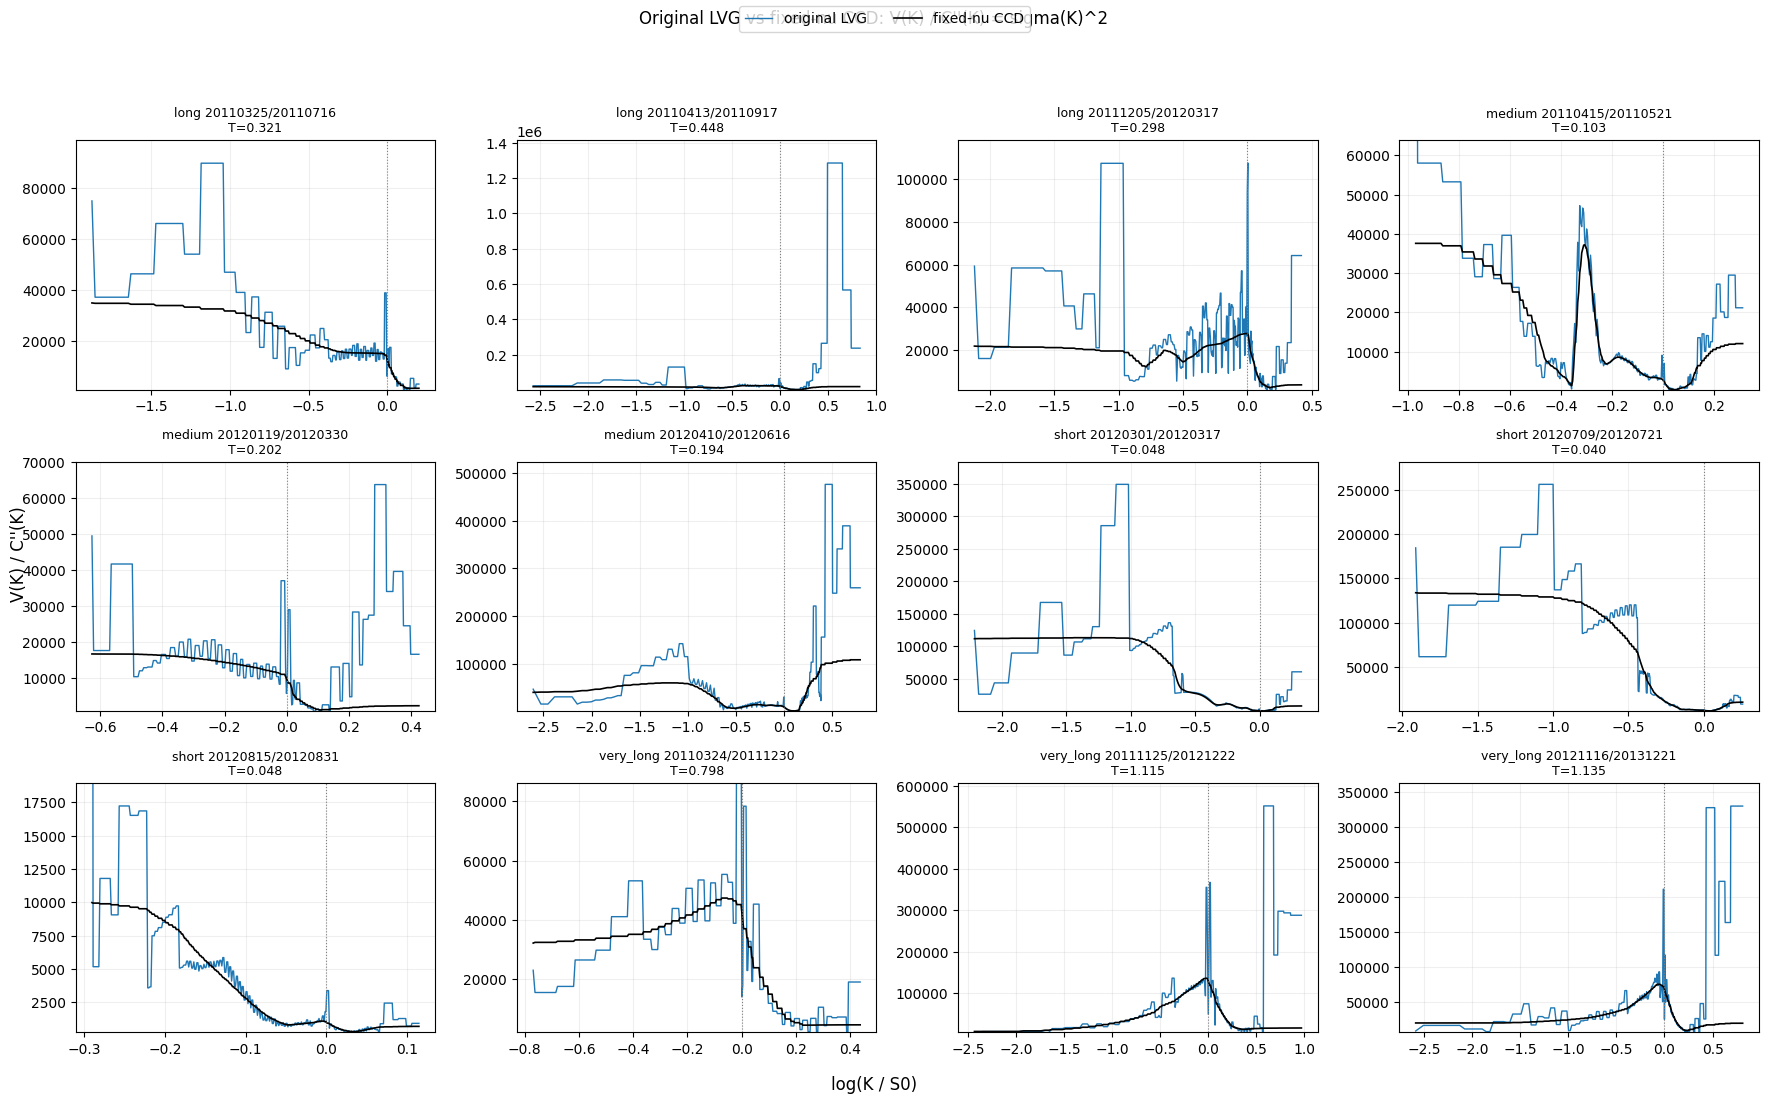

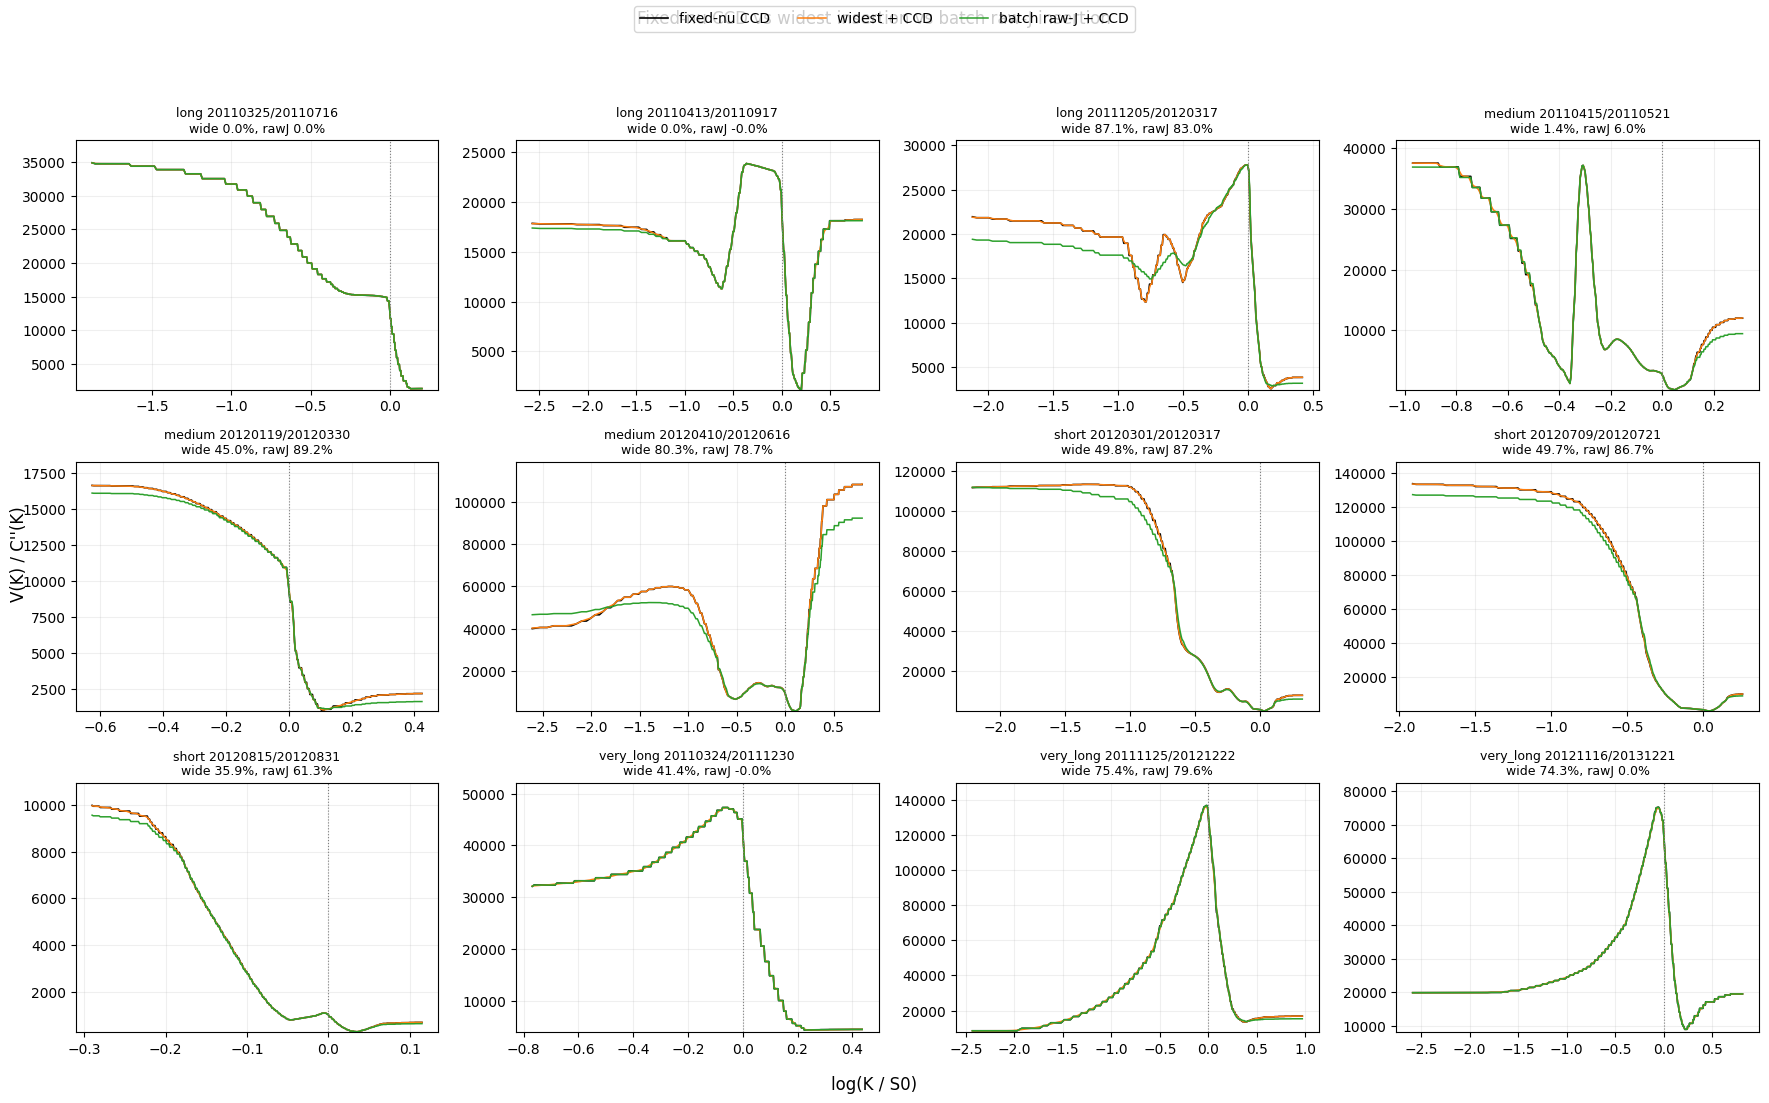

In [72]:

def visual_output_dir():
    # Avoid creating partner_lvg_private/partner_lvg_private/... when the kernel cwd
    # is already inside partner_lvg_private.
    cwd = Path.cwd()
    if cwd.name == "partner_lvg_private":
        return Path("outputs/twelve_chain_visual_nu_comparison")
    return Path("partner_lvg_private/outputs/twelve_chain_visual_nu_comparison")


VISUAL_OUTPUT_DIR = visual_output_dir()
VISUAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_TWELVE_CHAIN_VISUAL_COMPARISON = True
VISUAL_FORCE_RERUN = False
VISUAL_RANDOM_SEED = 20260625
VISUAL_CHAINS_PER_BUCKET = 3
VISUAL_MIN_T = 0.02
VISUAL_CCD_ITERATIONS = 20000
VISUAL_GRID_POINTS = 350
VISUAL_WIDEST_MAX_INSERTIONS = 10000
VISUAL_USE_ROBUST_Y_LIMITS = True

# Batch raw-J defaults chosen from the partial Step 17 results: q=0.9 and budget=200
# gave the strongest large-chain improvements; beta=0 avoids over-penalizing tight but important regions.
VISUAL_RAWJ_Q_LEVEL = 0.90
VISUAL_RAWJ_BETA = 0.0
VISUAL_RAWJ_BUDGET = 200

VISUAL_RESULTS_FILE = VISUAL_OUTPUT_DIR / "twelve_chain_visual_summary.csv"
VISUAL_TETHAS_FILE = VISUAL_OUTPUT_DIR / "twelve_chain_visual_theta_index.csv"


def select_random_visual_chains(raw, chains_per_bucket=VISUAL_CHAINS_PER_BUCKET, min_T=VISUAL_MIN_T, seed=VISUAL_RANDOM_SEED):
    eligible = []
    for (date, exdate), group in raw.groupby(["date", "exdate"]):
        try:
            T = chain_maturity_years(int(date), int(exdate))
            if T < min_T:
                continue
            common = group.groupby("strike_price")["cp_flag"].nunique()
            common_strikes = int((common == 2).sum())
            if common_strikes < MIN_STRIKES:
                continue
            eligible.append({
                "date": int(date),
                "exdate": int(exdate),
                "T": float(T),
                "maturity_bucket": maturity_bucket(float(T)),
                "common_strikes": common_strikes,
            })
        except Exception:
            continue

    eligible = pd.DataFrame(eligible)
    if eligible.empty:
        return eligible

    rng = np.random.default_rng(seed)
    selected = []
    for bucket in ["short", "medium", "long", "very_long"]:
        group = eligible[eligible["maturity_bucket"] == bucket].copy()
        if group.empty:
            continue
        take = min(chains_per_bucket, len(group))
        choices = rng.choice(group.index.to_numpy(), size=take, replace=False)
        selected.append(group.loc[choices])

    if not selected:
        return pd.DataFrame()
    out = pd.concat(selected, ignore_index=True)
    out = out.sort_values(["maturity_bucket", "date", "exdate"]).reset_index(drop=True)
    return out


def visual_sigma2_curve(R1, R2, S0, theta, grid):
    values = []
    try:
        c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    except Exception:
        return np.full(len(grid), np.nan)

    for K in grid:
        try:
            with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
                v = V_K(float(K), R1, R2, S0, theta, c_v1, c_v2)
                c2 = C2_K(float(K), R1, R2, S0, theta, c_v1, c_v2)
                if not np.isfinite(v) or not np.isfinite(c2) or abs(c2) < EPS:
                    values.append(np.nan)
                else:
                    values.append(v / c2)
        except Exception:
            values.append(np.nan)
    return np.array(values, dtype=float)


def visual_interval_scores_from_rawJ(R1, R2, S0, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    grid = np.concatenate([left_nu, [S0], right_nu])
    widths = np.diff(grid)
    scores = pd.DataFrame({
        "interval_index": np.arange(len(widths), dtype=int),
        "left": grid[:-1],
        "right": grid[1:],
        "width": widths,
        "jump_mass": np.zeros(len(widths), dtype=float),
    })

    jumps = jump_contributions_by_knot(R1, R2, S0, theta)
    for _, row in jumps.iterrows():
        knot = float(row["knot"])
        jump = float(row["jump_squared"])
        if not np.isfinite(jump) or jump <= 0:
            continue
        if knot <= grid[0] or knot >= grid[-1]:
            continue
        idx = int(np.searchsorted(grid, knot) - 1)
        if 0 <= idx < len(widths):
            scores.loc[scores["interval_index"] == idx, "jump_mass"] += jump
    return scores


def visual_select_rawJ_intervals(R1, R2, S0, theta, q_level):
    scores = visual_interval_scores_from_rawJ(R1, R2, S0, theta)
    scores = scores[(scores["width"] > 0.0) & np.isfinite(scores["width"])].copy()
    total = float(scores["jump_mass"].sum())
    if total <= 0.0 or scores.empty:
        return scores.iloc[0:0].copy(), total
    ranked = scores.sort_values("jump_mass", ascending=False).reset_index(drop=True)
    ranked["cum_fraction"] = ranked["jump_mass"].cumsum() / total
    selected = ranked[ranked["cum_fraction"] <= q_level].copy()
    if selected.empty:
        selected = ranked.head(1).copy()
    elif selected["cum_fraction"].iloc[-1] < q_level and len(selected) < len(ranked):
        selected = pd.concat([selected, ranked.iloc[[len(selected)]]], ignore_index=True)
    return selected, total


def visual_allocate_rawJ_budget(selected, budget, beta):
    if selected.empty or budget <= 0:
        return []
    work = selected.copy()
    work["weight"] = work["jump_mass"].clip(lower=0.0) * (work["width"].clip(lower=0.0) ** beta)
    if float(work["weight"].sum()) <= 0.0:
        work["weight"] = work["jump_mass"].clip(lower=0.0)
    if float(work["weight"].sum()) <= 0.0:
        work["weight"] = 1.0
    work = work.sort_values("weight", ascending=False).head(int(budget)).copy()
    raw_alloc = budget * work["weight"].to_numpy(dtype=float) / float(work["weight"].sum())
    alloc = np.floor(raw_alloc).astype(int)
    alloc[(alloc == 0) & (work["weight"].to_numpy(dtype=float) > 0)] = 1
    while int(alloc.sum()) > budget:
        candidates = np.where(alloc > 1)[0]
        if len(candidates) == 0:
            break
        remove_at = candidates[int(np.argmax(alloc[candidates] - raw_alloc[candidates]))]
        alloc[remove_at] -= 1
    while int(alloc.sum()) < budget:
        alloc[int(np.argmax(raw_alloc - alloc))] += 1
    return [(int(row["interval_index"]), int(n)) for (_, row), n in zip(work.iterrows(), alloc) if int(n) > 0]


def visual_insert_allocated_nus(R1, R2, S0, theta, allocations):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    full_grid = np.concatenate([left_nu, [S0], right_nu])
    interval_sigmas = np.concatenate([left_sigma, right_sigma])
    additions = {int(idx): int(n) for idx, n in allocations if int(n) > 0}

    new_left_nu, new_left_sigma = [], []
    new_right_nu, new_right_sigma = [], []

    for interval_index in range(len(full_grid) - 1):
        a = float(full_grid[interval_index])
        b = float(full_grid[interval_index + 1])
        sigma = float(interval_sigmas[interval_index])
        n_add = int(additions.get(interval_index, 0))
        if b <= a or sigma <= SIGMA_FLOOR:
            return None
        inserted = list(np.linspace(a, b, n_add + 2)[1:-1]) if n_add > 0 else []
        breakpoints = [a] + inserted + [b]
        if b <= S0:
            for start in breakpoints[:-1]:
                if start < S0:
                    new_left_nu.append(float(start))
                    new_left_sigma.append(float(sigma))
        elif a >= S0:
            for end in breakpoints[1:]:
                if end > S0:
                    new_right_nu.append(float(end))
                    new_right_sigma.append(float(sigma))
        else:
            return None

    new_left_nu = np.array(new_left_nu, dtype=float)
    new_left_sigma = np.array(new_left_sigma, dtype=float)
    new_right_nu = np.array(new_right_nu, dtype=float)
    new_right_sigma = np.array(new_right_sigma, dtype=float)
    order_left = np.argsort(new_left_nu)
    order_right = np.argsort(new_right_nu)
    new_left_nu = new_left_nu[order_left]
    new_left_sigma = new_left_sigma[order_left]
    new_right_nu = new_right_nu[order_right]
    new_right_sigma = new_right_sigma[order_right]
    new_R1 = len(new_left_sigma)
    new_R2 = len(new_right_sigma)
    new_theta = theta_from_parts(new_left_nu, new_left_sigma, new_right_nu, new_right_sigma)
    if not check_theta_shape(new_R1, new_R2, new_theta):
        return None
    if not check_nu_order(new_R1, new_R2, S0, new_theta):
        return None
    return new_R1, new_R2, new_theta


def visual_build_rawJ_batch_theta(R1, R2, S0, theta_fixed):
    selected, total_jump = visual_select_rawJ_intervals(R1, R2, S0, theta_fixed, VISUAL_RAWJ_Q_LEVEL)
    allocations = visual_allocate_rawJ_budget(selected, VISUAL_RAWJ_BUDGET, VISUAL_RAWJ_BETA)
    inserted = visual_insert_allocated_nus(R1, R2, S0, theta_fixed, allocations)
    if inserted is None:
        return None, selected, allocations
    return inserted, selected, allocations


def visual_run_one_chain(chain_info):
    date = int(chain_info["date"])
    exdate = int(chain_info["exdate"])
    chain = build_adjusted_chain(raw_spx, date, exdate, MIN_STRIKES)
    S0 = chain["S0"]
    bid_ask = chain["bid_ask"]

    R1, R2, theta_original = build_initial_theta_for_chain(chain)
    original_J = J_value(R1, R2, S0, theta_original)

    t0 = time.time()
    theta_fixed, _, fixed_accepted = coordinate_descent_sigma(
        R1, R2, S0, theta_original, bid_ask,
        proxy_kind="regular", update_order="cyclic",
        num_iterations=VISUAL_CCD_ITERATIONS, record_every=None,
    )
    fixed_runtime = time.time() - t0
    fixed_J = J_value(R1, R2, S0, theta_fixed)

    t1 = time.time()
    wide_R1, wide_R2, theta_wide_inserted, wide_log = add_widest_until_original_min_width(
        R1, R2, S0, theta_fixed, max_insertions=VISUAL_WIDEST_MAX_INSERTIONS
    )
    theta_wide, _, wide_accepted = coordinate_descent_sigma(
        wide_R1, wide_R2, S0, theta_wide_inserted, bid_ask,
        proxy_kind="regular", update_order="cyclic",
        num_iterations=VISUAL_CCD_ITERATIONS, record_every=None,
    )
    wide_runtime = time.time() - t1
    wide_J = J_value(wide_R1, wide_R2, S0, theta_wide)

    t2 = time.time()
    raw_inserted, selected, allocations = visual_build_rawJ_batch_theta(R1, R2, S0, theta_fixed)
    if raw_inserted is None:
        raw_R1, raw_R2, theta_raw = R1, R2, theta_fixed.copy()
        raw_status = "insertion_failed"
        raw_accepted = 0
    else:
        raw_R1, raw_R2, theta_raw_inserted = raw_inserted
        theta_raw, _, raw_accepted = coordinate_descent_sigma(
            raw_R1, raw_R2, S0, theta_raw_inserted, bid_ask,
            proxy_kind="regular", update_order="cyclic",
            num_iterations=VISUAL_CCD_ITERATIONS, record_every=None,
        )
        raw_status = "ok"
    raw_runtime = time.time() - t2
    raw_J = J_value(raw_R1, raw_R2, S0, theta_raw)

    fixed_slack = quote_slack_report(R1, R2, S0, theta_fixed, bid_ask)
    widest_slack = quote_slack_report(wide_R1, wide_R2, S0, theta_wide, bid_ask)
    rawJ_slack = quote_slack_report(raw_R1, raw_R2, S0, theta_raw, bid_ask)

    grid = np.linspace(float(np.min(chain["K"])), float(np.max(chain["K"])), VISUAL_GRID_POINTS)
    curves = {
        "original LVG": (R1, R2, theta_original, visual_sigma2_curve(R1, R2, S0, theta_original, grid)),
        "fixed-nu CCD": (R1, R2, theta_fixed, visual_sigma2_curve(R1, R2, S0, theta_fixed, grid)),
        "widest + CCD": (wide_R1, wide_R2, theta_wide, visual_sigma2_curve(wide_R1, wide_R2, S0, theta_wide, grid)),
        "batch raw-J + CCD": (raw_R1, raw_R2, theta_raw, visual_sigma2_curve(raw_R1, raw_R2, S0, theta_raw, grid)),
    }

    row = {
        "date": date,
        "exdate": exdate,
        "T": float(chain_info["T"]),
        "maturity_bucket": chain_info["maturity_bucket"],
        "S0": float(S0),
        "original_R1": R1,
        "original_R2": R2,
        "widest_R1": wide_R1,
        "widest_R2": wide_R2,
        "rawJ_R1": raw_R1,
        "rawJ_R2": raw_R2,
        "widest_nus_added": (wide_R1 + wide_R2) - (R1 + R2),
        "rawJ_nus_added": (raw_R1 + raw_R2) - (R1 + R2),
        "original_raw_J": original_J,
        "fixed_nu_ccd_raw_J": fixed_J,
        "widest_raw_J": wide_J,
        "rawJ_batch_raw_J": raw_J,
        "widest_improvement_vs_fixed_pct": 100.0 * (fixed_J - wide_J) / fixed_J if fixed_J > 0 else np.nan,
        "rawJ_improvement_vs_fixed_pct": 100.0 * (fixed_J - raw_J) / fixed_J if fixed_J > 0 else np.nan,
        "fixed_runtime": fixed_runtime,
        "widest_runtime": wide_runtime,
        "rawJ_runtime": raw_runtime,
        "fixed_accepted_moves": fixed_accepted,
        "widest_accepted_moves": wide_accepted,
        "rawJ_accepted_moves": raw_accepted,
        "rawJ_status": raw_status,
        "rawJ_selected_intervals": len(selected),
        "fixed_feasible": fixed_slack["feasible"],
        "widest_feasible": widest_slack["feasible"],
        "rawJ_feasible": rawJ_slack["feasible"],
        "fixed_min_bid_slack": fixed_slack["min_bid_slack"],
        "fixed_min_ask_slack": fixed_slack["min_ask_slack"],
        "widest_min_bid_slack": widest_slack["min_bid_slack"],
        "widest_min_ask_slack": widest_slack["min_ask_slack"],
        "rawJ_min_bid_slack": rawJ_slack["min_bid_slack"],
        "rawJ_min_ask_slack": rawJ_slack["min_ask_slack"],
    }
    return row, grid, curves


def run_twelve_chain_visual_comparison():
    if not RUN_TWELVE_CHAIN_VISUAL_COMPARISON:
        print("12-chain visual comparison is disabled.")
        return pd.DataFrame(), []

    selected = select_random_visual_chains(raw_spx)
    if selected.empty:
        print("No eligible visual chains found.")
        return pd.DataFrame(), []

    print("Selected chains")
    display(selected)

    rows = []
    plot_payload = []
    for idx, chain_info in selected.iterrows():
        print(f"[{idx+1}/{len(selected)}] date={int(chain_info['date'])}, exdate={int(chain_info['exdate'])}, bucket={chain_info['maturity_bucket']}")
        row, grid, curves = visual_run_one_chain(chain_info)
        rows.append(row)
        plot_payload.append((row, grid, curves))

    results = pd.DataFrame(rows)
    results.to_csv(VISUAL_RESULTS_FILE, index=False)
    print("12-chain visual summary")
    display(results[[
        "date", "exdate", "maturity_bucket", "T", "fixed_nu_ccd_raw_J",
        "widest_raw_J", "rawJ_batch_raw_J", "widest_improvement_vs_fixed_pct",
        "rawJ_improvement_vs_fixed_pct", "widest_nus_added", "rawJ_nus_added",
        "fixed_feasible", "widest_feasible", "rawJ_feasible"
    ]])
    return results, plot_payload


def visual_apply_robust_ylim(ax, arrays):
    if not VISUAL_USE_ROBUST_Y_LIMITS:
        return
    finite_values = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        if len(arr) > 0:
            finite_values.append(arr)
    if not finite_values:
        return
    values = np.concatenate(finite_values)
    values = values[values > 0]
    if len(values) < 10:
        return
    low, high = np.nanpercentile(values, [1, 99])
    if np.isfinite(low) and np.isfinite(high) and high > low:
        ax.set_ylim(max(0.0, 0.9 * low), 1.1 * high)


def plot_twelve_chain_visual_grids(results, plot_payload):
    if results is None or results.empty or not plot_payload:
        print("No visual payload to plot.")
        return

    # Graph 1: original LVG versus fixed-nu CCD.
    fig, axes = plt.subplots(3, 4, figsize=(18, 11), sharex=False, sharey=False)
    axes = axes.flatten()
    for ax, (row, grid, curves) in zip(axes, plot_payload):
        S0 = row["S0"]
        x = np.log(grid / S0)
        ax.plot(x, curves["original LVG"][3], color="tab:blue", linewidth=1.0, label="original LVG")
        ax.plot(x, curves["fixed-nu CCD"][3], color="black", linewidth=1.2, label="fixed-nu CCD")
        ax.axvline(0.0, color="gray", linestyle=":", linewidth=0.8)
        visual_apply_robust_ylim(ax, [curves["original LVG"][3], curves["fixed-nu CCD"][3]])
        ax.set_title(f"{row['maturity_bucket']} {int(row['date'])}/{int(row['exdate'])}\nT={row['T']:.3f}", fontsize=9)
        ax.grid(alpha=0.2)
    for ax in axes[len(plot_payload):]:
        ax.axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.suptitle("Original LVG vs fixed-nu CCD: V(K) / C''(K) = sigma(K)^2", y=0.995)
    fig.supxlabel("log(K / S0)")
    fig.supylabel("V(K) / C''(K)")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(VISUAL_OUTPUT_DIR / "original_lvg_vs_fixed_nu_ccd_sigma2.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Graph 2: fixed-nu CCD versus widest interval and batch raw-J additions.
    fig, axes = plt.subplots(3, 4, figsize=(18, 11), sharex=False, sharey=False)
    axes = axes.flatten()
    for ax, (row, grid, curves) in zip(axes, plot_payload):
        S0 = row["S0"]
        x = np.log(grid / S0)
        ax.plot(x, curves["fixed-nu CCD"][3], color="black", linewidth=1.2, label="fixed-nu CCD")
        ax.plot(x, curves["widest + CCD"][3], color="tab:orange", linewidth=1.1, label="widest + CCD")
        ax.plot(x, curves["batch raw-J + CCD"][3], color="tab:green", linewidth=1.1, label="batch raw-J + CCD")
        ax.axvline(0.0, color="gray", linestyle=":", linewidth=0.8)
        visual_apply_robust_ylim(ax, [
            curves["fixed-nu CCD"][3],
            curves["widest + CCD"][3],
            curves["batch raw-J + CCD"][3],
        ])
        ax.set_title(
            f"{row['maturity_bucket']} {int(row['date'])}/{int(row['exdate'])}\n"
            f"wide {row['widest_improvement_vs_fixed_pct']:.1f}%, rawJ {row['rawJ_improvement_vs_fixed_pct']:.1f}%",
            fontsize=9,
        )
        ax.grid(alpha=0.2)
    for ax in axes[len(plot_payload):]:
        ax.axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3)
    fig.suptitle("Fixed-nu CCD vs widest insertion vs batch raw-J insertion", y=0.995)
    fig.supxlabel("log(K / S0)")
    fig.supylabel("V(K) / C''(K)")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(VISUAL_OUTPUT_DIR / "fixed_nu_ccd_vs_widest_vs_batch_rawJ_sigma2.png", dpi=150, bbox_inches="tight")
    plt.show()


visual_12_results, visual_12_payload = run_twelve_chain_visual_comparison()
plot_twelve_chain_visual_grids(visual_12_results, visual_12_payload)



## Step 17B: raw-J stem plot for one selected Step 17 chain

This cell uses the theta vectors already created by Step 17. It does not rebuild the chain and does not rerun LVG calibration. It simply finds the requested `(date, exdate)` inside `visual_12_payload` and overlays the raw-J jump-contribution stems for:

- fixed-nu CCD,
- widest-interval nu insertion followed by CCD,
- batch raw-J nu insertion followed by CCD.



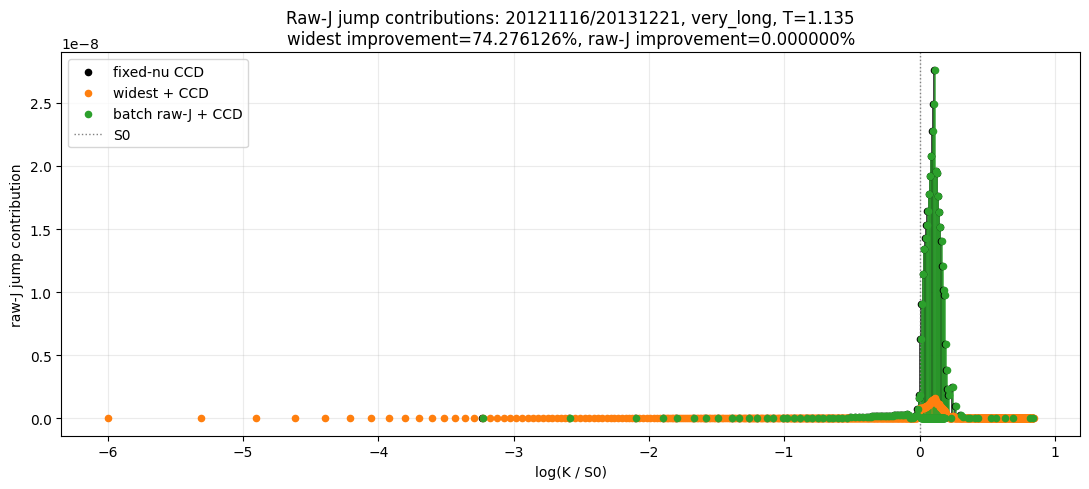

,date,exdate,maturity_bucket,T,fixed_nu_ccd_raw_J,widest_raw_J,rawJ_batch_raw_J,widest_improvement_vs_fixed_pct,rawJ_improvement_vs_fixed_pct,widest_nus_added,rawJ_nus_added,fixed_feasible,widest_feasible,rawJ_feasible
0,20121116,20131221,very_long,1.134921,3.826527e-07,9.843310e-08,3.826527e-07,74.276126,6.917442e-14,844,200,True,True,True


In [79]:

TARGET_STEM_DATE = 20121116
TARGET_STEM_EXDATE = 20131221


def plot_step17_stem_for_chain(target_date=TARGET_STEM_DATE, target_exdate=TARGET_STEM_EXDATE):
    if "visual_12_payload" not in globals():
        raise RuntimeError("visual_12_payload does not exist. Run Step 17 first in this kernel.")

    if len(visual_12_payload) == 0:
        raise RuntimeError("visual_12_payload is empty. Run Step 17 first.")

    selected = None
    for row, grid, curves in visual_12_payload:
        if int(row["date"]) == int(target_date) and int(row["exdate"]) == int(target_exdate):
            selected = row, grid, curves
            break

    if selected is None:
        available = pd.DataFrame([row for row, _, _ in visual_12_payload])
        print("That chain is not in the current Step 17 payload. Available chains are:")
        display(available[["date", "exdate", "maturity_bucket", "T"]])
        return

    row, grid, curves = selected
    S0 = float(row["S0"])

    cases = [
        ("fixed-nu CCD", curves["fixed-nu CCD"], "black", -0.002),
        ("widest + CCD", curves["widest + CCD"], "tab:orange", 0.0),
        ("batch raw-J + CCD", curves["batch raw-J + CCD"], "tab:green", 0.002),
    ]

    plt.figure(figsize=(11, 5))

    for label, curve_tuple, color, offset in cases:
        R1_i, R2_i, theta_i = curve_tuple[0], curve_tuple[1], curve_tuple[2]
        jump_df = jump_contributions_by_knot(R1_i, R2_i, S0, theta_i)

        x = np.log(jump_df["knot"].to_numpy(dtype=float) / S0) + offset
        y = jump_df["jump_squared"].to_numpy(dtype=float)
        keep = np.isfinite(x) & np.isfinite(y) & (y > 0)

        plt.vlines(x[keep], 0.0, y[keep], color=color, linewidth=1.2, alpha=0.85)
        plt.scatter(x[keep], y[keep], color=color, s=20, label=label, zorder=3)

    plt.axvline(0.0, color="gray", linestyle=":", linewidth=1, label="S0")
    plt.xlabel("log(K / S0)")
    plt.ylabel("raw-J jump contribution")
    plt.title(
        f"Raw-J jump contributions: {int(row['date'])}/{int(row['exdate'])}, "
        f"{row['maturity_bucket']}, T={row['T']:.3f}\n"
        f"widest improvement={row['widest_improvement_vs_fixed_pct']:.6f}%, "
        f"raw-J improvement={row['rawJ_improvement_vs_fixed_pct']:.6f}%"
    )
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(pd.DataFrame([row])[[
        "date", "exdate", "maturity_bucket", "T",
        "fixed_nu_ccd_raw_J", "widest_raw_J", "rawJ_batch_raw_J",
        "widest_improvement_vs_fixed_pct", "rawJ_improvement_vs_fixed_pct",
        "widest_nus_added", "rawJ_nus_added",
        "fixed_feasible", "widest_feasible", "rawJ_feasible"
    ]])


plot_step17_stem_for_chain()



## Step 17C: inspect which intervals the batch raw-J rule selected

The raw-J batch method ranks intervals using jump contributions computed at knots. A jump is located at a boundary between two neighboring intervals, so this table is useful for checking whether the algorithm placed extra nus on the useful side of the jump or only on one adjacent interval.



In [80]:

def inspect_step17_rawJ_region_finder(target_date=TARGET_STEM_DATE, target_exdate=TARGET_STEM_EXDATE, top_n=15):
    if "visual_12_payload" not in globals() or not visual_12_payload:
        raise RuntimeError("Run Step 17 first so visual_12_payload exists.")

    selected = None
    for row, grid, curves in visual_12_payload:
        if int(row["date"]) == int(target_date) and int(row["exdate"]) == int(target_exdate):
            selected = row, grid, curves
            break

    if selected is None:
        print("Target chain is not in visual_12_payload.")
        available = pd.DataFrame([row for row, _, _ in visual_12_payload])
        display(available[["date", "exdate", "maturity_bucket", "T"]])
        return

    row, grid, curves = selected
    S0 = float(row["S0"])
    fixed_R1, fixed_R2, fixed_theta = curves["fixed-nu CCD"][:3]

    jumps = jump_contributions_by_knot(fixed_R1, fixed_R2, S0, fixed_theta).copy()
    jumps["log_moneyness"] = np.log(jumps["knot"] / S0)
    jumps = jumps.sort_values("jump_squared", ascending=False).reset_index(drop=True)

    scores = visual_interval_scores_from_rawJ(fixed_R1, fixed_R2, S0, fixed_theta).copy()
    scores["left_log"] = np.log(scores["left"] / S0)
    scores["right_log"] = np.log(scores["right"] / S0)
    scores["score_rank"] = scores["jump_mass"].rank(method="first", ascending=False)

    selected_intervals, total_jump = visual_select_rawJ_intervals(
        fixed_R1, fixed_R2, S0, fixed_theta, VISUAL_RAWJ_Q_LEVEL
    )
    allocations = visual_allocate_rawJ_budget(selected_intervals, VISUAL_RAWJ_BUDGET, VISUAL_RAWJ_BETA)
    alloc_df = pd.DataFrame(allocations, columns=["interval_index", "allocated_nus"])

    selected_display = selected_intervals.merge(alloc_df, on="interval_index", how="left")
    selected_display["allocated_nus"] = selected_display["allocated_nus"].fillna(0).astype(int)
    selected_display["left_log"] = np.log(selected_display["left"] / S0)
    selected_display["right_log"] = np.log(selected_display["right"] / S0)
    selected_display = selected_display.sort_values("jump_mass", ascending=False)

    print("Top fixed-nu CCD raw-J knot contributions")
    display(jumps[["knot", "log_moneyness", "jump_squared"]].head(top_n))

    print("Top interval scores used by the raw-J region finder")
    display(scores.sort_values("jump_mass", ascending=False)[[
        "interval_index", "left", "right", "left_log", "right_log", "width", "jump_mass"
    ]].head(top_n))

    print("Intervals selected for batch raw-J insertion")
    display(selected_display[[
        "interval_index", "left", "right", "left_log", "right_log", "width", "jump_mass", "cum_fraction", "allocated_nus"
    ]].head(top_n))

    print("Important implementation detail:")
    print("The current region finder assigns each knot jump only to the interval immediately LEFT of the knot.")
    print("A jump at a knot is caused by both adjacent intervals, so a better rule should allocate to both sides or to a local window around the knot.")


inspect_step17_rawJ_region_finder(20121116, 20131221)



Top fixed-nu CCD raw-J knot contributions


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,knot,log_moneyness,jump_squared
0,1521.638028,0.111473,2.762358e-08
1,1508.878742,0.103052,2.488439e-08
2,1495.835348,0.094370,2.277989e-08
3,1483.304526,0.085958,2.079881e-08
4,1534.452958,0.119859,1.963934e-08
5,1547.276384,0.128182,1.942708e-08
6,1470.443837,0.077250,1.919685e-08
7,1457.730310,0.068566,1.776897e-08
8,1560.027174,0.136389,1.765954e-08
9,1445.420387,0.060086,1.642456e-08


Top interval scores used by the raw-J region finder


,interval_index,left,right,left_log,right_log,width,jump_mass
80,80,1508.878742,1521.638028,0.103052,0.111473,12.759286,2.762358e-08
79,79,1495.835348,1508.878742,0.094370,0.103052,13.043394,2.488439e-08
78,78,1483.304526,1495.835348,0.085958,0.094370,12.530822,2.277989e-08
77,77,1470.443837,1483.304526,0.077250,0.085958,12.860689,2.079881e-08
81,81,1521.638028,1534.452958,0.111473,0.119859,12.814930,1.963934e-08
82,82,1534.452958,1547.276384,0.119859,0.128182,12.823426,1.942708e-08
76,76,1457.730310,1470.443837,0.068566,0.077250,12.713526,1.919685e-08
75,75,1445.420387,1457.730310,0.060086,0.068566,12.309923,1.776897e-08
83,83,1547.276384,1560.027174,0.128182,0.136389,12.750790,1.765954e-08
74,74,1432.156094,1445.420387,0.050867,0.060086,13.264293,1.642456e-08


Intervals selected for batch raw-J insertion


,interval_index,left,right,left_log,right_log,width,jump_mass,cum_fraction,allocated_nus
0,80,1508.878742,1521.638028,0.103052,0.111473,12.759286,2.762358e-08,0.072190,16
1,79,1495.835348,1508.878742,0.094370,0.103052,13.043394,2.488439e-08,0.137221,14
2,78,1483.304526,1495.835348,0.085958,0.094370,12.530822,2.277989e-08,0.196752,13
3,77,1470.443837,1483.304526,0.077250,0.085958,12.860689,2.079881e-08,0.251107,12
4,81,1521.638028,1534.452958,0.111473,0.119859,12.814930,1.963934e-08,0.302431,11
5,82,1534.452958,1547.276384,0.119859,0.128182,12.823426,1.942708e-08,0.353200,11
6,76,1457.730310,1470.443837,0.068566,0.077250,12.713526,1.919685e-08,0.403368,11
7,75,1445.420387,1457.730310,0.060086,0.068566,12.309923,1.776897e-08,0.449805,10
8,83,1547.276384,1560.027174,0.128182,0.136389,12.750790,1.765954e-08,0.495955,10
9,74,1432.156094,1445.420387,0.050867,0.060086,13.264293,1.642456e-08,0.538878,10


Important implementation detail:
The current region finder assigns each knot jump only to the interval immediately LEFT of the knot.
A jump at a knot is caused by both adjacent intervals, so a better rule should allocate to both sides or to a local window around the knot.


## Step 18: knot-neighborhood raw-J nu insertion

The previous batch raw-J rule assigned each bad knot contribution to only one interval. That is not quite aligned with the raw-J formula, because a raw-J contribution lives at a knot and measures the mismatch between the left and right second derivatives:

\[
J_i = \left(C''_+(
u_i)-C''_-(
u_i)
ight)^2.
\]

A bad knot is therefore a boundary problem between two neighboring intervals. In this section we select the top knots accounting for 80%, 90%, and 95% of fixed-nu CCD raw-J mass, then form the target region from the intervals immediately left and right of those knots. Overlapping intervals are merged into larger target regions.

We compare two insertion strategies inside those target regions:

1. **Mass-budget rule:** choose a total budget \(B\), then allocate nus across target intervals in proportion to their assigned raw-J mass.
2. **Regional widest-interval rule:** ignore a fixed budget and repeatedly split the widest interval inside the target region, using the same stopping idea as the partner widest-interval method but only inside the raw-J target region.

Both methods start from the same fixed-nu CCD theta and run one final regular-proxy CCD pass after all new nus are inserted. No CCD is run between individual insertions.



In [82]:

NEIGHBORHOOD_Q_LEVELS = [0.80, 0.90, 0.95]
NEIGHBORHOOD_MASS_BUDGETS = [25, 50, 100, 200]
NEIGHBORHOOD_FINAL_CCD_ITERATIONS = VISUAL_CCD_ITERATIONS
NEIGHBORHOOD_MAX_REGION_SPLITS = 10000
NEIGHBORHOOD_RUN_EXPERIMENT = False  # Set True when you want to run this comparison.


def neighborhood_output_dir():
    cwd = Path.cwd()
    if cwd.name == "partner_lvg_private":
        return Path("outputs/knot_neighborhood_rawJ_insertion")
    return Path("partner_lvg_private/outputs/knot_neighborhood_rawJ_insertion")


NEIGHBORHOOD_OUTPUT_DIR = neighborhood_output_dir()
NEIGHBORHOOD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def full_grid_and_interval_sigmas(R1, R2, S0, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    full_grid = np.concatenate([left_nu, [S0], right_nu])
    interval_sigmas = np.concatenate([left_sigma, right_sigma])
    return full_grid, interval_sigmas


def selected_rawJ_knots(R1, R2, S0, theta, q_level):
    jumps = jump_contributions_by_knot(R1, R2, S0, theta).copy()
    jumps = jumps[np.isfinite(jumps["jump_squared"]) & (jumps["jump_squared"] > 0)].copy()
    if jumps.empty:
        return jumps, 0.0
    jumps = jumps.sort_values("jump_squared", ascending=False).reset_index(drop=True)
    total = float(jumps["jump_squared"].sum())
    jumps["cum_fraction"] = jumps["jump_squared"].cumsum() / total
    selected = jumps[jumps["cum_fraction"] <= q_level].copy()
    if selected.empty:
        selected = jumps.head(1).copy()
    elif selected["cum_fraction"].iloc[-1] < q_level and len(selected) < len(jumps):
        selected = pd.concat([selected, jumps.iloc[[len(selected)]]], ignore_index=True)
    return selected, total


def knot_neighborhood_intervals(R1, R2, S0, theta, q_level):
    full_grid, interval_sigmas = full_grid_and_interval_sigmas(R1, R2, S0, theta)
    widths = np.diff(full_grid)
    interval_table = pd.DataFrame({
        "interval_index": np.arange(len(widths), dtype=int),
        "left": full_grid[:-1],
        "right": full_grid[1:],
        "width": widths,
        "jump_mass": np.zeros(len(widths), dtype=float),
        "selected": False,
    })

    selected_knots, total_jump = selected_rawJ_knots(R1, R2, S0, theta, q_level)
    for _, row in selected_knots.iterrows():
        knot = float(row["knot"])
        jump = float(row["jump_squared"])
        knot_pos = int(np.searchsorted(full_grid, knot))

        # The bad knot is a boundary. Select the interval immediately to the left
        # and the interval immediately to the right when they exist.
        left_interval = knot_pos - 1
        right_interval = knot_pos
        for idx in [left_interval, right_interval]:
            if 0 <= idx < len(widths):
                interval_table.loc[interval_table["interval_index"] == idx, "selected"] = True
                interval_table.loc[interval_table["interval_index"] == idx, "jump_mass"] += 0.5 * jump

    selected_intervals = interval_table[interval_table["selected"]].copy()
    selected_intervals = selected_intervals[selected_intervals["width"] > 0].copy()
    return selected_intervals, selected_knots, total_jump


def merge_selected_interval_regions(selected_intervals):
    if selected_intervals.empty:
        return selected_intervals.copy()
    work = selected_intervals.sort_values("left").reset_index(drop=True)
    regions = []
    current_left = float(work.loc[0, "left"])
    current_right = float(work.loc[0, "right"])
    current_jump = float(work.loc[0, "jump_mass"])
    current_indices = [int(work.loc[0, "interval_index"])]

    for _, row in work.iloc[1:].iterrows():
        left = float(row["left"])
        right = float(row["right"])
        jump = float(row["jump_mass"])
        idx = int(row["interval_index"])
        if left <= current_right + 1e-12:
            current_right = max(current_right, right)
            current_jump += jump
            current_indices.append(idx)
        else:
            regions.append({
                "left": current_left,
                "right": current_right,
                "width": current_right - current_left,
                "jump_mass": current_jump,
                "interval_indices": current_indices,
            })
            current_left = left
            current_right = right
            current_jump = jump
            current_indices = [idx]

    regions.append({
        "left": current_left,
        "right": current_right,
        "width": current_right - current_left,
        "jump_mass": current_jump,
        "interval_indices": current_indices,
    })
    return pd.DataFrame(regions)


def insert_nus_from_interval_allocations(R1, R2, S0, theta, allocations):
    full_grid, interval_sigmas = full_grid_and_interval_sigmas(R1, R2, S0, theta)
    additions = {int(idx): int(n) for idx, n in allocations if int(n) > 0}

    new_left_nu, new_left_sigma = [], []
    new_right_nu, new_right_sigma = [], []

    for interval_index in range(len(full_grid) - 1):
        a = float(full_grid[interval_index])
        b = float(full_grid[interval_index + 1])
        sigma = float(interval_sigmas[interval_index])
        n_add = int(additions.get(interval_index, 0))
        if b <= a or sigma <= SIGMA_FLOOR:
            return None
        inserted = list(np.linspace(a, b, n_add + 2)[1:-1]) if n_add > 0 else []
        breakpoints = [a] + inserted + [b]

        if b <= S0:
            for start in breakpoints[:-1]:
                if start < S0:
                    new_left_nu.append(float(start))
                    new_left_sigma.append(sigma)
        elif a >= S0:
            for end in breakpoints[1:]:
                if end > S0:
                    new_right_nu.append(float(end))
                    new_right_sigma.append(sigma)
        else:
            return None

    new_left_nu = np.array(new_left_nu, dtype=float)
    new_left_sigma = np.array(new_left_sigma, dtype=float)
    new_right_nu = np.array(new_right_nu, dtype=float)
    new_right_sigma = np.array(new_right_sigma, dtype=float)

    left_order = np.argsort(new_left_nu)
    right_order = np.argsort(new_right_nu)
    new_left_nu = new_left_nu[left_order]
    new_left_sigma = new_left_sigma[left_order]
    new_right_nu = new_right_nu[right_order]
    new_right_sigma = new_right_sigma[right_order]

    new_R1 = len(new_left_sigma)
    new_R2 = len(new_right_sigma)
    new_theta = theta_from_parts(new_left_nu, new_left_sigma, new_right_nu, new_right_sigma)
    if not check_theta_shape(new_R1, new_R2, new_theta):
        return None
    if not check_nu_order(new_R1, new_R2, S0, new_theta):
        return None
    return new_R1, new_R2, new_theta


def mass_budget_allocations(selected_intervals, budget):
    if selected_intervals.empty or budget <= 0:
        return []
    work = selected_intervals.copy()
    work["weight"] = work["jump_mass"].clip(lower=0.0)
    if float(work["weight"].sum()) <= 0:
        work["weight"] = 1.0
    raw = budget * work["weight"].to_numpy(dtype=float) / float(work["weight"].sum())
    alloc = np.floor(raw).astype(int)
    alloc[(alloc == 0) & (work["weight"].to_numpy(dtype=float) > 0)] = 1
    while int(alloc.sum()) > budget:
        candidates = np.where(alloc > 1)[0]
        if len(candidates) == 0:
            break
        remove_at = candidates[int(np.argmax(alloc[candidates] - raw[candidates]))]
        alloc[remove_at] -= 1
    while int(alloc.sum()) < budget:
        alloc[int(np.argmax(raw - alloc))] += 1
    return [(int(row["interval_index"]), int(n)) for (_, row), n in zip(work.iterrows(), alloc) if int(n) > 0]


def regional_widest_allocations(R1, R2, S0, theta, selected_intervals, max_splits=NEIGHBORHOOD_MAX_REGION_SPLITS):
    if selected_intervals.empty:
        return []
    full_grid, interval_sigmas = full_grid_and_interval_sigmas(R1, R2, S0, theta)
    original_widths = np.diff(full_grid)
    original_min_width = float(np.min(original_widths[original_widths > 0]))

    target_indices = set(int(i) for i in selected_intervals["interval_index"].to_numpy())
    active = []
    for idx in target_indices:
        active.append({
            "original_interval_index": idx,
            "left": float(full_grid[idx]),
            "right": float(full_grid[idx + 1]),
        })

    for _ in range(max_splits):
        if not active:
            break
        widths = np.array([item["right"] - item["left"] for item in active], dtype=float)
        widest_pos = int(np.argmax(widths))
        widest_width = float(widths[widest_pos])
        if 0.5 * widest_width < original_min_width:
            break
        item = active.pop(widest_pos)
        mid = 0.5 * (item["left"] + item["right"])
        active.append({"original_interval_index": item["original_interval_index"], "left": item["left"], "right": mid})
        active.append({"original_interval_index": item["original_interval_index"], "left": mid, "right": item["right"]})

    # If an original interval was split into k subintervals, it needs k-1 added nus.
    counts = {}
    for item in active:
        idx = int(item["original_interval_index"])
        counts[idx] = counts.get(idx, 0) + 1
    allocations = [(idx, count - 1) for idx, count in counts.items() if count > 1]
    return allocations


def run_one_knot_neighborhood_candidate(row, curves, q_level, method, budget=None):
    S0 = float(row["S0"])
    fixed_R1, fixed_R2, fixed_theta = curves["fixed-nu CCD"][:3]
    selected_intervals, selected_knots, total_jump = knot_neighborhood_intervals(
        fixed_R1, fixed_R2, S0, fixed_theta, q_level
    )
    regions = merge_selected_interval_regions(selected_intervals)

    if method == "mass_budget":
        allocations = mass_budget_allocations(selected_intervals, int(budget))
    elif method == "regional_widest":
        allocations = regional_widest_allocations(fixed_R1, fixed_R2, S0, fixed_theta, selected_intervals)
    else:
        raise ValueError(f"Unknown method: {method}")

    inserted = insert_nus_from_interval_allocations(fixed_R1, fixed_R2, S0, fixed_theta, allocations)
    if inserted is None:
        return None, selected_intervals, regions, allocations

    new_R1, new_R2, theta_inserted = inserted
    # The chain bid/ask array is not stored in the payload, so rebuild only the quote array, not the theta.
    chain = build_adjusted_chain(raw_spx, int(row["date"]), int(row["exdate"]), MIN_STRIKES)
    theta_final, _, accepted_moves = coordinate_descent_sigma(
        new_R1, new_R2, S0, theta_inserted, chain["bid_ask"],
        proxy_kind="regular", update_order="cyclic",
        num_iterations=NEIGHBORHOOD_FINAL_CCD_ITERATIONS, record_every=None,
    )
    final_J = J_value(new_R1, new_R2, S0, theta_final)
    fixed_J = float(row["fixed_nu_ccd_raw_J"])
    slack = quote_slack_report(new_R1, new_R2, S0, theta_final, chain["bid_ask"])

    result = {
        "date": int(row["date"]),
        "exdate": int(row["exdate"]),
        "maturity_bucket": row["maturity_bucket"],
        "T": float(row["T"]),
        "q_level": q_level,
        "method": method,
        "budget": budget if budget is not None else np.nan,
        "selected_knots": len(selected_knots),
        "selected_intervals": len(selected_intervals),
        "merged_regions": len(regions),
        "nus_added": (new_R1 + new_R2) - (fixed_R1 + fixed_R2),
        "fixed_nu_ccd_raw_J": fixed_J,
        "final_raw_J": final_J,
        "improvement_vs_fixed_pct": 100.0 * (fixed_J - final_J) / fixed_J if fixed_J > 0 else np.nan,
        "accepted_moves": accepted_moves,
        "feasible": slack["feasible"],
        "min_bid_slack": slack["min_bid_slack"],
        "min_ask_slack": slack["min_ask_slack"],
        "final_R1": new_R1,
        "final_R2": new_R2,
    }
    return result, selected_intervals, regions, allocations


def run_knot_neighborhood_experiment():
    if "visual_12_payload" not in globals() or not visual_12_payload:
        raise RuntimeError("Run Step 17 first so visual_12_payload exists.")

    rows = []
    for payload_index, (row, grid, curves) in enumerate(visual_12_payload):
        print(f"Chain {payload_index + 1}/{len(visual_12_payload)}: {int(row['date'])}/{int(row['exdate'])}")
        for q_level in NEIGHBORHOOD_Q_LEVELS:
            for budget in NEIGHBORHOOD_MASS_BUDGETS:
                result, _, _, _ = run_one_knot_neighborhood_candidate(row, curves, q_level, "mass_budget", budget)
                if result is not None:
                    rows.append(result)
            result, _, _, _ = run_one_knot_neighborhood_candidate(row, curves, q_level, "regional_widest", None)
            if result is not None:
                rows.append(result)

    results = pd.DataFrame(rows)
    out_file = NEIGHBORHOOD_OUTPUT_DIR / "knot_neighborhood_results.csv"
    results.to_csv(out_file, index=False)
    print(f"Saved {len(results)} rows to {out_file}")
    display(results.sort_values("improvement_vs_fixed_pct", ascending=False).head(20))
    return results


if NEIGHBORHOOD_RUN_EXPERIMENT:
    knot_neighborhood_results = run_knot_neighborhood_experiment()
else:
    print("Set NEIGHBORHOOD_RUN_EXPERIMENT = True to run the knot-neighborhood comparison.")



Chain 1/12: 20110325/20110716
Chain 2/12: 20110413/20110917
Chain 3/12: 20111205/20120317
Chain 4/12: 20110415/20110521
Chain 5/12: 20120119/20120330
Chain 6/12: 20120410/20120616
Chain 7/12: 20120301/20120317
Chain 8/12: 20120709/20120721
Chain 9/12: 20120815/20120831
Chain 10/12: 20110324/20111230
Chain 11/12: 20111125/20121222
Chain 12/12: 20121116/20131221
Saved 180 rows to outputs/knot_neighborhood_rawJ_insertion/knot_neighborhood_results.csv


,date,exdate,maturity_bucket,T,q_level,method,budget,selected_knots,selected_intervals,merged_regions,nus_added,fixed_nu_ccd_raw_J,final_raw_J,improvement_vs_fixed_pct,accepted_moves,feasible,min_bid_slack,min_ask_slack,final_R1,final_R2
89,20120410,20120616,medium,0.194444,0.95,regional_widest,NaN,44,46,1,652,1.667604e-06,1.512534e-07,90.929894,19075,True,8.642553e-04,3.424019e-05,245,765
73,20120119,20120330,medium,0.202381,0.95,mass_budget,200.0,15,16,1,200,4.631510e-06,4.349304e-07,90.609316,17442,True,1.283604e-06,2.022870e-05,46,234
44,20111205,20120317,long,0.297619,0.95,regional_widest,NaN,36,37,1,479,8.408748e-07,8.432560e-08,89.971681,19317,True,4.182425e-04,1.764435e-04,122,537
68,20120119,20120330,medium,0.202381,0.90,mass_budget,200.0,13,14,1,200,4.631510e-06,5.138579e-07,88.905174,16676,True,1.314592e-06,2.495389e-05,46,234
39,20111205,20120317,long,0.297619,0.90,regional_widest,NaN,33,34,1,426,8.408748e-07,9.388454e-08,88.834897,18936,True,4.113003e-04,6.762675e-05,122,484
84,20120410,20120616,medium,0.194444,0.90,regional_widest,NaN,37,38,1,570,1.667604e-06,1.932990e-07,88.408579,18902,True,8.503584e-04,3.157809e-05,230,698
103,20120301,20120317,short,0.047619,0.95,mass_budget,200.0,21,22,1,200,1.909565e-05,2.248737e-06,88.223829,17415,True,1.029865e-07,2.832657e-07,294,278
98,20120301,20120317,short,0.047619,0.90,mass_budget,200.0,19,20,1,200,1.909565e-05,2.289405e-06,88.010859,18056,True,1.356664e-07,3.017917e-07,294,278
93,20120301,20120317,short,0.047619,0.80,mass_budget,200.0,16,19,1,200,1.909565e-05,2.442368e-06,87.209822,18173,True,2.145985e-07,5.218588e-07,294,278
118,20120709,20120721,short,0.039683,0.95,mass_budget,200.0,22,24,1,200,1.203662e-05,1.572926e-06,86.932165,19410,True,1.516144e-03,7.125129e-06,221,291


## Step 18B: summarize the knot-neighborhood experiment

This section reads the Step 18 results dataframe and plots the main takeaways. The goal is to compare the two knot-neighborhood insertion ideas:

- **mass_budget:** allocate a fixed number of nus across raw-J knot neighborhoods in proportion to raw-J mass.
- **regional_widest:** find raw-J knot neighborhoods, then apply the widest-interval splitting rule only inside those regions.

The benchmark for every row is the same fixed-nu CCD result for that chain. Positive improvement means the added-nu method reduced raw \(J\) beyond fixed-nu CCD.



Rows: 180 Feasible rows: 175
Feasibility rate by method


,method,feasibility_rate
0,mass_budget,0.972222
1,regional_widest,0.972222


Method / q / budget summary


method q_level budget improvement_vs_fixed_pct             \
                                                      count       mean   
0       mass_budget    0.80   25.0                       12  25.881225   
1       mass_budget    0.80   50.0                       12  32.915162   
2       mass_budget    0.80  100.0                       11  45.162165   
3       mass_budget    0.80  200.0                       12  47.737367   
4       mass_budget    0.90   25.0                       12  26.203039   
5       mass_budget    0.90   50.0                       11  35.425931   
6       mass_budget    0.90  100.0                       11  45.885465   
7       mass_budget    0.90  200.0                       12  50.001842   
8       mass_budget    0.95   25.0                       11  28.819277   
9       mass_budget    0.95   50.0                       12  31.518263   
10      mass_budget    0.95  100.0                       12  41.065465   
11      mass_budget    0.95  200.0                       12  49.113801   
12  regional_widest    0.80    NaN                       11  29.812857   
13  regional_widest    0.90    NaN                       12  29.284362   
14  regional_widest    0.95    NaN                       12  30.180638   

                         nus_added                          
       median        max     count        mean median  max  
0   25.430021  60.361556        12   25.750000   25.0   31  
1   34.406666  73.459443        12   50.000000   50.0   50  
2   67.267948  81.840006        11  100.000000  100.0  100  
3   67.226526  87.209822        12  200.000000  200.0  200  
4   23.956434  61.504923        12   27.416667   25.0   38  
5   53.863277  74.576491        11   50.000000   50.0   50  
6   68.019774  83.517812        11  100.000000  100.0  100  
7   75.778663  88.905174        12  200.000000  200.0  200  
8   47.826712  61.197282        11   30.272727   25.0   47  
9   26.755368  75.375378        12   50.000000   50.0   50  
10  50.071702  84.429173        12  100.000000  100.0  100  
11  76.465866  90.609316        12  200.000000  200.0  200  
12   0.355258  83.907507        11  103.909091   36.0  465  
13   1.314119  88.834897        12  119.166667   40.0  570  
14   1.603202  90.929894        12  142.000000   47.0  652

Best knot-neighborhood method by chain


,date,exdate,maturity_bucket,T,method,q_level,budget,improvement_vs_fixed_pct,nus_added,fixed_nu_ccd_raw_J,final_raw_J
89,20120410,20120616,medium,0.194444,regional_widest,0.95,NaN,9.092989e+01,652,1.667604e-06,1.512534e-07
73,20120119,20120330,medium,0.202381,mass_budget,0.95,200.0,9.060932e+01,200,4.631510e-06,4.349304e-07
44,20111205,20120317,long,0.297619,regional_widest,0.95,NaN,8.997168e+01,479,8.408748e-07,8.432560e-08
103,20120301,20120317,short,0.047619,mass_budget,0.95,200.0,8.822383e+01,200,1.909565e-05,2.248737e-06
118,20120709,20120721,short,0.039683,mass_budget,0.95,200.0,8.693217e+01,200,1.203662e-05,1.572926e-06
163,20111125,20121222,very_long,1.115079,mass_budget,0.95,200.0,8.048116e+01,200,2.097312e-07,4.093708e-08
133,20120815,20120831,short,0.047619,mass_budget,0.95,200.0,7.361743e+01,200,1.015056e-05,2.677978e-06
48,20110415,20110521,medium,0.103175,mass_budget,0.80,200.0,2.858650e+01,200,2.668601e-05,1.905741e-05
25,20110413,20110917,long,0.448413,mass_budget,0.95,25.0,2.795251e-05,25,2.299098e-06,2.299098e-06
135,20110324,20111230,very_long,0.797619,mass_budget,0.80,25.0,1.440595e-09,25,1.078404e-06,1.078404e-06


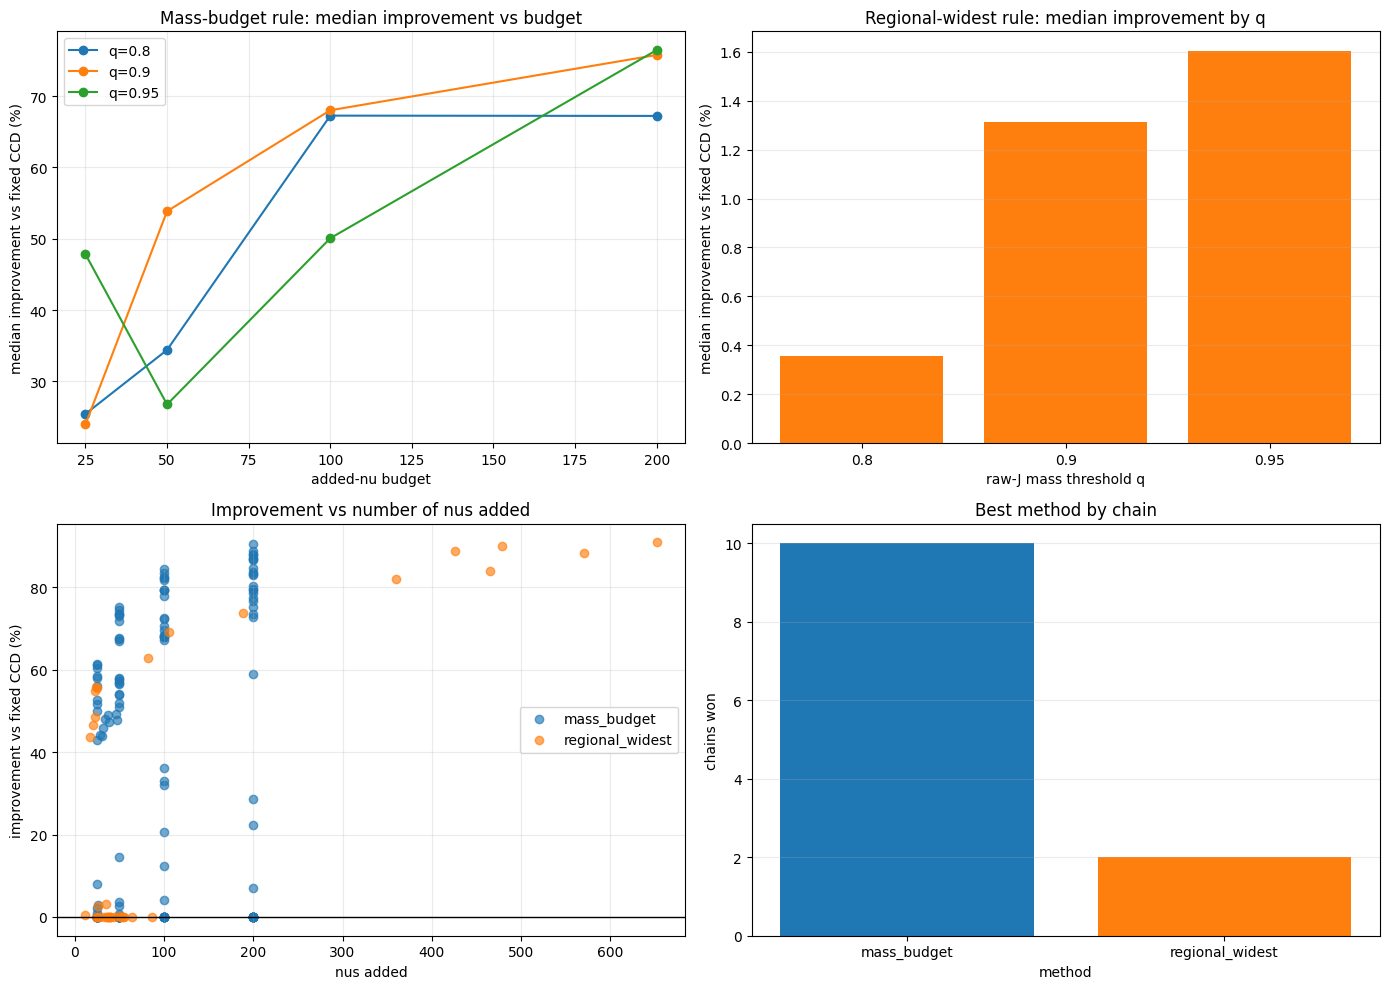

,maturity_bucket,count,mean,median,max
0,long,3,29.990570,2.795251e-05,89.971681
1,medium,3,70.041905,9.060932e+01,90.929894
2,short,3,82.924476,8.693217e+01,88.223829
3,very_long,3,26.827055,1.440595e-09,80.481164


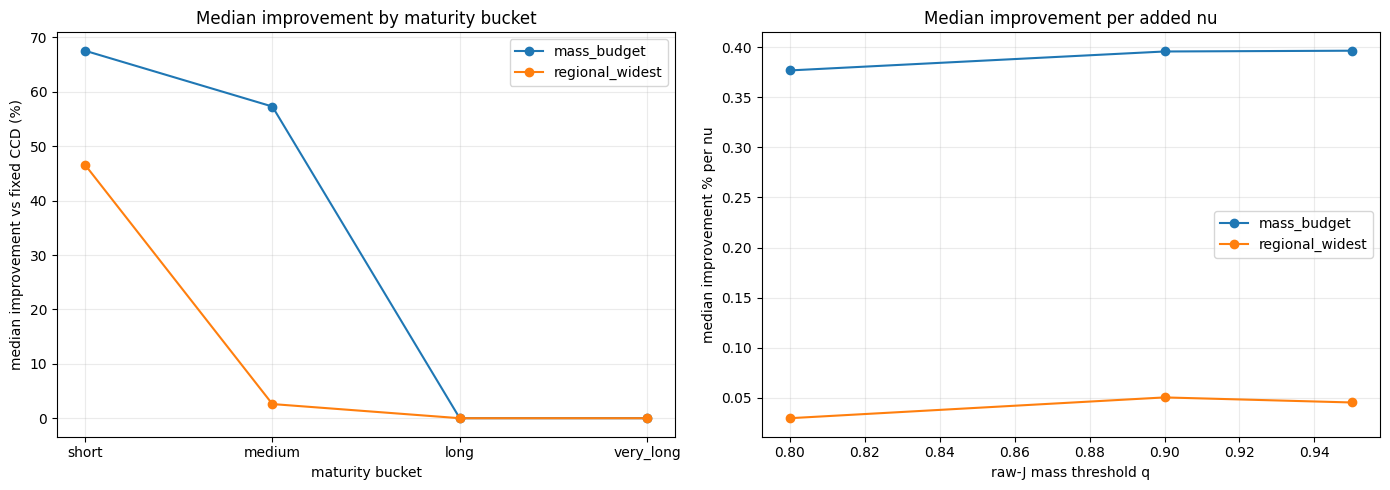

Main conclusion from Step 18:
Mass-budget knot-neighborhood insertion wins more chains and tends to improve as budget rises.
Regional-widest can produce very large wins on a few chains, but its median improvement is much lower because it often adds nus to a locally wide region that is not the actual remaining obstruction.


In [83]:

def load_knot_neighborhood_results():
    if "knot_neighborhood_results" in globals() and isinstance(knot_neighborhood_results, pd.DataFrame):
        return knot_neighborhood_results.copy()

    path_candidates = [
        Path("outputs/knot_neighborhood_rawJ_insertion/knot_neighborhood_results.csv"),
        Path("partner_lvg_private/outputs/knot_neighborhood_rawJ_insertion/knot_neighborhood_results.csv"),
    ]
    for path in path_candidates:
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError("Could not find knot_neighborhood_results.csv. Run Step 18 first.")


kn_results = load_knot_neighborhood_results()
kn_feasible = kn_results[kn_results["feasible"] == True].copy()

print("Rows:", len(kn_results), "Feasible rows:", len(kn_feasible))
print("Feasibility rate by method")
display(kn_results.groupby("method")["feasible"].mean().reset_index(name="feasibility_rate"))

summary_cols = ["improvement_vs_fixed_pct", "nus_added"]
method_summary = (
    kn_feasible
    .groupby(["method", "q_level", "budget"], dropna=False)[summary_cols]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)
print("Method / q / budget summary")
display(method_summary)

best_idx = kn_feasible.groupby(["date", "exdate"])["improvement_vs_fixed_pct"].idxmax()
best_by_chain = kn_feasible.loc[best_idx].sort_values("improvement_vs_fixed_pct", ascending=False).copy()
print("Best knot-neighborhood method by chain")
display(best_by_chain[[
    "date", "exdate", "maturity_bucket", "T", "method", "q_level", "budget",
    "improvement_vs_fixed_pct", "nus_added", "fixed_nu_ccd_raw_J", "final_raw_J"
]])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: median improvement by q and budget for mass_budget.
mass = kn_feasible[kn_feasible["method"] == "mass_budget"].copy()
for q_level, group in mass.groupby("q_level"):
    med = group.groupby("budget")["improvement_vs_fixed_pct"].median().reset_index()
    axes[0, 0].plot(med["budget"], med["improvement_vs_fixed_pct"], marker="o", label=f"q={q_level}")
axes[0, 0].set_title("Mass-budget rule: median improvement vs budget")
axes[0, 0].set_xlabel("added-nu budget")
axes[0, 0].set_ylabel("median improvement vs fixed CCD (%)")
axes[0, 0].grid(alpha=0.25)
axes[0, 0].legend()

# Plot 2: regional widest by q.
regional = kn_feasible[kn_feasible["method"] == "regional_widest"].copy()
reg_med = regional.groupby("q_level")["improvement_vs_fixed_pct"].median().reset_index()
axes[0, 1].bar(reg_med["q_level"].astype(str), reg_med["improvement_vs_fixed_pct"], color="tab:orange")
axes[0, 1].set_title("Regional-widest rule: median improvement by q")
axes[0, 1].set_xlabel("raw-J mass threshold q")
axes[0, 1].set_ylabel("median improvement vs fixed CCD (%)")
axes[0, 1].grid(axis="y", alpha=0.25)

# Plot 3: improvement versus number of nus added.
for method, group in kn_feasible.groupby("method"):
    axes[1, 0].scatter(group["nus_added"], group["improvement_vs_fixed_pct"], alpha=0.65, label=method)
axes[1, 0].axhline(0.0, color="black", linewidth=1)
axes[1, 0].set_title("Improvement vs number of nus added")
axes[1, 0].set_xlabel("nus added")
axes[1, 0].set_ylabel("improvement vs fixed CCD (%)")
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend()

# Plot 4: winning method count by chain.
win_counts = best_by_chain["method"].value_counts()
axes[1, 1].bar(win_counts.index, win_counts.values, color=["tab:blue", "tab:orange"][:len(win_counts)])
axes[1, 1].set_title("Best method by chain")
axes[1, 1].set_xlabel("method")
axes[1, 1].set_ylabel("chains won")
axes[1, 1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# Maturity-bucket view.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bucket_summary = (
    best_by_chain
    .groupby("maturity_bucket")["improvement_vs_fixed_pct"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)
display(bucket_summary)

for method, group in kn_feasible.groupby("method"):
    bucket_med = group.groupby("maturity_bucket")["improvement_vs_fixed_pct"].median().reindex(["short", "medium", "long", "very_long"])
    axes[0].plot(bucket_med.index, bucket_med.values, marker="o", label=method)
axes[0].set_title("Median improvement by maturity bucket")
axes[0].set_xlabel("maturity bucket")
axes[0].set_ylabel("median improvement vs fixed CCD (%)")
axes[0].grid(alpha=0.25)
axes[0].legend()

for method, group in kn_feasible.groupby("method"):
    eff = group.copy()
    eff["improvement_per_nu"] = eff["improvement_vs_fixed_pct"] / eff["nus_added"].replace(0, np.nan)
    method_eff = eff.groupby("q_level")["improvement_per_nu"].median().reset_index()
    axes[1].plot(method_eff["q_level"], method_eff["improvement_per_nu"], marker="o", label=method)
axes[1].set_title("Median improvement per added nu")
axes[1].set_xlabel("raw-J mass threshold q")
axes[1].set_ylabel("median improvement % per nu")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Main conclusion from Step 18:")
print("Mass-budget knot-neighborhood insertion wins more chains and tends to improve as budget rises.")
print("Regional-widest can produce very large wins on a few chains, but its median improvement is much lower because it often adds nus to a locally wide region that is not the actual remaining obstruction.")



## Step 19: high-q mass-budget knot-neighborhood sweep

Step 18 showed that the knot-neighborhood correction helped: instead of assigning a bad raw-J knot to only one interval, we selected the intervals immediately left and right of that knot. The best-performing version was the **mass-budget** rule, where a fixed number of new nus is allocated across the selected neighborhoods in proportion to raw-J mass.

This step keeps the exact same method and tests whether improvement continues when we use higher raw-J mass thresholds and larger budgets:

\[
q \in \{0.95,0.97,0.98,0.99\},
\qquad
B \in \{100,200,400,600\}.
\]

For each `(chain, q, budget)` candidate, the pipeline is:

1. start from the fixed-nu CCD theta already computed in Step 17,
2. select the top raw-J knots explaining `q` of total raw-J mass,
3. take the intervals immediately left and right of those selected knots,
4. allocate `budget` nus across those intervals proportional to raw-J mass,
5. insert all nus at once,
6. run one final regular-proxy CCD pass,
7. compare final raw \(J\) to the fixed-nu CCD raw \(J\).

No fixed-nu CCD baseline is recomputed here, and no CCD is run between individual insertions.



In [86]:

HIGH_Q_LEVELS = [0.95, 0.97, 0.98, 0.99]
HIGH_Q_BUDGETS = [100, 200, 400, 600]
HIGH_Q_FINAL_CCD_ITERATIONS = VISUAL_CCD_ITERATIONS
HIGH_Q_RUN_EXPERIMENT = False  # Set True to run the high-q / high-budget sweep.


def high_q_output_dir():
    cwd = Path.cwd()
    if cwd.name == "partner_lvg_private":
        return Path("outputs/knot_neighborhood_rawJ_insertion")
    return Path("partner_lvg_private/outputs/knot_neighborhood_rawJ_insertion")


HIGH_Q_OUTPUT_DIR = high_q_output_dir()
HIGH_Q_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HIGH_Q_RESULTS_FILE = HIGH_Q_OUTPUT_DIR / "high_q_budget_results.csv"


def run_one_high_q_mass_budget_candidate(row, curves, q_level, budget):
    S0 = float(row["S0"])
    fixed_R1, fixed_R2, fixed_theta = curves["fixed-nu CCD"][:3]

    selected_intervals, selected_knots, total_jump = knot_neighborhood_intervals(
        fixed_R1, fixed_R2, S0, fixed_theta, q_level
    )
    regions = merge_selected_interval_regions(selected_intervals)
    allocations = mass_budget_allocations(selected_intervals, int(budget))
    inserted = insert_nus_from_interval_allocations(fixed_R1, fixed_R2, S0, fixed_theta, allocations)

    if inserted is None:
        return {
            "date": int(row["date"]),
            "exdate": int(row["exdate"]),
            "maturity_bucket": row["maturity_bucket"],
            "T": float(row["T"]),
            "q_level": float(q_level),
            "budget": int(budget),
            "selected_knots": len(selected_knots),
            "selected_intervals": len(selected_intervals),
            "merged_regions": len(regions),
            "nus_added": 0,
            "fixed_nu_ccd_raw_J": float(row["fixed_nu_ccd_raw_J"]),
            "final_raw_J": np.nan,
            "improvement_vs_fixed_pct": np.nan,
            "accepted_moves": 0,
            "feasible": False,
            "min_bid_slack": np.nan,
            "min_ask_slack": np.nan,
            "final_R1": np.nan,
            "final_R2": np.nan,
            "status": "insertion_failed",
        }

    new_R1, new_R2, theta_inserted = inserted

    # Rebuild only the quote array for feasibility checks and CCD constraints.
    # The fixed-nu CCD theta itself is reused from Step 17.
    chain = build_adjusted_chain(raw_spx, int(row["date"]), int(row["exdate"]), MIN_STRIKES)

    start_time = time.time()
    theta_final, _, accepted_moves = coordinate_descent_sigma(
        new_R1, new_R2, S0, theta_inserted, chain["bid_ask"],
        proxy_kind="regular", update_order="cyclic",
        num_iterations=HIGH_Q_FINAL_CCD_ITERATIONS, record_every=None,
    )
    runtime = time.time() - start_time

    final_J = J_value(new_R1, new_R2, S0, theta_final)
    fixed_J = float(row["fixed_nu_ccd_raw_J"])
    slack = quote_slack_report(new_R1, new_R2, S0, theta_final, chain["bid_ask"])

    return {
        "date": int(row["date"]),
        "exdate": int(row["exdate"]),
        "maturity_bucket": row["maturity_bucket"],
        "T": float(row["T"]),
        "q_level": float(q_level),
        "budget": int(budget),
        "selected_knots": len(selected_knots),
        "selected_intervals": len(selected_intervals),
        "merged_regions": len(regions),
        "nus_added": (new_R1 + new_R2) - (fixed_R1 + fixed_R2),
        "fixed_nu_ccd_raw_J": fixed_J,
        "final_raw_J": final_J,
        "improvement_vs_fixed_pct": 100.0 * (fixed_J - final_J) / fixed_J if fixed_J > 0 else np.nan,
        "accepted_moves": accepted_moves,
        "runtime": runtime,
        "feasible": slack["feasible"],
        "min_bid_slack": slack["min_bid_slack"],
        "min_ask_slack": slack["min_ask_slack"],
        "final_R1": new_R1,
        "final_R2": new_R2,
        "status": "ok",
    }


def run_high_q_mass_budget_sweep():
    if "visual_12_payload" not in globals() or not visual_12_payload:
        raise RuntimeError("Run Step 17 first so visual_12_payload exists.")

    rows = []
    total_jobs = len(visual_12_payload) * len(HIGH_Q_LEVELS) * len(HIGH_Q_BUDGETS)
    job = 0

    for payload_index, (row, grid, curves) in enumerate(visual_12_payload):
        print(f"Chain {payload_index + 1}/{len(visual_12_payload)}: {int(row['date'])}/{int(row['exdate'])}")
        for q_level in HIGH_Q_LEVELS:
            for budget in HIGH_Q_BUDGETS:
                job += 1
                print(f"  job {job}/{total_jobs}: q={q_level}, budget={budget}")
                result = run_one_high_q_mass_budget_candidate(row, curves, q_level, budget)
                rows.append(result)

                # Save after every job so a long run is not lost if interrupted.
                pd.DataFrame(rows).to_csv(HIGH_Q_RESULTS_FILE, index=False)

    results = pd.DataFrame(rows)
    results.to_csv(HIGH_Q_RESULTS_FILE, index=False)
    print(f"Saved {len(results)} rows to {HIGH_Q_RESULTS_FILE}")
    display(results.sort_values("improvement_vs_fixed_pct", ascending=False).head(20))
    return results


if HIGH_Q_RUN_EXPERIMENT:
    high_q_budget_results = run_high_q_mass_budget_sweep()
else:
    print("Set HIGH_Q_RUN_EXPERIMENT = True to run the high-q mass-budget sweep.")



Chain 1/12: 20110325/20110716
  job 1/192: q=0.95, budget=100
  job 2/192: q=0.95, budget=200
  job 3/192: q=0.95, budget=400
  job 4/192: q=0.95, budget=600
  job 5/192: q=0.97, budget=100
  job 6/192: q=0.97, budget=200
  job 7/192: q=0.97, budget=400
  job 8/192: q=0.97, budget=600
  job 9/192: q=0.98, budget=100
  job 10/192: q=0.98, budget=200
  job 11/192: q=0.98, budget=400
  job 12/192: q=0.98, budget=600
  job 13/192: q=0.99, budget=100
  job 14/192: q=0.99, budget=200
  job 15/192: q=0.99, budget=400
  job 16/192: q=0.99, budget=600
Chain 2/12: 20110413/20110917
  job 17/192: q=0.95, budget=100
  job 18/192: q=0.95, budget=200
  job 19/192: q=0.95, budget=400
  job 20/192: q=0.95, budget=600
  job 21/192: q=0.97, budget=100
  job 22/192: q=0.97, budget=200
  job 23/192: q=0.97, budget=400
  job 24/192: q=0.97, budget=600
  job 25/192: q=0.98, budget=100
  job 26/192: q=0.98, budget=200
  job 27/192: q=0.98, budget=400
  job 28/192: q=0.98, budget=600
  job 29/192: q=0.99, bud

,date,exdate,maturity_bucket,T,q_level,budget,selected_knots,selected_intervals,merged_regions,nus_added,...,final_raw_J,improvement_vs_fixed_pct,accepted_moves,runtime,feasible,min_bid_slack,min_ask_slack,final_R1,final_R2,status
79,20120119,20120330,medium,0.202381,0.99,600,18,20,1,600,...,2.379433e-07,94.862511,16588,18.148381,True,2.524705e-06,1.753470e-05,58,622,ok
75,20120119,20120330,medium,0.202381,0.98,600,17,19,1,600,...,2.460159e-07,94.688214,16487,17.889367,True,2.524705e-06,1.850912e-05,54,626,ok
78,20120119,20120330,medium,0.202381,0.99,400,18,20,1,400,...,2.524821e-07,94.548601,18570,15.405340,True,1.954602e-06,1.855724e-05,53,427,ok
74,20120119,20120330,medium,0.202381,0.98,400,17,19,1,400,...,2.549824e-07,94.494616,18482,15.601986,True,1.954592e-06,1.660294e-05,52,428,ok
66,20120119,20120330,medium,0.202381,0.95,400,15,16,1,400,...,2.814824e-07,93.922449,18370,16.381578,True,2.103012e-06,1.707747e-05,46,434,ok
67,20120119,20120330,medium,0.202381,0.95,600,15,16,1,600,...,2.884087e-07,93.772901,16394,17.978737,True,2.606088e-06,8.890113e-06,46,634,ok
70,20120119,20120330,medium,0.202381,0.97,400,16,17,1,400,...,2.910243e-07,93.716427,18146,16.344129,True,1.956286e-06,1.597501e-05,46,434,ok
111,20120301,20120317,short,0.047619,0.99,600,29,31,1,600,...,1.206592e-06,93.681326,18398,40.899229,True,1.686644e-04,7.922558e-06,298,674,ok
71,20120119,20120330,medium,0.202381,0.97,600,16,17,1,600,...,2.969403e-07,93.588692,16193,18.193973,True,2.524599e-06,1.457171e-05,46,634,ok
127,20120709,20120721,short,0.039683,0.99,600,30,33,1,600,...,7.870065e-07,93.461567,18583,36.197285,True,1.566030e-03,6.667477e-08,240,672,ok


## Step 19B: summarize the high-q mass-budget sweep

This section reads the high-q Step 19 results and focuses on whether larger budgets continue to improve raw \(J\), and whether the best threshold is still near `q=0.95` or moves toward `q=0.98`/`q=0.99`.



Rows: 192 Feasible rows: 185


,q_level,budget,feasibility_rate
0,0.95,100,1.000000
1,0.95,200,1.000000
2,0.95,400,0.916667
3,0.95,600,0.916667
4,0.97,100,1.000000
5,0.97,200,1.000000
6,0.97,400,0.916667
7,0.97,600,1.000000
8,0.98,100,1.000000
9,0.98,200,1.000000


High-q mass-budget summary


,q_level,budget,count,mean_improvement,median_improvement,max_improvement,median_nus_added,median_runtime
0,0.95,100,12,41.065465,50.071702,84.429173,100.0,28.952710
1,0.95,200,12,49.113801,76.465866,90.609316,200.0,26.005520
2,0.95,400,11,58.733228,86.775348,93.922449,400.0,23.870075
3,0.95,600,11,59.746987,89.722742,93.772901,600.0,23.623761
4,0.97,100,12,38.225202,35.322639,83.740827,100.0,28.214355
5,0.97,200,12,51.018912,80.077484,90.474852,200.0,26.694435
6,0.97,400,11,59.364103,87.566585,93.716427,400.0,21.970380
7,0.97,600,12,55.252479,90.054818,93.588692,600.0,22.321563
8,0.98,100,12,39.228401,35.017868,84.690512,100.0,33.775871
9,0.98,200,12,45.475735,47.062654,90.906343,200.0,26.965302


Best high-q setting by chain


,date,exdate,maturity_bucket,T,q_level,budget,improvement_vs_fixed_pct,nus_added,fixed_nu_ccd_raw_J,final_raw_J
79,20120119,20120330,medium,0.202381,0.99,600,9.486251e+01,600,4.631510e-06,2.379433e-07
111,20120301,20120317,short,0.047619,0.99,600,9.368133e+01,600,1.909565e-05,1.206592e-06
127,20120709,20120721,short,0.039683,0.99,600,9.346157e+01,600,1.203662e-05,7.870065e-07
47,20111205,20120317,long,0.297619,0.99,600,9.327848e+01,600,8.408748e-07,5.651954e-08
143,20120815,20120831,short,0.047619,0.99,600,9.313556e+01,600,1.015056e-05,6.967795e-07
95,20120410,20120616,medium,0.194444,0.99,600,9.069264e+01,600,1.667604e-06,1.552098e-07
175,20111125,20121222,very_long,1.115079,0.99,600,9.047495e+01,600,2.097312e-07,1.997700e-08
58,20110415,20110521,medium,0.103175,0.98,400,1.824192e+01,400,2.668601e-05,2.181797e-05
24,20110413,20110917,long,0.448413,0.98,100,5.210117e-06,100,2.299098e-06,2.299098e-06
149,20110324,20111230,very_long,0.797619,0.97,200,1.453084e-12,200,1.078404e-06,1.078404e-06


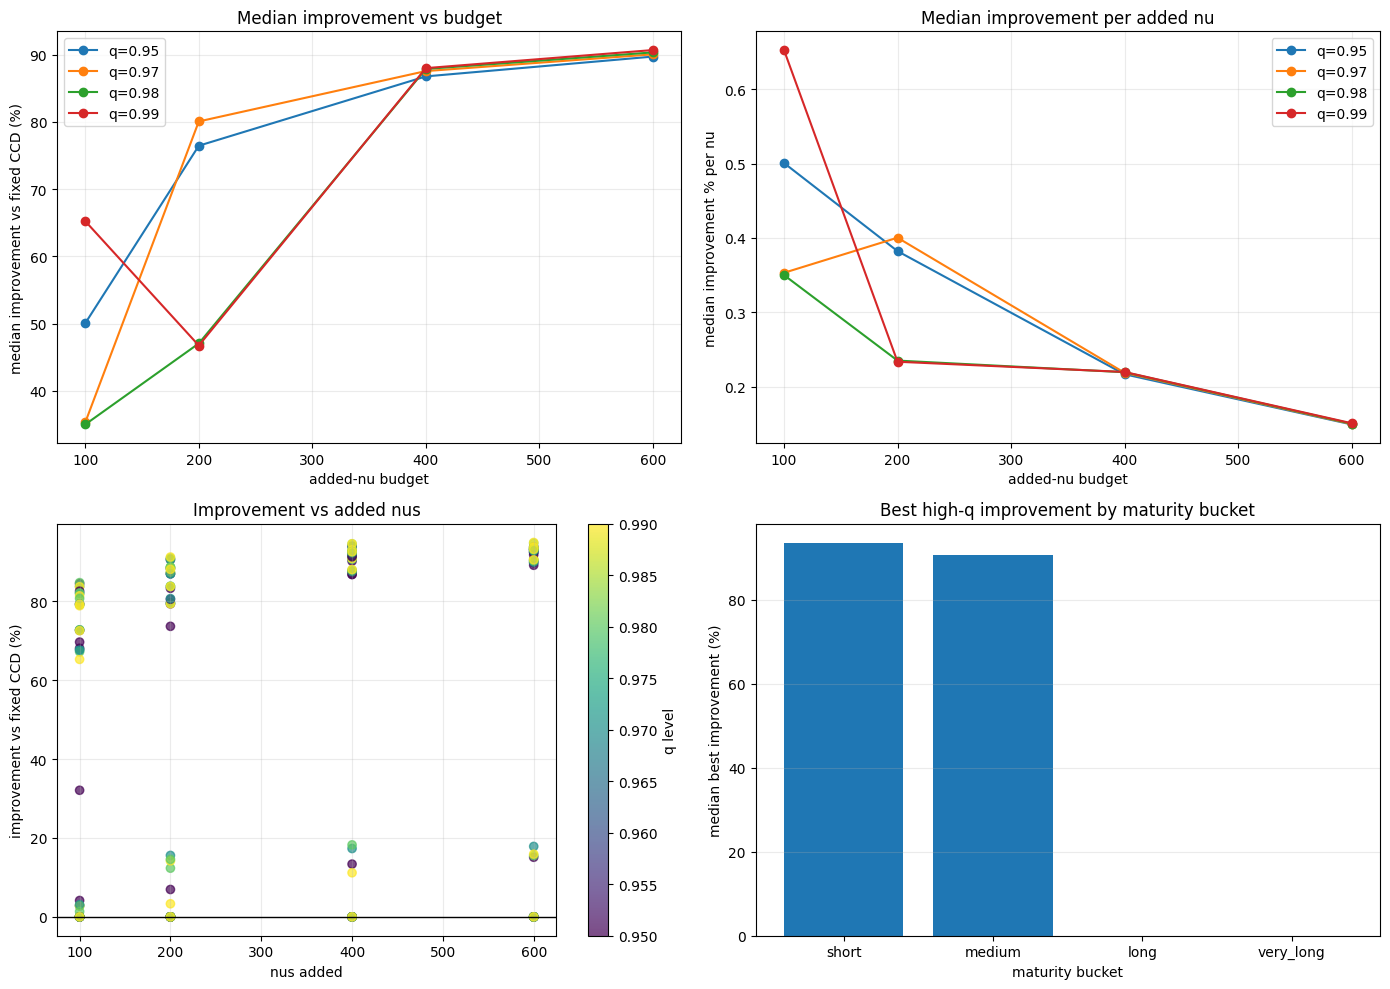

Suggested reading:
If median improvement is still increasing at budget=600, test 800/1200 next.
If improvement per nu drops sharply by budget=600, the practical stopping rule is probably below 600.


In [87]:

def load_high_q_budget_results():
    if "high_q_budget_results" in globals() and isinstance(high_q_budget_results, pd.DataFrame):
        return high_q_budget_results.copy()

    path_candidates = [
        Path("outputs/knot_neighborhood_rawJ_insertion/high_q_budget_results.csv"),
        Path("partner_lvg_private/outputs/knot_neighborhood_rawJ_insertion/high_q_budget_results.csv"),
    ]
    for path in path_candidates:
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError("Could not find high_q_budget_results.csv. Run Step 19 first.")


hq_results = load_high_q_budget_results()
hq_feasible = hq_results[hq_results["feasible"] == True].copy()

print("Rows:", len(hq_results), "Feasible rows:", len(hq_feasible))
display(hq_results.groupby(["q_level", "budget"])["feasible"].mean().reset_index(name="feasibility_rate"))

hq_summary = (
    hq_feasible
    .groupby(["q_level", "budget"])
    .agg(
        count=("improvement_vs_fixed_pct", "count"),
        mean_improvement=("improvement_vs_fixed_pct", "mean"),
        median_improvement=("improvement_vs_fixed_pct", "median"),
        max_improvement=("improvement_vs_fixed_pct", "max"),
        median_nus_added=("nus_added", "median"),
        median_runtime=("runtime", "median"),
    )
    .reset_index()
)
print("High-q mass-budget summary")
display(hq_summary)

best_idx = hq_feasible.groupby(["date", "exdate"])["improvement_vs_fixed_pct"].idxmax()
hq_best_by_chain = hq_feasible.loc[best_idx].sort_values("improvement_vs_fixed_pct", ascending=False).copy()
print("Best high-q setting by chain")
display(hq_best_by_chain[[
    "date", "exdate", "maturity_bucket", "T", "q_level", "budget",
    "improvement_vs_fixed_pct", "nus_added", "fixed_nu_ccd_raw_J", "final_raw_J"
]])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for q_level, group in hq_feasible.groupby("q_level"):
    med = group.groupby("budget")["improvement_vs_fixed_pct"].median().reset_index()
    axes[0, 0].plot(med["budget"], med["improvement_vs_fixed_pct"], marker="o", label=f"q={q_level}")
axes[0, 0].set_title("Median improvement vs budget")
axes[0, 0].set_xlabel("added-nu budget")
axes[0, 0].set_ylabel("median improvement vs fixed CCD (%)")
axes[0, 0].grid(alpha=0.25)
axes[0, 0].legend()

for q_level, group in hq_feasible.groupby("q_level"):
    temp = group.copy()
    temp["improvement_per_nu"] = temp["improvement_vs_fixed_pct"] / temp["nus_added"].replace(0, np.nan)
    med = temp.groupby("budget")["improvement_per_nu"].median().reset_index()
    axes[0, 1].plot(med["budget"], med["improvement_per_nu"], marker="o", label=f"q={q_level}")
axes[0, 1].set_title("Median improvement per added nu")
axes[0, 1].set_xlabel("added-nu budget")
axes[0, 1].set_ylabel("median improvement % per nu")
axes[0, 1].grid(alpha=0.25)
axes[0, 1].legend()

scatter = axes[1, 0].scatter(
    hq_feasible["nus_added"],
    hq_feasible["improvement_vs_fixed_pct"],
    c=hq_feasible["q_level"],
    cmap="viridis",
    alpha=0.7,
)
axes[1, 0].axhline(0.0, color="black", linewidth=1)
axes[1, 0].set_title("Improvement vs added nus")
axes[1, 0].set_xlabel("nus added")
axes[1, 0].set_ylabel("improvement vs fixed CCD (%)")
axes[1, 0].grid(alpha=0.25)
plt.colorbar(scatter, ax=axes[1, 0], label="q level")

bucket_med = (
    hq_best_by_chain
    .groupby("maturity_bucket")["improvement_vs_fixed_pct"]
    .median()
    .reindex(["short", "medium", "long", "very_long"])
)
axes[1, 1].bar(bucket_med.index, bucket_med.values, color="tab:blue")
axes[1, 1].set_title("Best high-q improvement by maturity bucket")
axes[1, 1].set_xlabel("maturity bucket")
axes[1, 1].set_ylabel("median best improvement (%)")
axes[1, 1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print("Suggested reading:")
print("If median improvement is still increasing at budget=600, test 800/1200 next.")
print("If improvement per nu drops sharply by budget=600, the practical stopping rule is probably below 600.")



## Step 20: balanced 100-chain validation of practical mass-budget rules

This is the focused validation run. Step 18/19 established the knot-neighborhood mass-budget idea; here we test only three practical settings on a balanced sample of chains:

- `q=0.95`, `budget=200`: conservative dimensionality.
- `q=0.97`, `budget=400`: practical efficiency candidate.
- `q=0.99`, `budget=600`: max-improvement candidate.

For each chain, the canonical pipeline is unchanged: `build_adjusted_chain -> build_initial_theta_for_chain -> fixed-nu CCD_regular`. The fixed-nu CCD baseline is computed once per chain and reused for all three candidate rules. Each candidate inserts all nus at once, runs one final regular CCD pass, and is judged by feasible raw \(J\) improvement relative to fixed-nu CCD.

The plotting helper is deliberately scalar-safe: `C2_over_V` is only ever called at one strike at a time, because the notebook's LVG pricing helpers are scalar functions.


In [93]:

BALANCED_VALIDATION_RUN = True  # Set True to launch this validation run.
BALANCED_VALIDATION_MODE = "full"  # "smoke" uses 1 chain/bucket and 500 CCD iterations; "full" uses 25 chains/bucket and 20k.
BALANCED_VALIDATION_RANDOM_SEED = 20260626
BALANCED_VALIDATION_PAGE_SIZE = 25

BALANCED_VALIDATION_RULES = [
    {"q_level": 0.95, "budget": 200, "rule_name": "q95_B200_conservative"},
    {"q_level": 0.97, "budget": 400, "rule_name": "q97_B400_practical"},
    {"q_level": 0.99, "budget": 600, "rule_name": "q99_B600_max"},
]


def balanced_validation_settings():
    if BALANCED_VALIDATION_MODE == "smoke":
        return {"chains_per_bucket": 1, "ccd_iterations": 500, "grid_points": 400}
    if BALANCED_VALIDATION_MODE == "full":
        return {"chains_per_bucket": 25, "ccd_iterations": 20000, "grid_points": 800}
    raise ValueError("BALANCED_VALIDATION_MODE must be 'smoke' or 'full'")


def balanced_validation_output_dir():
    cwd = Path.cwd()
    if cwd.name == "partner_lvg_private":
        return Path("outputs/balanced_100_chain_mass_budget_validation")
    return Path("partner_lvg_private/outputs/balanced_100_chain_mass_budget_validation")


BALANCED_VALIDATION_OUTPUT_DIR = balanced_validation_output_dir()
BALANCED_VALIDATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BALANCED_VALIDATION_RESULTS_FILE = BALANCED_VALIDATION_OUTPUT_DIR / "balanced_100_chain_results.csv"
BALANCED_VALIDATION_PAYLOAD_FILE = BALANCED_VALIDATION_OUTPUT_DIR / "balanced_100_chain_curve_payload.pkl"
BALANCED_VALIDATION_SUMMARY_FILE = BALANCED_VALIDATION_OUTPUT_DIR / "balanced_100_chain_summary.csv"
BALANCED_VALIDATION_BEST_FILE = BALANCED_VALIDATION_OUTPUT_DIR / "balanced_100_chain_best_by_chain.csv"


def select_balanced_validation_chains(raw, chains_per_bucket, min_strikes=MIN_STRIKES, seed=BALANCED_VALIDATION_RANDOM_SEED):
    eligible = eligible_chains(raw, min_strikes=min_strikes).copy()
    eligible = eligible[eligible["T"] >= 0.02].copy()
    if eligible.empty:
        raise ValueError("No eligible chains found for balanced validation")

    rng = np.random.default_rng(seed)
    parts = []
    for bucket in ["short", "medium", "long", "very_long"]:
        group = eligible[eligible["maturity_bucket"] == bucket].copy().reset_index(drop=True)
        if group.empty:
            print(f"No eligible chains found for bucket={bucket}")
            continue
        take = min(int(chains_per_bucket), len(group))
        if take < chains_per_bucket:
            print(f"Only {take} eligible chains available for bucket={bucket}")
        selected_idx = np.sort(rng.choice(len(group), size=take, replace=False))
        parts.append(group.iloc[selected_idx])

    selected = pd.concat(parts, ignore_index=True).drop_duplicates(["date", "exdate"])
    return selected.sort_values(["maturity_bucket", "date", "T", "exdate"]).reset_index(drop=True)


def sigma2_curve_on_grid(R1, R2, S0, theta, grid):
    R1, R2 = int(R1), int(R2)
    theta = np.asarray(theta, dtype=float)
    c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    values = []
    for k in np.asarray(grid, dtype=float):
        try:
            c2_over_v = C2_over_V(float(k), R1, R2, S0, theta, c_v1, c_v2)
            if np.isfinite(c2_over_v) and abs(c2_over_v) > EPS:
                values.append(1.0 / c2_over_v)
            else:
                values.append(np.nan)
        except Exception:
            values.append(np.nan)
    values = np.asarray(values, dtype=float)
    values[~np.isfinite(values)] = np.nan
    return values


def base_row_for_balanced_chain(chain_info, chain, R1, R2, init_theta, fixed_theta, fixed_runtime, fixed_accepted):
    R1, R2 = int(R1), int(R2)
    S0 = float(chain["S0"])
    original_J = J_value(R1, R2, S0, init_theta)
    fixed_J = J_value(R1, R2, S0, fixed_theta)
    fixed_slack = quote_slack_report(R1, R2, S0, fixed_theta, chain["bid_ask"])
    return {
        "date": int(chain_info["date"]),
        "exdate": int(chain_info["exdate"]),
        "maturity_bucket": chain_info["maturity_bucket"],
        "T": float(chain_info["T"]),
        "S0": S0,
        "original_raw_J": float(original_J),
        "fixed_nu_ccd_raw_J": float(fixed_J),
        "fixed_runtime": float(fixed_runtime),
        "fixed_accepted_moves": int(fixed_accepted),
        "fixed_feasible": bool(fixed_slack["feasible"]),
        "fixed_min_bid_slack": float(fixed_slack["min_bid_slack"]),
        "fixed_min_ask_slack": float(fixed_slack["min_ask_slack"]),
        "fixed_R1": R1,
        "fixed_R2": R2,
    }


def run_balanced_mass_budget_candidate(base_row, chain, fixed_R1, fixed_R2, fixed_theta, rule, ccd_iterations):
    fixed_R1, fixed_R2 = int(fixed_R1), int(fixed_R2)
    S0 = float(chain["S0"])
    q_level = float(rule["q_level"])
    budget = int(rule["budget"])
    rule_name = rule["rule_name"]

    start_insert = time.time()
    selected_intervals, selected_knots, _ = knot_neighborhood_intervals(fixed_R1, fixed_R2, S0, fixed_theta, q_level)
    regions = merge_selected_interval_regions(selected_intervals)
    allocations = mass_budget_allocations(selected_intervals, budget)
    inserted = insert_nus_from_interval_allocations(fixed_R1, fixed_R2, S0, fixed_theta, allocations)
    insertion_runtime = time.time() - start_insert

    row = dict(base_row)
    row.update({
        "rule_name": rule_name,
        "q_level": q_level,
        "budget": budget,
        "selected_knots": int(len(selected_knots)),
        "selected_intervals": int(len(selected_intervals)),
        "merged_regions": int(len(regions)),
        "insertion_runtime": float(insertion_runtime),
    })

    if inserted is None:
        row.update({
            "nus_added": 0,
            "final_raw_J": np.nan,
            "improvement_vs_fixed_pct": np.nan,
            "improvement_per_added_nu": np.nan,
            "final_runtime": np.nan,
            "total_runtime": np.nan,
            "accepted_moves": 0,
            "feasible": False,
            "min_bid_slack": np.nan,
            "min_ask_slack": np.nan,
            "final_R1": np.nan,
            "final_R2": np.nan,
            "status": "insertion_failed",
        })
        return row, None

    new_R1, new_R2, theta_inserted = inserted
    new_R1, new_R2 = int(new_R1), int(new_R2)
    theta_inserted = np.asarray(theta_inserted, dtype=float)

    start_final = time.time()
    theta_final, _, accepted_moves = coordinate_descent_sigma(
        new_R1, new_R2, S0, theta_inserted, chain["bid_ask"],
        proxy_kind="regular", update_order="cyclic",
        num_iterations=int(ccd_iterations), record_every=None,
    )
    final_runtime = time.time() - start_final

    final_J = J_value(new_R1, new_R2, S0, theta_final)
    fixed_J = float(base_row["fixed_nu_ccd_raw_J"])
    slack = quote_slack_report(new_R1, new_R2, S0, theta_final, chain["bid_ask"])
    nus_added = (new_R1 + new_R2) - (fixed_R1 + fixed_R2)

    row.update({
        "nus_added": int(nus_added),
        "final_raw_J": float(final_J),
        "improvement_vs_fixed_pct": float(100.0 * (fixed_J - final_J) / fixed_J) if fixed_J > 0 else np.nan,
        "improvement_per_added_nu": float(100.0 * (fixed_J - final_J) / fixed_J / nus_added) if fixed_J > 0 and nus_added > 0 else np.nan,
        "final_runtime": float(final_runtime),
        "total_runtime": float(base_row["fixed_runtime"] + insertion_runtime + final_runtime),
        "accepted_moves": int(accepted_moves),
        "feasible": bool(slack["feasible"]),
        "min_bid_slack": float(slack["min_bid_slack"]),
        "min_ask_slack": float(slack["min_ask_slack"]),
        "final_R1": int(new_R1),
        "final_R2": int(new_R2),
        "status": "ok",
    })
    return row, (new_R1, new_R2, theta_final)


def run_one_balanced_validation_chain(chain_info, ccd_iterations, grid_points):
    chain = build_adjusted_chain(raw_spx, int(chain_info["date"]), int(chain_info["exdate"]), MIN_STRIKES)
    R1, R2, init_theta = build_initial_theta_for_chain(chain)
    R1, R2 = int(R1), int(R2)
    init_theta = np.asarray(init_theta, dtype=float)
    S0 = float(chain["S0"])

    start_fixed = time.time()
    fixed_theta, _, fixed_accepted = coordinate_descent_sigma(
        R1, R2, S0, init_theta, chain["bid_ask"],
        proxy_kind="regular", update_order="cyclic",
        num_iterations=int(ccd_iterations), record_every=None,
    )
    fixed_runtime = time.time() - start_fixed

    base_row = base_row_for_balanced_chain(chain_info, chain, R1, R2, init_theta, fixed_theta, fixed_runtime, fixed_accepted)
    rows = []
    curves = {
        "fixed-nu CCD": (R1, R2, fixed_theta),
    }

    for rule in BALANCED_VALIDATION_RULES:
        row, final_curve = run_balanced_mass_budget_candidate(base_row, chain, R1, R2, fixed_theta, rule, ccd_iterations)
        rows.append(row)
        if final_curve is not None:
            curves[rule["rule_name"]] = final_curve

    grid = np.linspace(float(np.min(chain["K"])), float(np.max(chain["K"])), int(grid_points))
    curve_values = {}
    for name, (curve_R1, curve_R2, curve_theta) in curves.items():
        curve_values[name] = {
            "R1": int(curve_R1),
            "R2": int(curve_R2),
            "sigma2": sigma2_curve_on_grid(curve_R1, curve_R2, S0, curve_theta, grid),
        }

    payload_row = {
        "date": base_row["date"],
        "exdate": base_row["exdate"],
        "maturity_bucket": base_row["maturity_bucket"],
        "T": base_row["T"],
        "S0": base_row["S0"],
        "fixed_nu_ccd_raw_J": base_row["fixed_nu_ccd_raw_J"],
    }
    return rows, {"row": payload_row, "grid": grid, "curves": curve_values}


def save_balanced_payload(payload):
    import pickle
    with open(BALANCED_VALIDATION_PAYLOAD_FILE, "wb") as f:
        pickle.dump(payload, f)


def load_balanced_payload():
    import pickle
    with open(BALANCED_VALIDATION_PAYLOAD_FILE, "rb") as f:
        return pickle.load(f)


def run_balanced_100_chain_validation():
    settings = balanced_validation_settings()
    selected = select_balanced_validation_chains(raw_spx, settings["chains_per_bucket"])
    print("Selected balanced validation chains")
    display(selected.groupby("maturity_bucket").size().rename("chains"))
    display_cols = ["date", "exdate", "maturity_bucket", "T"]
    for optional_col in ["n_strikes", "num_strikes", "count", "n", "common_strikes"]:
        if optional_col in selected.columns:
            display_cols.append(optional_col)
            break
    display(selected[display_cols])

    rows = []
    payload = []
    total = len(selected)
    for pos, (_, chain_info) in enumerate(selected.iterrows(), start=1):
        print(f"[{pos}/{total}] date={int(chain_info['date'])}, exdate={int(chain_info['exdate'])}, bucket={chain_info['maturity_bucket']}")
        try:
            chain_rows, chain_payload = run_one_balanced_validation_chain(
                chain_info, settings["ccd_iterations"], settings["grid_points"]
            )
            rows.extend(chain_rows)
            payload.append(chain_payload)
        except Exception as exc:
            import traceback
            print(f"  failed: {exc}")
            traceback.print_exc(limit=3)
            rows.append({
                "date": int(chain_info["date"]),
                "exdate": int(chain_info["exdate"]),
                "maturity_bucket": chain_info["maturity_bucket"],
                "T": float(chain_info["T"]),
                "rule_name": "chain_failed",
                "status": f"failed: {exc}",
                "feasible": False,
            })
        pd.DataFrame(rows).to_csv(BALANCED_VALIDATION_RESULTS_FILE, index=False)
        save_balanced_payload(payload)

    results = pd.DataFrame(rows)
    results.to_csv(BALANCED_VALIDATION_RESULTS_FILE, index=False)
    save_balanced_payload(payload)
    print(f"Saved {len(results)} rows to {BALANCED_VALIDATION_RESULTS_FILE}")
    print(f"Saved {len(payload)} chain payloads to {BALANCED_VALIDATION_PAYLOAD_FILE}")
    return results, payload


if BALANCED_VALIDATION_RUN:
    balanced_validation_results, balanced_validation_payload = run_balanced_100_chain_validation()
else:
    print("Set BALANCED_VALIDATION_RUN = True to run Step 20.")
    print("Use BALANCED_VALIDATION_MODE = 'smoke' first, then 'full' for the 100-chain run.")


Selected balanced validation chains


maturity_bucket
long         25
medium       25
short        25
very_long    25
Name: chains, dtype: int64

,date,exdate,maturity_bucket,T,common_strikes
0,20110131,20110618,long,0.396825,68
1,20110322,20110716,long,0.333333,37
2,20110429,20111217,long,0.658730,76
3,20110516,20110820,long,0.277778,80
4,20110517,20110820,long,0.273810,95
...,...,...,...,...,...
95,20120802,20130628,very_long,0.936508,44
96,20120912,20130628,very_long,0.821429,44
97,20121127,20131221,very_long,1.107143,53
98,20121213,20130921,very_long,0.801587,51


[1/100] date=20110131, exdate=20110618, bucket=long
[2/100] date=20110322, exdate=20110716, bucket=long
[3/100] date=20110429, exdate=20111217, bucket=long
[4/100] date=20110516, exdate=20110820, bucket=long
[5/100] date=20110517, exdate=20110820, bucket=long
[6/100] date=20110531, exdate=20111230, bucket=long
[7/100] date=20110608, exdate=20111217, bucket=long
[8/100] date=20110615, exdate=20111217, bucket=long
[9/100] date=20110811, exdate=20111230, bucket=long
[10/100] date=20110822, exdate=20111217, bucket=long
[11/100] date=20111007, exdate=20120121, bucket=long
[12/100] date=20111228, exdate=20120629, bucket=long
[13/100] date=20120213, exdate=20120629, bucket=long
[14/100] date=20120217, exdate=20120928, bucket=long
[15/100] date=20120306, exdate=20120922, bucket=long
[16/100] date=20120405, exdate=20120721, bucket=long
[17/100] date=20120521, exdate=20120922, bucket=long
[18/100] date=20120614, exdate=20120922, bucket=long
[19/100] date=20120629, exdate=20121231, bucket=long
[2

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


...

[73/100] date=20121107, exdate=20121130, bucket=short


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


[74/100] date=20121120, exdate=20121130, bucket=short
[75/100] date=20121206, exdate=20121228, bucket=short


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


[76/100] date=20110106, exdate=20111230, bucket=very_long
[77/100] date=20110124, exdate=20111217, bucket=very_long
[78/100] date=20110216, exdate=20111230, bucket=very_long
[79/100] date=20110315, exdate=20111217, bucket=very_long
[80/100] date=20110325, exdate=20120317, bucket=very_long
[81/100] date=20110328, exdate=20111217, bucket=very_long
[82/100] date=20110602, exdate=20120317, bucket=very_long
[83/100] date=20110621, exdate=20120317, bucket=very_long
[84/100] date=20110803, exdate=20120629, bucket=very_long
[85/100] date=20111005, exdate=20120928, bucket=very_long
[86/100] date=20111017, exdate=20120928, bucket=very_long
[87/100] date=20111026, exdate=20120922, bucket=very_long
[88/100] date=20111115, exdate=20120928, bucket=very_long
[89/100] date=20111206, exdate=20121222, bucket=very_long
[90/100] date=20111223, exdate=20120922, bucket=very_long
[91/100] date=20120113, exdate=20121231, bucket=very_long
[92/100] date=20120419, exdate=20130328, bucket=very_long
[93/100] date=

## Step 20B: summarize and visualize the balanced validation

This section reads the Step 20 CSV and curve payload. It reports both means and medians, then saves paged visualizations of all chains in the validation sample.


Mean/median summary by rule


,rule_name,rows,mean_improvement,median_improvement,min_improvement,max_improvement,mean_improvement_per_nu,median_improvement_per_nu,mean_runtime,median_runtime,mean_nus_added,median_nus_added,feasibility_rate
2,q99_B600_max,99,50.313906,87.007109,-0.000426,95.177764,0.083857,0.145012,55.927253,53.396518,600.0,600.0,1.0
1,q97_B400_practical,98,47.078032,81.249570,-0.000947,95.224684,0.117695,0.203124,55.056898,51.299600,400.0,400.0,1.0
0,q95_B200_conservative,98,39.901988,15.439119,-0.001200,93.377073,0.199510,0.077196,57.028451,52.490541,200.0,200.0,1.0


Mean/median summary by maturity bucket


,maturity_bucket,rule_name,rows,mean_improvement,median_improvement,mean_runtime,median_runtime
0,long,q95_B200_conservative,25,25.066651,5.630487e-03,50.622296,43.007054
1,long,q97_B400_practical,25,33.506332,6.266771e-03,48.827067,42.898214
2,long,q99_B600_max,25,34.954517,2.171320e-02,49.144802,46.159202
3,medium,q95_B200_conservative,25,68.460211,8.002562e+01,57.937977,47.806336
4,medium,q97_B400_practical,25,78.670528,8.842775e+01,57.240049,51.055165
5,medium,q99_B600_max,25,81.842200,9.141837e+01,60.001763,55.293693
6,short,q95_B200_conservative,24,55.293477,7.699422e+01,74.645363,68.167760
7,short,q97_B400_practical,24,63.790481,8.892963e+01,71.283130,65.713232
8,short,q99_B600_max,24,65.553820,9.171297e+01,69.671816,67.375295
9,very_long,q95_B200_conservative,24,10.215827,5.669486e-13,45.137193,45.361253


Win counts by rule


,rule_name,chains_won
0,q99_B600_max,70
1,q97_B400_practical,16
2,q95_B200_conservative,13


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/3322459050.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(data, labels=order, showmeans=True)


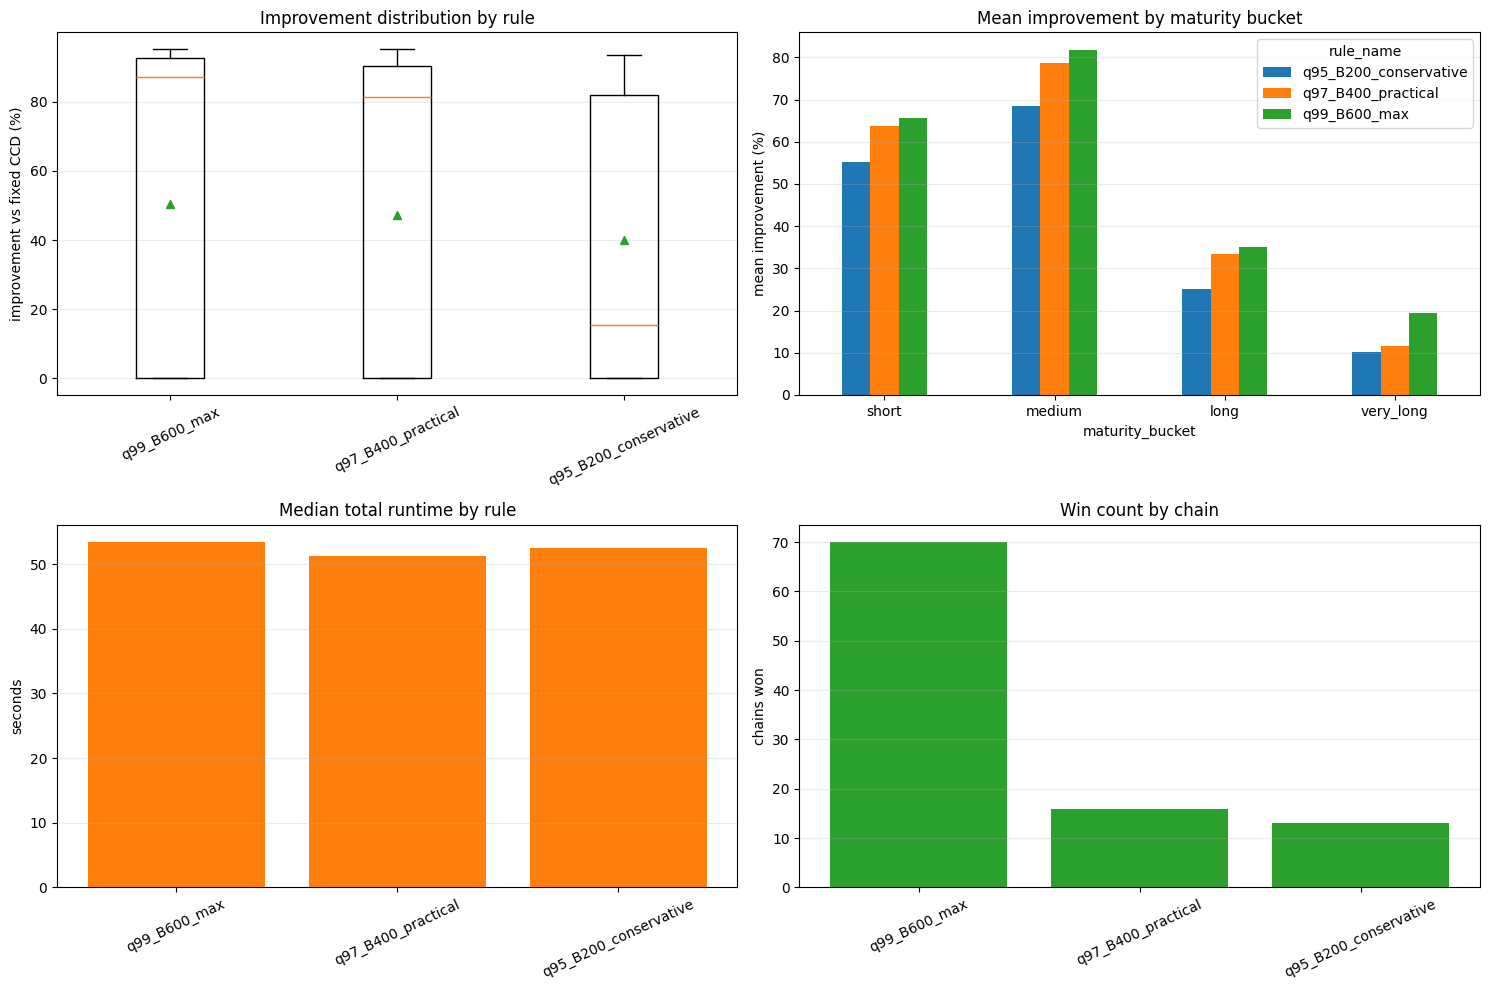

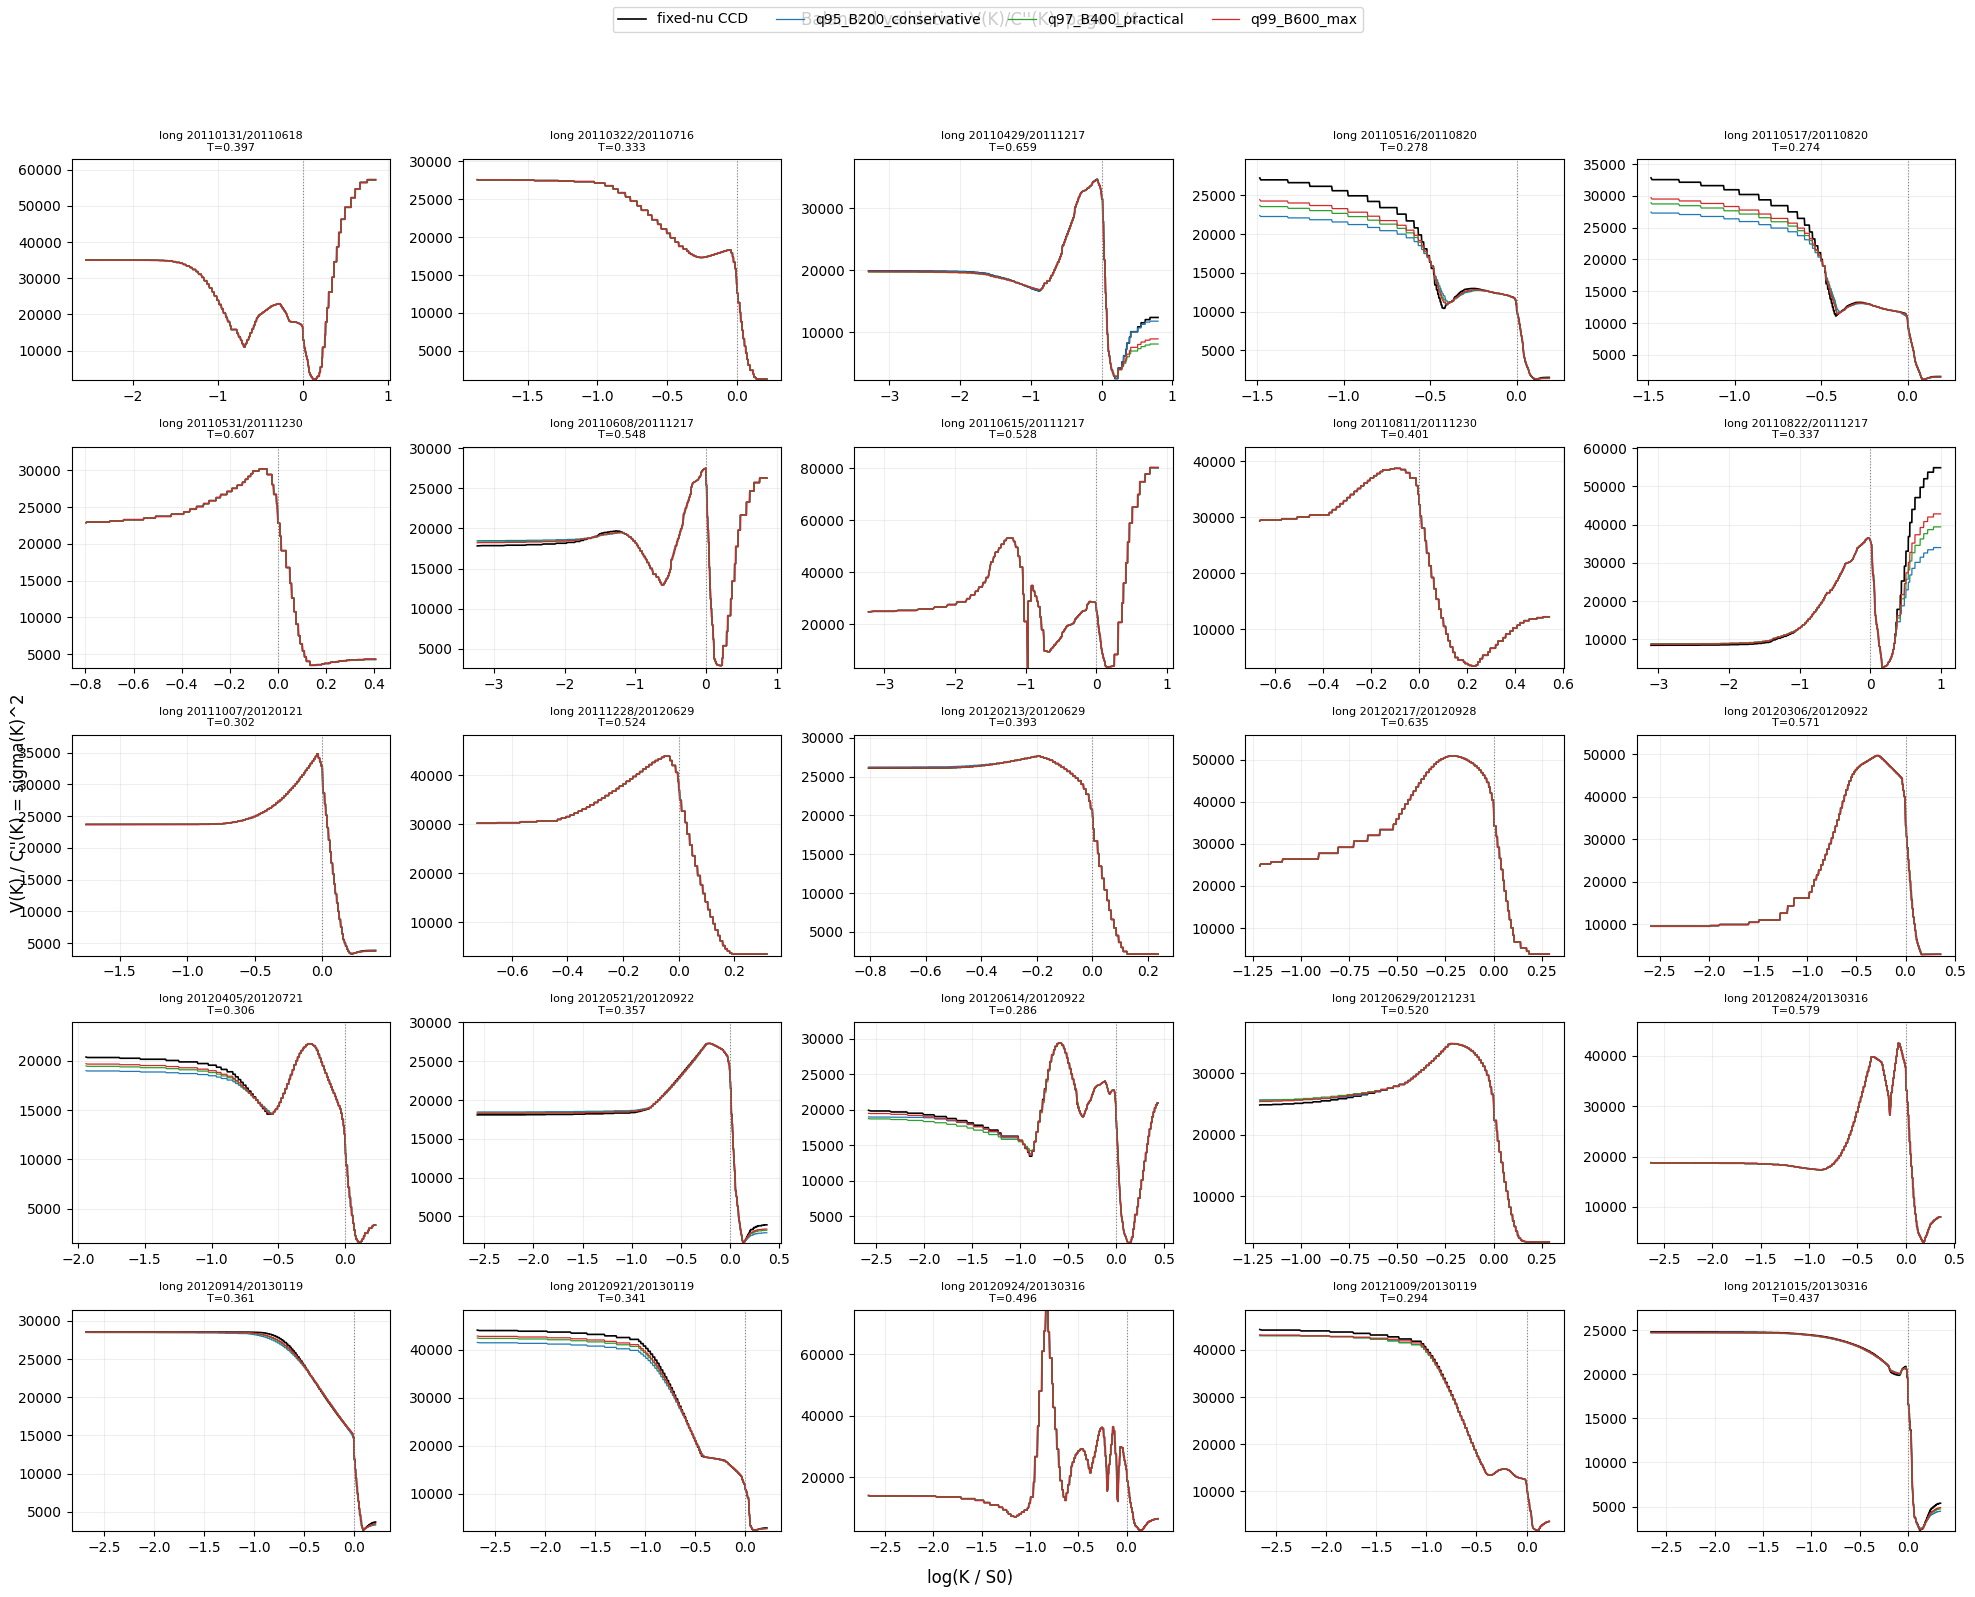

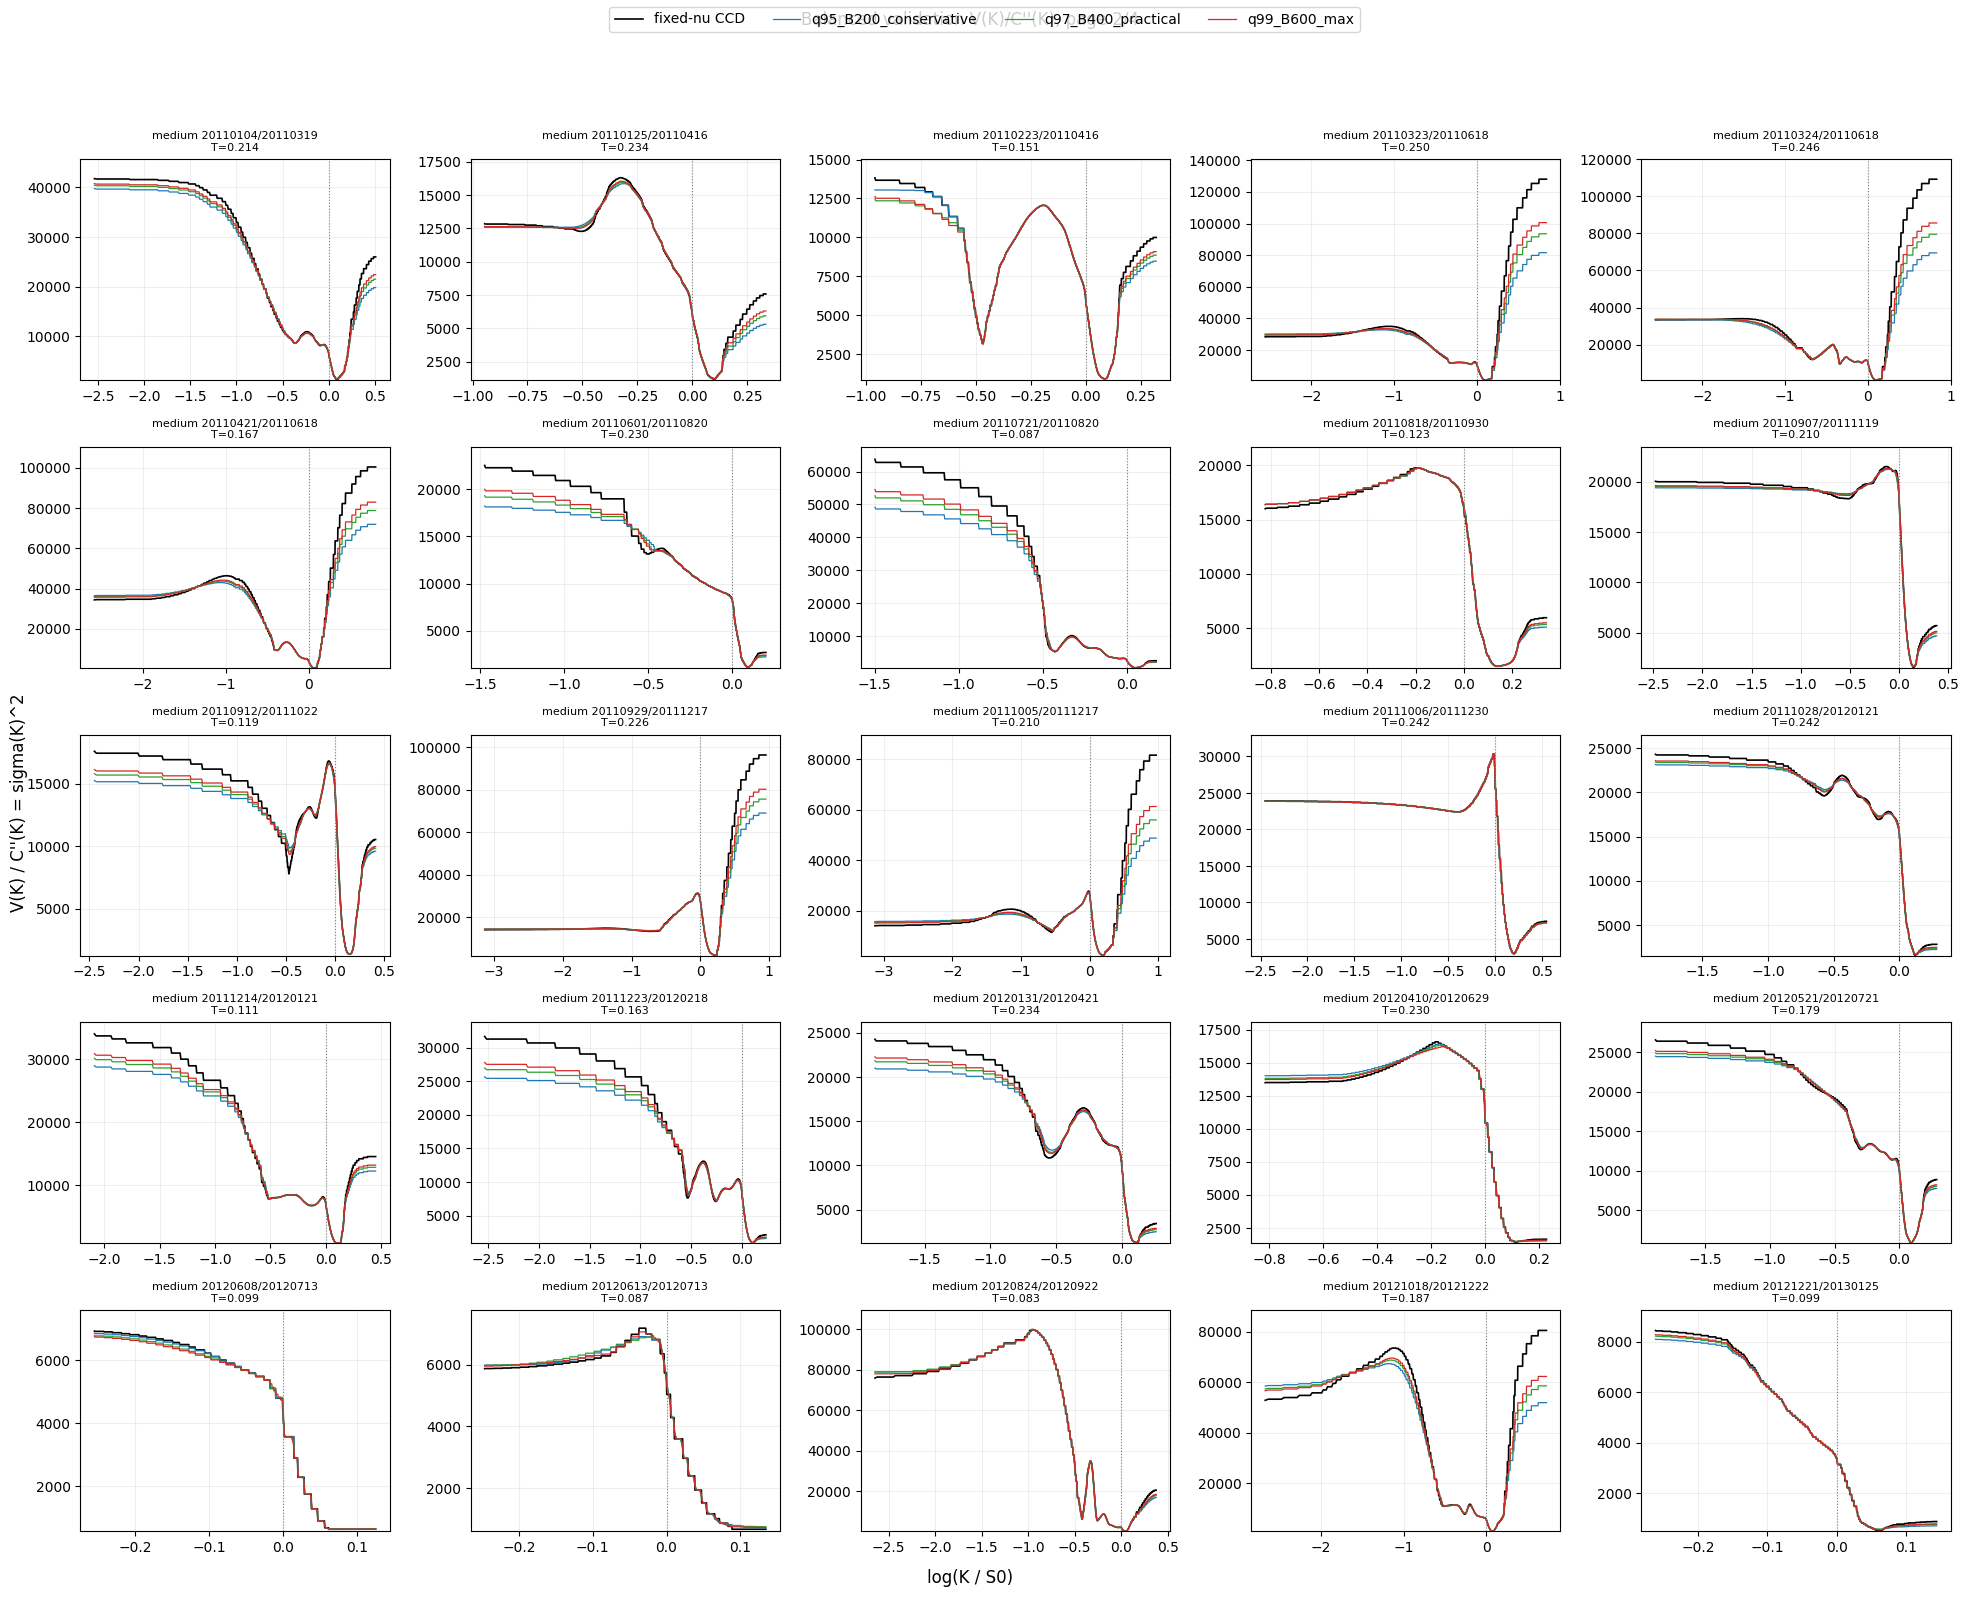

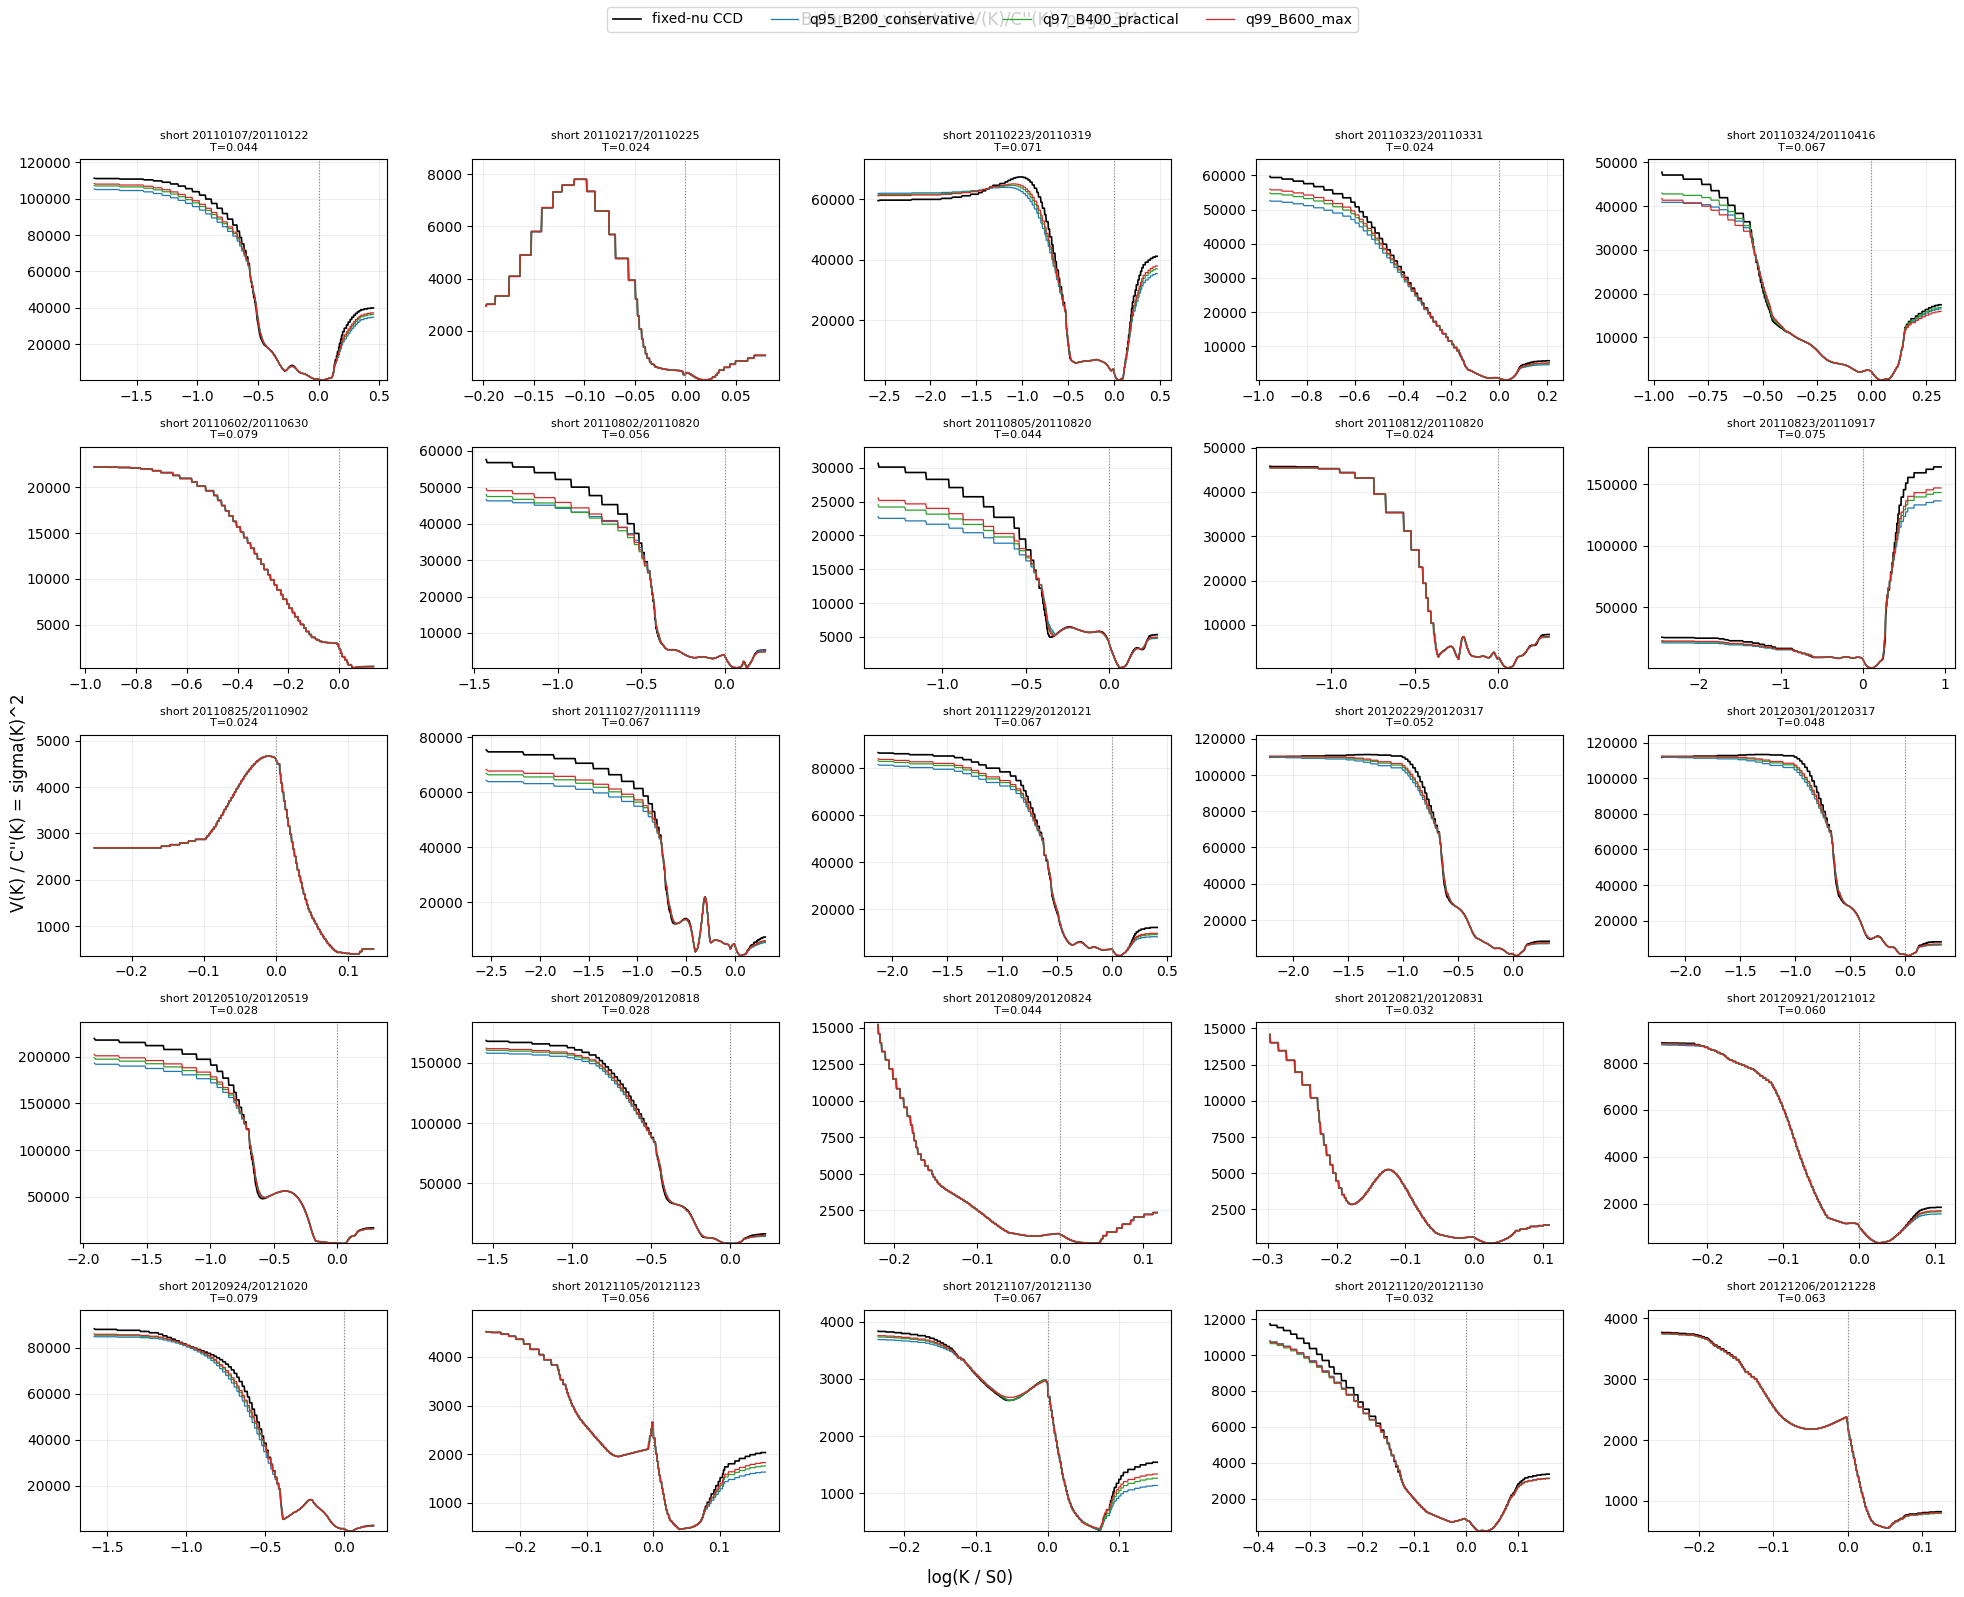

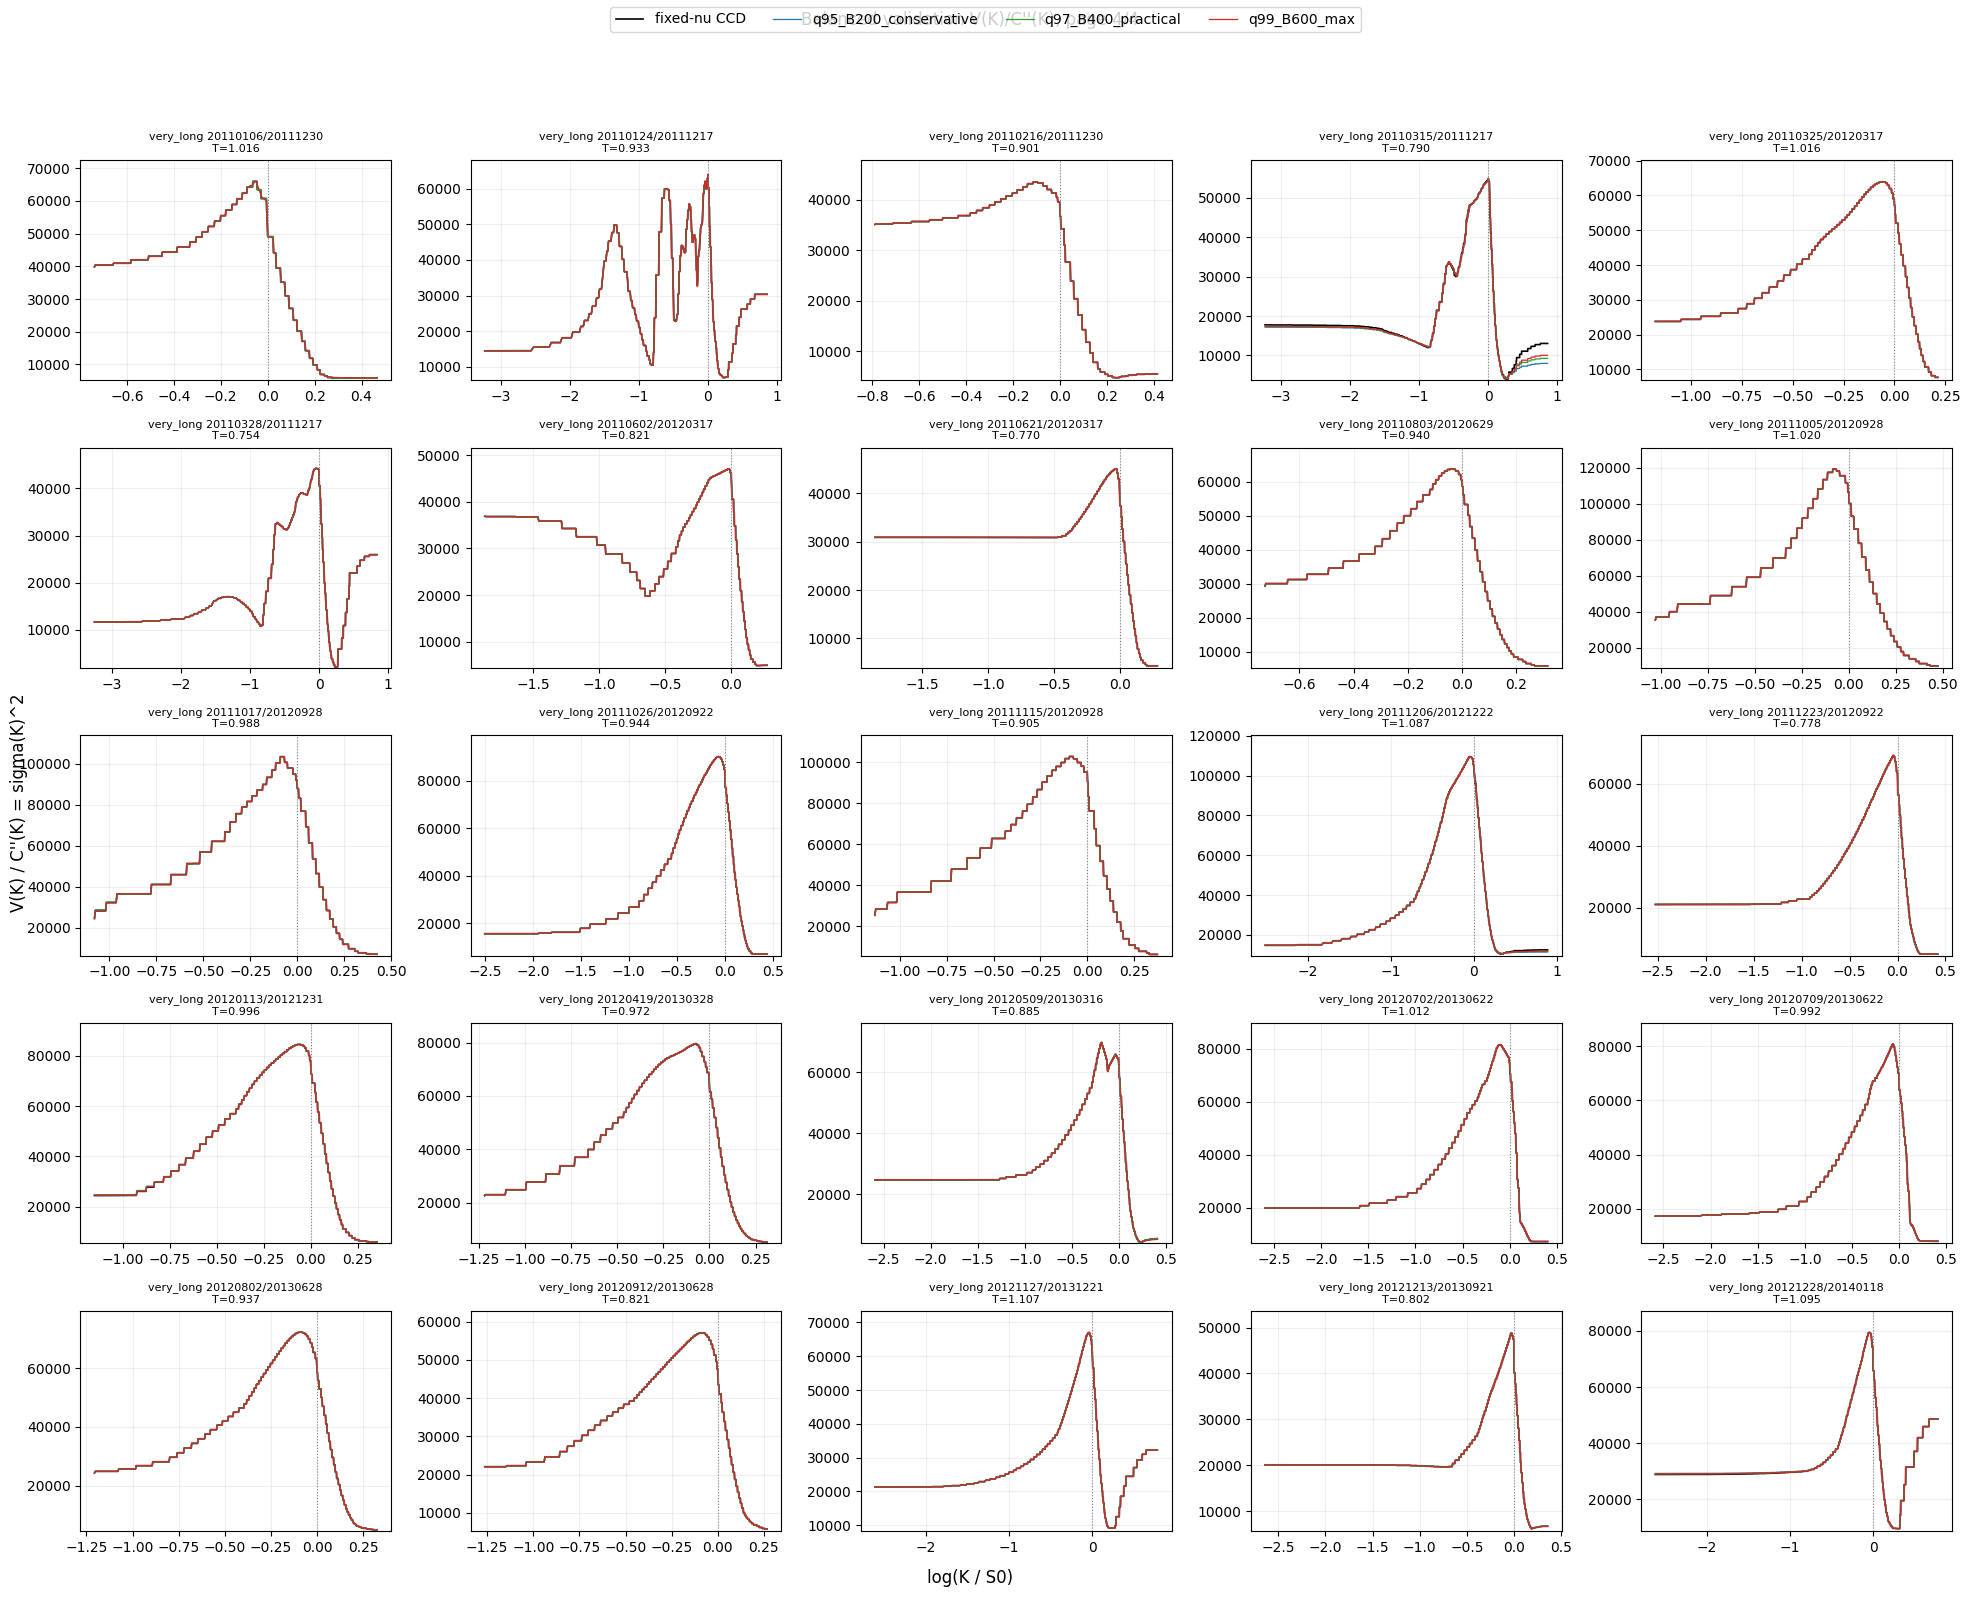

In [95]:

def load_balanced_validation_results():
    if "balanced_validation_results" in globals() and isinstance(balanced_validation_results, pd.DataFrame):
        return balanced_validation_results.copy()
    candidates = [
        Path("outputs/balanced_100_chain_mass_budget_validation/balanced_100_chain_results.csv"),
        Path("partner_lvg_private/outputs/balanced_100_chain_mass_budget_validation/balanced_100_chain_results.csv"),
    ]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError("Could not find balanced_100_chain_results.csv. Run Step 20 first.")


def load_balanced_validation_payload():
    import pickle
    candidates = [
        Path("outputs/balanced_100_chain_mass_budget_validation/balanced_100_chain_curve_payload.pkl"),
        Path("partner_lvg_private/outputs/balanced_100_chain_mass_budget_validation/balanced_100_chain_curve_payload.pkl"),
    ]
    for path in candidates:
        if path.exists():
            with open(path, "rb") as f:
                return pickle.load(f)
    return []


def summarize_balanced_validation(results):
    ok = results[(results.get("status", "ok") == "ok")].copy()
    feasible = ok[ok["feasible"] == True].copy()
    if feasible.empty:
        print("No feasible Step 20 rows to summarize.")
        return feasible, pd.DataFrame(), pd.DataFrame()

    summary = (
        feasible.groupby("rule_name")
        .agg(
            rows=("improvement_vs_fixed_pct", "count"),
            mean_improvement=("improvement_vs_fixed_pct", "mean"),
            median_improvement=("improvement_vs_fixed_pct", "median"),
            min_improvement=("improvement_vs_fixed_pct", "min"),
            max_improvement=("improvement_vs_fixed_pct", "max"),
            mean_improvement_per_nu=("improvement_per_added_nu", "mean"),
            median_improvement_per_nu=("improvement_per_added_nu", "median"),
            mean_runtime=("total_runtime", "mean"),
            median_runtime=("total_runtime", "median"),
            mean_nus_added=("nus_added", "mean"),
            median_nus_added=("nus_added", "median"),
            feasibility_rate=("feasible", "mean"),
        )
        .reset_index()
        .sort_values("median_improvement", ascending=False)
    )

    bucket_summary = (
        feasible.groupby(["maturity_bucket", "rule_name"])
        .agg(
            rows=("improvement_vs_fixed_pct", "count"),
            mean_improvement=("improvement_vs_fixed_pct", "mean"),
            median_improvement=("improvement_vs_fixed_pct", "median"),
            mean_runtime=("total_runtime", "mean"),
            median_runtime=("total_runtime", "median"),
        )
        .reset_index()
    )

    best_idx = feasible.groupby(["date", "exdate"])["improvement_vs_fixed_pct"].idxmax()
    best_by_chain = feasible.loc[best_idx].sort_values("improvement_vs_fixed_pct", ascending=False).copy()

    summary.to_csv(BALANCED_VALIDATION_SUMMARY_FILE, index=False)
    best_by_chain.to_csv(BALANCED_VALIDATION_BEST_FILE, index=False)

    print("Mean/median summary by rule")
    display(summary)
    print("Mean/median summary by maturity bucket")
    display(bucket_summary)
    print("Win counts by rule")
    display(best_by_chain["rule_name"].value_counts().rename_axis("rule_name").reset_index(name="chains_won"))
    return feasible, summary, best_by_chain


def plot_balanced_validation_summary(feasible, best_by_chain):
    if feasible.empty:
        print("No feasible Step 20 rows to plot.")
        return
    order = feasible.groupby("rule_name")["improvement_vs_fixed_pct"].median().sort_values(ascending=False).index.tolist()

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    data = [feasible.loc[feasible["rule_name"] == name, "improvement_vs_fixed_pct"].dropna() for name in order]
    axes[0, 0].boxplot(data, labels=order, showmeans=True)
    axes[0, 0].set_title("Improvement distribution by rule")
    axes[0, 0].set_ylabel("improvement vs fixed CCD (%)")
    axes[0, 0].tick_params(axis="x", rotation=25)
    axes[0, 0].grid(axis="y", alpha=0.25)

    mean_bucket = feasible.pivot_table(
        index="maturity_bucket", columns="rule_name", values="improvement_vs_fixed_pct", aggfunc="mean"
    ).reindex(["short", "medium", "long", "very_long"])
    mean_bucket.plot(kind="bar", ax=axes[0, 1])
    axes[0, 1].set_title("Mean improvement by maturity bucket")
    axes[0, 1].set_ylabel("mean improvement (%)")
    axes[0, 1].tick_params(axis="x", rotation=0)
    axes[0, 1].grid(axis="y", alpha=0.25)

    runtime = feasible.groupby("rule_name")["total_runtime"].median().reindex(order)
    axes[1, 0].bar(runtime.index, runtime.values, color="tab:orange")
    axes[1, 0].set_title("Median total runtime by rule")
    axes[1, 0].set_ylabel("seconds")
    axes[1, 0].tick_params(axis="x", rotation=25)
    axes[1, 0].grid(axis="y", alpha=0.25)

    wins = best_by_chain["rule_name"].value_counts().reindex(order).fillna(0)
    axes[1, 1].bar(wins.index, wins.values, color="tab:green")
    axes[1, 1].set_title("Win count by chain")
    axes[1, 1].set_ylabel("chains won")
    axes[1, 1].tick_params(axis="x", rotation=25)
    axes[1, 1].grid(axis="y", alpha=0.25)

    plt.tight_layout()
    fig.savefig(BALANCED_VALIDATION_OUTPUT_DIR / "balanced_validation_summary_plots.png", dpi=150, bbox_inches="tight")
    plt.show()


def ensure_sigma2_values(y):
    y = np.asarray(y, dtype=float)
    finite = y[np.isfinite(y)]
    if finite.size == 0:
        return y
    # Older Step 20 payloads accidentally stored C''/V = 1/sigma^2.
    # For this LVG scale true sigma^2 is much larger than 1, so invert tiny positive curves.
    if np.nanmedian(np.abs(finite)) < 1.0 and np.all(finite > 0):
        out = np.full_like(y, np.nan, dtype=float)
        good = np.isfinite(y) & (np.abs(y) > EPS)
        out[good] = 1.0 / y[good]
        return out
    return y


def plot_balanced_validation_chain_pages(payload, page_size=BALANCED_VALIDATION_PAGE_SIZE):
    if not payload:
        print("No curve payload found. Run Step 20 first.")
        return

    style = [
        ("fixed-nu CCD", "black", 1.2),
        ("q95_B200_conservative", "tab:blue", 0.9),
        ("q97_B400_practical", "tab:green", 0.9),
        ("q99_B600_max", "tab:red", 0.9),
    ]
    n_pages = int(np.ceil(len(payload) / page_size))
    for page in range(n_pages):
        subset = payload[page * page_size:(page + 1) * page_size]
        ncols = 5
        nrows = int(np.ceil(len(subset) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.2 * nrows), sharex=False, sharey=False)
        axes = np.asarray(axes).reshape(-1)

        for ax, item in zip(axes, subset):
            row = item["row"]
            grid = item["grid"]
            curves = item["curves"]
            x = np.log(np.asarray(grid, dtype=float) / float(row["S0"]))
            y_arrays = []
            for label, color, linewidth in style:
                if label not in curves:
                    continue
                y = ensure_sigma2_values(curves[label]["sigma2"])
                ax.plot(x, y, color=color, linewidth=linewidth, label=label)
                y_arrays.append(y)
            ax.axvline(0.0, color="gray", linestyle=":", linewidth=0.8)
            visual_apply_robust_ylim(ax, y_arrays)
            ax.set_title(f"{row['maturity_bucket']} {int(row['date'])}/{int(row['exdate'])}\nT={row['T']:.3f}", fontsize=8)
            ax.grid(alpha=0.2)

        for ax in axes[len(subset):]:
            ax.axis("off")
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=4)
        fig.suptitle(f"Balanced validation V(K)/C''(K), page {page + 1}/{n_pages}", y=0.995)
        fig.supxlabel("log(K / S0)")
        fig.supylabel("V(K) / C''(K) = sigma(K)^2")
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        out = BALANCED_VALIDATION_OUTPUT_DIR / f"balanced_validation_chain_curves_page_{page + 1:02d}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()


try:
    balanced_loaded = load_balanced_validation_results()
    balanced_feasible, balanced_summary, balanced_best_by_chain = summarize_balanced_validation(balanced_loaded)
    plot_balanced_validation_summary(balanced_feasible, balanced_best_by_chain)
    balanced_payload_loaded = load_balanced_validation_payload()
    plot_balanced_validation_chain_pages(balanced_payload_loaded)
except FileNotFoundError as exc:
    print(exc)
    print("Run Step 20 first. Recommended first run: BALANCED_VALIDATION_MODE = 'smoke', BALANCED_VALIDATION_RUN = True.")


## Step 21: inspect one high-improvement mass-budget chain

This diagnostic zooms in on one chain where the `q=0.99`, `budget=600` mass-budget rule greatly improved raw \(J\). It shows the raw-J jump contributions before and after nu insertion, and shades the total knot-neighborhood interval(s) where new nus were inserted.

The goal is to make the algorithm visible: the selected raw-J knots define left/right neighboring intervals, those intervals merge into one or more target regions, the budget is allocated across those intervals, and then CCD is rerun on the enlarged theta.


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Selected chain: date=20120608, exdate=20120713, bucket=medium, T=0.099
fixed-nu CCD J      = 1.5489104712821446e-05
after insertion J   = 7.4692116032221122e-07
improvement         = 95.177764%
nus added           = 600
selected knots      = 9
selected intervals  = 11
merged regions      = 1
Selected raw-J knots explaining q mass


,knot,jump_squared,wing
0,1388.324552,3.348710e-06,right
1,1376.820025,2.835259e-06,right
2,1363.590087,2.604225e-06,right
3,1351.786933,2.269834e-06,right
4,1344.634757,1.637600e-06,right
5,1401.853116,1.421588e-06,right
6,1326.753842,6.776202e-07,right
7,1325.610287,4.633486e-07,right
8,1311.786333,9.815022e-08,left


Merged target region(s) where nus were added


,left,right,width,jump_mass,interval_indices
0,1301.720751,1409.221486,107.500735,0.000015,"[24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]"


Top allocated intervals


,interval_index,left,right,width,jump_mass,selected,allocated_nus
8,32,1376.820025,1388.324552,11.504527,3.091985e-06,True,121
7,31,1363.590087,1376.820025,13.229937,2.719742e-06,True,106
6,30,1351.786933,1363.590087,11.803154,2.437029e-06,True,95
9,33,1388.324552,1401.853116,13.528564,2.385149e-06,True,93
5,29,1344.634757,1351.786933,7.152176,1.953717e-06,True,77
4,28,1326.753842,1344.634757,17.880915,1.157610e-06,True,45
10,34,1401.853116,1409.221486,7.368370,7.107938e-07,True,28
3,27,1325.610287,1326.753842,1.143555,5.704844e-07,True,22
2,26,1324.566646,1325.610287,1.043640,2.316743e-07,True,9
0,24,1301.720751,1311.786333,10.065583,4.907511e-08,True,2


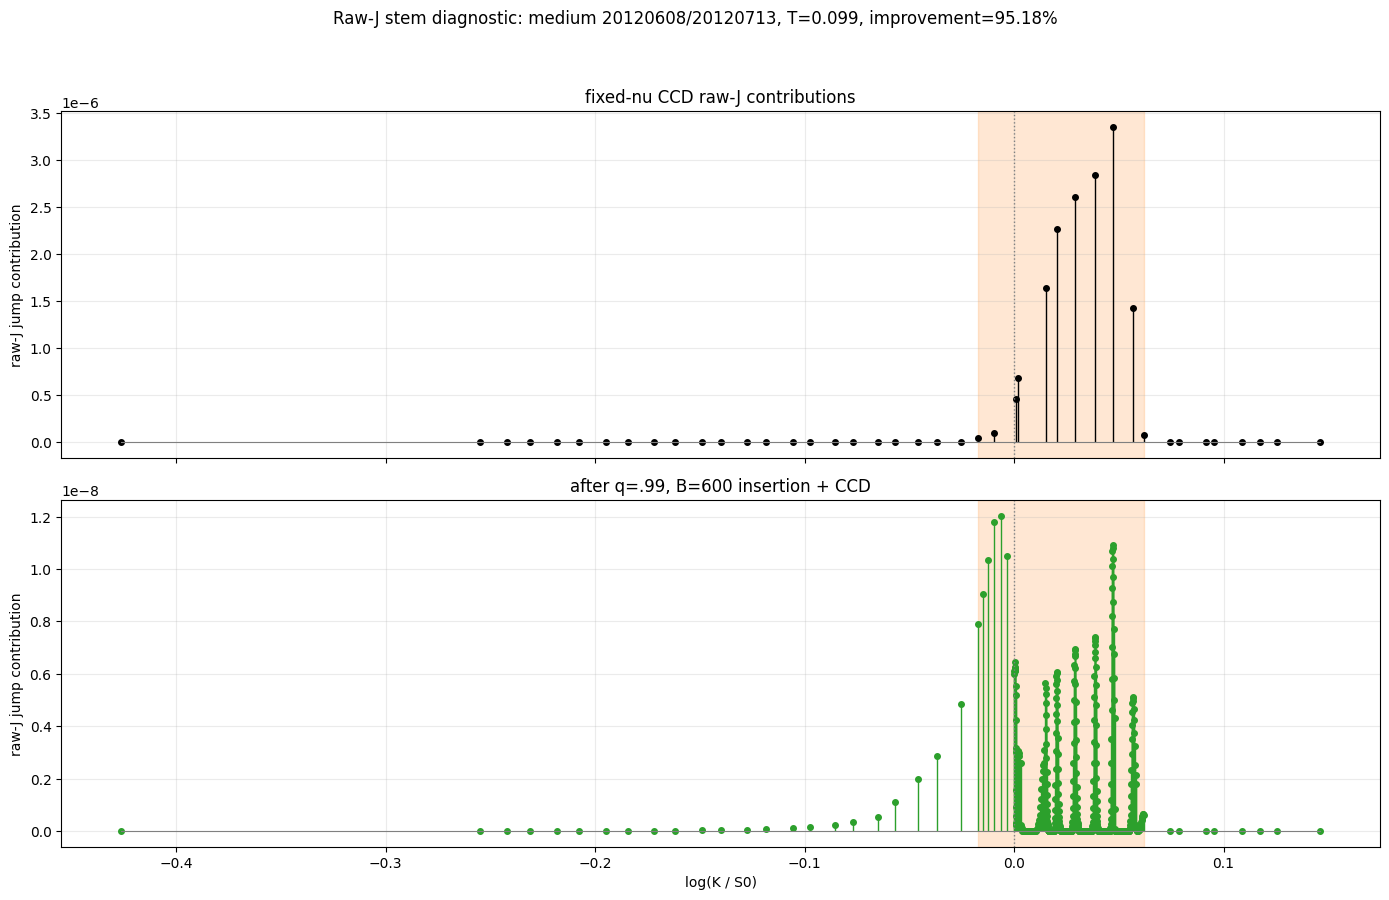

Saved plot to outputs/balanced_100_chain_mass_budget_validation/stem_region_demo_20120608_20120713.png


In [96]:

STEM_REGION_DEMO_RUN = True
STEM_REGION_DEMO_Q = 0.99
STEM_REGION_DEMO_BUDGET = 600
STEM_REGION_DEMO_CCD_ITERATIONS = 20000
STEM_REGION_DEMO_FALLBACK_DATE = 20120608
STEM_REGION_DEMO_FALLBACK_EXDATE = 20120713


def pick_high_improvement_stem_demo_chain():
    candidates = [
        Path("outputs/balanced_100_chain_mass_budget_validation/balanced_100_chain_results.csv"),
        Path("partner_lvg_private/outputs/balanced_100_chain_mass_budget_validation/balanced_100_chain_results.csv"),
    ]
    for path in candidates:
        if path.exists():
            df = pd.read_csv(path)
            mask = (
                (df["rule_name"] == "q99_B600_max")
                & (df["feasible"] == True)
                & np.isclose(df["q_level"], STEM_REGION_DEMO_Q)
                & (df["budget"] == STEM_REGION_DEMO_BUDGET)
            )
            if mask.any():
                row = df.loc[mask].sort_values("improvement_vs_fixed_pct", ascending=False).iloc[0]
                return int(row["date"]), int(row["exdate"])
    return STEM_REGION_DEMO_FALLBACK_DATE, STEM_REGION_DEMO_FALLBACK_EXDATE


def stem_demo_chain_info(date, exdate):
    T = chain_maturity_years(int(date), int(exdate))
    return {
        "date": int(date),
        "exdate": int(exdate),
        "T": float(T),
        "maturity_bucket": maturity_bucket(float(T)),
    }


def run_one_stem_region_demo(date=None, exdate=None):
    if date is None or exdate is None:
        date, exdate = pick_high_improvement_stem_demo_chain()
    info = stem_demo_chain_info(date, exdate)
    chain = build_adjusted_chain(raw_spx, int(date), int(exdate), MIN_STRIKES)
    R1, R2, init_theta = build_initial_theta_for_chain(chain)
    R1, R2 = int(R1), int(R2)
    init_theta = np.asarray(init_theta, dtype=float)
    S0 = float(chain["S0"])

    print(f"Selected chain: date={date}, exdate={exdate}, bucket={info['maturity_bucket']}, T={info['T']:.3f}")

    fixed_theta, _, fixed_accepted = coordinate_descent_sigma(
        R1, R2, S0, init_theta, chain["bid_ask"],
        proxy_kind="regular", update_order="cyclic",
        num_iterations=STEM_REGION_DEMO_CCD_ITERATIONS, record_every=None,
    )
    fixed_J = J_value(R1, R2, S0, fixed_theta)

    selected_intervals, selected_knots, total_jump = knot_neighborhood_intervals(
        R1, R2, S0, fixed_theta, STEM_REGION_DEMO_Q
    )
    regions = merge_selected_interval_regions(selected_intervals)
    allocations = mass_budget_allocations(selected_intervals, STEM_REGION_DEMO_BUDGET)
    inserted = insert_nus_from_interval_allocations(R1, R2, S0, fixed_theta, allocations)
    if inserted is None:
        raise RuntimeError("Nu insertion failed for selected stem demo chain")
    new_R1, new_R2, theta_inserted = inserted
    new_R1, new_R2 = int(new_R1), int(new_R2)

    final_theta, _, final_accepted = coordinate_descent_sigma(
        new_R1, new_R2, S0, theta_inserted, chain["bid_ask"],
        proxy_kind="regular", update_order="cyclic",
        num_iterations=STEM_REGION_DEMO_CCD_ITERATIONS, record_every=None,
    )
    final_J = J_value(new_R1, new_R2, S0, final_theta)
    improvement = 100.0 * (fixed_J - final_J) / fixed_J if fixed_J > 0 else np.nan

    fixed_jumps = jump_contributions_by_knot(R1, R2, S0, fixed_theta)
    final_jumps = jump_contributions_by_knot(new_R1, new_R2, S0, final_theta)

    print(f"fixed-nu CCD J      = {fixed_J:.16e}")
    print(f"after insertion J   = {final_J:.16e}")
    print(f"improvement         = {improvement:.6f}%")
    print(f"nus added           = {(new_R1 + new_R2) - (R1 + R2)}")
    print(f"selected knots      = {len(selected_knots)}")
    print(f"selected intervals  = {len(selected_intervals)}")
    print(f"merged regions      = {len(regions)}")

    print("Selected raw-J knots explaining q mass")
    display(selected_knots[["knot", "jump_squared", "wing"]].head(25))

    print("Merged target region(s) where nus were added")
    display(regions)

    alloc_df = pd.DataFrame(allocations, columns=["interval_index", "allocated_nus"])
    interval_alloc = selected_intervals.merge(alloc_df, on="interval_index", how="left").fillna({"allocated_nus": 0})
    print("Top allocated intervals")
    display(interval_alloc.sort_values("allocated_nus", ascending=False).head(25))

    return {
        "info": info,
        "chain": chain,
        "S0": S0,
        "fixed": {"R1": R1, "R2": R2, "theta": fixed_theta, "J": fixed_J, "jumps": fixed_jumps},
        "final": {"R1": new_R1, "R2": new_R2, "theta": final_theta, "J": final_J, "jumps": final_jumps},
        "regions": regions,
        "selected_intervals": selected_intervals,
        "selected_knots": selected_knots,
        "improvement": improvement,
    }


def plot_stem_region_demo(demo, use_log_moneyness=True):
    S0 = demo["S0"]
    regions = demo["regions"]
    info = demo["info"]
    fixed = demo["fixed"]
    final = demo["final"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
    plot_specs = [
        (axes[0], fixed["jumps"], "fixed-nu CCD raw-J contributions", "black"),
        (axes[1], final["jumps"], "after q=.99, B=600 insertion + CCD", "tab:green"),
    ]

    for ax, jumps, title, color in plot_specs:
        x_raw = jumps["knot"].to_numpy(dtype=float)
        x = np.log(x_raw / S0) if use_log_moneyness else x_raw
        y = jumps["jump_squared"].to_numpy(dtype=float)
        markerline, stemlines, baseline = ax.stem(x, y)
        plt.setp(markerline, marker="o", markersize=4, color=color)
        plt.setp(stemlines, color=color, linewidth=1.0)
        plt.setp(baseline, color="gray", linewidth=0.8)

        for _, region in regions.iterrows():
            left = float(region["left"])
            right = float(region["right"])
            x_left = np.log(left / S0) if use_log_moneyness else left
            x_right = np.log(right / S0) if use_log_moneyness else right
            ax.axvspan(x_left, x_right, color="tab:orange", alpha=0.18)
        ax.axvline(0.0 if use_log_moneyness else S0, color="gray", linestyle=":", linewidth=1.0)
        ax.set_title(title)
        ax.set_ylabel("raw-J jump contribution")
        ax.grid(alpha=0.25)

    x_label = "log(K / S0)" if use_log_moneyness else "K"
    axes[-1].set_xlabel(x_label)
    fig.suptitle(
        f"Raw-J stem diagnostic: {info['maturity_bucket']} {info['date']}/{info['exdate']}, "
        f"T={info['T']:.3f}, improvement={demo['improvement']:.2f}%",
        y=0.995,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    out_dir = balanced_validation_output_dir()
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"stem_region_demo_{info['date']}_{info['exdate']}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to {out_path}")


if STEM_REGION_DEMO_RUN:
    stem_region_demo = run_one_stem_region_demo()
    plot_stem_region_demo(stem_region_demo, use_log_moneyness=True)
else:
    print("Set STEM_REGION_DEMO_RUN = True to run this diagnostic.")


## Step 21B: same-scale raw-J stem comparison

The previous plot uses separate subplots, which can make the post-insertion improvement harder to judge. This cell reuses `stem_region_demo` and forces the before/after raw-J stems onto the same y-axis scale.


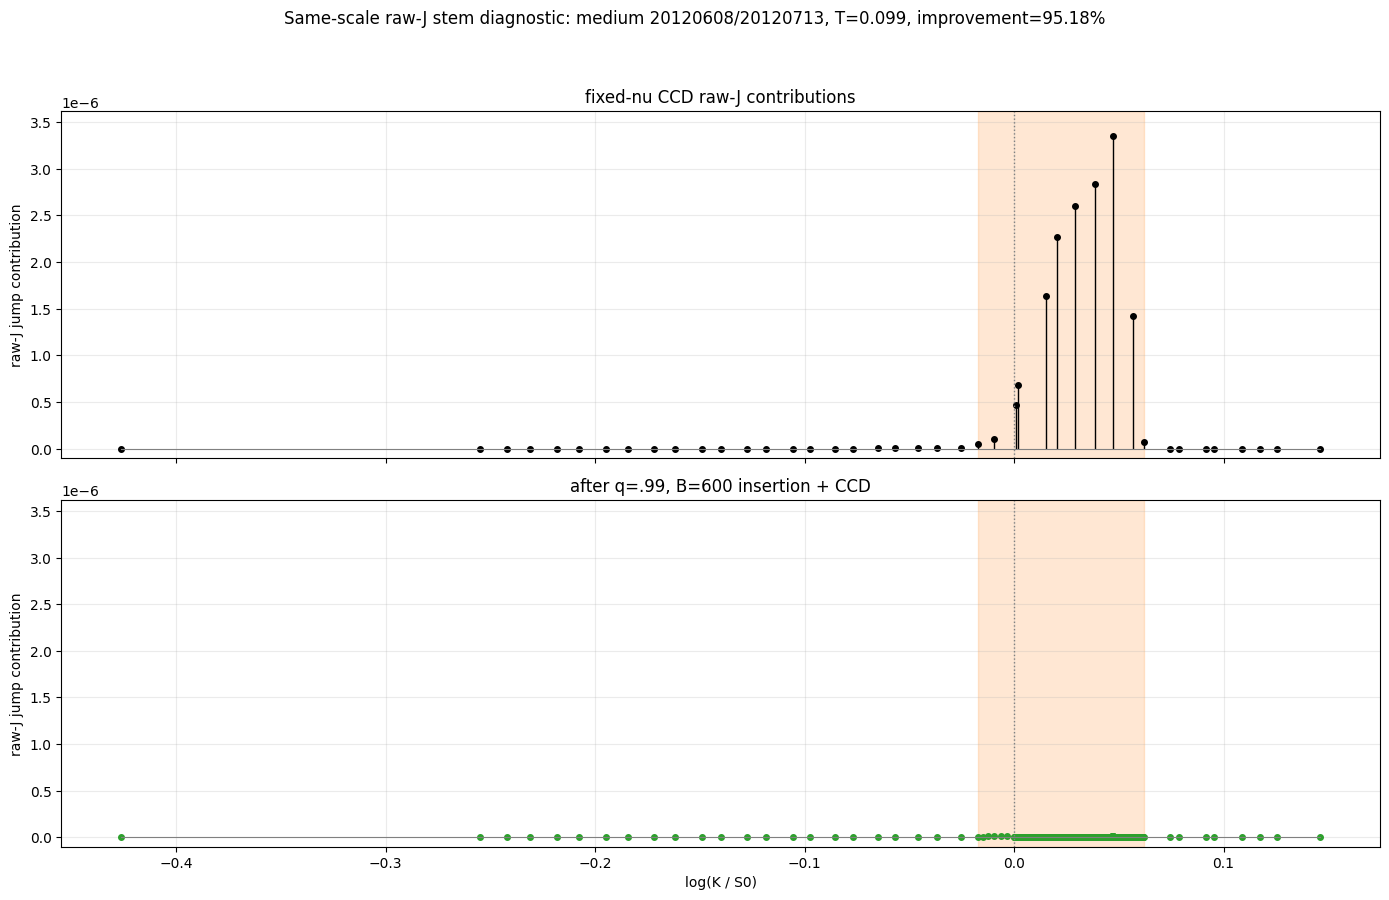

Saved plot to outputs/balanced_100_chain_mass_budget_validation/stem_region_demo_same_scale_20120608_20120713.png


In [97]:

def plot_stem_region_demo_same_scale(demo=None, use_log_moneyness=True):
    if demo is None:
        if "stem_region_demo" not in globals():
            raise RuntimeError("Run Step 21 first so stem_region_demo exists.")
        demo = stem_region_demo

    S0 = demo["S0"]
    regions = demo["regions"]
    info = demo["info"]
    fixed = demo["fixed"]
    final = demo["final"]

    fixed_y = fixed["jumps"]["jump_squared"].to_numpy(dtype=float)
    final_y = final["jumps"]["jump_squared"].to_numpy(dtype=float)
    ymax = np.nanmax([np.nanmax(fixed_y), np.nanmax(final_y)])
    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, sharey=True)
    plot_specs = [
        (axes[0], fixed["jumps"], "fixed-nu CCD raw-J contributions", "black"),
        (axes[1], final["jumps"], "after q=.99, B=600 insertion + CCD", "tab:green"),
    ]

    for ax, jumps, title, color in plot_specs:
        x_raw = jumps["knot"].to_numpy(dtype=float)
        x = np.log(x_raw / S0) if use_log_moneyness else x_raw
        y = jumps["jump_squared"].to_numpy(dtype=float)
        markerline, stemlines, baseline = ax.stem(x, y)
        plt.setp(markerline, marker="o", markersize=4, color=color)
        plt.setp(stemlines, color=color, linewidth=1.0)
        plt.setp(baseline, color="gray", linewidth=0.8)

        for _, region in regions.iterrows():
            left = float(region["left"])
            right = float(region["right"])
            x_left = np.log(left / S0) if use_log_moneyness else left
            x_right = np.log(right / S0) if use_log_moneyness else right
            ax.axvspan(x_left, x_right, color="tab:orange", alpha=0.18)
        ax.axvline(0.0 if use_log_moneyness else S0, color="gray", linestyle=":", linewidth=1.0)
        ax.set_ylim(-0.03 * ymax, 1.08 * ymax)
        ax.set_title(title)
        ax.set_ylabel("raw-J jump contribution")
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("log(K / S0)" if use_log_moneyness else "K")
    fig.suptitle(
        f"Same-scale raw-J stem diagnostic: {info['maturity_bucket']} {info['date']}/{info['exdate']}, "
        f"T={info['T']:.3f}, improvement={demo['improvement']:.2f}%",
        y=0.995,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    out_dir = balanced_validation_output_dir()
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"stem_region_demo_same_scale_{info['date']}_{info['exdate']}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to {out_path}")


plot_stem_region_demo_same_scale()


## Step 22: q=0.99 vs q=0.995 high-budget validation

This follow-up tests whether pushing beyond the current high-performing `q=0.99, B=600` rule is worth the extra dimensionality. It compares exactly six mass-budget settings:

- `q=0.99`, `B=600`, `800`, `1000`
- `q=0.995`, `B=600`, `800`, `1000`

The framework is the same as Step 20: canonical LVG construction, one fixed-nu `CCD_regular` baseline per chain, then all six candidates reuse that same fixed-nu CCD theta. Each candidate inserts all nus at once and then runs one final regular CCD pass.


In [99]:

HIGH_BUDGET_RUN = True  # Set True to launch this validation run.
HIGH_BUDGET_MODE = "full"  # "smoke" = 1 chain/bucket and 500 CCD iterations; "full" = 25 chains/bucket and 20k.
HIGH_BUDGET_RANDOM_SEED = 20260626
HIGH_BUDGET_PAGE_SIZE = 25
HIGH_BUDGET_PLOT_CHAIN_PAGES = True  # Set True in Step 22B to render all per-chain curve pages.

HIGH_BUDGET_RULES = [
    {"q_level": 0.99, "budget": 600, "rule_name": "q990_B600"},
    {"q_level": 0.99, "budget": 800, "rule_name": "q990_B800"},
    {"q_level": 0.99, "budget": 1000, "rule_name": "q990_B1000"},
    {"q_level": 0.995, "budget": 600, "rule_name": "q995_B600"},
    {"q_level": 0.995, "budget": 800, "rule_name": "q995_B800"},
    {"q_level": 0.995, "budget": 1000, "rule_name": "q995_B1000"},
]


def high_budget_settings():
    if HIGH_BUDGET_MODE == "smoke":
        return {"chains_per_bucket": 1, "ccd_iterations": 500, "grid_points": 400}
    if HIGH_BUDGET_MODE == "full":
        return {"chains_per_bucket": 25, "ccd_iterations": 20000, "grid_points": 800}
    raise ValueError("HIGH_BUDGET_MODE must be 'smoke' or 'full'")


def high_budget_output_dir():
    cwd = Path.cwd()
    if cwd.name == "partner_lvg_private":
        return Path("outputs/high_budget_mass_budget_validation")
    return Path("partner_lvg_private/outputs/high_budget_mass_budget_validation")


HIGH_BUDGET_OUTPUT_DIR = high_budget_output_dir()
HIGH_BUDGET_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HIGH_BUDGET_RESULTS_FILE = HIGH_BUDGET_OUTPUT_DIR / "high_budget_results.csv"
HIGH_BUDGET_PAYLOAD_FILE = HIGH_BUDGET_OUTPUT_DIR / "high_budget_curve_payload.pkl"
HIGH_BUDGET_SUMMARY_FILE = HIGH_BUDGET_OUTPUT_DIR / "high_budget_summary.csv"
HIGH_BUDGET_BEST_FILE = HIGH_BUDGET_OUTPUT_DIR / "high_budget_best_by_chain.csv"


def select_high_budget_chains(raw, chains_per_bucket, min_strikes=MIN_STRIKES, seed=HIGH_BUDGET_RANDOM_SEED):
    # Keep the same chain-selection logic as Step 20, with a separate seed constant for reproducibility.
    return select_balanced_validation_chains(raw, chains_per_bucket, min_strikes=min_strikes, seed=seed)


def high_budget_base_row(chain_info, chain, R1, R2, init_theta, fixed_theta, fixed_runtime, fixed_accepted):
    R1, R2 = int(R1), int(R2)
    S0 = float(chain["S0"])
    original_J = J_value(R1, R2, S0, init_theta)
    fixed_J = J_value(R1, R2, S0, fixed_theta)
    fixed_slack = quote_slack_report(R1, R2, S0, fixed_theta, chain["bid_ask"])
    return {
        "date": int(chain_info["date"]),
        "exdate": int(chain_info["exdate"]),
        "maturity_bucket": chain_info["maturity_bucket"],
        "T": float(chain_info["T"]),
        "S0": S0,
        "original_raw_J": float(original_J),
        "fixed_nu_ccd_raw_J": float(fixed_J),
        "fixed_runtime": float(fixed_runtime),
        "fixed_accepted_moves": int(fixed_accepted),
        "fixed_feasible": bool(fixed_slack["feasible"]),
        "fixed_min_bid_slack": float(fixed_slack["min_bid_slack"]),
        "fixed_min_ask_slack": float(fixed_slack["min_ask_slack"]),
        "fixed_R1": R1,
        "fixed_R2": R2,
    }


def run_high_budget_candidate(base_row, chain, fixed_R1, fixed_R2, fixed_theta, rule, ccd_iterations):
    fixed_R1, fixed_R2 = int(fixed_R1), int(fixed_R2)
    S0 = float(chain["S0"])
    q_level = float(rule["q_level"])
    budget = int(rule["budget"])
    rule_name = rule["rule_name"]

    start_insert = time.time()
    selected_intervals, selected_knots, _ = knot_neighborhood_intervals(fixed_R1, fixed_R2, S0, fixed_theta, q_level)
    regions = merge_selected_interval_regions(selected_intervals)
    allocations = mass_budget_allocations(selected_intervals, budget)
    inserted = insert_nus_from_interval_allocations(fixed_R1, fixed_R2, S0, fixed_theta, allocations)
    insertion_runtime = time.time() - start_insert

    row = dict(base_row)
    row.update({
        "rule_name": rule_name,
        "q_level": q_level,
        "budget": budget,
        "selected_knots": int(len(selected_knots)),
        "selected_intervals": int(len(selected_intervals)),
        "merged_regions": int(len(regions)),
        "insertion_runtime": float(insertion_runtime),
    })

    if inserted is None:
        row.update({
            "nus_added": 0,
            "final_raw_J": np.nan,
            "improvement_vs_fixed_pct": np.nan,
            "improvement_per_added_nu": np.nan,
            "final_runtime": np.nan,
            "total_runtime": np.nan,
            "accepted_moves": 0,
            "feasible": False,
            "min_bid_slack": np.nan,
            "min_ask_slack": np.nan,
            "final_R1": np.nan,
            "final_R2": np.nan,
            "status": "insertion_failed",
        })
        return row, None

    new_R1, new_R2, theta_inserted = inserted
    new_R1, new_R2 = int(new_R1), int(new_R2)
    theta_inserted = np.asarray(theta_inserted, dtype=float)

    start_final = time.time()
    theta_final, _, accepted_moves = coordinate_descent_sigma(
        new_R1, new_R2, S0, theta_inserted, chain["bid_ask"],
        proxy_kind="regular", update_order="cyclic",
        num_iterations=int(ccd_iterations), record_every=None,
    )
    final_runtime = time.time() - start_final

    final_J = J_value(new_R1, new_R2, S0, theta_final)
    fixed_J = float(base_row["fixed_nu_ccd_raw_J"])
    slack = quote_slack_report(new_R1, new_R2, S0, theta_final, chain["bid_ask"])
    nus_added = (new_R1 + new_R2) - (fixed_R1 + fixed_R2)

    row.update({
        "nus_added": int(nus_added),
        "final_raw_J": float(final_J),
        "improvement_vs_fixed_pct": float(100.0 * (fixed_J - final_J) / fixed_J) if fixed_J > 0 else np.nan,
        "improvement_per_added_nu": float(100.0 * (fixed_J - final_J) / fixed_J / nus_added) if fixed_J > 0 and nus_added > 0 else np.nan,
        "final_runtime": float(final_runtime),
        "total_runtime": float(base_row["fixed_runtime"] + insertion_runtime + final_runtime),
        "accepted_moves": int(accepted_moves),
        "feasible": bool(slack["feasible"]),
        "min_bid_slack": float(slack["min_bid_slack"]),
        "min_ask_slack": float(slack["min_ask_slack"]),
        "final_R1": int(new_R1),
        "final_R2": int(new_R2),
        "status": "ok",
    })
    return row, (new_R1, new_R2, theta_final)


def run_one_high_budget_chain(chain_info, ccd_iterations, grid_points):
    chain = build_adjusted_chain(raw_spx, int(chain_info["date"]), int(chain_info["exdate"]), MIN_STRIKES)
    R1, R2, init_theta = build_initial_theta_for_chain(chain)
    R1, R2 = int(R1), int(R2)
    init_theta = np.asarray(init_theta, dtype=float)
    S0 = float(chain["S0"])

    start_fixed = time.time()
    fixed_theta, _, fixed_accepted = coordinate_descent_sigma(
        R1, R2, S0, init_theta, chain["bid_ask"],
        proxy_kind="regular", update_order="cyclic",
        num_iterations=int(ccd_iterations), record_every=None,
    )
    fixed_runtime = time.time() - start_fixed

    base_row = high_budget_base_row(chain_info, chain, R1, R2, init_theta, fixed_theta, fixed_runtime, fixed_accepted)
    rows = []
    curves = {"fixed-nu CCD": (R1, R2, fixed_theta)}

    for rule in HIGH_BUDGET_RULES:
        row, final_curve = run_high_budget_candidate(base_row, chain, R1, R2, fixed_theta, rule, ccd_iterations)
        rows.append(row)
        if final_curve is not None:
            curves[rule["rule_name"]] = final_curve

    grid = np.linspace(float(np.min(chain["K"])), float(np.max(chain["K"])), int(grid_points))
    curve_values = {}
    for name, (curve_R1, curve_R2, curve_theta) in curves.items():
        curve_values[name] = {
            "R1": int(curve_R1),
            "R2": int(curve_R2),
            "sigma2": sigma2_curve_on_grid(curve_R1, curve_R2, S0, curve_theta, grid),
        }

    payload_row = {
        "date": base_row["date"],
        "exdate": base_row["exdate"],
        "maturity_bucket": base_row["maturity_bucket"],
        "T": base_row["T"],
        "S0": base_row["S0"],
        "fixed_nu_ccd_raw_J": base_row["fixed_nu_ccd_raw_J"],
    }
    return rows, {"row": payload_row, "grid": grid, "curves": curve_values}


def save_high_budget_payload(payload):
    import pickle
    with open(HIGH_BUDGET_PAYLOAD_FILE, "wb") as f:
        pickle.dump(payload, f)


def load_high_budget_payload():
    import pickle
    with open(HIGH_BUDGET_PAYLOAD_FILE, "rb") as f:
        return pickle.load(f)


def run_high_budget_validation():
    settings = high_budget_settings()
    selected = select_high_budget_chains(raw_spx, settings["chains_per_bucket"])
    print("Selected high-budget validation chains")
    display(selected.groupby("maturity_bucket").size().rename("chains"))
    display_cols = ["date", "exdate", "maturity_bucket", "T"]
    for optional_col in ["n_strikes", "num_strikes", "count", "n", "common_strikes"]:
        if optional_col in selected.columns:
            display_cols.append(optional_col)
            break
    display(selected[display_cols])

    rows = []
    payload = []
    total = len(selected)
    for pos, (_, chain_info) in enumerate(selected.iterrows(), start=1):
        print(f"[{pos}/{total}] date={int(chain_info['date'])}, exdate={int(chain_info['exdate'])}, bucket={chain_info['maturity_bucket']}")
        try:
            chain_rows, chain_payload = run_one_high_budget_chain(
                chain_info, settings["ccd_iterations"], settings["grid_points"]
            )
            rows.extend(chain_rows)
            payload.append(chain_payload)
        except Exception as exc:
            import traceback
            print(f"  failed: {exc}")
            traceback.print_exc(limit=3)
            rows.append({
                "date": int(chain_info["date"]),
                "exdate": int(chain_info["exdate"]),
                "maturity_bucket": chain_info["maturity_bucket"],
                "T": float(chain_info["T"]),
                "rule_name": "chain_failed",
                "status": f"failed: {exc}",
                "feasible": False,
            })
        pd.DataFrame(rows).to_csv(HIGH_BUDGET_RESULTS_FILE, index=False)
        save_high_budget_payload(payload)

    results = pd.DataFrame(rows)
    results.to_csv(HIGH_BUDGET_RESULTS_FILE, index=False)
    save_high_budget_payload(payload)
    print(f"Saved {len(results)} rows to {HIGH_BUDGET_RESULTS_FILE}")
    print(f"Saved {len(payload)} chain payloads to {HIGH_BUDGET_PAYLOAD_FILE}")
    return results, payload


if HIGH_BUDGET_RUN:
    high_budget_results, high_budget_payload = run_high_budget_validation()
else:
    print("Set HIGH_BUDGET_RUN = True to run Step 22.")
    print("Use HIGH_BUDGET_MODE = 'smoke' first, then 'full' for the 100-chain run.")


Selected high-budget validation chains


maturity_bucket
long         25
medium       25
short        25
very_long    25
Name: chains, dtype: int64

,date,exdate,maturity_bucket,T,common_strikes
0,20110131,20110618,long,0.396825,68
1,20110322,20110716,long,0.333333,37
2,20110429,20111217,long,0.658730,76
3,20110516,20110820,long,0.277778,80
4,20110517,20110820,long,0.273810,95
...,...,...,...,...,...
95,20120802,20130628,very_long,0.936508,44
96,20120912,20130628,very_long,0.821429,44
97,20121127,20131221,very_long,1.107143,53
98,20121213,20130921,very_long,0.801587,51


[1/100] date=20110131, exdate=20110618, bucket=long
[2/100] date=20110322, exdate=20110716, bucket=long
[3/100] date=20110429, exdate=20111217, bucket=long
[4/100] date=20110516, exdate=20110820, bucket=long
[5/100] date=20110517, exdate=20110820, bucket=long
[6/100] date=20110531, exdate=20111230, bucket=long
[7/100] date=20110608, exdate=20111217, bucket=long
[8/100] date=20110615, exdate=20111217, bucket=long
[9/100] date=20110811, exdate=20111230, bucket=long
[10/100] date=20110822, exdate=20111217, bucket=long
[11/100] date=20111007, exdate=20120121, bucket=long
[12/100] date=20111228, exdate=20120629, bucket=long
[13/100] date=20120213, exdate=20120629, bucket=long
[14/100] date=20120217, exdate=20120928, bucket=long
[15/100] date=20120306, exdate=20120922, bucket=long
[16/100] date=20120405, exdate=20120721, bucket=long
[17/100] date=20120521, exdate=20120922, bucket=long
[18/100] date=20120614, exdate=20120922, bucket=long
[19/100] date=20120629, exdate=20121231, bucket=long
[2

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


...

[73/100] date=20121107, exdate=20121130, bucket=short


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


[74/100] date=20121120, exdate=20121130, bucket=short
[75/100] date=20121206, exdate=20121228, bucket=short


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


[76/100] date=20110106, exdate=20111230, bucket=very_long
[77/100] date=20110124, exdate=20111217, bucket=very_long
[78/100] date=20110216, exdate=20111230, bucket=very_long
[79/100] date=20110315, exdate=20111217, bucket=very_long
[80/100] date=20110325, exdate=20120317, bucket=very_long
[81/100] date=20110328, exdate=20111217, bucket=very_long
[82/100] date=20110602, exdate=20120317, bucket=very_long
[83/100] date=20110621, exdate=20120317, bucket=very_long
[84/100] date=20110803, exdate=20120629, bucket=very_long
[85/100] date=20111005, exdate=20120928, bucket=very_long
[86/100] date=20111017, exdate=20120928, bucket=very_long
[87/100] date=20111026, exdate=20120922, bucket=very_long
[88/100] date=20111115, exdate=20120928, bucket=very_long
[89/100] date=20111206, exdate=20121222, bucket=very_long
[90/100] date=20111223, exdate=20120922, bucket=very_long
[91/100] date=20120113, exdate=20121231, bucket=very_long
[92/100] date=20120419, exdate=20130328, bucket=very_long
[93/100] date=

## Step 22B: summarize the high-budget validation

This section reads the Step 22 outputs and compares the six high-threshold/high-budget settings by mean, median, feasibility, runtime, and improvement per added nu.


High-budget mean/median summary


,q_level,budget,rule_name,feasible_rows,mean_improvement,median_improvement,min_improvement,max_improvement,mean_improvement_per_nu,median_improvement_per_nu,mean_runtime,median_runtime,mean_added_nus,median_added_nus,attempted_rows,feasibility_rate
2,0.990,1000,q990_B1000,100,53.025785,91.017910,-0.000528,94.547180,0.053026,0.091018,56.981735,53.262439,1000.0,1000.0,100,1.00
1,0.990,800,q990_B800,97,53.509720,91.013857,-0.000550,94.763076,0.066887,0.113767,57.004889,54.163475,800.0,800.0,100,0.97
4,0.995,800,q995_B800,99,53.083942,90.989595,-0.000182,94.797942,0.066355,0.113737,57.740586,55.608993,800.0,800.0,100,0.99
5,0.995,1000,q995_B1000,99,54.115685,90.789987,-0.000208,94.452435,0.054116,0.090790,57.515928,54.922453,1000.0,1000.0,100,0.99
3,0.995,600,q995_B600,98,51.356632,87.734897,-0.000120,95.098352,0.085594,0.146225,57.629179,55.207826,600.0,600.0,100,0.98
0,0.990,600,q990_B600,99,50.313906,87.007109,-0.000426,95.177764,0.083857,0.145012,57.209325,54.150356,600.0,600.0,100,0.99


High-budget summary by maturity bucket


,maturity_bucket,q_level,budget,rule_name,rows,mean_improvement,median_improvement,mean_runtime,median_runtime
0,long,0.990,600,q990_B600,25,34.954517,2.171320e-02,49.374816,46.125461
1,long,0.990,800,q990_B800,25,35.811030,2.129277e-02,47.605422,44.444773
2,long,0.990,1000,q990_B1000,25,36.226900,2.925075e-02,48.132389,46.101072
3,long,0.995,600,q995_B600,25,32.318378,3.688760e-02,50.163655,46.420501
4,long,0.995,800,q995_B800,25,33.398086,3.710975e-02,48.956892,48.905578
5,long,0.995,1000,q995_B1000,25,34.048244,3.985176e-02,49.299618,48.366099
6,medium,0.990,600,q990_B600,25,81.842200,9.141837e+01,61.836653,56.738618
7,medium,0.990,800,q990_B800,25,83.080233,9.230846e+01,63.529381,60.448083
8,medium,0.990,1000,q990_B1000,25,85.847233,9.278989e+01,65.277846,63.241902
9,medium,0.995,600,q995_B600,25,82.811246,9.138302e+01,62.253980,56.737975


Win counts by rule


,rule_name,chains_won
0,q995_B1000,33
1,q995_B600,18
2,q995_B800,18
3,q990_B1000,16
4,q990_B600,8
5,q990_B800,7


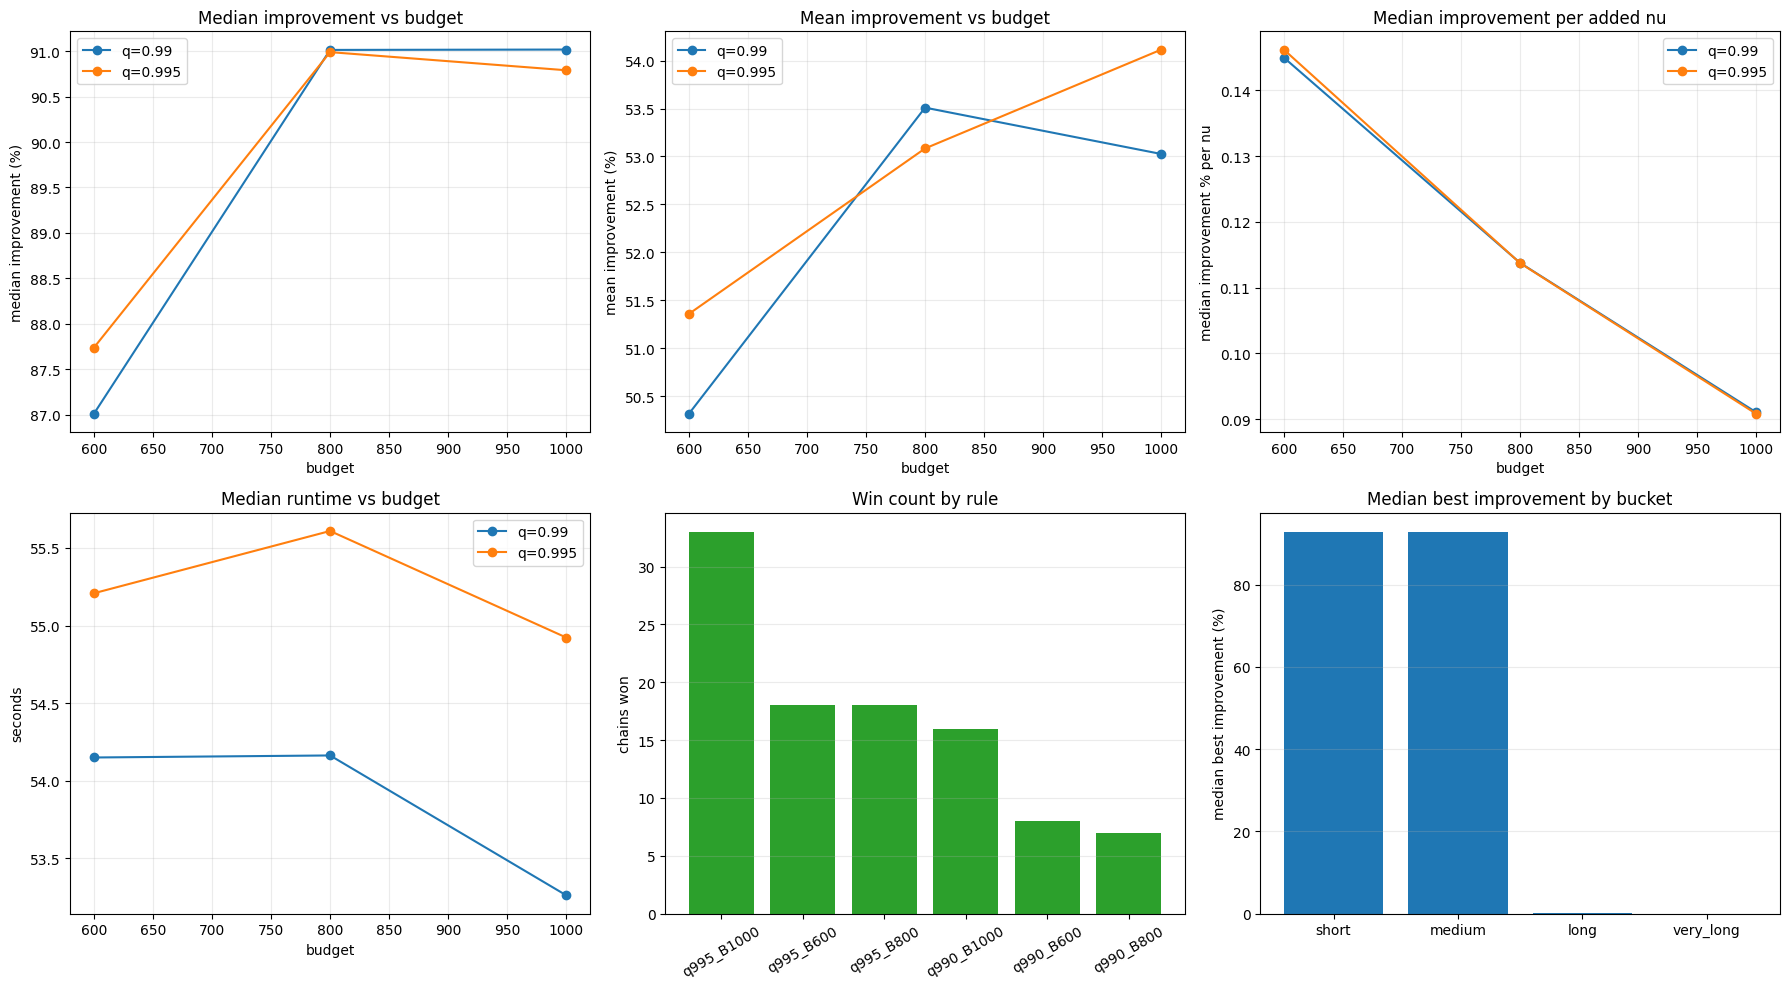

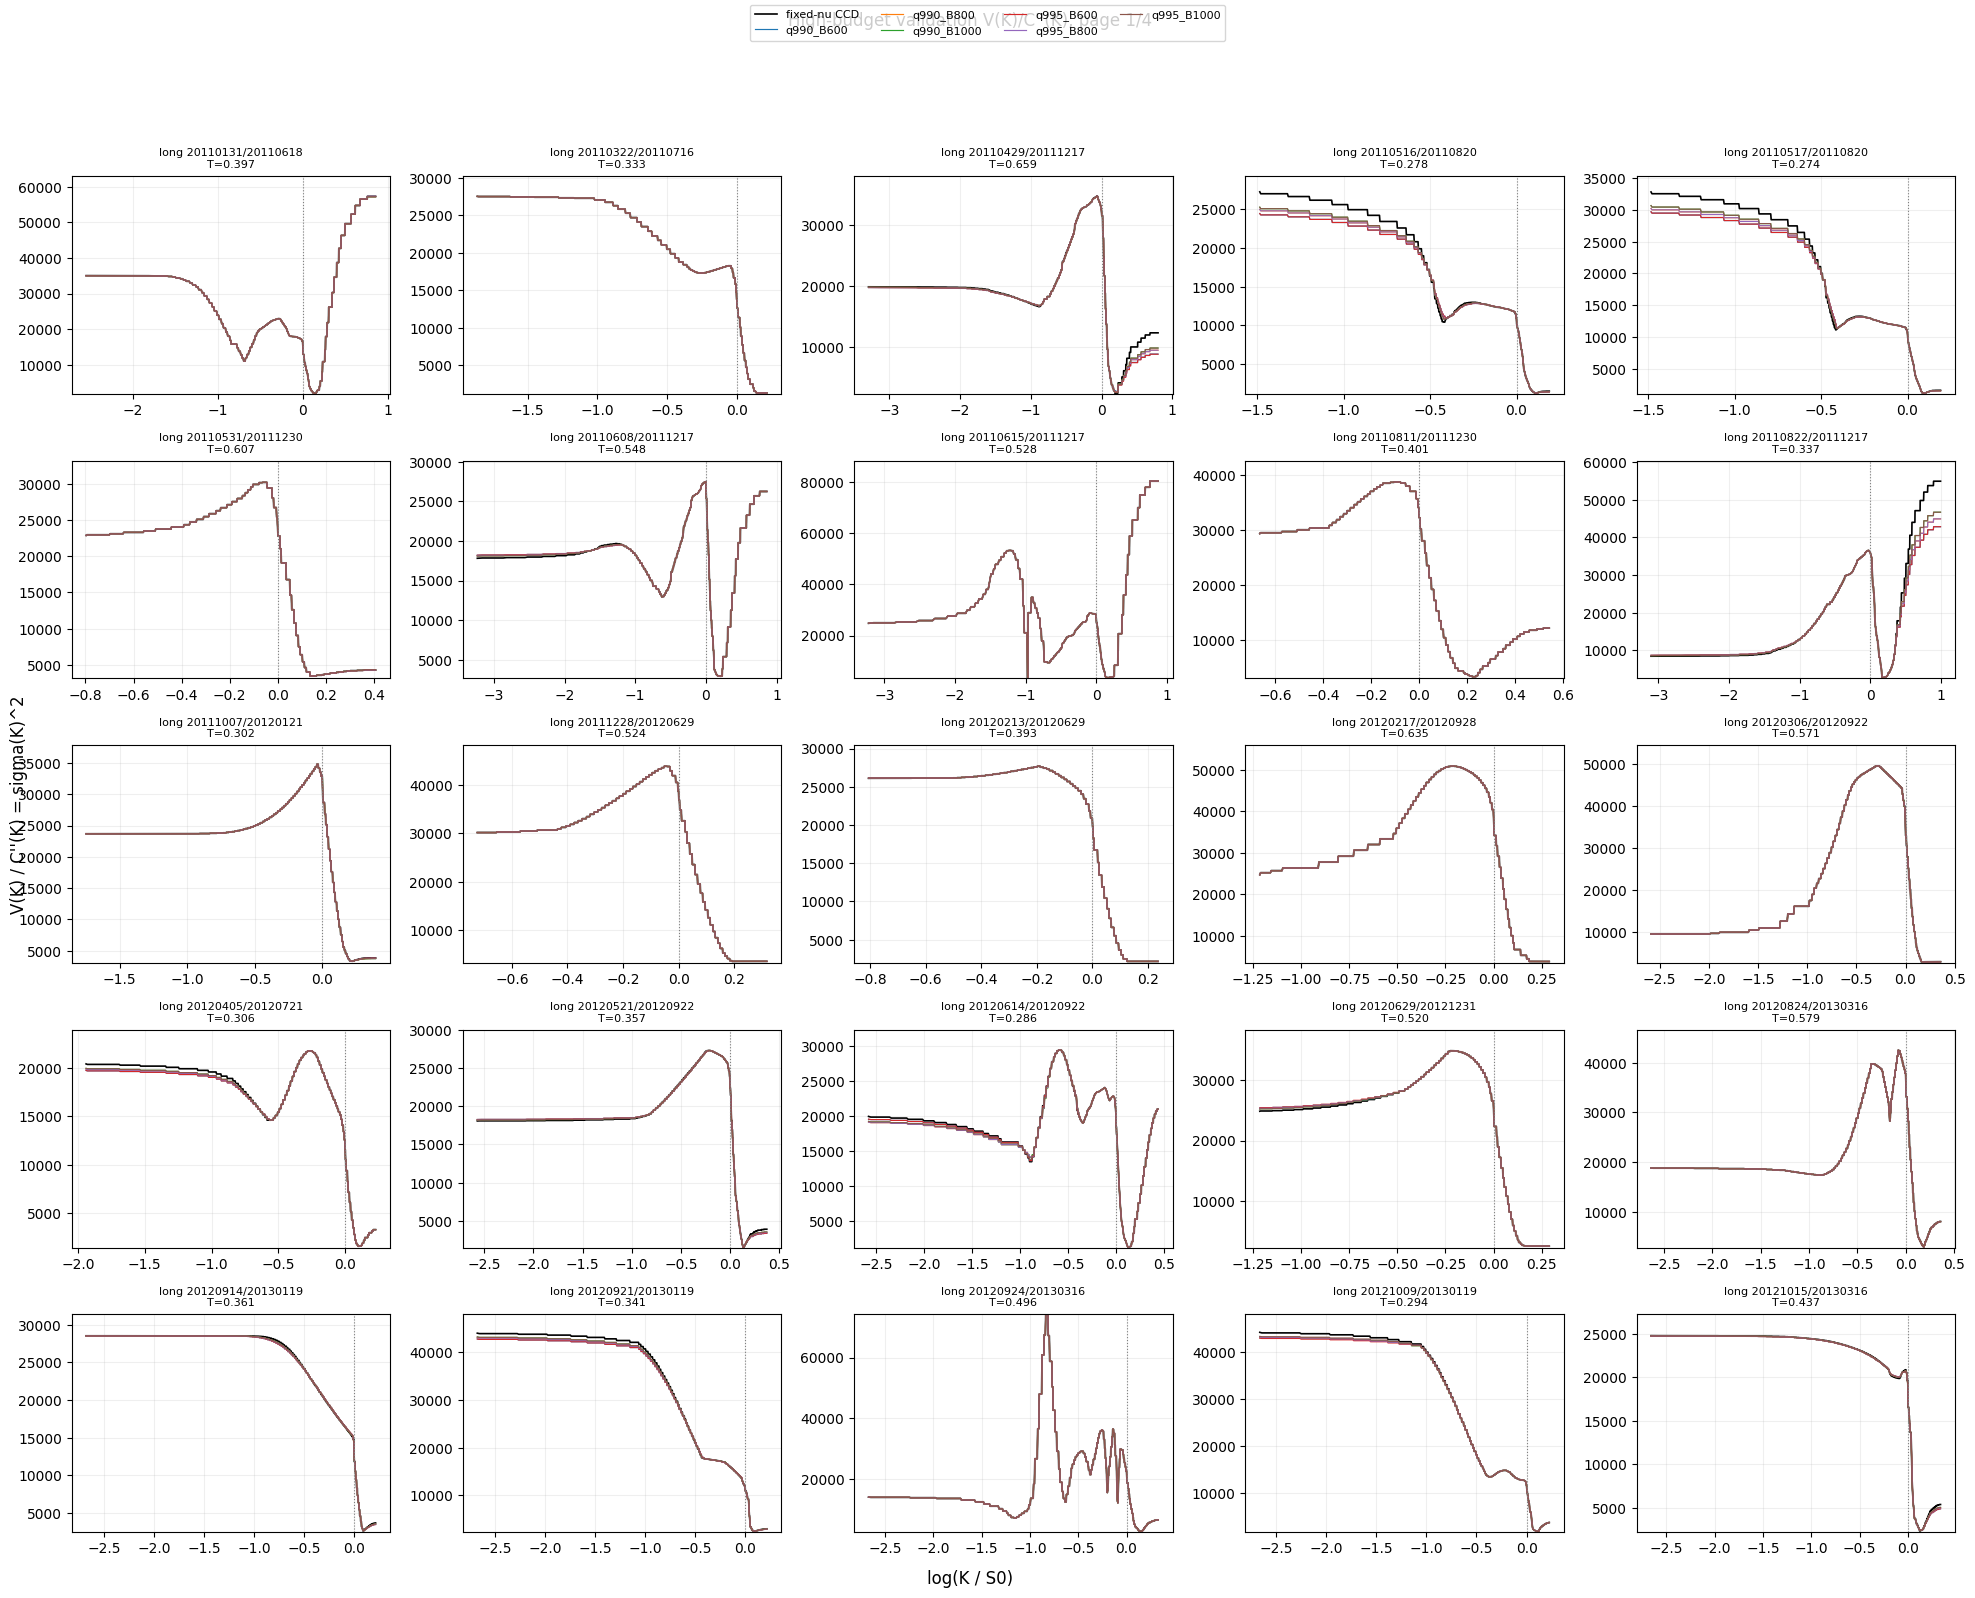

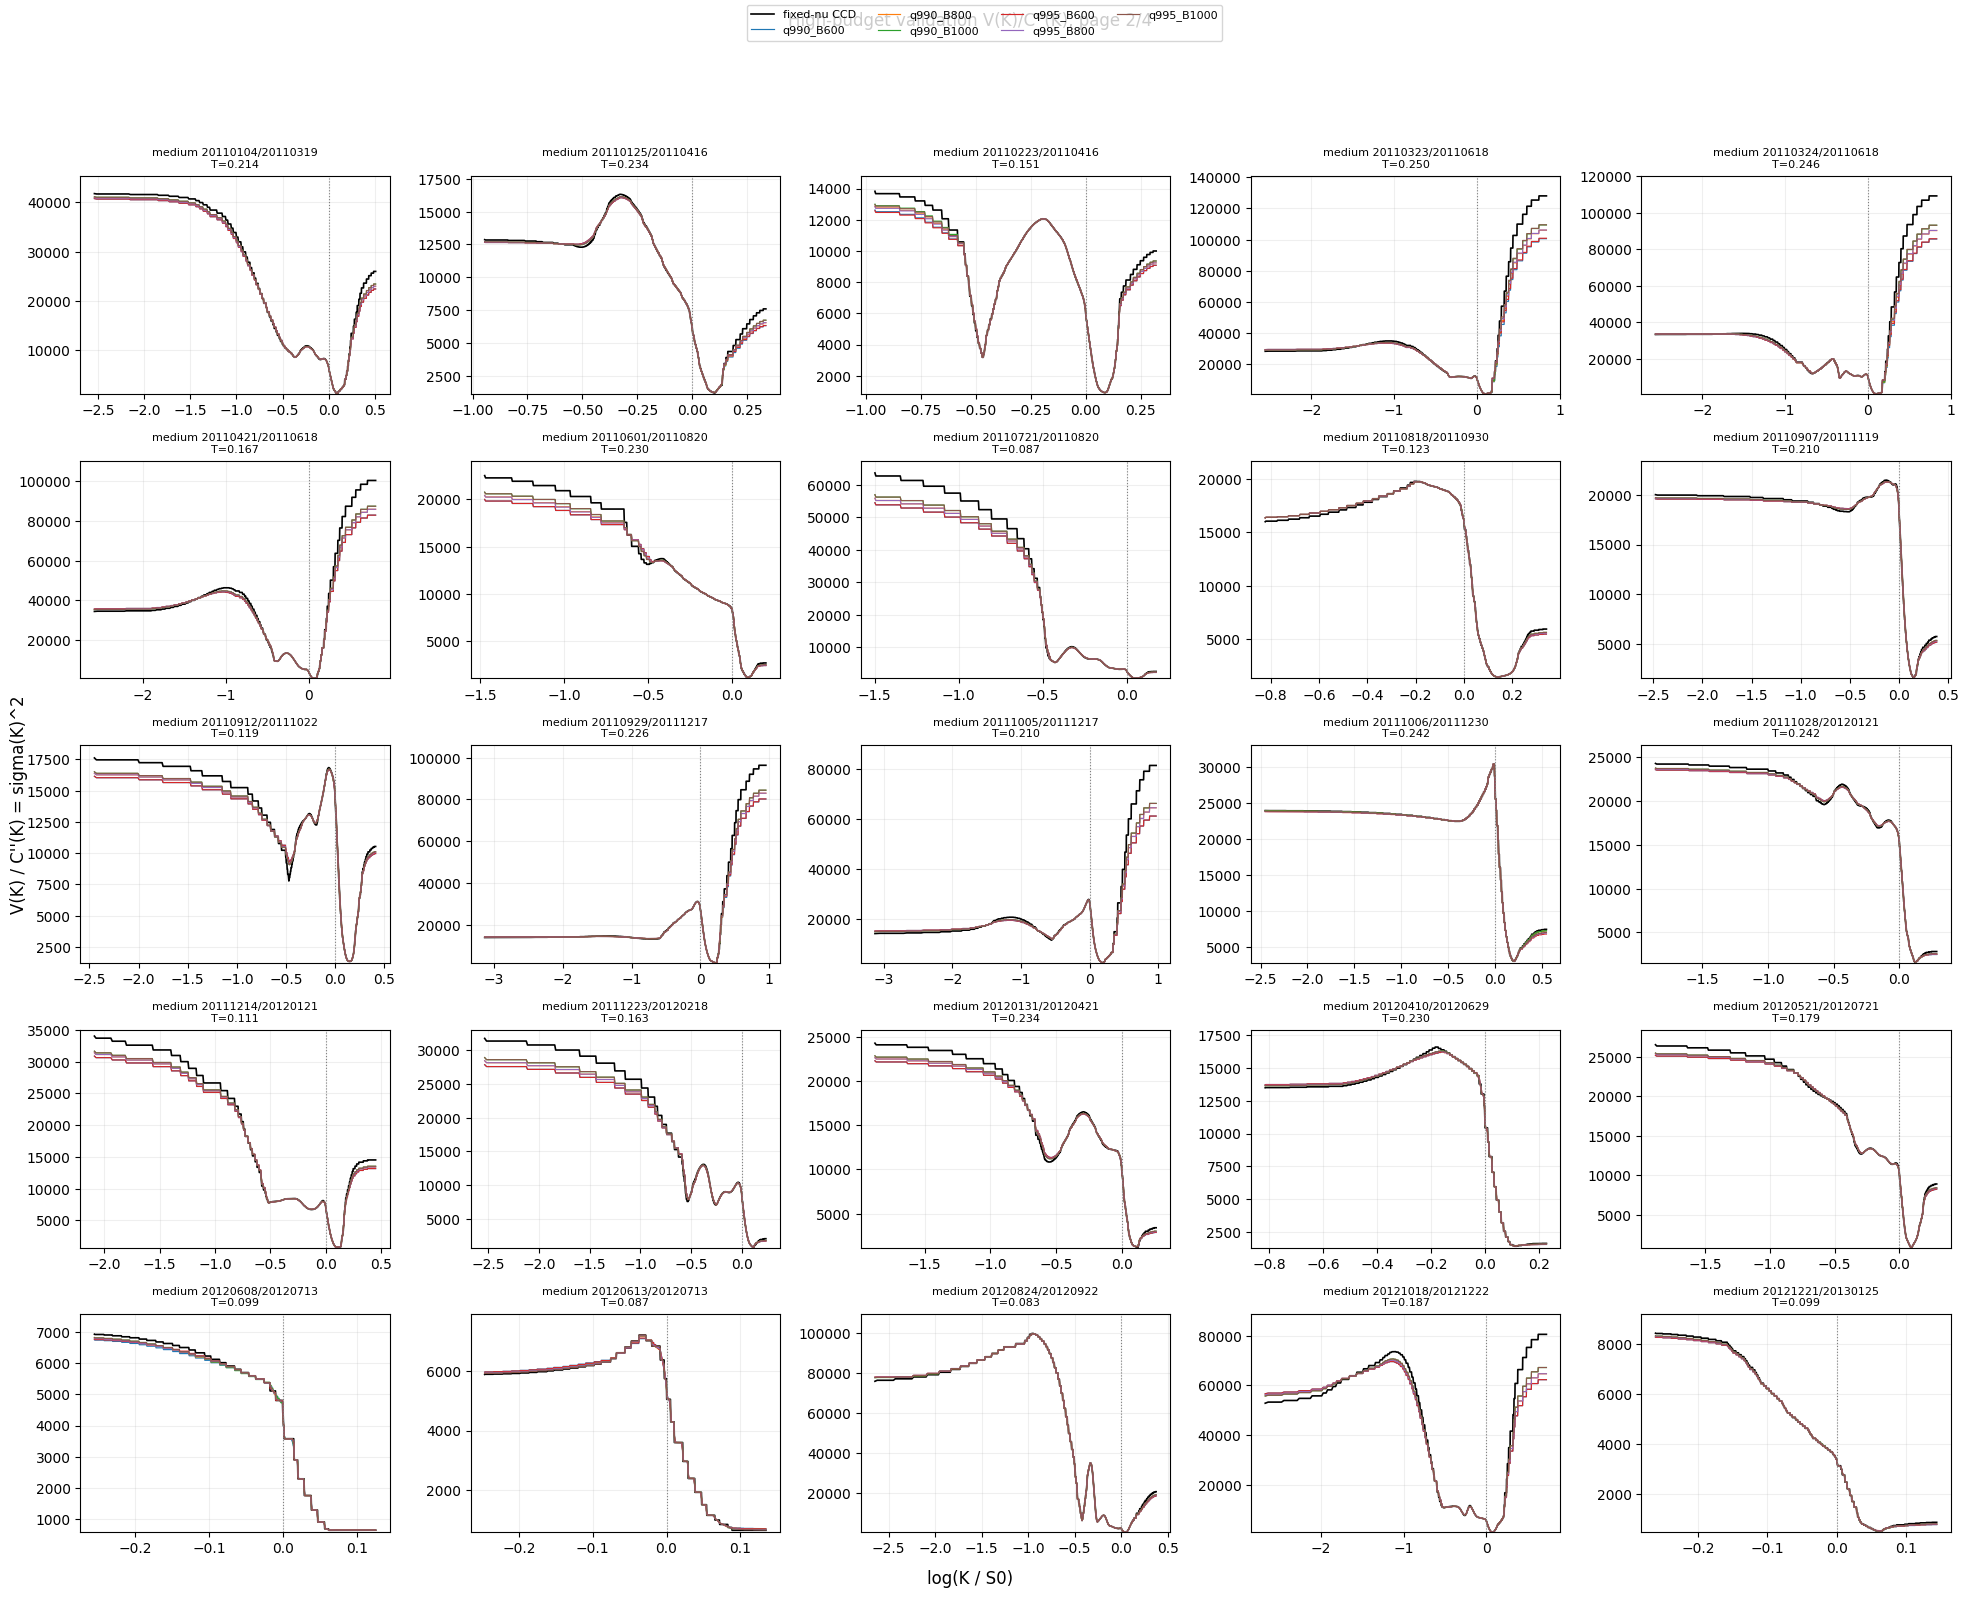

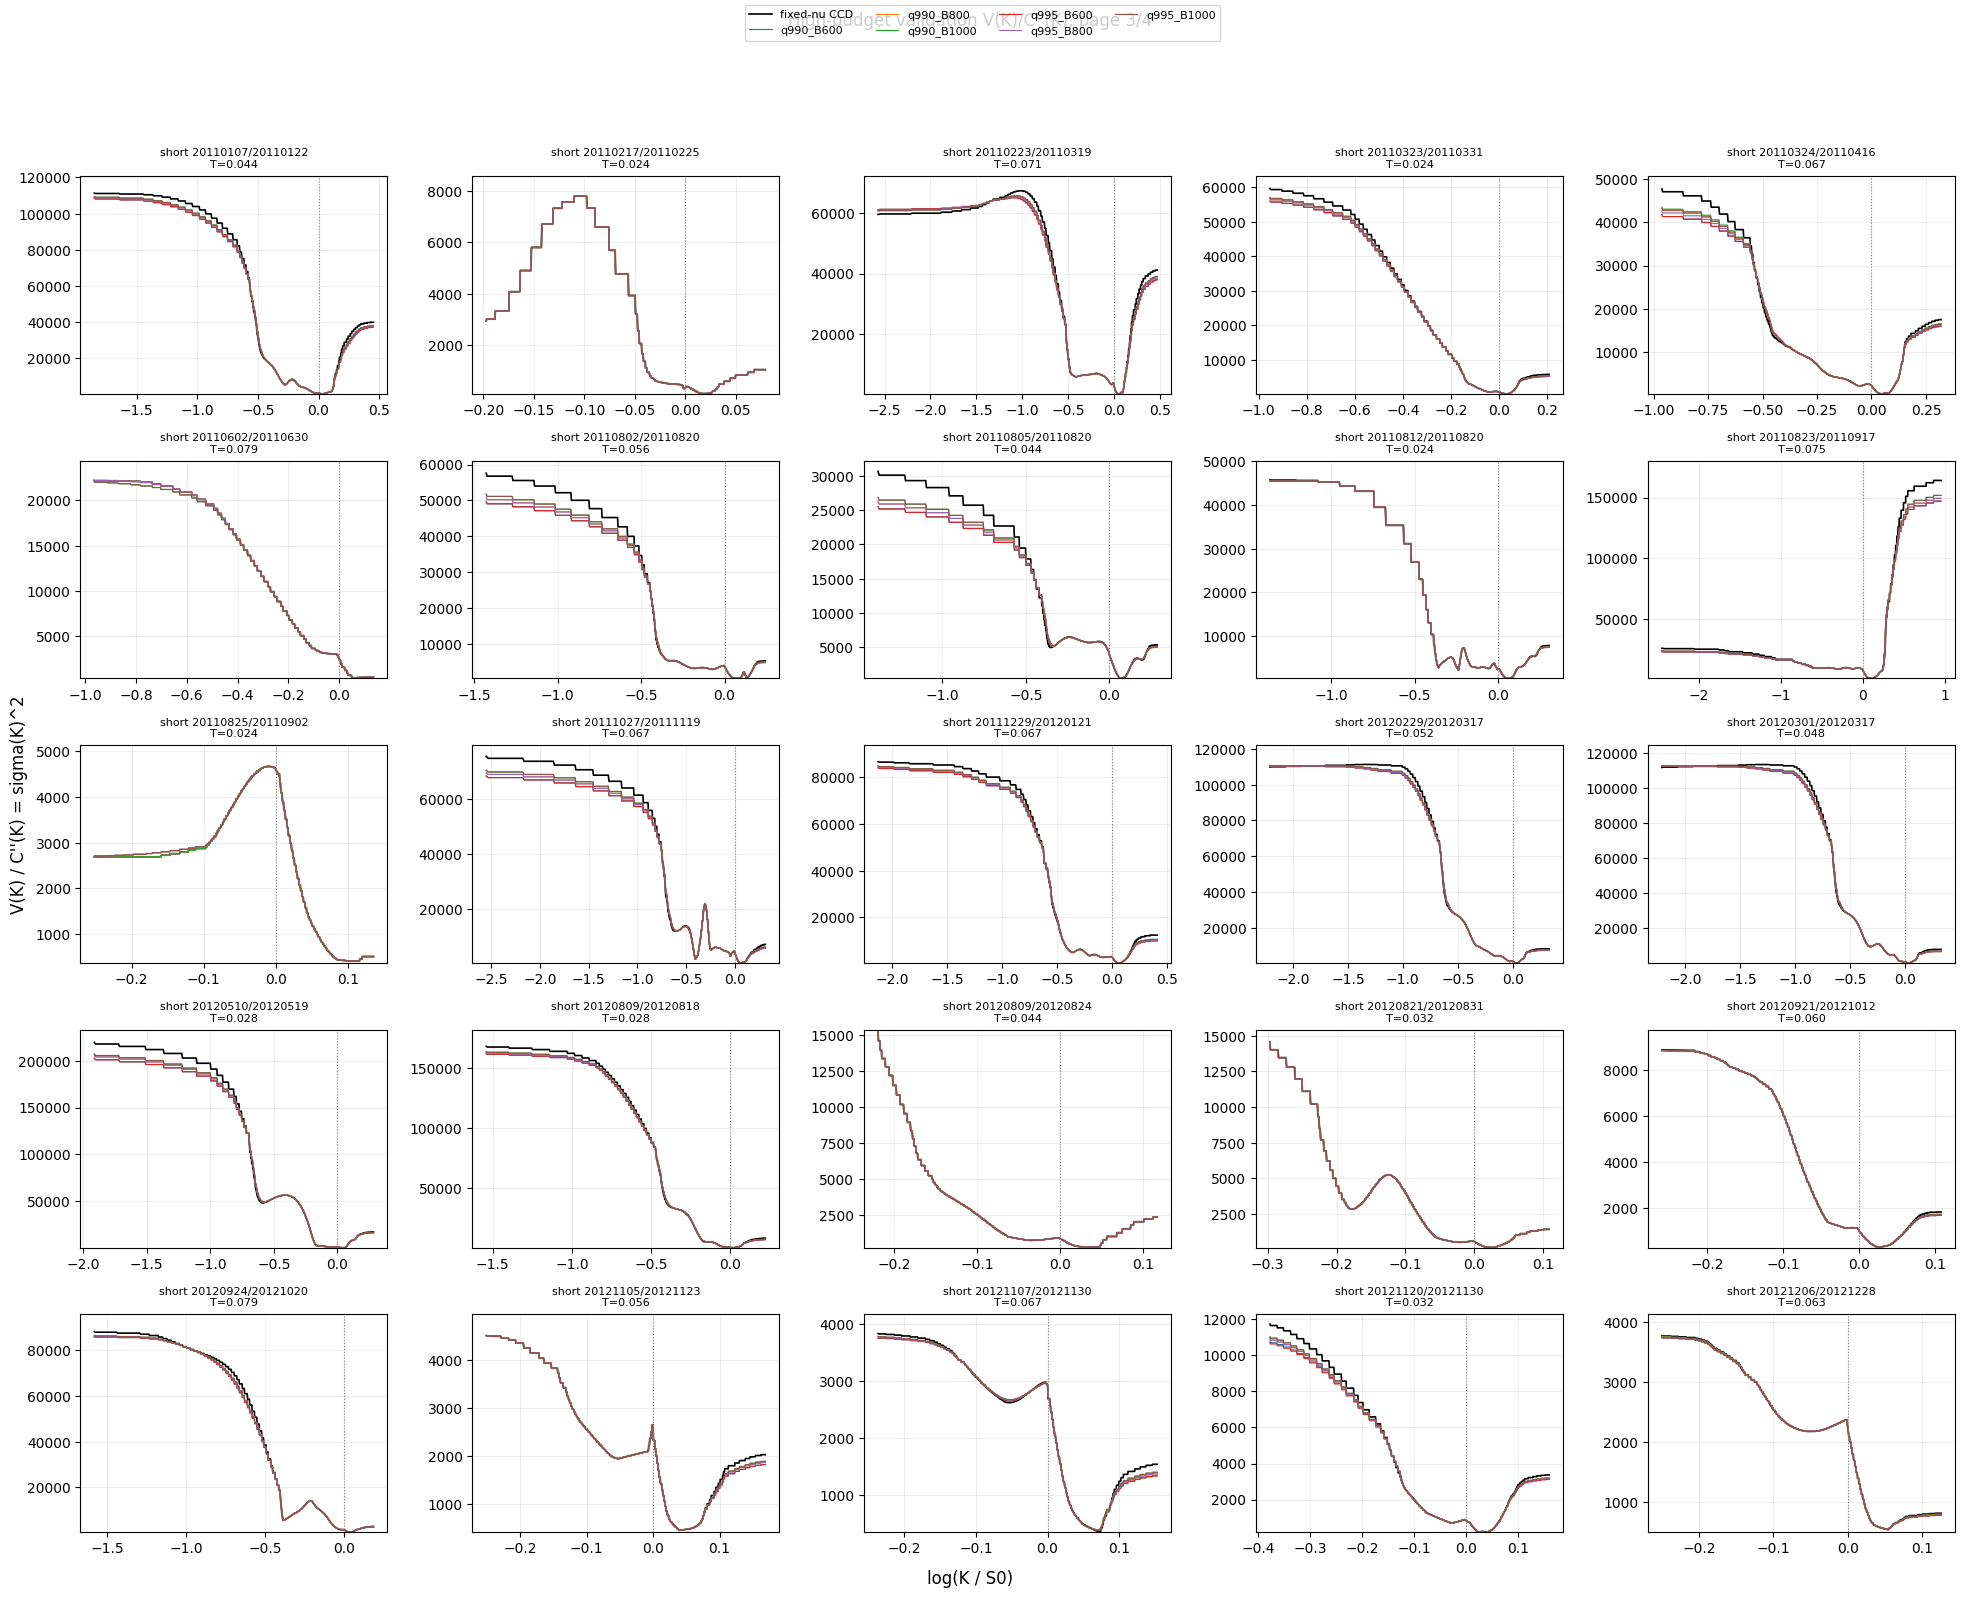

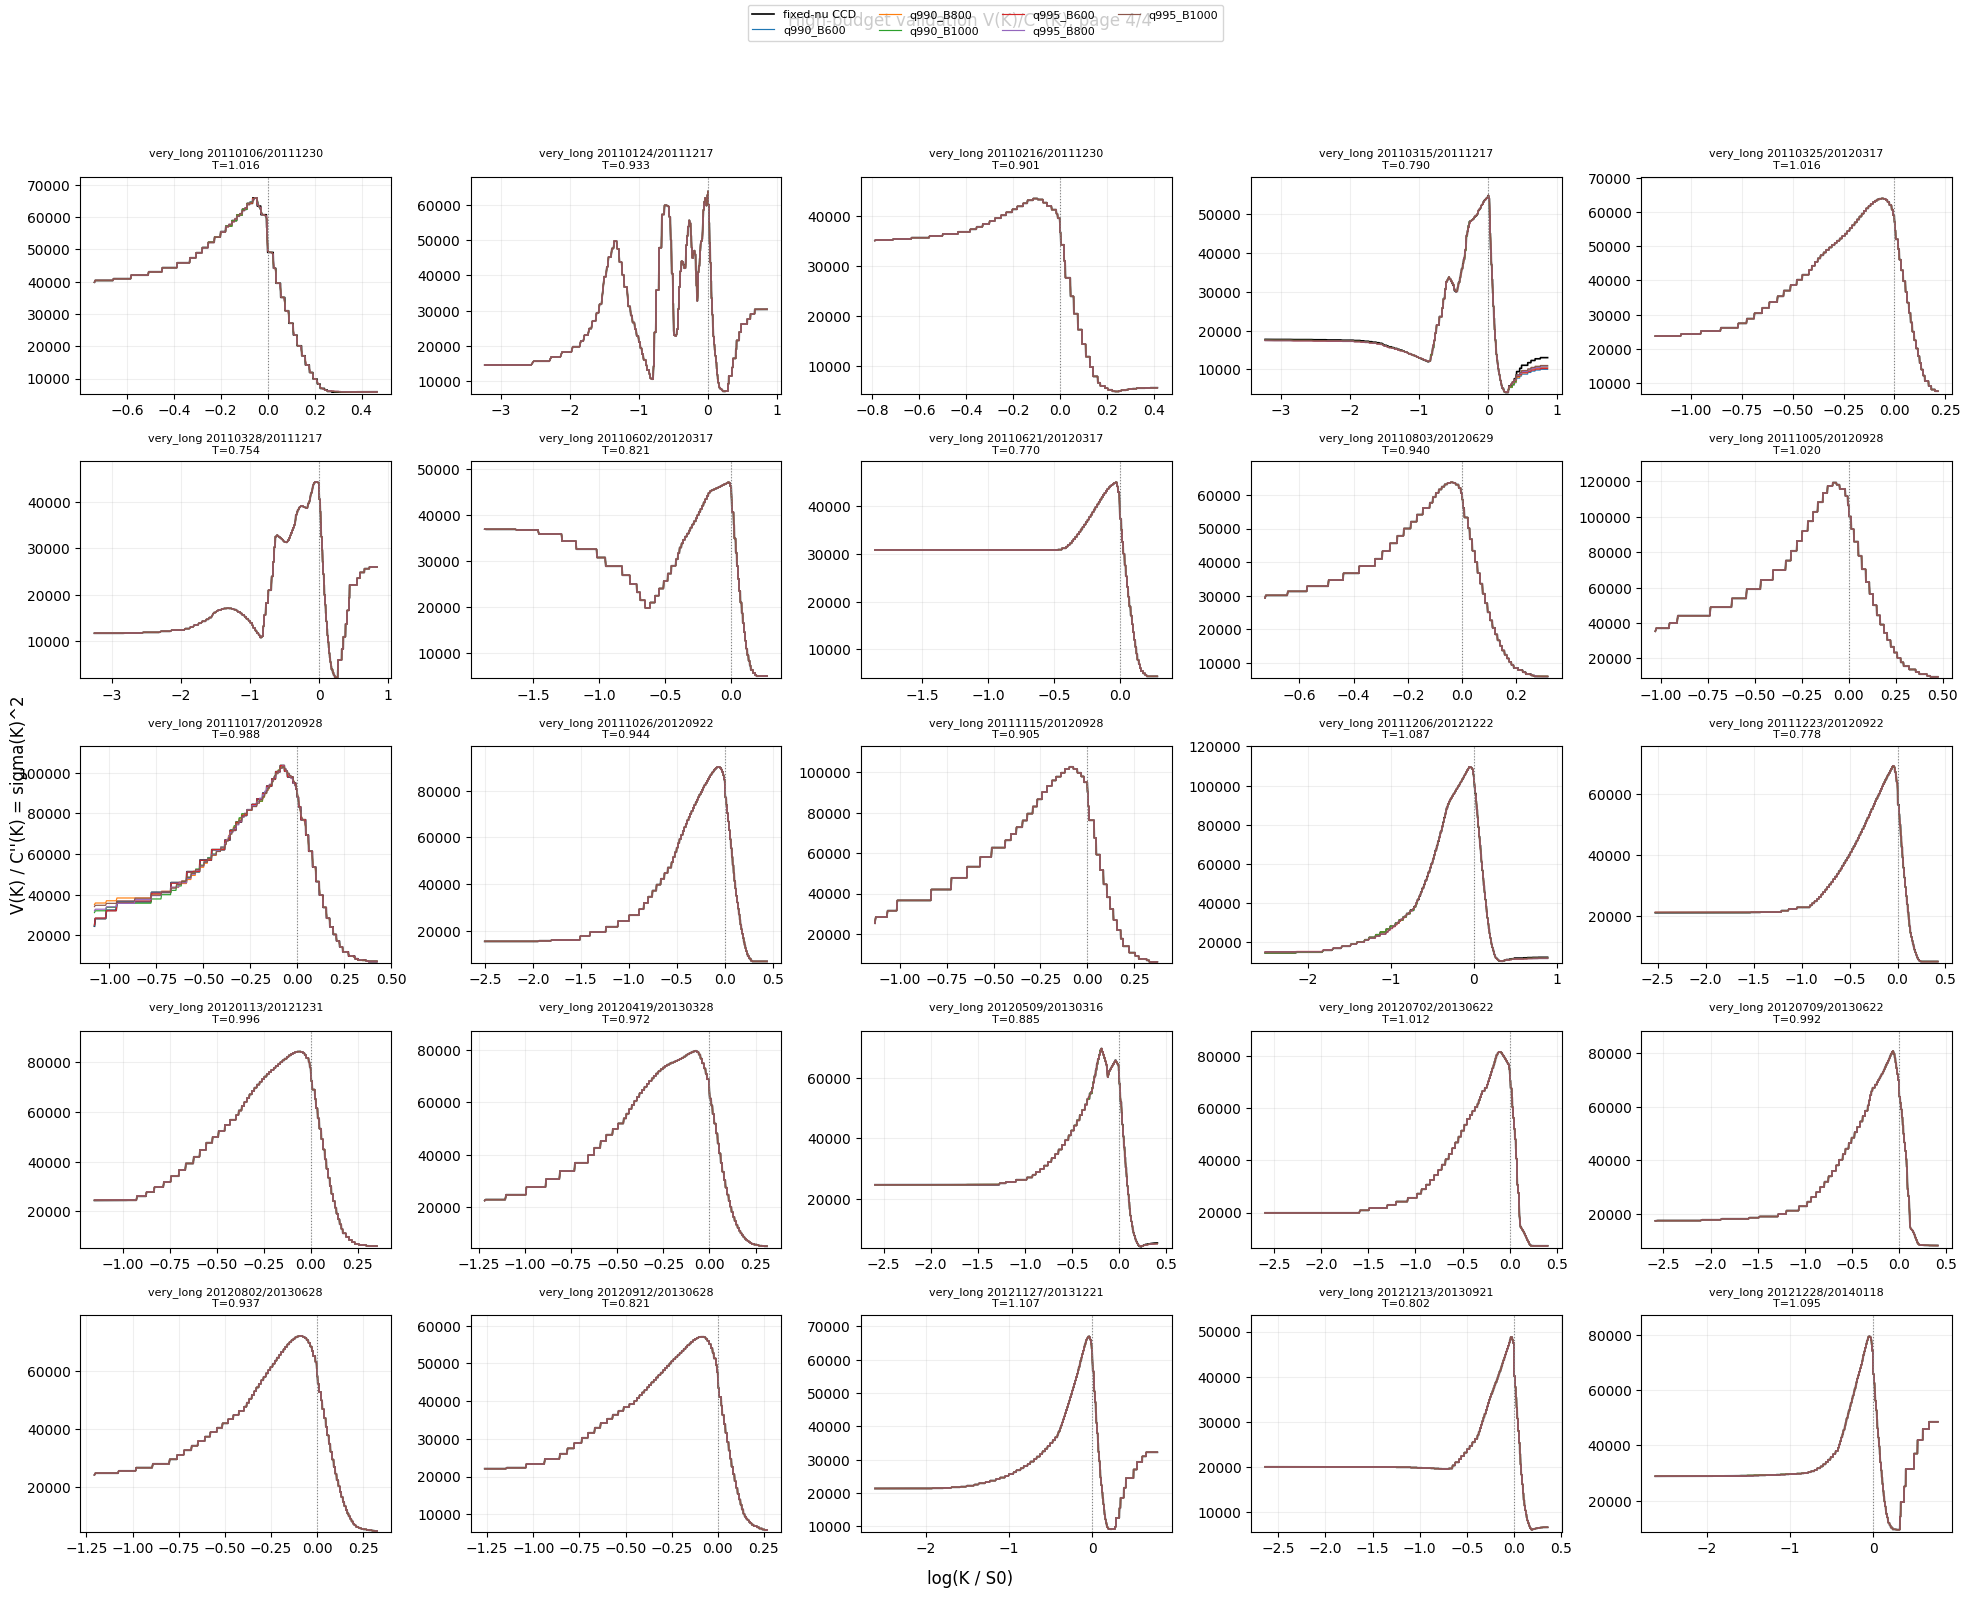

In [100]:

def load_high_budget_results():
    if "high_budget_results" in globals() and isinstance(high_budget_results, pd.DataFrame):
        return high_budget_results.copy()
    candidates = [
        Path("outputs/high_budget_mass_budget_validation/high_budget_results.csv"),
        Path("partner_lvg_private/outputs/high_budget_mass_budget_validation/high_budget_results.csv"),
    ]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError("Could not find high_budget_results.csv. Run Step 22 first.")


def load_high_budget_curve_payload():
    import pickle
    candidates = [
        Path("outputs/high_budget_mass_budget_validation/high_budget_curve_payload.pkl"),
        Path("partner_lvg_private/outputs/high_budget_mass_budget_validation/high_budget_curve_payload.pkl"),
    ]
    for path in candidates:
        if path.exists():
            with open(path, "rb") as f:
                return pickle.load(f)
    return []


def summarize_high_budget_results(results):
    if results.empty:
        print("No Step 22 rows to summarize.")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    status_ok = results["status"].fillna("ok").eq("ok") if "status" in results.columns else pd.Series(True, index=results.index)
    ok = results[status_ok].copy()
    if ok.empty:
        print("No successful Step 22 candidate rows to summarize.")
        display(results[[c for c in ["date", "exdate", "rule_name", "status"] if c in results.columns]].head(20))
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    ok["feasible"] = ok["feasible"].astype(bool)
    feasible = ok[ok["feasible"]].copy()
    if feasible.empty:
        print("No feasible Step 22 rows to summarize. Showing attempted rows instead.")
        display(ok[["date", "exdate", "rule_name", "q_level", "budget", "final_raw_J", "feasible", "status"]].head(20))
        return feasible, pd.DataFrame(), pd.DataFrame()

    performance = (
        feasible.groupby(["q_level", "budget", "rule_name"])
        .agg(
            feasible_rows=("improvement_vs_fixed_pct", "count"),
            mean_improvement=("improvement_vs_fixed_pct", "mean"),
            median_improvement=("improvement_vs_fixed_pct", "median"),
            min_improvement=("improvement_vs_fixed_pct", "min"),
            max_improvement=("improvement_vs_fixed_pct", "max"),
            mean_improvement_per_nu=("improvement_per_added_nu", "mean"),
            median_improvement_per_nu=("improvement_per_added_nu", "median"),
            mean_runtime=("total_runtime", "mean"),
            median_runtime=("total_runtime", "median"),
            mean_added_nus=("nus_added", "mean"),
            median_added_nus=("nus_added", "median"),
        )
        .reset_index()
    )
    feasibility = (
        ok.groupby(["q_level", "budget", "rule_name"])
        .agg(attempted_rows=("feasible", "count"), feasibility_rate=("feasible", "mean"))
        .reset_index()
    )
    summary = (
        performance.merge(feasibility, on=["q_level", "budget", "rule_name"], how="left")
        .sort_values(["median_improvement", "mean_improvement"], ascending=False)
    )

    bucket_summary = (
        feasible.groupby(["maturity_bucket", "q_level", "budget", "rule_name"])
        .agg(
            rows=("improvement_vs_fixed_pct", "count"),
            mean_improvement=("improvement_vs_fixed_pct", "mean"),
            median_improvement=("improvement_vs_fixed_pct", "median"),
            mean_runtime=("total_runtime", "mean"),
            median_runtime=("total_runtime", "median"),
        )
        .reset_index()
    )

    best_idx = feasible.groupby(["date", "exdate"])["improvement_vs_fixed_pct"].idxmax()
    best_by_chain = feasible.loc[best_idx].sort_values("improvement_vs_fixed_pct", ascending=False).copy()

    summary.to_csv(HIGH_BUDGET_SUMMARY_FILE, index=False)
    best_by_chain.to_csv(HIGH_BUDGET_BEST_FILE, index=False)

    print("High-budget mean/median summary")
    display(summary)
    print("High-budget summary by maturity bucket")
    display(bucket_summary)
    print("Win counts by rule")
    display(best_by_chain["rule_name"].value_counts().rename_axis("rule_name").reset_index(name="chains_won"))
    return feasible, summary, best_by_chain


def plot_high_budget_summary(feasible, best_by_chain):
    if feasible.empty:
        print("No feasible Step 22 rows to plot.")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for q_level, group in feasible.groupby("q_level"):
        med = group.groupby("budget")["improvement_vs_fixed_pct"].median().reset_index()
        axes[0, 0].plot(med["budget"], med["improvement_vs_fixed_pct"], marker="o", label=f"q={q_level}")
    axes[0, 0].set_title("Median improvement vs budget")
    axes[0, 0].set_xlabel("budget")
    axes[0, 0].set_ylabel("median improvement (%)")
    axes[0, 0].grid(alpha=0.25)
    axes[0, 0].legend()

    for q_level, group in feasible.groupby("q_level"):
        mean = group.groupby("budget")["improvement_vs_fixed_pct"].mean().reset_index()
        axes[0, 1].plot(mean["budget"], mean["improvement_vs_fixed_pct"], marker="o", label=f"q={q_level}")
    axes[0, 1].set_title("Mean improvement vs budget")
    axes[0, 1].set_xlabel("budget")
    axes[0, 1].set_ylabel("mean improvement (%)")
    axes[0, 1].grid(alpha=0.25)
    axes[0, 1].legend()

    for q_level, group in feasible.groupby("q_level"):
        med = group.groupby("budget")["improvement_per_added_nu"].median().reset_index()
        axes[0, 2].plot(med["budget"], med["improvement_per_added_nu"], marker="o", label=f"q={q_level}")
    axes[0, 2].set_title("Median improvement per added nu")
    axes[0, 2].set_xlabel("budget")
    axes[0, 2].set_ylabel("median improvement % per nu")
    axes[0, 2].grid(alpha=0.25)
    axes[0, 2].legend()

    for q_level, group in feasible.groupby("q_level"):
        med = group.groupby("budget")["total_runtime"].median().reset_index()
        axes[1, 0].plot(med["budget"], med["total_runtime"], marker="o", label=f"q={q_level}")
    axes[1, 0].set_title("Median runtime vs budget")
    axes[1, 0].set_xlabel("budget")
    axes[1, 0].set_ylabel("seconds")
    axes[1, 0].grid(alpha=0.25)
    axes[1, 0].legend()

    wins = best_by_chain["rule_name"].value_counts()
    axes[1, 1].bar(wins.index, wins.values, color="tab:green")
    axes[1, 1].set_title("Win count by rule")
    axes[1, 1].set_ylabel("chains won")
    axes[1, 1].tick_params(axis="x", rotation=30)
    axes[1, 1].grid(axis="y", alpha=0.25)

    bucket_best = (
        best_by_chain.groupby("maturity_bucket")["improvement_vs_fixed_pct"]
        .median()
        .reindex(["short", "medium", "long", "very_long"])
    )
    axes[1, 2].bar(bucket_best.index, bucket_best.values, color="tab:blue")
    axes[1, 2].set_title("Median best improvement by bucket")
    axes[1, 2].set_ylabel("median best improvement (%)")
    axes[1, 2].grid(axis="y", alpha=0.25)

    plt.tight_layout()
    fig.savefig(HIGH_BUDGET_OUTPUT_DIR / "high_budget_summary_plots.png", dpi=150, bbox_inches="tight")
    plt.show()


def high_budget_clean_sigma2_values(y):
    y = np.asarray(y, dtype=float)
    # Older payloads from earlier development may accidentally contain C''/V.
    finite = y[np.isfinite(y) & (y > 0)]
    if finite.size and np.nanmedian(finite) < 1.0:
        y = np.where(np.isfinite(y) & (np.abs(y) > 1e-14), 1.0 / y, np.nan)
    return y


def plot_high_budget_chain_pages(payload=None, page_size=HIGH_BUDGET_PAGE_SIZE):
    if payload is None:
        payload = load_high_budget_curve_payload()
    if not payload:
        print("No Step 22 curve payload found. Run Step 22 first.")
        return

    style = [("fixed-nu CCD", "black", 1.2)] + [
        (rule["rule_name"], color, 0.85)
        for rule, color in zip(HIGH_BUDGET_RULES, ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"])
    ]

    n_pages = int(np.ceil(len(payload) / page_size))
    for page in range(n_pages):
        subset = payload[page * page_size:(page + 1) * page_size]
        ncols = 5
        nrows = int(np.ceil(len(subset) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.2 * nrows), sharex=False, sharey=False)
        axes = np.asarray(axes).reshape(-1)

        for ax, item in zip(axes, subset):
            row = item["row"]
            grid = item["grid"]
            curves = item["curves"]
            x = np.log(np.asarray(grid, dtype=float) / float(row["S0"]))
            y_arrays = []
            for label, color, linewidth in style:
                if label not in curves:
                    continue
                y = high_budget_clean_sigma2_values(curves[label]["sigma2"])
                ax.plot(x, y, color=color, linewidth=linewidth, label=label)
                y_arrays.append(y)
            ax.axvline(0.0, color="gray", linestyle=":", linewidth=0.8)
            visual_apply_robust_ylim(ax, y_arrays)
            ax.set_title(f"{row['maturity_bucket']} {int(row['date'])}/{int(row['exdate'])}\nT={row['T']:.3f}", fontsize=8)
            ax.grid(alpha=0.2)

        for ax in axes[len(subset):]:
            ax.axis("off")
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=8)
        fig.suptitle(f"High-budget validation V(K)/C''(K), page {page + 1}/{n_pages}", y=0.995)
        fig.supxlabel("log(K / S0)")
        fig.supylabel("V(K) / C''(K) = sigma(K)^2")
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        out = HIGH_BUDGET_OUTPUT_DIR / f"high_budget_chain_curves_page_{page + 1:02d}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()


try:
    high_budget_loaded = load_high_budget_results()
    high_budget_feasible, high_budget_summary, high_budget_best_by_chain = summarize_high_budget_results(high_budget_loaded)
    plot_high_budget_summary(high_budget_feasible, high_budget_best_by_chain)
    if HIGH_BUDGET_PLOT_CHAIN_PAGES:
        plot_high_budget_chain_pages()
    else:
        print("Set HIGH_BUDGET_PLOT_CHAIN_PAGES = True to render paged per-chain sigma^2 overlays.")
except FileNotFoundError as exc:
    print(exc)
    print("Run Step 22 first. Recommended first run: HIGH_BUDGET_MODE = 'smoke', HIGH_BUDGET_RUN = True.")


## Step 22C: mean improvement by maturity bucket

This plot focuses on the mean improvement within each maturity bucket for the six high-budget mass-budget settings. It complements the median plots above: the median tells us what a typical chain does, while the mean shows whether a rule produces large gains on a subset of chains.


rule_name,q990_B600,q990_B800,q990_B1000,q995_B600,q995_B800,q995_B1000
maturity_bucket,,,,,,
short,65.5538,66.3921,65.5019,69.1652,70.3938,69.0679
medium,81.8422,83.0802,85.8472,82.8112,84.3419,86.8941
long,34.9545,35.8110,36.2269,32.3184,33.3981,34.0482
very_long,19.5147,27.1631,24.5271,20.6143,24.8945,25.2998


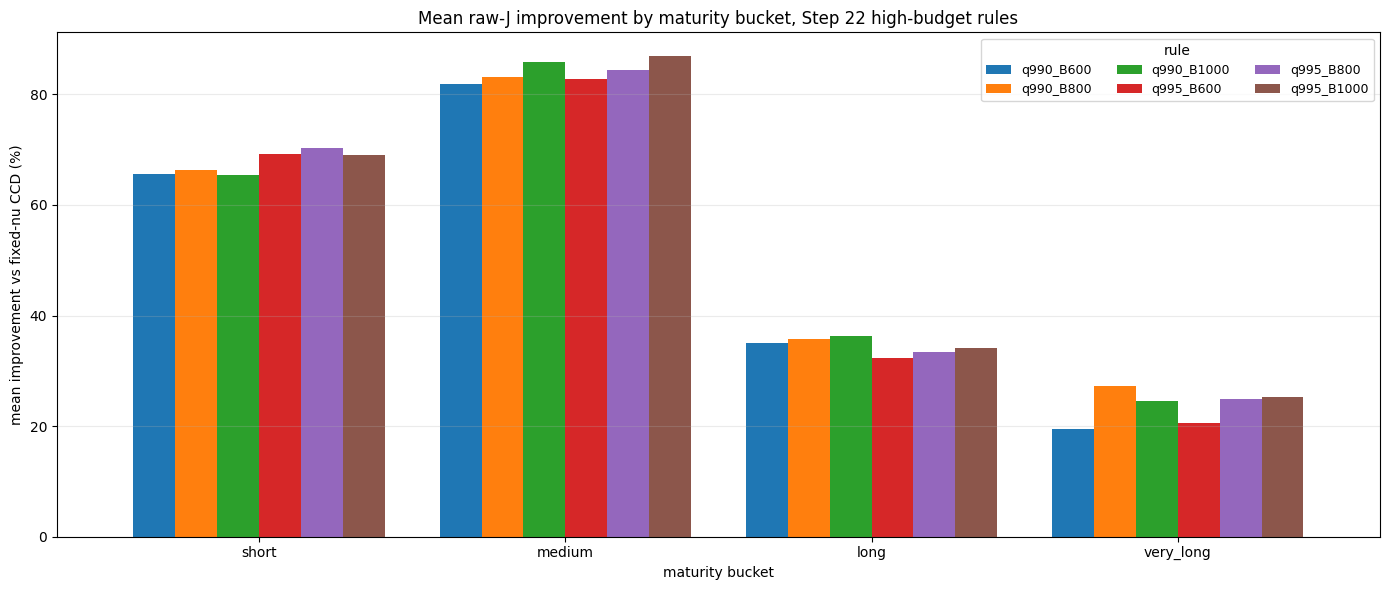

Saved plot to outputs/high_budget_mass_budget_validation/high_budget_mean_improvement_by_bucket.png


In [101]:

def plot_high_budget_mean_improvement_by_bucket(results=None):
    if results is None:
        results = load_high_budget_results()

    status_ok = results["status"].fillna("ok").eq("ok") if "status" in results.columns else pd.Series(True, index=results.index)
    feasible = results[status_ok & (results["feasible"] == True)].copy()
    if feasible.empty:
        print("No feasible Step 22 rows available for the bucket mean plot.")
        return

    bucket_order = ["short", "medium", "long", "very_long"]
    rule_order = [rule["rule_name"] for rule in HIGH_BUDGET_RULES]
    pivot = (
        feasible.groupby(["maturity_bucket", "rule_name"])["improvement_vs_fixed_pct"]
        .mean()
        .unstack("rule_name")
        .reindex(bucket_order)
        .reindex(columns=rule_order)
    )

    display(pivot.round(4))

    ax = pivot.plot(kind="bar", figsize=(14, 6), width=0.82)
    ax.set_title("Mean raw-J improvement by maturity bucket, Step 22 high-budget rules")
    ax.set_xlabel("maturity bucket")
    ax.set_ylabel("mean improvement vs fixed-nu CCD (%)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="rule", ncol=3, fontsize=9)
    plt.xticks(rotation=0)
    plt.tight_layout()
    out = HIGH_BUDGET_OUTPUT_DIR / "high_budget_mean_improvement_by_bucket.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to {out}")


plot_high_budget_mean_improvement_by_bucket()
